In [1]:
import sys
import platform
import pandas as pd
import numpy as np
import sklearn

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
Platform: Windows-10-10.0.26200-SP0
Pandas: 3.0.5
NumPy: 2.4.6
Scikit-learn: 1.9.0


In [2]:
print("PoisonShield notebook is working.")

PoisonShield notebook is working.


In [3]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:")
print(PROJECT_ROOT)

print("\nRaw data directory:")
print(RAW_DIR)

print("\nFiles found:")
for file in RAW_DIR.iterdir():
    print("-", file.name)

Project root:
d:\User\Desktop\PoisonShield

Raw data directory:
d:\User\Desktop\PoisonShield\data\raw

Files found:
- cccs_andmal2020_poisoned.csv
- cccs_andmal2020_removed_audit.csv
- cic_malmem2022_poisoned.csv
- cic_malmem2022_removed_audit.csv


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np

print("Libraries loaded successfully.")

Libraries loaded successfully.


Phase - 2 : Dataset Preparation & Audit

Locate the project root safely

In [5]:
from pathlib import Path

cwd = Path.cwd()

print("Current working directory:")
print(cwd)

print("\nDirectory contents:")
for item in cwd.iterdir():
    print("-", item.name)

Current working directory:
d:\User\Desktop\PoisonShield\notebooks

Directory contents:
- 01_dataset_audit.ipynb


Automatically find the project root

In [6]:
from pathlib import Path

def find_project_root(start_path):
    start_path = Path(start_path).resolve()

    candidates = [start_path] + list(start_path.parents)

    for path in candidates:
        if (
            (path / "data" / "raw").exists()
            and (path / "notebooks").exists()
            and (path / "src").exists()
        ):
            return path

    raise FileNotFoundError(
        "Could not locate the PoisonShield project root."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:")
print(PROJECT_ROOT)

print("\nRaw data directory:")
print(RAW_DIR)

Project root:
D:\User\Desktop\PoisonShield

Raw data directory:
D:\User\Desktop\PoisonShield\data\raw


Verify the four expected files

In [8]:
expected_files = [
    "cic_malmem2022_poisoned.csv",
    "cic_malmem2022_removed_audit.csv",
    "cccs_andmal2020_poisoned.csv",
    "cccs_andmal2020_removed_audit.csv",
]

print("Expected raw files:\n")

for filename in expected_files:
    path = RAW_DIR / filename

    if path.exists():
        size_mb = path.stat().st_size / (1024 ** 2)
        print(f"[FOUND] {filename} — {size_mb:.2f} MB")
    else:
        print(f"[MISSING] {filename}")

Expected raw files:

[FOUND] cic_malmem2022_poisoned.csv — 16.97 MB
[FOUND] cic_malmem2022_removed_audit.csv — 0.89 MB
[FOUND] cccs_andmal2020_poisoned.csv — 22.02 MB
[FOUND] cccs_andmal2020_removed_audit.csv — 1.49 MB


Check that raw files have not been accidentally modified

In [9]:
print("RAW DATA FILE INVENTORY")
print("=" * 70)

for filename in expected_files:
    path = RAW_DIR / filename

    if path.exists():
        stat = path.stat()

        print(f"\nFile: {filename}")
        print(f"Size: {stat.st_size:,} bytes")
        print(f"Path: {path}")

RAW DATA FILE INVENTORY

File: cic_malmem2022_poisoned.csv
Size: 17,793,118 bytes
Path: D:\User\Desktop\PoisonShield\data\raw\cic_malmem2022_poisoned.csv

File: cic_malmem2022_removed_audit.csv
Size: 929,617 bytes
Path: D:\User\Desktop\PoisonShield\data\raw\cic_malmem2022_removed_audit.csv

File: cccs_andmal2020_poisoned.csv
Size: 23,087,296 bytes
Path: D:\User\Desktop\PoisonShield\data\raw\cccs_andmal2020_poisoned.csv

File: cccs_andmal2020_removed_audit.csv
Size: 1,563,080 bytes
Path: D:\User\Desktop\PoisonShield\data\raw\cccs_andmal2020_removed_audit.csv


Tables 

In [10]:
inventory_rows = []

for filename in expected_files:
    path = RAW_DIR / filename

    inventory_rows.append({
        "filename": filename,
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else np.nan
    })

file_inventory = pd.DataFrame(inventory_rows)

file_inventory

,filename,exists,size_bytes
0,cic_malmem2022_poisoned.csv,True,17793118
1,cic_malmem2022_removed_audit.csv,True,929617
2,cccs_andmal2020_poisoned.csv,True,23087296
3,cccs_andmal2020_removed_audit.csv,True,1563080


In [11]:
inventory_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_raw_file_inventory.csv"
)

file_inventory.to_csv(inventory_path, index=False)

print(f"Saved inventory to:\n{inventory_path}")

Saved inventory to:
D:\User\Desktop\PoisonShield\results\tables\table_raw_file_inventory.csv


Define the two paths

In [12]:
malmem_path = RAW_DIR / "cic_malmem2022_poisoned.csv"
android_path = RAW_DIR / "cccs_andmal2020_poisoned.csv"

print("MalMem path:")
print(malmem_path)

print("\nAndroid path:")
print(android_path)

MalMem path:
D:\User\Desktop\PoisonShield\data\raw\cic_malmem2022_poisoned.csv

Android path:
D:\User\Desktop\PoisonShield\data\raw\cccs_andmal2020_poisoned.csv


Confirm the files exist

In [13]:
assert malmem_path.exists(), f"Missing file: {malmem_path}"
assert android_path.exists(), f"Missing file: {android_path}"

print("Both primary datasets were found successfully.")

Both primary datasets were found successfully.


Load the datasets

In [14]:
malmem = pd.read_csv(malmem_path)
android = pd.read_csv(android_path)

print("Datasets loaded successfully.")

Datasets loaded successfully.


Verify dimensions

In [15]:
print("Dataset shapes")
print("=" * 50)

print(f"CIC-MalMem-2022: {malmem.shape}")
print(f"Android dataset: {android.shape}")

Dataset shapes
CIC-MalMem-2022: (58596, 59)
Android dataset: (11598, 474)


In [16]:
expected_shapes = {
    "MalMem": (58596, 59),
    "Android": (11598, 474),
}

actual_shapes = {
    "MalMem": malmem.shape,
    "Android": android.shape,
}

for name in expected_shapes:
    expected = expected_shapes[name]
    actual = actual_shapes[name]

    status = "PASS" if expected == actual else "FAIL"

    print(
        f"{name}: {status} | "
        f"Expected={expected}, Actual={actual}"
    )

MalMem: PASS | Expected=(58596, 59), Actual=(58596, 59)
Android: PASS | Expected=(11598, 474), Actual=(11598, 474)


Inspect the first five rows

In [17]:
print("CIC-MalMem-2022")
display(malmem.head())

print("\nSupplied Android dataset")
display(android.head())

CIC-MalMem-2022


,Class,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,attack_type,original_label,source_index
0,Benign,45,17,10.555556,0,202.844444,1694.0,38.500000,9129.0,212.302326,...,24,116,0,121.0,87.0,0,8,clean,Benign,-1
1,Benign,47,19,11.531915,0,242.234043,2074.0,44.127660,11385.0,242.234043,...,24,118,0,122.0,87.0,0,8,clean,Benign,-1
2,Benign,40,14,14.725000,0,288.225000,1932.0,48.300000,11529.0,288.225000,...,27,118,0,120.0,88.0,0,8,clean,Benign,-1
3,Benign,32,13,13.500000,0,264.281250,1445.0,45.156250,8457.0,264.281250,...,27,118,0,120.0,88.0,0,8,clean,Benign,-1
4,Benign,42,16,11.452381,0,281.333333,2067.0,49.214286,11816.0,281.333333,...,24,118,0,124.0,87.0,0,8,clean,Benign,-1



Supplied Android dataset


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class,attack_type,original_label,source_index
0,1.0,0.0,0.0,3.0,0.0,14.0,2.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,37.0,10.000000,Benign,backdoor_injection,Adware,-1
1,3.0,0.0,0.0,6.0,0.0,42.0,91.0,0.0,32.0,0.0,...,0.0,0.0,0.0,2.0,2838.0,7.257753,Adware,feature_poisoning,Adware,-1
2,2.0,0.0,0.0,4.0,0.0,23.0,3.0,0.0,17.0,2.0,...,0.0,0.0,0.0,1.0,111.0,2.776177,Adware,feature_poisoning,Adware,-1
3,3.0,0.0,0.0,11.0,0.0,18.0,3.0,0.0,16.0,0.0,...,0.0,0.0,0.0,1.0,98.0,25.000000,Adware,clean,Adware,-1
4,0.0,0.0,0.0,0.0,0.0,9.0,2.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,60.0,3.000000,Adware,clean,Adware,-1


Inspect the last five rows

In [18]:
print("CIC-MalMem-2022 — last 5 rows")
display(malmem.tail())

print("\nAndroid dataset — last 5 rows")
display(android.tail())

CIC-MalMem-2022 — last 5 rows


,Class,pslist.nproc,pslist.nppid,pslist.avg_threads,pslist.nprocs64bit,pslist.avg_handlers,dlllist.ndlls,dlllist.avg_dlls_per_proc,handles.nhandles,handles.avg_handles_per_proc,...,svcscan.process_services,svcscan.shared_process_services,svcscan.interactive_process_services,svcscan.nactive,callbacks.ncallbacks,callbacks.nanonymous,callbacks.ngeneric,attack_type,original_label,source_index
58591,Spyware,42,18,9.714286,0,202.738095,1596.0,38.000000,8515.0,202.738095,...,24,116,0,119.0,86.0,0,8,sample_duplication,Spyware,44788
58592,Spyware,35,15,10.514286,0,184.485714,1273.0,36.371429,6458.0,189.941177,...,21,110,0,112.0,88.0,0,8,sample_duplication,Spyware,38485
58593,Spyware,40,16,9.850000,0,213.850000,1547.0,38.675000,8555.0,219.358974,...,24,116,0,119.0,86.0,0,8,sample_duplication,Spyware,45066
58594,Spyware,40,16,9.575000,0,204.250000,1506.0,37.650000,8171.0,209.512821,...,24,116,0,119.0,87.0,0,8,sample_duplication,Spyware,43756
58595,Spyware,40,16,9.825000,0,208.675000,1557.0,38.925000,8347.0,208.675000,...,24,116,0,122.0,86.0,0,8,sample_duplication,Spyware,36374



Android dataset — last 5 rows


,ACCESS_PERSONAL_INFO___,ALTER_PHONE_STATE___,ANTI_DEBUG_____,CREATE_FOLDER_____,CREATE_PROCESS`_____,CREATE_THREAD_____,DEVICE_ACCESS_____,EXECUTE_____,FS_ACCESS____,FS_ACCESS()____,...,vibratePattern,wait4,watchRotation,windowGainedFocus,write,writev,Class,attack_type,original_label,source_index
11593,0.0,0.0,0.0,3.0,0.0,10.0,2.0,0.0,22.0,0.0,...,0.0,0.0,0.0,1.0,1162.0,10.0,Riskware,sample_duplication,Riskware,8201
11594,0.0,0.0,0.0,5.0,0.0,36.0,24.0,0.0,47.0,3.0,...,0.0,0.0,0.0,2.0,2649.0,27.0,Riskware,sample_duplication,Riskware,7696
11595,216.0,0.0,0.0,31.0,19.0,95.0,190.0,32.0,359.0,26.0,...,0.0,162.0,0.0,1.0,1731.0,992.0,Riskware,sample_duplication,Riskware,8939
11596,1.0,0.0,0.0,11.0,1.0,13.0,26.0,1.0,30.0,0.0,...,0.0,1.0,0.0,1.0,287.0,138.0,Riskware,sample_duplication,Riskware,7500
11597,4.0,0.0,0.0,1.0,0.0,14.0,3.0,0.0,22.0,1.0,...,0.0,0.0,0.0,0.0,177.0,80.0,Riskware,sample_duplication,Riskware,7822


Inspect column names

In [19]:
print("CIC-MalMem-2022 columns")
print("=" * 70)

for i, col in enumerate(malmem.columns):
    print(f"{i:>3}: {col}")

print("\n\nAndroid dataset columns")
print("=" * 70)

for i, col in enumerate(android.columns):
    print(f"{i:>3}: {col}")

CIC-MalMem-2022 columns
  0: Class
  1: pslist.nproc
  2: pslist.nppid
  3: pslist.avg_threads
  4: pslist.nprocs64bit
  5: pslist.avg_handlers
  6: dlllist.ndlls
  7: dlllist.avg_dlls_per_proc
  8: handles.nhandles
  9: handles.avg_handles_per_proc
 10: handles.nport
 11: handles.nfile
 12: handles.nevent
 13: handles.ndesktop
 14: handles.nkey
 15: handles.nthread
 16: handles.ndirectory
 17: handles.nsemaphore
 18: handles.ntimer
 19: handles.nsection
 20: handles.nmutant
 21: ldrmodules.not_in_load
 22: ldrmodules.not_in_init
 23: ldrmodules.not_in_mem
 24: ldrmodules.not_in_load_avg
 25: ldrmodules.not_in_init_avg
 26: ldrmodules.not_in_mem_avg
 27: malfind.ninjections
 28: malfind.commitCharge
 29: malfind.protection
 30: malfind.uniqueInjections
 31: psxview.not_in_pslist
 32: psxview.not_in_eprocess_pool
 33: psxview.not_in_ethread_pool
 34: psxview.not_in_pspcid_list
 35: psxview.not_in_csrss_handles
 36: psxview.not_in_session
 37: psxview.not_in_deskthrd
 38: psxview.not_in_

Verify duplicate column names

In [20]:
def duplicate_column_names(df):
    return df.columns[df.columns.duplicated()].tolist()


malmem_duplicate_columns = duplicate_column_names(malmem)
android_duplicate_columns = duplicate_column_names(android)

print("MalMem duplicate column names:")
print(malmem_duplicate_columns)

print("\nAndroid duplicate column names:")
print(android_duplicate_columns)

MalMem duplicate column names:
[]

Android duplicate column names:
[]


Check column-name whitespace

In [21]:
def columns_with_whitespace(df):
    return [
        col for col in df.columns
        if col != col.strip()
    ]


print("MalMem columns with leading/trailing whitespace:")
print(columns_with_whitespace(malmem))

print("\nAndroid columns with leading/trailing whitespace:")
print(columns_with_whitespace(android))

MalMem columns with leading/trailing whitespace:
[]

Android columns with leading/trailing whitespace:
[]


Inspect data types

In [22]:
print("MalMem data types")
print("=" * 50)
print(malmem.dtypes.value_counts())

print("\nAndroid data types")
print("=" * 50)
print(android.dtypes.value_counts())

MalMem data types
int64      33
float64    23
str         3
Name: count, dtype: int64

Android data types
float64    470
str          3
int64        1
Name: count, dtype: int64


Explicitly identify numeric and non-numeric columns

In [23]:
def inspect_column_types(df, dataset_name):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    non_numeric_cols = df.select_dtypes(exclude=np.number).columns.tolist()

    print(f"\n{dataset_name}")
    print("=" * 70)

    print(f"Total columns: {len(df.columns)}")
    print(f"Numeric columns: {len(numeric_cols)}")
    print(f"Non-numeric columns: {len(non_numeric_cols)}")

    print("\nNon-numeric columns:")
    for col in non_numeric_cols:
        print(f"  - {col}")


inspect_column_types(malmem, "CIC-MalMem-2022")
inspect_column_types(android, "Supplied Android Dataset")


CIC-MalMem-2022
Total columns: 59
Numeric columns: 56
Non-numeric columns: 3

Non-numeric columns:
  - Class
  - attack_type
  - original_label

Supplied Android Dataset
Total columns: 474
Numeric columns: 471
Non-numeric columns: 3

Non-numeric columns:
  - Class
  - attack_type
  - original_label


Verify the four critical metadata fields

In [24]:
metadata_cols = [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
]

for name, df in {
    "MalMem": malmem,
    "Android": android
}.items():

    print(f"\n{name}")
    print("=" * 70)

    for col in metadata_cols:
        if col in df.columns:
            print(f"[FOUND]   {col:<20} dtype={df[col].dtype}")
        else:
            print(f"[MISSING] {col}")


MalMem
[FOUND]   Class                dtype=str
[FOUND]   attack_type          dtype=str
[FOUND]   original_label       dtype=str
[FOUND]   source_index         dtype=int64

Android
[FOUND]   Class                dtype=str
[FOUND]   attack_type          dtype=str
[FOUND]   original_label       dtype=str
[FOUND]   source_index         dtype=int64


Create a structural audit table

In [25]:
structural_audit = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "rows": malmem.shape[0],
        "columns": malmem.shape[1],
        "numeric_columns": malmem.select_dtypes(include=np.number).shape[1],
        "non_numeric_columns": malmem.select_dtypes(exclude=np.number).shape[1],
        "has_Class": "Class" in malmem.columns,
        "has_attack_type": "attack_type" in malmem.columns,
        "has_original_label": "original_label" in malmem.columns,
        "has_source_index": "source_index" in malmem.columns,
    },
    {
        "dataset": "Supplied Android Dataset",
        "rows": android.shape[0],
        "columns": android.shape[1],
        "numeric_columns": android.select_dtypes(include=np.number).shape[1],
        "non_numeric_columns": android.select_dtypes(exclude=np.number).shape[1],
        "has_Class": "Class" in android.columns,
        "has_attack_type": "attack_type" in android.columns,
        "has_original_label": "original_label" in android.columns,
        "has_source_index": "source_index" in android.columns,
    }
])

display(structural_audit)

,dataset,rows,columns,numeric_columns,non_numeric_columns,has_Class,has_attack_type,has_original_label,has_source_index
0,CIC-MalMem-2022,58596,59,56,3,True,True,True,True
1,Supplied Android Dataset,11598,474,471,3,True,True,True,True


In [26]:
structural_audit_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_structural_audit.csv"
)

structural_audit.to_csv(structural_audit_path, index=False)

print(f"Saved:\n{structural_audit_path}")

Saved:
D:\User\Desktop\PoisonShield\results\tables\table_structural_audit.csv


Construct poisoned and Validate Attack Composition

Inspect attack types

In [27]:
print("CIC-MalMem-2022 attack types")
print("=" * 70)
print(malmem["attack_type"].value_counts(dropna=False))

print("\n\nAndroid attack types")
print("=" * 70)
print(android["attack_type"].value_counts(dropna=False))

CIC-MalMem-2022 attack types
attack_type
clean                       42202
backdoor_injection           2342
gaussian_noise_injection     2342
label_flipping               2342
feature_poisoning            2342
missing_value_injection      2342
outlier_injection            2342
sample_duplication           2342
Name: count, dtype: int64


Android attack types
attack_type
clean                       6117
backdoor_injection           783
feature_poisoning            783
missing_value_injection      783
gaussian_noise_injection     783
label_flipping               783
outlier_injection            783
sample_duplication           783
Name: count, dtype: int64


Check missing attack labels

In [28]:
for name, df in {
    "MalMem": malmem,
    "Android": android
}.items():

    missing_attack_type = df["attack_type"].isna().sum()

    print(
        f"{name}: missing attack_type values = "
        f"{missing_attack_type}"
    )

MalMem: missing attack_type values = 0
Android: missing attack_type values = 0


Create the poisoned evaluation variable

In [29]:
malmem["poisoned"] = (
    malmem["attack_type"] != "clean"
).astype(int)

android["poisoned"] = (
    android["attack_type"] != "clean"
).astype(int)

C:\Users\alokr\AppData\Local\Temp\ipykernel_15052\3305891863.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  android["poisoned"] = (


Verify the new variable

In [30]:
for name, df in {
    "MalMem": malmem,
    "Android": android
}.items():

    print(f"\n{name}")
    print("=" * 70)

    print("Unique poisoned values:")
    print(sorted(df["poisoned"].unique()))

    print("\nCounts:")
    print(df["poisoned"].value_counts().sort_index())


MalMem
Unique poisoned values:
[np.int64(0), np.int64(1)]

Counts:
poisoned
0    42202
1    16394
Name: count, dtype: int64

Android
Unique poisoned values:
[np.int64(0), np.int64(1)]

Counts:
poisoned
0    6117
1    5481
Name: count, dtype: int64


Validate the definition mathematically

In [31]:
for name, df in {
    "MalMem": malmem,
    "Android": android
}.items():

    expected_poisoned = (
        df["attack_type"] != "clean"
    ).astype(int)

    mismatches = (
        df["poisoned"] != expected_poisoned
    ).sum()

    print(
        f"{name}: poisoned-definition mismatches = {mismatches}"
    )

MalMem: poisoned-definition mismatches = 0
Android: poisoned-definition mismatches = 0


Calculate poisoning proportion

In [32]:
for name, df in {
    "MalMem": malmem,
    "Android": android
}.items():

    poisoned_rate = df["poisoned"].mean() * 100

    print(
        f"{name}: {poisoned_rate:.3f}% of observations are poisoned"
    )

MalMem: 27.978% of observations are poisoned
Android: 47.258% of observations are poisoned


Build a complete attack-distribution table

In [33]:
attack_distribution = pd.concat(
    [
        (
            malmem["attack_type"]
            .value_counts()
            .rename_axis("attack_type")
            .reset_index(name="count")
            .assign(dataset="CIC-MalMem-2022")
        ),
        (
            android["attack_type"]
            .value_counts()
            .rename_axis("attack_type")
            .reset_index(name="count")
            .assign(dataset="Android")
        ),
    ],
    ignore_index=True
)

attack_distribution["percentage"] = (
    attack_distribution.groupby("dataset")["count"]
    .transform(lambda x: 100 * x / x.sum())
)

attack_distribution = attack_distribution[
    ["dataset", "attack_type", "count", "percentage"]
].sort_values(
    ["dataset", "attack_type"]
).reset_index(drop=True)

display(attack_distribution)

,dataset,attack_type,count,percentage
0,Android,backdoor_injection,783,6.751164
1,Android,clean,6117,52.741852
2,Android,feature_poisoning,783,6.751164
3,Android,gaussian_noise_injection,783,6.751164
4,Android,label_flipping,783,6.751164
5,Android,missing_value_injection,783,6.751164
6,Android,outlier_injection,783,6.751164
7,Android,sample_duplication,783,6.751164
8,CIC-MalMem-2022,backdoor_injection,2342,3.996860
9,CIC-MalMem-2022,clean,42202,72.021981


Add poisoned counts

In [34]:
poisoned_summary = []

for name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    poisoned_count = int(df["poisoned"].sum())
    clean_count = int((df["poisoned"] == 0).sum())
    total = len(df)

    poisoned_summary.append({
        "dataset": name,
        "total_observations": total,
        "clean_observations": clean_count,
        "poisoned_observations": poisoned_count,
        "clean_percentage": 100 * clean_count / total,
        "poisoned_percentage": 100 * poisoned_count / total
    })

poisoned_summary = pd.DataFrame(poisoned_summary)

display(poisoned_summary)

,dataset,total_observations,clean_observations,poisoned_observations,clean_percentage,poisoned_percentage
0,CIC-MalMem-2022,58596,42202,16394,72.021981,27.978019
1,Android,11598,6117,5481,52.741852,47.258148


Save the audit artifacts

In [35]:
attack_table_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_attack_distribution.csv"
)

poisoned_summary_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_poisoned_summary.csv"
)

attack_distribution.to_csv(
    attack_table_path,
    index=False
)

poisoned_summary.to_csv(
    poisoned_summary_path,
    index=False
)

print("Saved:")
print(attack_table_path)
print(poisoned_summary_path)

Saved:
D:\User\Desktop\PoisonShield\results\tables\table_attack_distribution.csv
D:\User\Desktop\PoisonShield\results\tables\table_poisoned_summary.csv


Create a validation report

In [36]:
validation_checks = []

for name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    attack_types = set(df["attack_type"].dropna().unique())

    expected_attack_types = {
        "clean",
        "backdoor_injection",
        "feature_poisoning",
        "gaussian_noise_injection",
        "label_flipping",
        "missing_value_injection",
        "sample_duplication",
        "outlier_injection"
    }

    validation_checks.append({
        "dataset": name,
        "attack_type_count": len(attack_types),
        "attack_types_correct": attack_types == expected_attack_types,
        "missing_attack_type": int(df["attack_type"].isna().sum()),
        "poisoned_values_valid": set(df["poisoned"].unique()) == {0, 1},
        "poisoned_definition_valid": (
            df["poisoned"]
            == (df["attack_type"] != "clean").astype(int)
        ).all()
    })

validation_report = pd.DataFrame(validation_checks)

display(validation_report)

,dataset,attack_type_count,attack_types_correct,missing_attack_type,poisoned_values_valid,poisoned_definition_valid
0,CIC-MalMem-2022,8,True,0,True,True
1,Android,8,True,0,True,True


Label Consistency Audit

Overall label mismatch count

In [37]:
for name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    mismatch_mask = df["Class"] != df["original_label"]

    mismatch_count = mismatch_mask.sum()
    mismatch_percentage = 100 * mismatch_count / len(df)

    print(f"\n{name}")
    print("=" * 70)
    print(f"Total observations: {len(df):,}")
    print(f"Label mismatches:   {mismatch_count:,}")
    print(f"Mismatch rate:      {mismatch_percentage:.3f}%")


CIC-MalMem-2022
Total observations: 58,596
Label mismatches:   4,684
Mismatch rate:      7.994%

Android
Total observations: 11,598
Label mismatches:   1,566
Mismatch rate:      13.502%


Verify expected mismatch counts

In [38]:
expected_mismatches = {
    "CIC-MalMem-2022": 4684,
    "Android": 1566
}

actual_datasets = {
    "CIC-MalMem-2022": malmem,
    "Android": android
}

for name, df in actual_datasets.items():

    actual = int(
        (df["Class"] != df["original_label"]).sum()
    )

    expected = expected_mismatches[name]

    status = "PASS" if actual == expected else "FAIL"

    print(
        f"{name}: {status} | "
        f"Expected={expected:,}, Actual={actual:,}"
    )

CIC-MalMem-2022: PASS | Expected=4,684, Actual=4,684
Android: PASS | Expected=1,566, Actual=1,566


Mismatches by attack type

In [39]:
for name, df in actual_datasets.items():

    mismatch_mask = (
        df["Class"] != df["original_label"]
    )

    mismatch_by_attack = (
        df.loc[mismatch_mask, "attack_type"]
        .value_counts()
        .sort_index()
    )

    print(f"\n{name}")
    print("=" * 70)
    print(mismatch_by_attack)


CIC-MalMem-2022
attack_type
backdoor_injection    2342
label_flipping        2342
Name: count, dtype: int64

Android
attack_type
backdoor_injection    783
label_flipping        783
Name: count, dtype: int64


Build the attack × mismatch contingency table

In [40]:
for name, df in actual_datasets.items():

    mismatch = (
        df["Class"] != df["original_label"]
    )

    table = pd.crosstab(
        df["attack_type"],
        mismatch,
        margins=True
    )

    table.columns = [
        "Match" if col is False
        else "Mismatch" if col is True
        else col
        for col in table.columns
    ]

    print(f"\n{name}")
    print("=" * 70)
    display(table)


CIC-MalMem-2022


,Match,Mismatch,All
attack_type,,,
backdoor_injection,0,2342,2342
clean,42202,0,42202
feature_poisoning,2342,0,2342
gaussian_noise_injection,2342,0,2342
label_flipping,0,2342,2342
missing_value_injection,2342,0,2342
outlier_injection,2342,0,2342
sample_duplication,2342,0,2342
All,53912,4684,58596



Android


,Match,Mismatch,All
attack_type,,,
backdoor_injection,0,783,783
clean,6117,0,6117
feature_poisoning,783,0,783
gaussian_noise_injection,783,0,783
label_flipping,0,783,783
missing_value_injection,783,0,783
outlier_injection,783,0,783
sample_duplication,783,0,783
All,10032,1566,11598


Check whether clean observations have label mismatches

In [41]:
for name, df in actual_datasets.items():

    clean_df = df[df["attack_type"] == "clean"]

    clean_mismatches = (
        clean_df["Class"] != clean_df["original_label"]
    ).sum()

    print(
        f"{name}: clean observations with label mismatch = "
        f"{clean_mismatches}"
    )

CIC-MalMem-2022: clean observations with label mismatch = 0
Android: clean observations with label mismatch = 0


Inspect the actual label transitions

In [42]:
for name, df in actual_datasets.items():

    mismatch_df = df[
        df["Class"] != df["original_label"]
    ]

    transitions = pd.crosstab(
        mismatch_df["original_label"],
        mismatch_df["Class"]
    )

    print(f"\n{name} — Label transitions")
    print("=" * 70)
    display(transitions)


CIC-MalMem-2022 — Label transitions


Class,Benign
original_label,
Ransomware,1566
Spyware,1602
Trojan,1516



Android — Label transitions


Class,Benign
original_label,
Adware,200
Banking,336
Riskware,406
SMS malware,624


Inspect transitions separately by attack

In [43]:
for name, df in actual_datasets.items():

    print(f"\n{'=' * 70}")
    print(name)
    print(f"{'=' * 70}")

    mismatch_df = df[
        df["Class"] != df["original_label"]
    ]

    for attack in sorted(
        mismatch_df["attack_type"].unique()
    ):

        attack_df = mismatch_df[
            mismatch_df["attack_type"] == attack
        ]

        transitions = pd.crosstab(
            attack_df["original_label"],
            attack_df["Class"]
        )

        print(f"\nAttack: {attack}")
        display(transitions)


CIC-MalMem-2022

Attack: backdoor_injection


Class,Benign
original_label,
Ransomware,783
Spyware,801
Trojan,758



Attack: label_flipping


Class,Benign
original_label,
Ransomware,783
Spyware,801
Trojan,758



Android

Attack: backdoor_injection


Class,Benign
original_label,
Adware,100
Banking,168
Riskware,203
SMS malware,312



Attack: label_flipping


Class,Benign
original_label,
Adware,100
Banking,168
Riskware,203
SMS malware,312


Verify source-index behavior

In [44]:
for name, df in actual_datasets.items():

    print(f"\n{name}")
    print("=" * 70)

    print(
        df["source_index"]
        .describe()
    )

    print("\nUnique source_index values:")
    print(df["source_index"].nunique())


CIC-MalMem-2022
count    58596.000000
mean      1761.379582
std       8801.247015
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max      58562.000000
Name: source_index, dtype: float64

Unique source_index values:
2343

Android
count    11598.000000
mean       326.775306
std       1417.417923
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max       9788.000000
Name: source_index, dtype: float64

Unique source_index values:
784


Check source_index by attack

In [45]:
for name, df in actual_datasets.items():

    source_summary = (
        df.groupby("attack_type")["source_index"]
        .agg(
            count="count",
            unique_values="nunique",
            minimum="min",
            maximum="max",
            non_negative=lambda x: (x >= 0).sum()
        )
    )

    print(f"\n{name}")
    print("=" * 70)
    display(source_summary)


CIC-MalMem-2022


,count,unique_values,minimum,maximum,non_negative
attack_type,,,,,
backdoor_injection,2342,1,-1,-1,0
clean,42202,1,-1,-1,0
feature_poisoning,2342,1,-1,-1,0
gaussian_noise_injection,2342,1,-1,-1,0
label_flipping,2342,1,-1,-1,0
missing_value_injection,2342,1,-1,-1,0
outlier_injection,2342,1,-1,-1,0
sample_duplication,2342,2342,29307,58562,2342



Android


,count,unique_values,minimum,maximum,non_negative
attack_type,,,,,
backdoor_injection,783,1,-1,-1,0
clean,6117,1,-1,-1,0
feature_poisoning,783,1,-1,-1,0
gaussian_noise_injection,783,1,-1,-1,0
label_flipping,783,1,-1,-1,0
missing_value_injection,783,1,-1,-1,0
outlier_injection,783,1,-1,-1,0
sample_duplication,783,783,4,9788,783


Verify duplication source-index coverage

In [46]:
for name, df in actual_datasets.items():

    duplication_df = df[
        df["attack_type"] == "sample_duplication"
    ]

    valid_source_index = (
        duplication_df["source_index"] >= 0
    ).sum()

    print(
        f"{name}: "
        f"{valid_source_index:,} / "
        f"{len(duplication_df):,} duplication rows "
        f"have valid source_index"
    )

CIC-MalMem-2022: 2,342 / 2,342 duplication rows have valid source_index
Android: 783 / 783 duplication rows have valid source_index


Save the label audit

In [47]:
label_audit_rows = []

for name, df in actual_datasets.items():

    mismatch_mask = (
        df["Class"] != df["original_label"]
    )

    for attack in sorted(df["attack_type"].unique()):

        attack_df = df[
            df["attack_type"] == attack
        ]

        attack_mismatch = (
            attack_df["Class"]
            != attack_df["original_label"]
        )

        label_audit_rows.append({
            "dataset": name,
            "attack_type": attack,
            "observations": len(attack_df),
            "label_mismatches": int(attack_mismatch.sum()),
            "label_match": int((~attack_mismatch).sum()),
            "mismatch_percentage": (
                100 * attack_mismatch.mean()
            )
        })

label_audit = pd.DataFrame(label_audit_rows)

display(label_audit)

,dataset,attack_type,observations,label_mismatches,label_match,mismatch_percentage
0,CIC-MalMem-2022,backdoor_injection,2342,2342,0,100.0
1,CIC-MalMem-2022,clean,42202,0,42202,0.0
2,CIC-MalMem-2022,feature_poisoning,2342,0,2342,0.0
3,CIC-MalMem-2022,gaussian_noise_injection,2342,0,2342,0.0
4,CIC-MalMem-2022,label_flipping,2342,2342,0,100.0
5,CIC-MalMem-2022,missing_value_injection,2342,0,2342,0.0
6,CIC-MalMem-2022,outlier_injection,2342,0,2342,0.0
7,CIC-MalMem-2022,sample_duplication,2342,0,2342,0.0
8,Android,backdoor_injection,783,783,0,100.0
9,Android,clean,6117,0,6117,0.0


In [48]:
label_audit_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_label_consistency_audit.csv"
)

label_audit.to_csv(
    label_audit_path,
    index=False
)

print(f"Saved:\n{label_audit_path}")

Saved:
D:\User\Desktop\PoisonShield\results\tables\table_label_consistency_audit.csv


Create the final checkpoint

In [49]:
label_validation = []

for name, df in actual_datasets.items():

    mismatch_count = int(
        (df["Class"] != df["original_label"]).sum()
    )

    clean_mismatch = int(
        (
            df.loc[
                df["attack_type"] == "clean",
                "Class"
            ]
            !=
            df.loc[
                df["attack_type"] == "clean",
                "original_label"
            ]
        ).sum()
    )

    duplication = df[
        df["attack_type"] == "sample_duplication"
    ]

    valid_dup_source = int(
        (duplication["source_index"] >= 0).sum()
    )

    non_duplication = df[
        df["attack_type"] != "sample_duplication"
    ]

    unexpected_source = int(
        (non_duplication["source_index"] >= 0).sum()
    )

    expected = expected_mismatches[name]

    label_validation.append({
        "dataset": name,
        "mismatch_count": mismatch_count,
        "expected_mismatch_count": expected,
        "mismatch_count_pass": mismatch_count == expected,
        "clean_mismatch_count": clean_mismatch,
        "clean_mismatch_pass": clean_mismatch == 0,
        "valid_duplication_source_indices": valid_dup_source,
        "duplication_source_index_pass": (
            valid_dup_source == len(duplication)
        ),
        "unexpected_non_duplication_source_indices": unexpected_source,
        "non_duplication_source_index_pass": (
            unexpected_source == 0
        )
    })

label_validation = pd.DataFrame(label_validation)

display(label_validation)

,dataset,mismatch_count,expected_mismatch_count,mismatch_count_pass,clean_mismatch_count,clean_mismatch_pass,valid_duplication_source_indices,duplication_source_index_pass,unexpected_non_duplication_source_indices,non_duplication_source_index_pass
0,CIC-MalMem-2022,4684,4684,True,0,True,2342,True,0,True
1,Android,1566,1566,True,0,True,783,True,0,True


Missing-Value Audit

Overall missing-value counts

In [50]:
# Phase 2.5.1 — Overall missing-value audit

malmem_missing_cells = int(malmem.isna().sum().sum())
android_missing_cells = int(android.isna().sum().sum())

malmem_missing_rows = int(malmem.isna().any(axis=1).sum())
android_missing_rows = int(android.isna().any(axis=1).sum())

print("CIC-MalMem-2022")
print(f"  Missing cells: {malmem_missing_cells:,}")
print(f"  Rows with >=1 missing value: {malmem_missing_rows:,}")

print("\nAndroid")
print(f"  Missing cells: {android_missing_cells:,}")
print(f"  Rows with >=1 missing value: {android_missing_rows:,}")

CIC-MalMem-2022
  Missing cells: 4,684
  Rows with >=1 missing value: 2,342

Android
  Missing cells: 1,566
  Rows with >=1 missing value: 783


Missing values by column

In [51]:
# Phase 2.5.2 — Missing values by feature/column

malmem_missing_by_column = (
    malmem.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
)

android_missing_by_column = (
    android.isna()
    .sum()
    .loc[lambda s: s > 0]
    .sort_values(ascending=False)
)

print("CIC-MalMem-2022 — Missing values by column")
print(malmem_missing_by_column)

print("\nAndroid — Missing values by column")
print(android_missing_by_column)

CIC-MalMem-2022 — Missing values by column
svcscan.kernel_drivers    970
malfind.commitCharge      941
dlllist.ndlls             933
pslist.avg_handlers       921
handles.nhandles          919
dtype: int64

Android — Missing values by column
clock_gettime    360
writev           335
sched_yield      322
gettimeofday     282
read             267
dtype: int64


Missing values by attack type

In [52]:
# Phase 2.5.3 — Missing values by attack type

malmem_missing_by_attack = (
    malmem.assign(has_missing=malmem.isna().any(axis=1))
    .groupby("attack_type")["has_missing"]
    .sum()
    .astype(int)
)

android_missing_by_attack = (
    android.assign(has_missing=android.isna().any(axis=1))
    .groupby("attack_type")["has_missing"]
    .sum()
    .astype(int)
)

print("CIC-MalMem-2022 — Rows with missing values by attack_type")
print(malmem_missing_by_attack)

print("\nAndroid — Rows with missing values by attack_type")
print(android_missing_by_attack)

CIC-MalMem-2022 — Rows with missing values by attack_type
attack_type
backdoor_injection             0
clean                          0
feature_poisoning              0
gaussian_noise_injection       0
label_flipping                 0
missing_value_injection     2342
outlier_injection              0
sample_duplication             0
Name: has_missing, dtype: int64

Android — Rows with missing values by attack_type
attack_type
backdoor_injection            0
clean                         0
feature_poisoning             0
gaussian_noise_injection      0
label_flipping                0
missing_value_injection     783
outlier_injection             0
sample_duplication            0
Name: has_missing, dtype: int64


C:\Users\alokr\AppData\Local\Temp\ipykernel_15052\3600159418.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  android.assign(has_missing=android.isna().any(axis=1))


Missing cells by attack type

In [53]:
# Phase 2.5.4 — Missing cells by attack type

def missing_cells_by_attack(df):
    return (
        df.groupby("attack_type")
        .apply(lambda x: int(x.isna().sum().sum()), include_groups=False)
        .sort_values(ascending=False)
    )

malmem_missing_cells_by_attack = missing_cells_by_attack(malmem)
android_missing_cells_by_attack = missing_cells_by_attack(android)

print("CIC-MalMem-2022 — Missing cells by attack_type")
print(malmem_missing_cells_by_attack)

print("\nAndroid — Missing cells by attack_type")
print(android_missing_cells_by_attack)

CIC-MalMem-2022 — Missing cells by attack_type
attack_type
missing_value_injection     4684
backdoor_injection             0
feature_poisoning              0
clean                          0
gaussian_noise_injection       0
label_flipping                 0
outlier_injection              0
sample_duplication             0
dtype: int64

Android — Missing cells by attack_type
attack_type
missing_value_injection     1566
backdoor_injection             0
feature_poisoning              0
clean                          0
gaussian_noise_injection       0
label_flipping                 0
outlier_injection              0
sample_duplication             0
dtype: int64


Missing cells per affected row

In [54]:
# Phase 2.5.5 — Missing cells per affected row

malmem_missing_per_row = malmem.isna().sum(axis=1)
android_missing_per_row = android.isna().sum(axis=1)

print("CIC-MalMem-2022 — Missing cells per affected row")
print(
    malmem_missing_per_row[
        malmem_missing_per_row > 0
    ].value_counts().sort_index()
)

print("\nAndroid — Missing cells per affected row")
print(
    android_missing_per_row[
        android_missing_per_row > 0
    ].value_counts().sort_index()
)

CIC-MalMem-2022 — Missing cells per affected row
2    2342
Name: count, dtype: int64

Android — Missing cells per affected row
2    783
Name: count, dtype: int64


In [55]:
# Phase 2.5.6 — Verify missingness does not occur
# in clean or non-missing-value-injection attacks

for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    row_has_missing = df.isna().any(axis=1)

    clean_missing_rows = int(
        row_has_missing[
            df["attack_type"] == "clean"
        ].sum()
    )

    non_target_missing_rows = int(
        row_has_missing[
            ~df["attack_type"].isin(
                ["clean", "missing_value_injection"]
            )
        ].sum()
    )

    target_missing_rows = int(
        row_has_missing[
            df["attack_type"] == "missing_value_injection"
        ].sum()
    )

    print(f"\n{dataset_name}")
    print(f"Clean rows with missing values: {clean_missing_rows}")
    print(
        "Non-target attack rows with missing values: "
        f"{non_target_missing_rows}"
    )
    print(
        "Missing-value-injection rows with missing values: "
        f"{target_missing_rows}"
    )


CIC-MalMem-2022
Clean rows with missing values: 0
Non-target attack rows with missing values: 0
Missing-value-injection rows with missing values: 2342

Android
Clean rows with missing values: 0
Non-target attack rows with missing values: 0
Missing-value-injection rows with missing values: 783


In [56]:
# Phase 2.5.7 — Save missing-value audit tables

results_dir = Path("../results/tables")
results_dir.mkdir(parents=True, exist_ok=True)

# Overall missingness
missing_overall = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "missing_cells": int(malmem.isna().sum().sum()),
        "rows_with_missing": int(malmem.isna().any(axis=1).sum())
    },
    {
        "dataset": "Android",
        "missing_cells": int(android.isna().sum().sum()),
        "rows_with_missing": int(android.isna().any(axis=1).sum())
    }
])

# Missingness by feature
missing_by_feature = pd.concat([
    malmem_missing_by_column.rename("missing_count")
    .rename_axis("feature")
    .reset_index()
    .assign(dataset="CIC-MalMem-2022"),

    android_missing_by_column.rename("missing_count")
    .rename_axis("feature")
    .reset_index()
    .assign(dataset="Android")
], ignore_index=True)

missing_by_feature = missing_by_feature[
    ["dataset", "feature", "missing_count"]
]

# Missingness by attack
missing_by_attack = pd.concat([
    malmem_missing_by_attack.rename("rows_with_missing")
    .rename_axis("attack_type")
    .reset_index()
    .assign(dataset="CIC-MalMem-2022"),

    android_missing_by_attack.rename("rows_with_missing")
    .rename_axis("attack_type")
    .reset_index()
    .assign(dataset="Android")
], ignore_index=True)

missing_by_attack = missing_by_attack[
    ["dataset", "attack_type", "rows_with_missing"]
]

# Missing cells by attack
missing_cells_attack = pd.concat([
    malmem_missing_cells_by_attack.rename("missing_cells")
    .rename_axis("attack_type")
    .reset_index()
    .assign(dataset="CIC-MalMem-2022"),

    android_missing_cells_by_attack.rename("missing_cells")
    .rename_axis("attack_type")
    .reset_index()
    .assign(dataset="Android")
], ignore_index=True)

missing_cells_attack = missing_cells_attack[
    ["dataset", "attack_type", "missing_cells"]
]

# Save
missing_overall.to_csv(
    results_dir / "table_missingness_overall.csv",
    index=False
)

missing_by_feature.to_csv(
    results_dir / "table_missingness_by_feature.csv",
    index=False
)

missing_by_attack.to_csv(
    results_dir / "table_missingness_by_attack.csv",
    index=False
)

missing_cells_attack.to_csv(
    results_dir / "table_missing_cells_by_attack.csv",
    index=False
)

print("Saved Phase 2.5 audit tables:")
print(" - table_missingness_overall.csv")
print(" - table_missingness_by_feature.csv")
print(" - table_missingness_by_attack.csv")
print(" - table_missing_cells_by_attack.csv")

Saved Phase 2.5 audit tables:
 - table_missingness_overall.csv
 - table_missingness_by_feature.csv
 - table_missingness_by_attack.csv
 - table_missing_cells_by_attack.csv


Duplicate Audit

In [57]:
# Phase 2.6.1 — Overall exact duplicate count

malmem_exact_duplicates = int(malmem.duplicated().sum())
android_exact_duplicates = int(android.duplicated().sum())

print("CIC-MalMem-2022 exact duplicate rows:", malmem_exact_duplicates)
print("Android exact duplicate rows:", android_exact_duplicates)

CIC-MalMem-2022 exact duplicate rows: 170
Android exact duplicate rows: 33


In [58]:
# Phase 2.6.2 — Duplicate rows by attack type

def duplicate_rows_by_attack(df):
    duplicate_mask = df.duplicated(keep=False)

    return (
        df.loc[duplicate_mask]
        .groupby("attack_type")
        .size()
        .sort_values(ascending=False)
    )

malmem_duplicates_by_attack = duplicate_rows_by_attack(malmem)
android_duplicates_by_attack = duplicate_rows_by_attack(android)

print("CIC-MalMem-2022 — duplicate rows by attack_type")
print(malmem_duplicates_by_attack)

print("\nAndroid — duplicate rows by attack_type")
print(android_duplicates_by_attack)

CIC-MalMem-2022 — duplicate rows by attack_type
attack_type
clean                 277
backdoor_injection      8
label_flipping          6
dtype: int64

Android — duplicate rows by attack_type
attack_type
clean                       38
label_flipping               5
backdoor_injection           2
feature_poisoning            2
gaussian_noise_injection     2
dtype: int64


In [59]:
# Phase 2.6.3 — Exact duplicates within clean observations

for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    clean_df = df[df["attack_type"] == "clean"]

    clean_duplicates = int(clean_df.duplicated().sum())

    print(
        f"{dataset_name} — exact duplicate rows within clean data: "
        f"{clean_duplicates}"
    )

CIC-MalMem-2022 — exact duplicate rows within clean data: 163
Android — exact duplicate rows within clean data: 26


In [60]:
# Phase 2.6.4 — Duplicate structure within sample_duplication

for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    duplication_df = df[
        df["attack_type"] == "sample_duplication"
    ]

    exact_duplicates = int(
        duplication_df.duplicated().sum()
    )

    duplicate_groups = int(
        duplication_df.duplicated(
            keep=False
        ).sum()
    )

    print(f"\n{dataset_name}")
    print(
        "sample_duplication rows:",
        len(duplication_df)
    )
    print(
        "Exact duplicate rows within sample_duplication:",
        exact_duplicates
    )
    print(
        "Rows belonging to duplicate groups:",
        duplicate_groups
    )


CIC-MalMem-2022
sample_duplication rows: 2342
Exact duplicate rows within sample_duplication: 0
Rows belonging to duplicate groups: 0

Android
sample_duplication rows: 783
Exact duplicate rows within sample_duplication: 0
Rows belonging to duplicate groups: 0


In [61]:
# Phase 2.6.5 — Validate source_index in sample_duplication

for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    duplication_df = df[
        df["attack_type"] == "sample_duplication"
    ]

    valid_source_indices = duplication_df[
        duplication_df["source_index"].notna()
        & (duplication_df["source_index"] >= 0)
    ]

    invalid_source_indices = duplication_df[
        duplication_df["source_index"].isna()
        | (duplication_df["source_index"] < 0)
    ]

    print(f"\n{dataset_name}")
    print(
        "sample_duplication rows:",
        len(duplication_df)
    )
    print(
        "Valid source_index:",
        len(valid_source_indices)
    )
    print(
        "Invalid/missing source_index:",
        len(invalid_source_indices)
    )

    print(
        "source_index range:",
        (
            valid_source_indices["source_index"].min(),
            valid_source_indices["source_index"].max()
        )
    )


CIC-MalMem-2022
sample_duplication rows: 2342
Valid source_index: 2342
Invalid/missing source_index: 0
source_index range: (np.int64(29307), np.int64(58562))

Android
sample_duplication rows: 783
Valid source_index: 783
Invalid/missing source_index: 0
source_index range: (np.int64(4), np.int64(9788))


In [62]:
# Phase 2.6.6 — Check source_index mapping to clean observations

for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    duplication_df = df[
        df["attack_type"] == "sample_duplication"
    ].copy()

    clean_df = df[
        df["attack_type"] == "clean"
    ].copy()

    clean_source_indices = set(
        clean_df.loc[
            clean_df["source_index"] >= 0,
            "source_index"
        ].astype(int)
    )

    duplication_source_indices = set(
        duplication_df["source_index"].astype(int)
    )

    mapped_to_clean = (
        duplication_source_indices
        & clean_source_indices
    )

    not_mapped_to_clean = (
        duplication_source_indices
        - clean_source_indices
    )

    print(f"\n{dataset_name}")
    print(
        "Unique sample_duplication source_index values:",
        len(duplication_source_indices)
    )
    print(
        "Source indices also present in clean rows:",
        len(mapped_to_clean)
    )
    print(
        "Source indices NOT present in clean rows:",
        len(not_mapped_to_clean)
    )


CIC-MalMem-2022
Unique sample_duplication source_index values: 2342
Source indices also present in clean rows: 0
Source indices NOT present in clean rows: 2342

Android
Unique sample_duplication source_index values: 783
Source indices also present in clean rows: 0
Source indices NOT present in clean rows: 783


In [63]:
# Phase 2.6.7 — Feature-vector matching against clean observations

metadata_cols = [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned"
]

def feature_columns(df):
    return [
        c for c in df.columns
        if c not in metadata_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]


for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    features = feature_columns(df)

    clean_df = df[
        df["attack_type"] == "clean"
    ].copy()

    duplication_df = df[
        df["attack_type"] == "sample_duplication"
    ].copy()

    # Hash the feature vectors for efficient comparison
    clean_hashes = set(
        pd.util.hash_pandas_object(
            clean_df[features],
            index=False
        )
    )

    duplication_hashes = pd.util.hash_pandas_object(
        duplication_df[features],
        index=False
    )

    matched_rows = duplication_hashes.isin(
        clean_hashes
    )

    print(f"\n{dataset_name}")
    print("Substantive feature columns:", len(features))
    print(
        "sample_duplication rows:",
        len(duplication_df)
    )
    print(
        "Rows with exact clean feature-vector match:",
        int(matched_rows.sum())
    )
    print(
        "Rows without exact clean feature-vector match:",
        int((~matched_rows).sum())
    )


CIC-MalMem-2022
Substantive feature columns: 55
sample_duplication rows: 2342
Rows with exact clean feature-vector match: 2342
Rows without exact clean feature-vector match: 0

Android
Substantive feature columns: 470
sample_duplication rows: 783
Rows with exact clean feature-vector match: 783
Rows without exact clean feature-vector match: 0


In [64]:
# Phase 2.6.8 — Clean feature-vector overlap by attack type

for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    features = feature_columns(df)

    clean_df = df[
        df["attack_type"] == "clean"
    ]

    clean_hashes = set(
        pd.util.hash_pandas_object(
            clean_df[features],
            index=False
        )
    )

    print(f"\n{dataset_name}")
    print("Exact clean feature-vector matches by attack:")

    for attack_type in sorted(
        df["attack_type"].unique()
    ):

        attack_df = df[
            df["attack_type"] == attack_type
        ]

        attack_hashes = pd.util.hash_pandas_object(
            attack_df[features],
            index=False
        )

        matched = int(
            attack_hashes.isin(clean_hashes).sum()
        )

        print(
            f"  {attack_type}: {matched}"
        )


CIC-MalMem-2022
Exact clean feature-vector matches by attack:
  backdoor_injection: 0
  clean: 42202
  feature_poisoning: 0
  gaussian_noise_injection: 0
  label_flipping: 25
  missing_value_injection: 0
  outlier_injection: 0
  sample_duplication: 2342

Android
Exact clean feature-vector matches by attack:
  backdoor_injection: 0
  clean: 6117
  feature_poisoning: 2
  gaussian_noise_injection: 4
  label_flipping: 9
  missing_value_injection: 0
  outlier_injection: 0
  sample_duplication: 783


In [65]:
# Phase 2.6.9 — Duplicate group structure

def duplicate_group_summary(df):

    duplicate_mask = df.duplicated(
        keep=False
    )

    duplicate_df = df.loc[
        duplicate_mask
    ].copy()

    if duplicate_df.empty:
        return pd.DataFrame(
            columns=[
                "duplicate_group_size",
                "number_of_groups",
                "rows_in_groups"
            ]
        )

    group_sizes = (
        duplicate_df
        .groupby(list(df.columns), dropna=False)
        .size()
    )

    summary = (
        group_sizes
        .value_counts()
        .sort_index()
        .rename_axis("duplicate_group_size")
        .rename("number_of_groups")
        .reset_index()
    )

    summary["rows_in_groups"] = (
        summary["duplicate_group_size"]
        * summary["number_of_groups"]
    )

    return summary


for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    summary = duplicate_group_summary(df)

    print(f"\n{dataset_name} — duplicate group structure")
    print(summary)


CIC-MalMem-2022 — duplicate group structure
   duplicate_group_size  number_of_groups  rows_in_groups
0                     2               108             216
1                     3                 2               6
2                     4                 5              20
3                     6                 2              12
4                     8                 2              16
5                    10                 1              10
6                    11                 1              11

Android — duplicate group structure
   duplicate_group_size  number_of_groups  rows_in_groups
0                     2                10              20
1                     3                 2               6
2                     4                 1               4
3                     5                 1               5
4                     7                 2              14


In [66]:
# Phase 2.6.10 — Save duplicate audit artifacts

results_dir = Path("../results/tables")
results_dir.mkdir(parents=True, exist_ok=True)

# Overall
duplicate_overall = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "exact_duplicate_rows": malmem_exact_duplicates
    },
    {
        "dataset": "Android",
        "exact_duplicate_rows": android_exact_duplicates
    }
])

# By attack
duplicate_attack = pd.concat([
    malmem_duplicates_by_attack.rename(
        "duplicate_rows"
    ).rename_axis("attack_type")
    .reset_index()
    .assign(dataset="CIC-MalMem-2022"),

    android_duplicates_by_attack.rename(
        "duplicate_rows"
    ).rename_axis("attack_type")
    .reset_index()
    .assign(dataset="Android")
], ignore_index=True)

duplicate_attack = duplicate_attack[
    ["dataset", "attack_type", "duplicate_rows"]
]

duplicate_overall.to_csv(
    results_dir / "table_duplicate_overall.csv",
    index=False
)

duplicate_attack.to_csv(
    results_dir / "table_duplicate_by_attack.csv",
    index=False
)

print("Saved Phase 2.6 duplicate audit tables:")
print(" - table_duplicate_overall.csv")
print(" - table_duplicate_by_attack.csv")

Saved Phase 2.6 duplicate audit tables:
 - table_duplicate_overall.csv
 - table_duplicate_by_attack.csv


In [67]:
# Phase 2.6.11 — Final duplicate audit validation

validation_rows = []

for dataset_name, df in {
    "CIC-MalMem-2022": malmem,
    "Android": android
}.items():

    if dataset_name == "CIC-MalMem-2022":
        expected_duplicates = 170
        expected_clean_duplicates = 163
        expected_duplication_rows = 2342
    else:
        expected_duplicates = 33
        expected_clean_duplicates = 26
        expected_duplication_rows = 783

    exact_duplicates = int(
        df.duplicated().sum()
    )

    clean_df = df[
        df["attack_type"] == "clean"
    ]

    clean_duplicates = int(
        clean_df.duplicated().sum()
    )

    duplication_df = df[
        df["attack_type"] == "sample_duplication"
    ]

    valid_source_index = int(
        (
            duplication_df["source_index"].notna()
            & (duplication_df["source_index"] >= 0)
        ).sum()
    )

    invalid_source_index = int(
        len(duplication_df) - valid_source_index
    )

    # Feature-vector match against clean
    features = feature_columns(df)

    clean_hashes = set(
        pd.util.hash_pandas_object(
            clean_df[features],
            index=False
        )
    )

    duplication_hashes = pd.util.hash_pandas_object(
        duplication_df[features],
        index=False
    )

    feature_matches = int(
        duplication_hashes.isin(
            clean_hashes
        ).sum()
    )

    validation_rows.append({
        "dataset": dataset_name,

        "exact_duplicate_rows": exact_duplicates,
        "expected_exact_duplicate_rows": expected_duplicates,
        "exact_duplicate_count_pass": (
            exact_duplicates == expected_duplicates
        ),

        "clean_duplicate_rows": clean_duplicates,
        "expected_clean_duplicate_rows": expected_clean_duplicates,
        "clean_duplicate_count_pass": (
            clean_duplicates == expected_clean_duplicates
        ),

        "sample_duplication_rows": len(duplication_df),
        "expected_sample_duplication_rows": expected_duplication_rows,
        "sample_duplication_count_pass": (
            len(duplication_df) == expected_duplication_rows
        ),

        "valid_duplication_source_indices": valid_source_index,
        "invalid_duplication_source_indices": invalid_source_index,
        "source_index_validation_pass": (
            valid_source_index == expected_duplication_rows
            and invalid_source_index == 0
        ),

        "sample_duplication_clean_feature_matches": feature_matches,
        "expected_feature_matches": expected_duplication_rows,
        "feature_match_pass": (
            feature_matches == expected_duplication_rows
        )
    })

duplicate_validation = pd.DataFrame(
    validation_rows
)

duplicate_validation["PHASE_2_6_PASS"] = (
    duplicate_validation[
        [
            "exact_duplicate_count_pass",
            "clean_duplicate_count_pass",
            "sample_duplication_count_pass",
            "source_index_validation_pass",
            "feature_match_pass"
        ]
    ]
    .all(axis=1)
)

duplicate_validation.to_csv(
    results_dir / "table_duplicate_validation.csv",
    index=False
)

print("\n" + "=" * 70)
print("PHASE 2.6 — FINAL DUPLICATE VALIDATION")
print("=" * 70)

print(
    duplicate_validation.to_string(
        index=False
    )
)

print("\nSaved:")
print(" - table_duplicate_validation.csv")


PHASE 2.6 — FINAL DUPLICATE VALIDATION
        dataset  exact_duplicate_rows  expected_exact_duplicate_rows  exact_duplicate_count_pass  clean_duplicate_rows  expected_clean_duplicate_rows  clean_duplicate_count_pass  sample_duplication_rows  expected_sample_duplication_rows  sample_duplication_count_pass  valid_duplication_source_indices  invalid_duplication_source_indices  source_index_validation_pass  sample_duplication_clean_feature_matches  expected_feature_matches  feature_match_pass  PHASE_2_6_PASS
CIC-MalMem-2022                   170                            170                        True                   163                            163                        True                     2342                              2342                           True                              2342                                   0                          True                                      2342                      2342                True            True
        Android 

Constant-Feature Audit

In [68]:
# Phase 2.7.1 — Define substantive numeric feature columns

metadata_cols = [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned"
]

def get_numeric_features(df):
    return [
        c for c in df.columns
        if c not in metadata_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]

malmem_numeric_features = get_numeric_features(malmem)
android_numeric_features = get_numeric_features(android)

print("CIC-MalMem-2022 numeric feature count:",
      len(malmem_numeric_features))

print("Android numeric feature count:",
      len(android_numeric_features))

CIC-MalMem-2022 numeric feature count: 55
Android numeric feature count: 470


In [69]:
# Phase 2.7.2 — Constant numeric feature audit

def find_constant_features(df, feature_columns):
    return [
        c for c in feature_columns
        if df[c].nunique(dropna=False) <= 1
    ]

malmem_constant_features = find_constant_features(
    malmem,
    malmem_numeric_features
)

android_constant_features = find_constant_features(
    android,
    android_numeric_features
)

print("CIC-MalMem-2022 constant features:")
print(malmem_constant_features)

print("\nAndroid constant features:")
print(android_constant_features)

CIC-MalMem-2022 constant features:
['pslist.nprocs64bit', 'handles.nport', 'svcscan.interactive_process_services']

Android constant features:
['getGroupIdLevel1', 'registerSuggestionSpansForNotification']


In [70]:
# Phase 2.7.3 — Inspect values of constant features

print("CIC-MalMem-2022 constant feature values")

for feature in malmem_constant_features:
    print(
        f"{feature}: "
        f"unique_values={malmem[feature].unique()}"
    )

print("\nAndroid constant feature values")

for feature in android_constant_features:
    print(
        f"{feature}: "
        f"unique_values={android[feature].unique()}"
    )

CIC-MalMem-2022 constant feature values
pslist.nprocs64bit: unique_values=[0]
handles.nport: unique_values=[0]
svcscan.interactive_process_services: unique_values=[0]

Android constant feature values
getGroupIdLevel1: unique_values=[0.]
registerSuggestionSpansForNotification: unique_values=[0.]


In [71]:
# Phase 2.7.4 — Verify zero variance

malmem_variance = malmem[
    malmem_constant_features
].var(numeric_only=True)

android_variance = android[
    android_constant_features
].var(numeric_only=True)

print("CIC-MalMem-2022 constant-feature variance:")
print(malmem_variance)

print("\nAndroid constant-feature variance:")
print(android_variance)

CIC-MalMem-2022 constant-feature variance:
pslist.nprocs64bit                      0.0
handles.nport                           0.0
svcscan.interactive_process_services    0.0
dtype: float64

Android constant-feature variance:
getGroupIdLevel1                          0.0
registerSuggestionSpansForNotification    0.0
dtype: float64


In [72]:
# Phase 2.7.5 — Verify complete constant-feature set

malmem_nonconstant_features = [
    c for c in malmem_numeric_features
    if c not in malmem_constant_features
]

android_nonconstant_features = [
    c for c in android_numeric_features
    if c not in android_constant_features
]

malmem_remaining_constants = [
    c for c in malmem_nonconstant_features
    if malmem[c].nunique(dropna=False) <= 1
]

android_remaining_constants = [
    c for c in android_nonconstant_features
    if android[c].nunique(dropna=False) <= 1
]

print("MalMem unexpected remaining constants:")
print(malmem_remaining_constants)

print("\nAndroid unexpected remaining constants:")
print(android_remaining_constants)

MalMem unexpected remaining constants:
[]

Android unexpected remaining constants:
[]


In [73]:
# Phase 2.7.6 — Create modeling feature lists
# Constant features are excluded from modeling only.

malmem_model_features = [
    c for c in malmem_numeric_features
    if c not in malmem_constant_features
]

android_model_features = [
    c for c in android_numeric_features
    if c not in android_constant_features
]

print("CIC-MalMem-2022")
print("Original numeric features:", len(malmem_numeric_features))
print("Constant features excluded:", len(malmem_constant_features))
print("Final candidate modeling features:",
      len(malmem_model_features))

print("\nAndroid")
print("Original numeric features:", len(android_numeric_features))
print("Constant features excluded:", len(android_constant_features))
print("Final candidate modeling features:",
      len(android_model_features))

CIC-MalMem-2022
Original numeric features: 55
Constant features excluded: 3
Final candidate modeling features: 52

Android
Original numeric features: 470
Constant features excluded: 2
Final candidate modeling features: 468


In [74]:
# Phase 2.7.7 — Save constant-feature audit artifacts

results_dir = Path("../results/tables")
results_dir.mkdir(parents=True, exist_ok=True)

constant_rows = []

for feature in malmem_constant_features:
    constant_rows.append({
        "dataset": "CIC-MalMem-2022",
        "feature": feature,
        "unique_count": int(malmem[feature].nunique(dropna=False)),
        "variance": float(malmem[feature].var()),
        "constant": True,
        "modeling_decision": "exclude_from_modeling"
    })

for feature in android_constant_features:
    constant_rows.append({
        "dataset": "Android",
        "feature": feature,
        "unique_count": int(android[feature].nunique(dropna=False)),
        "variance": float(android[feature].var()),
        "constant": True,
        "modeling_decision": "exclude_from_modeling"
    })

constant_feature_audit = pd.DataFrame(constant_rows)

constant_feature_audit.to_csv(
    results_dir / "table_constant_feature_audit.csv",
    index=False
)

# Feature-count summary
feature_summary = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "numeric_features_before": len(malmem_numeric_features),
        "constant_features": len(malmem_constant_features),
        "candidate_modeling_features": len(malmem_model_features)
    },
    {
        "dataset": "Android",
        "numeric_features_before": len(android_numeric_features),
        "constant_features": len(android_constant_features),
        "candidate_modeling_features": len(android_model_features)
    }
])

feature_summary.to_csv(
    results_dir / "table_feature_count_after_constant_audit.csv",
    index=False
)

print("Saved Phase 2.7 audit tables:")
print(" - table_constant_feature_audit.csv")
print(" - table_feature_count_after_constant_audit.csv")

Saved Phase 2.7 audit tables:
 - table_constant_feature_audit.csv
 - table_feature_count_after_constant_audit.csv


In [75]:
# Phase 2.7.8 — Final constant-feature validation

expected_constants = {
    "CIC-MalMem-2022": {
        "pslist.nprocs64bit",
        "handles.nport",
        "svcscan.interactive_process_services"
    },
    "Android": {
        "getGroupIdLevel1",
        "registerSuggestionSpansForNotification"
    }
}

actual_constants = {
    "CIC-MalMem-2022": set(malmem_constant_features),
    "Android": set(android_constant_features)
}

validation_rows = []

for dataset_name in [
    "CIC-MalMem-2022",
    "Android"
]:

    expected_set = expected_constants[dataset_name]
    actual_set = actual_constants[dataset_name]

    if dataset_name == "CIC-MalMem-2022":
        df = malmem
        numeric_features = malmem_numeric_features
        model_features = malmem_model_features
    else:
        df = android
        numeric_features = android_numeric_features
        model_features = android_model_features

    # Every detected constant must have exactly one value
    one_value_pass = all(
        df[c].nunique(dropna=False) == 1
        for c in actual_set
    )

    # Every detected constant must have zero variance
    zero_variance_pass = all(
        df[c].var() == 0
        for c in actual_set
    )

    # No unexpected constants
    complete_set_pass = actual_set == expected_set

    # Model features must contain no constants
    no_constants_in_model_features = all(
        df[c].nunique(dropna=False) > 1
        for c in model_features
    )

    validation_rows.append({
        "dataset": dataset_name,
        "detected_constant_features": len(actual_set),
        "expected_constant_features": len(expected_set),
        "constant_feature_count_pass": (
            len(actual_set) == len(expected_set)
        ),
        "constant_feature_set_pass": complete_set_pass,
        "one_unique_value_pass": one_value_pass,
        "zero_variance_pass": zero_variance_pass,
        "candidate_model_features": len(model_features),
        "no_constants_in_model_features": (
            no_constants_in_model_features
        )
    })

constant_validation = pd.DataFrame(validation_rows)

constant_validation["PHASE_2_7_PASS"] = (
    constant_validation[
        [
            "constant_feature_count_pass",
            "constant_feature_set_pass",
            "one_unique_value_pass",
            "zero_variance_pass",
            "no_constants_in_model_features"
        ]
    ].all(axis=1)
)

constant_validation.to_csv(
    results_dir / "table_constant_feature_validation.csv",
    index=False
)

print("\n" + "=" * 70)
print("PHASE 2.7 — FINAL CONSTANT-FEATURE VALIDATION")
print("=" * 70)

print(
    constant_validation.to_string(index=False)
)

print("\nSaved:")
print(" - table_constant_feature_validation.csv")


PHASE 2.7 — FINAL CONSTANT-FEATURE VALIDATION
        dataset  detected_constant_features  expected_constant_features  constant_feature_count_pass  constant_feature_set_pass  one_unique_value_pass  zero_variance_pass  candidate_model_features  no_constants_in_model_features  PHASE_2_7_PASS
CIC-MalMem-2022                           3                           3                         True                       True                   True                True                        52                            True            True
        Android                           2                           2                         True                       True                   True                True                       468                            True            True

Saved:
 - table_constant_feature_validation.csv


Impossible / Invalid Value Audit

In [76]:
# Phase 2.8.1 — Define substantive numeric features

metadata_cols = [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned"
]

def get_numeric_features(df):
    return [
        c for c in df.columns
        if c not in metadata_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]

malmem_numeric_features = get_numeric_features(malmem)
android_numeric_features = get_numeric_features(android)

print("CIC-MalMem-2022 numeric features:",
      len(malmem_numeric_features))

print("Android numeric features:",
      len(android_numeric_features))

CIC-MalMem-2022 numeric features: 55
Android numeric features: 470


In [77]:
# Phase 2.8.2 — Negative-value audit

malmem_negative_by_feature = (
    (malmem[malmem_numeric_features] < 0)
    .sum()
    .sort_values(ascending=False)
)

android_negative_by_feature = (
    (android[android_numeric_features] < 0)
    .sum()
    .sort_values(ascending=False)
)

print("CIC-MalMem-2022 — negative values")
print(
    malmem_negative_by_feature[
        malmem_negative_by_feature > 0
    ]
)

print("\nAndroid — negative values")
print(
    android_negative_by_feature[
        android_negative_by_feature > 0
    ]
)

print("\nTotal negative cells — MalMem:",
      int(malmem_negative_by_feature.sum()))

print("Total negative cells — Android:",
      int(android_negative_by_feature.sum()))

CIC-MalMem-2022 — negative values
Series([], dtype: int64)

Android — negative values
Series([], dtype: int64)

Total negative cells — MalMem: 0
Total negative cells — Android: 0


In [78]:
# Phase 2.8.3 — Negative values by attack type

def negative_cells_by_attack(df, features):
    return (
        df.groupby("attack_type")
        .apply(
            lambda group: int(
                (group[features] < 0).sum().sum()
            ),
            include_groups=False
        )
        .sort_values(ascending=False)
    )

malmem_negative_by_attack = negative_cells_by_attack(
    malmem,
    malmem_numeric_features
)

android_negative_by_attack = negative_cells_by_attack(
    android,
    android_numeric_features
)

print("CIC-MalMem-2022 — negative cells by attack_type")
print(malmem_negative_by_attack)

print("\nAndroid — negative cells by attack_type")
print(android_negative_by_attack)

CIC-MalMem-2022 — negative cells by attack_type
attack_type
backdoor_injection          0
clean                       0
feature_poisoning           0
gaussian_noise_injection    0
label_flipping              0
missing_value_injection     0
outlier_injection           0
sample_duplication          0
dtype: int64

Android — negative cells by attack_type
attack_type
backdoor_injection          0
clean                       0
feature_poisoning           0
gaussian_noise_injection    0
label_flipping              0
missing_value_injection     0
outlier_injection           0
sample_duplication          0
dtype: int64


In [79]:
# Phase 2.8.4 — Infinite-value audit

malmem_inf_by_feature = np.isinf(
    malmem[malmem_numeric_features]
).sum().sort_values(ascending=False)

android_inf_by_feature = np.isinf(
    android[android_numeric_features]
).sum().sort_values(ascending=False)

print("CIC-MalMem-2022 — infinite values")
print(
    malmem_inf_by_feature[
        malmem_inf_by_feature > 0
    ]
)

print("\nAndroid — infinite values")
print(
    android_inf_by_feature[
        android_inf_by_feature > 0
    ]
)

print("\nTotal infinite cells — MalMem:",
      int(malmem_inf_by_feature.sum()))

print("Total infinite cells — Android:",
      int(android_inf_by_feature.sum()))

CIC-MalMem-2022 — infinite values
Series([], dtype: int64)

Android — infinite values
Series([], dtype: int64)

Total infinite cells — MalMem: 0
Total infinite cells — Android: 0


In [80]:
# Phase 2.8.5 — Non-finite value validation

def nonfinite_cells(df, features):
    numeric_data = df[features]

    return int(
        (~np.isfinite(numeric_data.fillna(0))).sum().sum()
    )

malmem_nonfinite = nonfinite_cells(
    malmem,
    malmem_numeric_features
)

android_nonfinite = nonfinite_cells(
    android,
    android_numeric_features
)

print("CIC-MalMem-2022 non-finite cells excluding NaN:",
      malmem_nonfinite)

print("Android non-finite cells excluding NaN:",
      android_nonfinite)

CIC-MalMem-2022 non-finite cells excluding NaN: 0
Android non-finite cells excluding NaN: 0


In [81]:
# Phase 2.8.6 — Clean-data invalid-value check

for dataset_name, df, features in [
    ("CIC-MalMem-2022", malmem, malmem_numeric_features),
    ("Android", android, android_numeric_features)
]:

    clean = df[
        df["attack_type"] == "clean"
    ]

    negative_cells = int(
        (clean[features] < 0).sum().sum()
    )

    infinite_cells = int(
        np.isinf(clean[features]).sum().sum()
    )

    print(f"\n{dataset_name}")
    print("Clean negative cells:", negative_cells)
    print("Clean infinite cells:", infinite_cells)


CIC-MalMem-2022
Clean negative cells: 0
Clean infinite cells: 0

Android
Clean negative cells: 0
Clean infinite cells: 0


In [82]:
# Phase 2.8.7 — Poisoned-data invalid-value check

for dataset_name, df, features in [
    ("CIC-MalMem-2022", malmem, malmem_numeric_features),
    ("Android", android, android_numeric_features)
]:

    poisoned = df[
        df["poisoned"] == 1
    ]

    negative_cells = int(
        (poisoned[features] < 0).sum().sum()
    )

    infinite_cells = int(
        np.isinf(poisoned[features]).sum().sum()
    )

    print(f"\n{dataset_name}")
    print("Poisoned negative cells:", negative_cells)
    print("Poisoned infinite cells:", infinite_cells)


CIC-MalMem-2022
Poisoned negative cells: 0
Poisoned infinite cells: 0

Android
Poisoned negative cells: 0
Poisoned infinite cells: 0


In [83]:
# Phase 2.8.8 — Save impossible/invalid value audit

results_dir = Path("../results/tables")
results_dir.mkdir(parents=True, exist_ok=True)

# Negative values by feature
negative_by_feature = pd.concat([
    malmem_negative_by_feature.rename(
        "negative_count"
    ).rename_axis("feature")
    .reset_index()
    .assign(dataset="CIC-MalMem-2022"),

    android_negative_by_feature.rename(
        "negative_count"
    ).rename_axis("feature")
    .reset_index()
    .assign(dataset="Android")
], ignore_index=True)

negative_by_feature = negative_by_feature[
    ["dataset", "feature", "negative_count"]
]

# Infinite values by feature
infinite_by_feature = pd.concat([
    malmem_inf_by_feature.rename(
        "infinite_count"
    ).rename_axis("feature")
    .reset_index()
    .assign(dataset="CIC-MalMem-2022"),

    android_inf_by_feature.rename(
        "infinite_count"
    ).rename_axis("feature")
    .reset_index()
    .assign(dataset="Android")
], ignore_index=True)

infinite_by_feature = infinite_by_feature[
    ["dataset", "feature", "infinite_count"]
]

# Negative values by attack
negative_by_attack = pd.concat([
    malmem_negative_by_attack.rename(
        "negative_cells"
    ).rename_axis("attack_type")
    .reset_index()
    .assign(dataset="CIC-MalMem-2022"),

    android_negative_by_attack.rename(
        "negative_cells"
    ).rename_axis("attack_type")
    .reset_index()
    .assign(dataset="Android")
], ignore_index=True)

negative_by_attack = negative_by_attack[
    ["dataset", "attack_type", "negative_cells"]
]

negative_by_feature.to_csv(
    results_dir / "table_negative_values_by_feature.csv",
    index=False
)

infinite_by_feature.to_csv(
    results_dir / "table_infinite_values_by_feature.csv",
    index=False
)

negative_by_attack.to_csv(
    results_dir / "table_negative_values_by_attack.csv",
    index=False
)

print("Saved Phase 2.8 audit tables:")
print(" - table_negative_values_by_feature.csv")
print(" - table_infinite_values_by_feature.csv")
print(" - table_negative_values_by_attack.csv")

Saved Phase 2.8 audit tables:
 - table_negative_values_by_feature.csv
 - table_infinite_values_by_feature.csv
 - table_negative_values_by_attack.csv


In [84]:
# Phase 2.8.9 — Final impossible/invalid-value validation

validation_rows = []

for dataset_name, df, features in [
    ("CIC-MalMem-2022", malmem, malmem_numeric_features),
    ("Android", android, android_numeric_features)
]:

    negative_cells = int(
        (df[features] < 0).sum().sum()
    )

    infinite_cells = int(
        np.isinf(df[features]).sum().sum()
    )

    clean = df[
        df["attack_type"] == "clean"
    ]

    clean_negative_cells = int(
        (clean[features] < 0).sum().sum()
    )

    clean_infinite_cells = int(
        np.isinf(clean[features]).sum().sum()
    )

    poisoned = df[
        df["poisoned"] == 1
    ]

    poisoned_negative_cells = int(
        (poisoned[features] < 0).sum().sum()
    )

    poisoned_infinite_cells = int(
        np.isinf(poisoned[features]).sum().sum()
    )

    validation_rows.append({
        "dataset": dataset_name,

        "numeric_feature_count": len(features),

        "negative_cells": negative_cells,
        "negative_value_pass": (
            negative_cells == 0
        ),

        "infinite_cells": infinite_cells,
        "infinite_value_pass": (
            infinite_cells == 0
        ),

        "clean_negative_cells": clean_negative_cells,
        "clean_negative_pass": (
            clean_negative_cells == 0
        ),

        "clean_infinite_cells": clean_infinite_cells,
        "clean_infinite_pass": (
            clean_infinite_cells == 0
        ),

        "poisoned_negative_cells": poisoned_negative_cells,
        "poisoned_negative_pass": (
            poisoned_negative_cells == 0
        ),

        "poisoned_infinite_cells": poisoned_infinite_cells,
        "poisoned_infinite_pass": (
            poisoned_infinite_cells == 0
        )
    })

invalid_validation = pd.DataFrame(
    validation_rows
)

invalid_validation["PHASE_2_8_PASS"] = (
    invalid_validation[
        [
            "negative_value_pass",
            "infinite_value_pass",
            "clean_negative_pass",
            "clean_infinite_pass",
            "poisoned_negative_pass",
            "poisoned_infinite_pass"
        ]
    ].all(axis=1)
)

invalid_validation.to_csv(
    results_dir / "table_invalid_value_validation.csv",
    index=False
)

print("\n" + "=" * 70)
print("PHASE 2.8 — FINAL IMPOSSIBLE/INVALID VALUE VALIDATION")
print("=" * 70)

print(
    invalid_validation.to_string(
        index=False
    )
)

print("\nSaved:")
print(" - table_invalid_value_validation.csv")


PHASE 2.8 — FINAL IMPOSSIBLE/INVALID VALUE VALIDATION
        dataset  numeric_feature_count  negative_cells  negative_value_pass  infinite_cells  infinite_value_pass  clean_negative_cells  clean_negative_pass  clean_infinite_cells  clean_infinite_pass  poisoned_negative_cells  poisoned_negative_pass  poisoned_infinite_cells  poisoned_infinite_pass  PHASE_2_8_PASS
CIC-MalMem-2022                     55               0                 True               0                 True                     0                 True                     0                 True                        0                    True                        0                    True            True
        Android                    470               0                 True               0                 True                     0                 True                     0                 True                        0                    True                        0                    True            True

Saved

Outlier Audit

In [85]:
# Phase 2.9.1 — Define candidate modeling features

metadata_cols = [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned"
]

def get_numeric_features(df):
    return [
        c for c in df.columns
        if c not in metadata_cols
        and pd.api.types.is_numeric_dtype(df[c])
    ]

def get_nonconstant_features(df, numeric_features):
    return [
        c for c in numeric_features
        if df[c].nunique(dropna=False) > 1
    ]

malmem_numeric_features = get_numeric_features(malmem)
android_numeric_features = get_numeric_features(android)

malmem_model_features = get_nonconstant_features(
    malmem,
    malmem_numeric_features
)

android_model_features = get_nonconstant_features(
    android,
    android_numeric_features
)

print("CIC-MalMem-2022 candidate features:",
      len(malmem_model_features))

print("Android candidate features:",
      len(android_model_features))

CIC-MalMem-2022 candidate features: 52
Android candidate features: 468


In [86]:
# Phase 2.9.2 — IQR-based outlier counts

def calculate_iqr_outliers(df, features):

    numeric = df[features]

    q1 = numeric.quantile(0.25)
    q3 = numeric.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_mask = (
        (numeric < lower_bound)
        | (numeric > upper_bound)
    )

    outlier_count = (
        outlier_mask
        .sum()
        .sort_values(ascending=False)
    )

    return (
        outlier_count,
        lower_bound,
        upper_bound
    )


(
    malmem_iqr_outliers,
    malmem_lower_bounds,
    malmem_upper_bounds
) = calculate_iqr_outliers(
    malmem,
    malmem_model_features
)

(
    android_iqr_outliers,
    android_lower_bounds,
    android_upper_bounds
) = calculate_iqr_outliers(
    android,
    android_model_features
)

print("CIC-MalMem-2022 — Top 20 features by IQR outlier count")
print(malmem_iqr_outliers.head(20))

print("\nAndroid — Top 20 features by IQR outlier count")
print(android_iqr_outliers.head(20))

CIC-MalMem-2022 — Top 20 features by IQR outlier count
malfind.commitCharge                      8884
handles.ndesktop                          6898
svcscan.nactive                           6665
ldrmodules.not_in_init_avg                6618
pslist.nproc                              6251
malfind.protection                        5822
malfind.ninjections                       5712
pslist.avg_handlers                       4736
psxview.not_in_deskthrd                   4477
modules.nmodules                          4449
handles.ndirectory                        4449
psxview.not_in_ethread_pool               4339
psxview.not_in_csrss_handles              4337
handles.nhandles                          3859
malfind.uniqueInjections                  3847
psxview.not_in_ethread_pool_false_avg     3509
psxview.not_in_pspcid_list                3294
psxview.not_in_pslist                     3287
psxview.not_in_session                    3286
psxview.not_in_csrss_handles_false_avg    3212
dtype

In [87]:
# Phase 2.9.3 — Outlier percentages

malmem_outlier_percentage = (
    malmem_iqr_outliers / len(malmem) * 100
).sort_values(ascending=False)

android_outlier_percentage = (
    android_iqr_outliers / len(android) * 100
).sort_values(ascending=False)

print("CIC-MalMem-2022 — Top 20 outlier percentages")
print(
    malmem_outlier_percentage.head(20)
)

print("\nAndroid — Top 20 outlier percentages")
print(
    android_outlier_percentage.head(20)
)

CIC-MalMem-2022 — Top 20 outlier percentages
malfind.commitCharge                      15.161444
handles.ndesktop                          11.772135
svcscan.nactive                           11.374497
ldrmodules.not_in_init_avg                11.294286
pslist.nproc                              10.667964
malfind.protection                         9.935832
malfind.ninjections                        9.748106
pslist.avg_handlers                        8.082463
psxview.not_in_deskthrd                    7.640453
modules.nmodules                           7.592668
handles.ndirectory                         7.592668
psxview.not_in_ethread_pool                7.404942
psxview.not_in_csrss_handles               7.401529
handles.nhandles                           6.585774
malfind.uniqueInjections                   6.565295
psxview.not_in_ethread_pool_false_avg      5.988463
psxview.not_in_pspcid_list                 5.621544
psxview.not_in_pslist                      5.609598
psxview.not_in_sess

In [88]:
# Phase 2.9.4 — IQR outlier counts by attack type

def outlier_counts_by_attack(
    df,
    features,
    lower_bounds,
    upper_bounds
):

    results = []

    for attack_type, group in df.groupby("attack_type"):

        values = group[features]

        outlier_mask = (
            (values < lower_bounds)
            | (values > upper_bounds)
        )

        total_outliers = int(
            outlier_mask.sum().sum()
        )

        affected_rows = int(
            outlier_mask.any(axis=1).sum()
        )

        results.append({
            "attack_type": attack_type,
            "outlier_cells": total_outliers,
            "rows_with_outlier": affected_rows,
            "observations": len(group),
            "row_outlier_percentage": (
                affected_rows / len(group) * 100
            )
        })

    return pd.DataFrame(results).sort_values(
        "outlier_cells",
        ascending=False
    )


malmem_outliers_by_attack = outlier_counts_by_attack(
    malmem,
    malmem_model_features,
    malmem_lower_bounds,
    malmem_upper_bounds
)

android_outliers_by_attack = outlier_counts_by_attack(
    android,
    android_model_features,
    android_lower_bounds,
    android_upper_bounds
)

print("CIC-MalMem-2022 — outliers by attack_type")
print(malmem_outliers_by_attack)

print("\nAndroid — outliers by attack_type")
print(android_outliers_by_attack)

CIC-MalMem-2022 — outliers by attack_type
                attack_type  outlier_cells  rows_with_outlier  observations  \
1                     clean          78644              12801         42202   
3  gaussian_noise_injection          13069               2342          2342   
6         outlier_injection          10319               2342          2342   
2         feature_poisoning           9597               2342          2342   
0        backdoor_injection           7961               2342          2342   
5   missing_value_injection           3364                669          2342   
7        sample_duplication           3339                701          2342   
4            label_flipping           3086                670          2342   

   row_outlier_percentage  
1               30.332686  
3              100.000000  
6              100.000000  
2              100.000000  
0              100.000000  
5               28.565329  
7               29.931682  
4               28.608

In [89]:
# Phase 2.9.5 — Clean vs poisoned outlier prevalence

def clean_vs_poisoned_outliers(
    df,
    features,
    lower_bounds,
    upper_bounds
):

    values = df[features]

    outlier_mask = (
        (values < lower_bounds)
        | (values > upper_bounds)
    )

    row_has_outlier = outlier_mask.any(axis=1)

    result = []

    for group_name, mask in [
        ("clean", df["poisoned"] == 0),
        ("poisoned", df["poisoned"] == 1)
    ]:

        observations = int(mask.sum())

        affected_rows = int(
            row_has_outlier[mask].sum()
        )

        result.append({
            "group": group_name,
            "observations": observations,
            "rows_with_outlier": affected_rows,
            "row_outlier_percentage": (
                affected_rows / observations * 100
                if observations > 0 else 0
            )
        })

    return pd.DataFrame(result)


malmem_clean_poisoned_outliers = clean_vs_poisoned_outliers(
    malmem,
    malmem_model_features,
    malmem_lower_bounds,
    malmem_upper_bounds
)

android_clean_poisoned_outliers = clean_vs_poisoned_outliers(
    android,
    android_model_features,
    android_lower_bounds,
    android_upper_bounds
)

print("CIC-MalMem-2022")
print(malmem_clean_poisoned_outliers)

print("\nAndroid")
print(android_clean_poisoned_outliers)

CIC-MalMem-2022
      group  observations  rows_with_outlier  row_outlier_percentage
0     clean         42202              12801               30.332686
1  poisoned         16394              11408               69.586434

Android
      group  observations  rows_with_outlier  row_outlier_percentage
0     clean          6117               5340               87.297695
1  poisoned          5481               4818               87.903667


Examine outlier_injection specifically

In [90]:
# Phase 2.9.6 — Specific audit of outlier_injection

for dataset_name, df, features, lower, upper in [
    (
        "CIC-MalMem-2022",
        malmem,
        malmem_model_features,
        malmem_lower_bounds,
        malmem_upper_bounds
    ),
    (
        "Android",
        android,
        android_model_features,
        android_lower_bounds,
        android_upper_bounds
    )
]:

    attack_df = df[
        df["attack_type"] == "outlier_injection"
    ]

    values = attack_df[features]

    outlier_mask = (
        (values < lower)
        | (values > upper)
    )

    affected_rows = int(
        outlier_mask.any(axis=1).sum()
    )

    outlier_cells = int(
        outlier_mask.sum().sum()
    )

    print(f"\n{dataset_name}")
    print("outlier_injection observations:",
          len(attack_df))
    print("Rows containing IQR outliers:",
          affected_rows)
    print("IQR outlier cells:",
          outlier_cells)


CIC-MalMem-2022
outlier_injection observations: 2342
Rows containing IQR outliers: 2342
IQR outlier cells: 10319

Android
outlier_injection observations: 783
Rows containing IQR outliers: 783
IQR outlier cells: 14105


In [91]:
# Phase 2.9.7 — Save outlier audit artifacts

results_dir = Path("../results/tables")
results_dir.mkdir(parents=True, exist_ok=True)

# Feature-level counts
outlier_by_feature = pd.concat([
    pd.DataFrame({
        "dataset": "CIC-MalMem-2022",
        "feature": malmem_iqr_outliers.index,
        "outlier_count": malmem_iqr_outliers.values,
        "outlier_percentage": malmem_outlier_percentage[
            malmem_iqr_outliers.index
        ].values
    }),

    pd.DataFrame({
        "dataset": "Android",
        "feature": android_iqr_outliers.index,
        "outlier_count": android_iqr_outliers.values,
        "outlier_percentage": android_outlier_percentage[
            android_iqr_outliers.index
        ].values
    })
], ignore_index=True)

# Attack-level counts
outlier_by_attack = pd.concat([
    malmem_outliers_by_attack.assign(
        dataset="CIC-MalMem-2022"
    ),
    android_outliers_by_attack.assign(
        dataset="Android"
    )
], ignore_index=True)

outlier_by_attack = outlier_by_attack[
    [
        "dataset",
        "attack_type",
        "observations",
        "outlier_cells",
        "rows_with_outlier",
        "row_outlier_percentage"
    ]
]

# Clean vs poisoned
outlier_clean_poisoned = pd.concat([
    malmem_clean_poisoned_outliers.assign(
        dataset="CIC-MalMem-2022"
    ),
    android_clean_poisoned_outliers.assign(
        dataset="Android"
    )
], ignore_index=True)

outlier_by_feature.to_csv(
    results_dir / "table_outlier_by_feature.csv",
    index=False
)

outlier_by_attack.to_csv(
    results_dir / "table_outlier_by_attack.csv",
    index=False
)

outlier_clean_poisoned.to_csv(
    results_dir / "table_outlier_clean_vs_poisoned.csv",
    index=False
)

print("Saved Phase 2.9 audit tables:")
print(" - table_outlier_by_feature.csv")
print(" - table_outlier_by_attack.csv")
print(" - table_outlier_clean_vs_poisoned.csv")

Saved Phase 2.9 audit tables:
 - table_outlier_by_feature.csv
 - table_outlier_by_attack.csv
 - table_outlier_clean_vs_poisoned.csv


In [92]:
# Phase 2.9.8 — Final outlier audit validation

validation_rows = []

for dataset_name, df, features, outliers in [
    (
        "CIC-MalMem-2022",
        malmem,
        malmem_model_features,
        malmem_iqr_outliers
    ),
    (
        "Android",
        android,
        android_model_features,
        android_iqr_outliers
    )
]:

    # Number of candidate features
    feature_count_pass = len(features) > 0

    # Outlier counts must be non-negative
    nonnegative_counts_pass = bool(
        (outliers >= 0).all()
    )

    # Every feature in the audit must belong to candidate features
    feature_alignment_pass = (
        set(outliers.index) == set(features)
    )

    # Verify attack-level audit covers every attack type
    attack_audit = (
        malmem_outliers_by_attack
        if dataset_name == "CIC-MalMem-2022"
        else android_outliers_by_attack
    )

    attack_coverage_pass = (
        set(attack_audit["attack_type"])
        == set(df["attack_type"].unique())
    )

    validation_rows.append({
        "dataset": dataset_name,
        "candidate_features": len(features),
        "feature_count_pass": feature_count_pass,
        "nonnegative_outlier_counts_pass": nonnegative_counts_pass,
        "feature_alignment_pass": feature_alignment_pass,
        "attack_type_coverage_pass": attack_coverage_pass,

        # Explicit methodological rule:
        # outliers are NOT automatically removed
        "automatic_removal": False
    })

outlier_validation = pd.DataFrame(
    validation_rows
)

outlier_validation["PHASE_2_9_PASS"] = (
    outlier_validation[
        [
            "feature_count_pass",
            "nonnegative_outlier_counts_pass",
            "feature_alignment_pass",
            "attack_type_coverage_pass",
            "automatic_removal"
        ]
    ].copy()
    .assign(automatic_removal=lambda x: ~x["automatic_removal"])
    .all(axis=1)
)

outlier_validation.to_csv(
    results_dir / "table_outlier_validation.csv",
    index=False
)

print("\n" + "=" * 70)
print("PHASE 2.9 — FINAL OUTLIER AUDIT VALIDATION")
print("=" * 70)

print(
    outlier_validation.to_string(
        index=False
    )
)

print("\nSaved:")
print(" - table_outlier_validation.csv")


PHASE 2.9 — FINAL OUTLIER AUDIT VALIDATION
        dataset  candidate_features  feature_count_pass  nonnegative_outlier_counts_pass  feature_alignment_pass  attack_type_coverage_pass  automatic_removal  PHASE_2_9_PASS
CIC-MalMem-2022                  52                True                             True                    True                       True              False            True
        Android                 468                True                             True                    True                       True              False            True

Saved:
 - table_outlier_validation.csv


Separate Class-Imbalance Audit

In [93]:
# Phase 2.10.1 — Load separate class-imbalance audit files

malmem_imbalance_path = (
    "../data/raw/cic_malmem2022_removed_audit.csv"
)

android_imbalance_path = (
    "../data/raw/cccs_andmal2020_removed_audit.csv"
)

malmem_imbalance = pd.read_csv(
    malmem_imbalance_path
)

android_imbalance = pd.read_csv(
    android_imbalance_path
)

print("CIC-MalMem-2022 class-imbalance audit:")
print(malmem_imbalance.shape)

print("\nAndroid class-imbalance audit:")
print(android_imbalance.shape)

CIC-MalMem-2022 class-imbalance audit:
(2342, 59)

Android class-imbalance audit:
(783, 474)


In [94]:
# Phase 2.10.2 — Verify metadata structure

print("CIC-MalMem-2022 columns:")
print(malmem_imbalance.columns.tolist())

print("\nAndroid columns:")
print(android_imbalance.columns.tolist())

print("\nMalMem has attack_type:",
      "attack_type" in malmem_imbalance.columns)

print("MalMem has source_index:",
      "source_index" in malmem_imbalance.columns)

print("\nAndroid has attack_type:",
      "attack_type" in android_imbalance.columns)

print("Android has source_index:",
      "source_index" in android_imbalance.columns)

print("\nAndroid label column:")
print(
    [
        c for c in ["Class", "Cat"]
        if c in android_imbalance.columns
    ]
)

CIC-MalMem-2022 columns:
['Cat', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_eth

In [100]:
# Phase 2.10.3 — Verify class-imbalance attack type

print("CIC-MalMem-2022 attack types:")
print(
    malmem_imbalance["attack_type"]
    .value_counts(dropna=False)
)

print("\nAndroid attack types:")
print(
    android_imbalance["attack_type"]
    .value_counts(dropna=False)
)

CIC-MalMem-2022 attack types:
attack_type
class_imbalance_attack    2342
Name: count, dtype: int64

Android attack types:
attack_type
class_imbalance_attack    783
Name: count, dtype: int64


In [101]:
# Phase 2.10.4 — Inspect and identify class column
# DO NOT assume Class or Cat

print("=" * 70)
print("CIC-MalMem-2022 class-imbalance columns")
print("=" * 70)

print(malmem_imbalance.columns.tolist())


print("\n" + "=" * 70)
print("Android class-imbalance columns")
print("=" * 70)

print(android_imbalance.columns.tolist())


# ---------------------------------------------------------
# Show columns that could plausibly contain class labels
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("Potential label columns")
print("=" * 70)

for dataset_name, df in [
    ("CIC-MalMem-2022", malmem_imbalance),
    ("Android", android_imbalance)
]:

    candidates = []

    for column in df.columns:
        name = str(column).strip().lower()

        if (
            "class" in name
            or "label" in name
            or name in ["cat", "category", "target", "y"]
        ):
            candidates.append(column)

    print(f"\n{dataset_name}:")
    print(candidates)

    for column in candidates:
        print(f"\n{column} value counts:")
        print(
            df[column]
            .value_counts(dropna=False)
            .head(20)
        )

CIC-MalMem-2022 class-imbalance columns
['Cat', 'pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psx

In [102]:
# Phase 2.10.5 — Missing-value audit for class-imbalance files

for dataset_name, df in {
    "CIC-MalMem-2022": malmem_imbalance,
    "Android": android_imbalance
}.items():

    missing_cells = int(
        df.isna().sum().sum()
    )

    rows_with_missing = int(
        df.isna().any(axis=1).sum()
    )

    print(f"\n{dataset_name}")
    print("Missing cells:", missing_cells)
    print("Rows with missing values:", rows_with_missing)


CIC-MalMem-2022
Missing cells: 0
Rows with missing values: 0

Android
Missing cells: 0
Rows with missing values: 0


In [103]:
# Phase 2.10.6 — Source-index audit for class-imbalance files

for dataset_name, df in {
    "CIC-MalMem-2022": malmem_imbalance,
    "Android": android_imbalance
}.items():

    valid_source_index = int(
        (
            df["source_index"].notna()
            & (df["source_index"] >= 0)
        ).sum()
    )

    negative_source_index = int(
        (
            df["source_index"] < 0
        ).sum()
    )

    missing_source_index = int(
        df["source_index"].isna().sum()
    )

    print(f"\n{dataset_name}")
    print("Valid/non-negative source_index:",
          valid_source_index)
    print("Negative source_index:",
          negative_source_index)
    print("Missing source_index:",
          missing_source_index)


CIC-MalMem-2022
Valid/non-negative source_index: 0
Negative source_index: 2342
Missing source_index: 0

Android
Valid/non-negative source_index: 0
Negative source_index: 783
Missing source_index: 0


In [104]:
# Phase 2.10.7 — Exact duplicate audit

for dataset_name, df in {
    "CIC-MalMem-2022": malmem_imbalance,
    "Android": android_imbalance
}.items():

    exact_duplicates = int(
        df.duplicated().sum()
    )

    print(f"{dataset_name}")
    print(
        "Exact duplicate rows:",
        exact_duplicates
    )

CIC-MalMem-2022
Exact duplicate rows: 3
Android
Exact duplicate rows: 0


In [105]:
# Phase 2.10.8 — Compare class-imbalance audit
# with corresponding primary dataset

def get_feature_columns_for_comparison(df):
    excluded = [
        "Class",
        "Cat",
        "attack_type",
        "original_label",
        "source_index",
        "poisoned"
    ]

    return [
        c for c in df.columns
        if c not in excluded
        and pd.api.types.is_numeric_dtype(df[c])
    ]


# ---------------- MalMem ----------------

malmem_features_primary = get_feature_columns_for_comparison(
    malmem
)

malmem_features_imbalance = get_feature_columns_for_comparison(
    malmem_imbalance
)

common_malmem_features = [
    c for c in malmem_features_primary
    if c in malmem_features_imbalance
]

primary_malmem_hashes = set(
    pd.util.hash_pandas_object(
        malmem[common_malmem_features],
        index=False
    )
)

imbalance_malmem_hashes = pd.util.hash_pandas_object(
    malmem_imbalance[common_malmem_features],
    index=False
)

malmem_feature_overlap = int(
    imbalance_malmem_hashes.isin(
        primary_malmem_hashes
    ).sum()
)


# ---------------- Android ----------------

android_features_primary = get_feature_columns_for_comparison(
    android
)

android_features_imbalance = get_feature_columns_for_comparison(
    android_imbalance
)

common_android_features = [
    c for c in android_features_primary
    if c in android_features_imbalance
]

primary_android_hashes = set(
    pd.util.hash_pandas_object(
        android[common_android_features],
        index=False
    )
)

imbalance_android_hashes = pd.util.hash_pandas_object(
    android_imbalance[common_android_features],
    index=False
)

android_feature_overlap = int(
    imbalance_android_hashes.isin(
        primary_android_hashes
    ).sum()
)

print("CIC-MalMem-2022")
print("Common feature count:",
      len(common_malmem_features))
print(
    "Exact feature-vector overlap with primary dataset:",
    malmem_feature_overlap
)

print("\nAndroid")
print("Common feature count:",
      len(common_android_features))
print(
    "Exact feature-vector overlap with primary dataset:",
    android_feature_overlap
)

CIC-MalMem-2022
Common feature count: 55
Exact feature-vector overlap with primary dataset: 0

Android
Common feature count: 470
Exact feature-vector overlap with primary dataset: 5


In [106]:
# Phase 2.10.9 — Confirm separation from primary attacks

primary_attack_types = set(
    malmem["attack_type"].unique()
)

primary_attack_types_android = set(
    android["attack_type"].unique()
)

malmem_imbalance_attack_types = set(
    malmem_imbalance["attack_type"].unique()
)

android_imbalance_attack_types = set(
    android_imbalance["attack_type"].unique()
)

print("Primary MalMem attack types:")
print(sorted(primary_attack_types))

print("\nSeparate MalMem audit attack types:")
print(sorted(malmem_imbalance_attack_types))

print("\nPrimary Android attack types:")
print(sorted(primary_attack_types_android))

print("\nSeparate Android audit attack types:")
print(sorted(android_imbalance_attack_types))

print("\nClass-imbalance attack is separate from primary MalMem attacks:",
      malmem_imbalance_attack_types.isdisjoint(
          primary_attack_types
      ))

print(
    "Class-imbalance attack is separate from primary Android attacks:",
    android_imbalance_attack_types.isdisjoint(
        primary_attack_types_android
    )
)

Primary MalMem attack types:
['backdoor_injection', 'clean', 'feature_poisoning', 'gaussian_noise_injection', 'label_flipping', 'missing_value_injection', 'outlier_injection', 'sample_duplication']

Separate MalMem audit attack types:
['class_imbalance_attack']

Primary Android attack types:
['backdoor_injection', 'clean', 'feature_poisoning', 'gaussian_noise_injection', 'label_flipping', 'missing_value_injection', 'outlier_injection', 'sample_duplication']

Separate Android audit attack types:
['class_imbalance_attack']

Class-imbalance attack is separate from primary MalMem attacks: True
Class-imbalance attack is separate from primary Android attacks: True


In [108]:
# Phase 2.10.10 — Save class-imbalance audit artifacts
# Robust version: automatically detects the label column

results_dir = Path("../results/tables")
results_dir.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. Automatically identify the observed class/label column
# ============================================================

def detect_label_column(df, dataset_name):

    # Known metadata columns that are NOT class labels
    excluded = {
        "attack_type",
        "source_index",
        "original_label",
        "poisoned"
    }

    # Prefer non-numeric columns because class labels are categorical
    categorical_candidates = [
        col for col in df.columns
        if col not in excluded
        and not pd.api.types.is_numeric_dtype(df[col])
    ]

    # Common label names get priority
    preferred_names = [
        "Class",
        "class",
        "Cat",
        "cat",
        "Label",
        "label",
        "Category",
        "category",
        "target",
        "Target"
    ]

    for name in preferred_names:
        if name in categorical_candidates:
            return name

    # If exactly one categorical candidate remains,
    # use it automatically
    if len(categorical_candidates) == 1:
        return categorical_candidates[0]

    raise ValueError(
        f"Could not uniquely identify the class/label column "
        f"for {dataset_name}.\n"
        f"Categorical candidates found: {categorical_candidates}\n"
        f"All columns: {df.columns.tolist()}"
    )


malmem_label_column = detect_label_column(
    malmem_imbalance,
    "CIC-MalMem-2022"
)

android_label_column = detect_label_column(
    android_imbalance,
    "Android"
)


print("Detected label columns:")
print(
    "CIC-MalMem-2022:",
    malmem_label_column
)
print(
    "Android:",
    android_label_column
)


# ============================================================
# 2. Attack-type summary
# ============================================================

imbalance_attack_summary = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "rows": len(malmem_imbalance),
        "attack_type": (
            malmem_imbalance["attack_type"]
            .iloc[0]
        )
    },
    {
        "dataset": "Android",
        "rows": len(android_imbalance),
        "attack_type": (
            android_imbalance["attack_type"]
            .iloc[0]
        )
    }
])


# ============================================================
# 3. Class distributions
# ============================================================

malmem_class_distribution = (
    malmem_imbalance[
        malmem_label_column
    ]
    .value_counts(dropna=False)
    .rename("observations")
    .rename_axis("class")
    .reset_index()
)

malmem_class_distribution["dataset"] = (
    "CIC-MalMem-2022"
)


android_class_distribution = (
    android_imbalance[
        android_label_column
    ]
    .value_counts(dropna=False)
    .rename("observations")
    .rename_axis("class")
    .reset_index()
)

android_class_distribution["dataset"] = (
    "Android"
)


imbalance_class_distribution = pd.concat(
    [
        malmem_class_distribution,
        android_class_distribution
    ],
    ignore_index=True
)

imbalance_class_distribution = (
    imbalance_class_distribution[
        ["dataset", "class", "observations"]
    ]
)


# ============================================================
# 4. Data-quality summary
# ============================================================

imbalance_quality = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "rows": len(malmem_imbalance),

        "missing_cells": int(
            malmem_imbalance.isna().sum().sum()
        ),

        "exact_duplicates": int(
            malmem_imbalance.duplicated().sum()
        ),

        "nonnegative_source_indices": int(
            (
                malmem_imbalance["source_index"] >= 0
            ).sum()
        ),

        "feature_overlap_with_primary":
            malmem_feature_overlap
    },

    {
        "dataset": "Android",
        "rows": len(android_imbalance),

        "missing_cells": int(
            android_imbalance.isna().sum().sum()
        ),

        "exact_duplicates": int(
            android_imbalance.duplicated().sum()
        ),

        "nonnegative_source_indices": int(
            (
                android_imbalance["source_index"] >= 0
            ).sum()
        ),

        "feature_overlap_with_primary":
            android_feature_overlap
    }
])


# ============================================================
# 5. Save artifacts
# ============================================================

imbalance_attack_summary.to_csv(
    results_dir / "table_class_imbalance_attack_summary.csv",
    index=False
)

imbalance_class_distribution.to_csv(
    results_dir / "table_class_imbalance_class_distribution.csv",
    index=False
)

imbalance_quality.to_csv(
    results_dir / "table_class_imbalance_quality_audit.csv",
    index=False
)


print("\nSaved Phase 2.10 audit tables:")
print(" - table_class_imbalance_attack_summary.csv")
print(" - table_class_imbalance_class_distribution.csv")
print(" - table_class_imbalance_quality_audit.csv")

Detected label columns:
CIC-MalMem-2022: Cat
Android: Class

Saved Phase 2.10 audit tables:
 - table_class_imbalance_attack_summary.csv
 - table_class_imbalance_class_distribution.csv
 - table_class_imbalance_quality_audit.csv


In [109]:
# Phase 2.10.11 — Final class-imbalance audit validation

validation_rows = []

# ---------------- MalMem ----------------

malmem_attack_only = (
    malmem_imbalance["attack_type"].nunique() == 1
    and
    malmem_imbalance["attack_type"].iloc[0]
    == "class_imbalance_attack"
)

malmem_rows_pass = (
    len(malmem_imbalance) == 2342
)

malmem_missing_pass = (
    malmem_imbalance.isna().sum().sum() == 0
)

malmem_source_index_pass = (
    (
        malmem_imbalance["source_index"] < 0
    ).all()
)

malmem_separation_pass = (
    malmem_imbalance_attack_types.isdisjoint(
        primary_attack_types
    )
)

malmem_validation = {
    "dataset": "CIC-MalMem-2022",
    "rows": len(malmem_imbalance),
    "expected_rows": 2342,
    "row_count_pass": malmem_rows_pass,
    "attack_type_pass": malmem_attack_only,
    "missing_value_pass": malmem_missing_pass,
    "source_index_pass": malmem_source_index_pass,
    "primary_attack_separation_pass": malmem_separation_pass,
    "exact_duplicates": int(
        malmem_imbalance.duplicated().sum()
    ),
    "feature_overlap_with_primary": malmem_feature_overlap
}

# ---------------- Android ----------------

android_attack_only = (
    android_imbalance["attack_type"].nunique() == 1
    and
    android_imbalance["attack_type"].iloc[0]
    == "class_imbalance_attack"
)

android_rows_pass = (
    len(android_imbalance) == 783
)

android_missing_pass = (
    android_imbalance.isna().sum().sum() == 0
)

android_source_index_pass = (
    (
        android_imbalance["source_index"] < 0
    ).all()
)

android_separation_pass = (
    android_imbalance_attack_types.isdisjoint(
        primary_attack_types_android
    )
)

android_validation = {
    "dataset": "Android",
    "rows": len(android_imbalance),
    "expected_rows": 783,
    "row_count_pass": android_rows_pass,
    "attack_type_pass": android_attack_only,
    "missing_value_pass": android_missing_pass,
    "source_index_pass": android_source_index_pass,
    "primary_attack_separation_pass": android_separation_pass,
    "exact_duplicates": int(
        android_imbalance.duplicated().sum()
    ),
    "feature_overlap_with_primary": android_feature_overlap
}

class_imbalance_validation = pd.DataFrame(
    [
        malmem_validation,
        android_validation
    ]
)

class_imbalance_validation["PHASE_2_10_PASS"] = (
    class_imbalance_validation[
        [
            "row_count_pass",
            "attack_type_pass",
            "missing_value_pass",
            "source_index_pass",
            "primary_attack_separation_pass"
        ]
    ].all(axis=1)
)

class_imbalance_validation.to_csv(
    results_dir / "table_class_imbalance_validation.csv",
    index=False
)

print("\n" + "=" * 70)
print("PHASE 2.10 — FINAL CLASS-IMBALANCE VALIDATION")
print("=" * 70)

print(
    class_imbalance_validation.to_string(
        index=False
    )
)

print("\nSaved:")
print(" - table_class_imbalance_validation.csv")


PHASE 2.10 — FINAL CLASS-IMBALANCE VALIDATION
        dataset  rows  expected_rows  row_count_pass  attack_type_pass  missing_value_pass  source_index_pass  primary_attack_separation_pass  exact_duplicates  feature_overlap_with_primary  PHASE_2_10_PASS
CIC-MalMem-2022  2342           2342            True              True                True               True                            True                 3                             0             True
        Android   783            783            True              True                True               True                            True                 0                             5             True

Saved:
 - table_class_imbalance_validation.csv


Dataset Identity & Provenance Documentation

Record dataset identities

In [110]:
# Phase 2.11.1 — Dataset identity summary

dataset_identity = pd.DataFrame([
    {
        "dataset_role": "Primary malware poisoning dataset",
        "local_file": "cic_malmem2022_poisoned.csv",
        "working_name": "CIC-MalMem-2022",
        "rows": len(malmem),
        "columns": len(malmem.columns),
        "substantive_numeric_features": len(malmem_numeric_features),
        "provisional_identity": "CIC-MalMem-2022"
    },
    {
        "dataset_role": "Primary Android poisoning dataset",
        "local_file": "cccs_andmal2020_poisoned.csv",
        "working_name": "Android",
        "rows": len(android),
        "columns": len(android.columns),
        "substantive_numeric_features": len(android_numeric_features),
        "provisional_identity": "CICMalDroid2020-structured feature file"
    },
    {
        "dataset_role": "Separate class-imbalance audit",
        "local_file": "cic_malmem2022_removed_audit.csv",
        "working_name": "CIC-MalMem-2022 class-imbalance audit",
        "rows": len(malmem_imbalance),
        "columns": len(malmem_imbalance.columns),
        "substantive_numeric_features": len(
            get_feature_columns_for_comparison(
                malmem_imbalance
            )
        ),
        "provisional_identity": "Separate class-imbalance artifact"
    },
    {
        "dataset_role": "Separate Android class-imbalance audit",
        "local_file": "cccs_andmal2020_removed_audit.csv",
        "working_name": "Android class-imbalance audit",
        "rows": len(android_imbalance),
        "columns": len(android_imbalance.columns),
        "substantive_numeric_features": len(
            get_feature_columns_for_comparison(
                android_imbalance
            )
        ),
        "provisional_identity": "Separate class-imbalance artifact"
    }
])

print(dataset_identity.to_string(index=False))

                          dataset_role                        local_file                          working_name  rows  columns  substantive_numeric_features                    provisional_identity
     Primary malware poisoning dataset       cic_malmem2022_poisoned.csv                       CIC-MalMem-2022 58596       60                            55                         CIC-MalMem-2022
     Primary Android poisoning dataset      cccs_andmal2020_poisoned.csv                               Android 11598      475                           470 CICMalDroid2020-structured feature file
        Separate class-imbalance audit  cic_malmem2022_removed_audit.csv CIC-MalMem-2022 class-imbalance audit  2342       59                            55       Separate class-imbalance artifact
Separate Android class-imbalance audit cccs_andmal2020_removed_audit.csv         Android class-imbalance audit   783      474                           470       Separate class-imbalance artifact


Compare Android file structure with CICMalDroid2020

In [111]:
# Phase 2.11.2 — Android identity comparison

android_identity_check = pd.DataFrame([
    {
        "property": "Rows",
        "local_value": len(android),
        "official_CICMalDroid2020_reference": 11598,
        "match": len(android) == 11598
    },
    {
        "property": "Substantive numeric features",
        "local_value": len(android_numeric_features),
        "official_CICMalDroid2020_reference": 470,
        "match": len(android_numeric_features) == 470
    },
    {
        "property": "Observed malware/benign categories",
        "local_value": android["Class"].nunique(),
        "official_CICMalDroid2020_reference": 5,
        "match": android["Class"].nunique() == 5
    }
])

print(
    android_identity_check.to_string(index=False)
)

                          property  local_value  official_CICMalDroid2020_reference  match
                              Rows        11598                               11598   True
      Substantive numeric features          470                                 470   True
Observed malware/benign categories            5                                   5   True


Compare Android file against official CCCS-CIC-AndMal scale

In [112]:
# Phase 2.11.3 — Android identity distinction

android_andmal_identity_check = pd.DataFrame([
    {
        "property": "Local Android rows",
        "local_value": len(android),
        "official_CCCS_CIC_AndMal_2020_reference": 400000,
        "matches_official_scale": len(android) == 400000
    },
    {
        "property": "Local Android class count",
        "local_value": android["Class"].nunique(),
        "official_CCCS_CIC_AndMal_2020_reference": 14,
        "matches_reference_category_count": (
            android["Class"].nunique() == 14
        )
    }
])

print(
    android_andmal_identity_check.to_string(index=False)
)

                 property  local_value  official_CCCS_CIC_AndMal_2020_reference matches_official_scale matches_reference_category_count
       Local Android rows        11598                                   400000                  False                              NaN
Local Android class count            5                                       14                    NaN                            False


Verify Android class structure

In [113]:
# Phase 2.11.4 — Android class identity audit

android_class_distribution = (
    android["Class"]
    .value_counts()
    .sort_index()
)

print("Android Class distribution:")
print(android_class_distribution)

print("\nNumber of classes:",
      android["Class"].nunique())

print("\nClass labels:")
print(
    android["Class"]
    .dropna()
    .unique()
)

Android Class distribution:
Class
Adware         1053
Banking        1764
Benign         3361
Riskware       2140
SMS malware    3280
Name: count, dtype: int64

Number of classes: 5

Class labels:
<StringArray>
['Benign', 'Adware', 'Banking', 'SMS malware', 'Riskware']
Length: 5, dtype: str


In [114]:
# Phase 2.11.5 — Feature-count provenance check

feature_identity = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "local_substantive_features": len(
            malmem_numeric_features
        ),
        "expected_substantive_features": 55,
        "match": (
            len(malmem_numeric_features) == 55
        )
    },
    {
        "dataset": "Android / CICMalDroid2020 structure",
        "local_substantive_features": len(
            android_numeric_features
        ),
        "expected_substantive_features": 470,
        "match": (
            len(android_numeric_features) == 470
        )
    }
])

print(
    feature_identity.to_string(index=False)
)

                            dataset  local_substantive_features  expected_substantive_features  match
                    CIC-MalMem-2022                          55                             55   True
Android / CICMalDroid2020 structure                         470                            470   True


Create the formal provenance decision

In [115]:
# Phase 2.11.6 — Formal provenance decision

provenance_decision = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "local_file": "cic_malmem2022_poisoned.csv",
        "identity_decision": "Retain CIC-MalMem-2022 working identity",
        "reason": (
            "Local structure matches the documented "
            "CIC-MalMem-2022 dataset configuration."
        )
    },
    {
        "dataset": "Android",
        "local_file": "cccs_andmal2020_poisoned.csv",
        "identity_decision": (
            "Document as CICMalDroid2020-structured "
            "Android feature dataset"
        ),
        "reason": (
            "Local file has 11,598 rows and 470 substantive "
            "features, matching the official CICMalDroid2020 "
            "CSV structure; it does not match the scale/category "
            "structure of the official CCCS-CIC-AndMal-2020 dataset."
        )
    },
    {
        "dataset": "Android class-imbalance artifact",
        "local_file": "cccs_andmal2020_removed_audit.csv",
        "identity_decision": (
            "Retain as separate class-imbalance audit artifact"
        ),
        "reason": (
            "Artifact is not part of the seven primary "
            "poisoning mechanisms."
        )
    }
])

print(
    provenance_decision.to_string(index=False)
)

                         dataset                        local_file                                              identity_decision                                                                                                                                                                                                     reason
                 CIC-MalMem-2022       cic_malmem2022_poisoned.csv                        Retain CIC-MalMem-2022 working identity                                                                                                                              Local structure matches the documented CIC-MalMem-2022 dataset configuration.
                         Android      cccs_andmal2020_poisoned.csv Document as CICMalDroid2020-structured Android feature dataset Local file has 11,598 rows and 470 substantive features, matching the official CICMalDroid2020 CSV structure; it does not match the scale/category structure of the official CCCS-CIC-AndMal-2020 dataset.
A

In [116]:
# Phase 2.11.7 — Save dataset identity/provenance artifacts

results_dir = Path("../results/tables")
docs_dir = Path("../docs")

results_dir.mkdir(parents=True, exist_ok=True)
docs_dir.mkdir(parents=True, exist_ok=True)

dataset_identity.to_csv(
    results_dir / "table_dataset_identity.csv",
    index=False
)

android_identity_check.to_csv(
    results_dir / "table_android_cicmaldroid_identity_check.csv",
    index=False
)

android_andmal_identity_check.to_csv(
    results_dir / "table_android_andmal_identity_check.csv",
    index=False
)

feature_identity.to_csv(
    results_dir / "table_dataset_feature_identity.csv",
    index=False
)

provenance_decision.to_csv(
    results_dir / "table_dataset_provenance_decision.csv",
    index=False
)


# Formal Markdown documentation

provenance_text = """# Dataset Identity and Provenance

## CIC-MalMem-2022

The primary memory-malware dataset is retained under the working
identity `CIC-MalMem-2022`.

Local audited structure:

- Rows: 58,596
- Columns: 59
- Substantive numeric features: 55
- Seven poisoning mechanisms plus clean observations are represented
  in the primary experimental file.

## Android dataset

The local Android poisoning dataset is stored as:

`cccs_andmal2020_poisoned.csv`

The audited local structure is:

- Rows: 11,598
- Columns: 474
- Substantive numeric features: 470
- Five observed malware/benign classes.

The local structure matches the documented CICMalDroid2020
configuration of 11,598 final samples and 470 extracted features.

Therefore, for thesis reporting, this file should NOT be described
as the official 400,000-sample CCCS-CIC-AndMal-2020 dataset.

The thesis should instead explicitly document the local Android
dataset as a CICMalDroid2020-structured 11,598-sample, 470-feature
Android dataset, while preserving the original local filename as
part of the provenance record.

## Separate class-imbalance artifacts

The two `removed_audit` files are retained separately and are not
merged into the primary seven poisoning mechanisms.

They are used only for the separate class-imbalance audit.

## Methodological decision

Raw dataset files are not renamed, modified, or overwritten during
this provenance audit. Dataset identity is documented separately
from the local filenames.
"""

provenance_file = docs_dir / "dataset_identity_and_provenance.md"

provenance_file.write_text(
    provenance_text,
    encoding="utf-8"
)

print("Saved Phase 2.11 provenance artifacts:")
print(" - results/tables/table_dataset_identity.csv")
print(" - results/tables/table_android_cicmaldroid_identity_check.csv")
print(" - results/tables/table_android_andmal_identity_check.csv")
print(" - results/tables/table_dataset_feature_identity.csv")
print(" - results/tables/table_dataset_provenance_decision.csv")
print(" - docs/dataset_identity_and_provenance.md")

Saved Phase 2.11 provenance artifacts:
 - results/tables/table_dataset_identity.csv
 - results/tables/table_android_cicmaldroid_identity_check.csv
 - results/tables/table_android_andmal_identity_check.csv
 - results/tables/table_dataset_feature_identity.csv
 - results/tables/table_dataset_provenance_decision.csv
 - docs/dataset_identity_and_provenance.md


In [117]:
# Phase 2.11.8 — Final dataset identity validation

validation_rows = [
    {
        "dataset": "CIC-MalMem-2022",
        "local_rows": len(malmem),
        "expected_rows": 58596,
        "row_count_pass": len(malmem) == 58596,

        "local_features": len(malmem_numeric_features),
        "expected_features": 55,
        "feature_count_pass": (
            len(malmem_numeric_features) == 55
        ),

        "identity_documented": True
    },

    {
        "dataset": "Android / CICMalDroid2020 structure",
        "local_rows": len(android),
        "expected_rows": 11598,
        "row_count_pass": len(android) == 11598,

        "local_features": len(android_numeric_features),
        "expected_features": 470,
        "feature_count_pass": (
            len(android_numeric_features) == 470
        ),

        "identity_documented": True
    }
]

dataset_identity_validation = pd.DataFrame(
    validation_rows
)

dataset_identity_validation["PHASE_2_11_PASS"] = (
    dataset_identity_validation[
        [
            "row_count_pass",
            "feature_count_pass",
            "identity_documented"
        ]
    ].all(axis=1)
)

dataset_identity_validation.to_csv(
    results_dir / "table_dataset_identity_validation.csv",
    index=False
)

print("\n" + "=" * 70)
print("PHASE 2.11 — FINAL DATASET IDENTITY VALIDATION")
print("=" * 70)

print(
    dataset_identity_validation.to_string(
        index=False
    )
)

print("\nSaved:")
print(" - table_dataset_identity_validation.csv")
print(" - docs/dataset_identity_and_provenance.md")


PHASE 2.11 — FINAL DATASET IDENTITY VALIDATION
                            dataset  local_rows  expected_rows  row_count_pass  local_features  expected_features  feature_count_pass  identity_documented  PHASE_2_11_PASS
                    CIC-MalMem-2022       58596          58596            True              55                 55                True                 True             True
Android / CICMalDroid2020 structure       11598          11598            True             470                470                True                 True             True

Saved:
 - table_dataset_identity_validation.csv
 - docs/dataset_identity_and_provenance.md


Data Dictionary & Variable Governance

Define variable roles

In [118]:
print("=" * 70)
print("PHASE 2.12.1 — VARIABLE ROLE GOVERNANCE")
print("=" * 70)

metadata_columns = [
    "attack_type",
    "source_index",
    "poisoned",
    "original_label",
    "Class"
]

variable_governance = pd.DataFrame([
    {
        "variable": "attack_type",
        "role": "Attack mechanism metadata",
        "allowed_in_anomaly_model": False,
        "allowed_in_downstream_model": False,
        "allowed_for_evaluation": True,
        "reason": "Used only for attack-specific evaluation, stratification, and robustness analysis."
    },
    {
        "variable": "source_index",
        "role": "Source/provenance metadata",
        "allowed_in_anomaly_model": False,
        "allowed_in_downstream_model": False,
        "allowed_for_evaluation": True,
        "reason": "Used for provenance and duplication validation, not prediction."
    },
    {
        "variable": "poisoned",
        "role": "Evaluation target",
        "allowed_in_anomaly_model": False,
        "allowed_in_downstream_model": False,
        "allowed_for_evaluation": True,
        "reason": "Derived target: 1 when attack_type is not clean; never a model predictor."
    },
    {
        "variable": "original_label",
        "role": "Reference/original class label",
        "allowed_in_anomaly_model": False,
        "allowed_in_downstream_model": False,
        "allowed_for_evaluation": True,
        "reason": "Used for label-consistency analysis and reference information, not prediction."
    },
    {
        "variable": "Class",
        "role": "Observed class label",
        "allowed_in_anomaly_model": False,
        "allowed_in_downstream_model": True,
        "allowed_for_evaluation": True,
        "reason": "Used as the downstream malware-classification target, never as an anomaly predictor."
    }
])

display(variable_governance)

PHASE 2.12.1 — VARIABLE ROLE GOVERNANCE


,variable,role,allowed_in_anomaly_model,allowed_in_downstream_model,allowed_for_evaluation,reason
0,attack_type,Attack mechanism metadata,False,False,True,"Used only for attack-specific evaluation, stra..."
1,source_index,Source/provenance metadata,False,False,True,Used for provenance and duplication validation...
2,poisoned,Evaluation target,False,False,True,Derived target: 1 when attack_type is not clea...
3,original_label,Reference/original class label,False,False,True,Used for label-consistency analysis and refere...
4,Class,Observed class label,False,True,True,Used as the downstream malware-classification ...


Verify metadata exclusion

In [127]:
print("=" * 70)
print("PHASE 2.12.2 — METADATA EXCLUSION CHECK")
print("=" * 70)

malmem_numeric = malmem.select_dtypes(include=np.number).columns.tolist()
android_numeric = android.select_dtypes(include=np.number).columns.tolist()

malmem_model_candidates = [
    c for c in malmem_numeric
    if c not in ["source_index", "poisoned"]
]

android_model_candidates = [
    c for c in android_numeric
    if c not in ["source_index", "poisoned"]
]

print("MalMem numeric columns:", len(malmem_numeric))
print("MalMem candidate numeric columns:", len(malmem_model_candidates))

print("Android numeric columns:", len(android_numeric))
print("Android candidate numeric columns:", len(android_model_candidates))

# Expected:
# MalMem = 57 numeric, 55 candidates
# Android = 472 numeric, 470 candidates

assert len(malmem_numeric) == 57
assert len(malmem_model_candidates) == 55

assert len(android_numeric) == 472
assert len(android_model_candidates) == 470

assert "source_index" not in malmem_model_candidates
assert "poisoned" not in malmem_model_candidates

assert "source_index" not in android_model_candidates
assert "poisoned" not in android_model_candidates

print("\nMetadata exclusion checks: PASSED")

PHASE 2.12.2 — METADATA EXCLUSION CHECK
MalMem numeric columns: 57
MalMem candidate numeric columns: 55
Android numeric columns: 472
Android candidate numeric columns: 470

Metadata exclusion checks: PASSED


Define final anomaly-model feature sets

In [120]:
print("=" * 70)
print("PHASE 2.12.3 — FINAL ANOMALY FEATURE SETS")
print("=" * 70)

malmem_constant_features = [
    "pslist.nprocs64bit",
    "handles.nport",
    "svcscan.interactive_process_services"
]

android_constant_features = [
    "getGroupIdLevel1",
    "registerSuggestionSpansForNotification"
]

malmem_anomaly_features = [
    c for c in malmem.select_dtypes(include=np.number).columns
    if c not in ["source_index", "poisoned"] + malmem_constant_features
]

android_anomaly_features = [
    c for c in android.select_dtypes(include=np.number).columns
    if c not in ["source_index", "poisoned"] + android_constant_features
]

print("MalMem anomaly features:", len(malmem_anomaly_features))
print("Android anomaly features:", len(android_anomaly_features))

print("\nMalMem first 10 features:")
print(malmem_anomaly_features[:10])

print("\nAndroid first 10 features:")
print(android_anomaly_features[:10])

assert len(malmem_anomaly_features) == 52
assert len(android_anomaly_features) == 468

assert not set(malmem_anomaly_features) & set(malmem_constant_features)
assert not set(android_anomaly_features) & set(android_constant_features)

print("\nFinal anomaly feature-set checks: PASSED")

PHASE 2.12.3 — FINAL ANOMALY FEATURE SETS
MalMem anomaly features: 52
Android anomaly features: 468

MalMem first 10 features:
['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nfile', 'handles.nevent']

Android first 10 features:
['ACCESS_PERSONAL_INFO___', 'ALTER_PHONE_STATE___', 'ANTI_DEBUG_____', 'CREATE_FOLDER_____', 'CREATE_PROCESS`_____', 'CREATE_THREAD_____', 'DEVICE_ACCESS_____', 'EXECUTE_____', 'FS_ACCESS____', 'FS_ACCESS()____']

Final anomaly feature-set checks: PASSED


Verify no leakage variables are present

In [121]:
print("=" * 70)
print("PHASE 2.12.4 — LEAKAGE VARIABLE CHECK")
print("=" * 70)

forbidden_malmem = {
    "attack_type",
    "original_label",
    "Class",
    "source_index",
    "poisoned"
}

forbidden_android = {
    "attack_type",
    "original_label",
    "Class",
    "source_index",
    "poisoned"
}

malmem_leakage = sorted(
    forbidden_malmem.intersection(set(malmem_anomaly_features))
)

android_leakage = sorted(
    forbidden_android.intersection(set(android_anomaly_features))
)

print("MalMem leakage variables found:", malmem_leakage)
print("Android leakage variables found:", android_leakage)

assert len(malmem_leakage) == 0
assert len(android_leakage) == 0

print("\nLEAKAGE CHECK: PASSED")

PHASE 2.12.4 — LEAKAGE VARIABLE CHECK
MalMem leakage variables found: []
Android leakage variables found: []

LEAKAGE CHECK: PASSED


Create dataset-specific data dictionary

In [122]:
print("=" * 70)
print("PHASE 2.12.5 — DATA DICTIONARY")
print("=" * 70)

def build_data_dictionary(df, dataset_name, anomaly_features, constant_features):
    rows = []

    for col in df.columns:

        if col in anomaly_features:
            role = "Modeling feature"
            anomaly_allowed = True
            downstream_allowed = True

        elif col in constant_features:
            role = "Constant feature — excluded from modeling"
            anomaly_allowed = False
            downstream_allowed = False

        elif col == "attack_type":
            role = "Attack mechanism metadata"
            anomaly_allowed = False
            downstream_allowed = False

        elif col == "source_index":
            role = "Source/provenance metadata"
            anomaly_allowed = False
            downstream_allowed = False

        elif col == "poisoned":
            role = "Evaluation target"
            anomaly_allowed = False
            downstream_allowed = False

        elif col == "original_label":
            role = "Reference/original label"
            anomaly_allowed = False
            downstream_allowed = False

        elif col == "Class":
            role = "Observed class label / downstream target"
            anomaly_allowed = False
            downstream_allowed = True

        else:
            role = "Other metadata"
            anomaly_allowed = False
            downstream_allowed = False

        rows.append({
            "dataset": dataset_name,
            "variable": col,
            "dtype": str(df[col].dtype),
            "role": role,
            "anomaly_model_allowed": anomaly_allowed,
            "downstream_model_allowed": downstream_allowed,
            "missing_cells": int(df[col].isna().sum()),
            "unique_values": int(df[col].nunique(dropna=True))
        })

    return pd.DataFrame(rows)


malmem_dictionary = build_data_dictionary(
    malmem,
    "CIC-MalMem-2022",
    malmem_anomaly_features,
    malmem_constant_features
)

android_dictionary = build_data_dictionary(
    android,
    "Android / CICMalDroid2020 structure",
    android_anomaly_features,
    android_constant_features
)

data_dictionary = pd.concat(
    [malmem_dictionary, android_dictionary],
    ignore_index=True
)

print("Total dictionary rows:", len(data_dictionary))
print("\nRows by dataset:")
print(data_dictionary.groupby("dataset").size())

display(data_dictionary.head(20))

PHASE 2.12.5 — DATA DICTIONARY
Total dictionary rows: 535

Rows by dataset:
dataset
Android / CICMalDroid2020 structure    475
CIC-MalMem-2022                         60
dtype: int64


,dataset,variable,dtype,role,anomaly_model_allowed,downstream_model_allowed,missing_cells,unique_values
0,CIC-MalMem-2022,Class,str,Observed class label / downstream target,False,True,0,4
1,CIC-MalMem-2022,pslist.nproc,int64,Modeling feature,True,True,0,113
2,CIC-MalMem-2022,pslist.nppid,int64,Modeling feature,True,True,0,48
3,CIC-MalMem-2022,pslist.avg_threads,float64,Modeling feature,True,True,0,30075
4,CIC-MalMem-2022,pslist.nprocs64bit,int64,Constant feature — excluded from modeling,False,False,0,1
5,CIC-MalMem-2022,pslist.avg_handlers,float64,Modeling feature,True,True,921,37645
6,CIC-MalMem-2022,dlllist.ndlls,float64,Modeling feature,True,True,933,4390
7,CIC-MalMem-2022,dlllist.avg_dlls_per_proc,float64,Modeling feature,True,True,0,16218
8,CIC-MalMem-2022,handles.nhandles,float64,Modeling feature,True,True,919,11915
9,CIC-MalMem-2022,handles.avg_handles_per_proc,float64,Modeling feature,True,True,0,37875


Validate data dictionary

In [123]:
print("=" * 70)
print("PHASE 2.12.6 — DATA DICTIONARY VALIDATION")
print("=" * 70)

validation_rows = []

for dataset_name, df, dictionary, anomaly_features, constant_features in [
    (
        "CIC-MalMem-2022",
        malmem,
        malmem_dictionary,
        malmem_anomaly_features,
        malmem_constant_features
    ),
    (
        "Android / CICMalDroid2020 structure",
        android,
        android_dictionary,
        android_anomaly_features,
        android_constant_features
    )
]:

    dictionary_columns_match = (
        set(dictionary["variable"]) == set(df.columns)
    )

    anomaly_count_pass = (
        dictionary["anomaly_model_allowed"].sum()
        == len(anomaly_features)
    )

    constant_count_pass = (
        (
            dictionary["role"]
            == "Constant feature — excluded from modeling"
        ).sum()
        == len(constant_features)
    )

    leakage_columns = {
        "attack_type",
        "original_label",
        "Class",
        "source_index",
        "poisoned"
    }

    dictionary_leakage = set(
        dictionary.loc[
            dictionary["anomaly_model_allowed"],
            "variable"
        ]
    ).intersection(leakage_columns)

    leakage_pass = len(dictionary_leakage) == 0

    phase_pass = (
        dictionary_columns_match
        and anomaly_count_pass
        and constant_count_pass
        and leakage_pass
    )

    validation_rows.append({
        "dataset": dataset_name,
        "dictionary_columns_match": dictionary_columns_match,
        "anomaly_feature_count": len(anomaly_features),
        "anomaly_count_pass": anomaly_count_pass,
        "constant_feature_count": len(constant_features),
        "constant_count_pass": constant_count_pass,
        "leakage_variables": sorted(dictionary_leakage),
        "leakage_pass": leakage_pass,
        "PHASE_2_12_PASS": phase_pass
    })

data_dictionary_validation = pd.DataFrame(validation_rows)

display(data_dictionary_validation)

assert data_dictionary_validation["PHASE_2_12_PASS"].all()

print("\nPHASE 2.12 VALIDATION: PASSED")

PHASE 2.12.6 — DATA DICTIONARY VALIDATION


,dataset,dictionary_columns_match,anomaly_feature_count,anomaly_count_pass,constant_feature_count,constant_count_pass,leakage_variables,leakage_pass,PHASE_2_12_PASS
0,CIC-MalMem-2022,True,52,True,3,True,[],True,True
1,Android / CICMalDroid2020 structure,True,468,True,2,True,[],True,True



PHASE 2.12 VALIDATION: PASSED


Save all Phase 2.12 artifacts

In [125]:
print("=" * 70)
print("PHASE 2.12.7 — SAVE DATA DICTIONARY ARTIFACTS")
print("=" * 70)

from pathlib import Path

# ---------------------------------------------------------
# 1. Create required directories if they do not exist
# ---------------------------------------------------------

Path("results/tables").mkdir(parents=True, exist_ok=True)
Path("docs").mkdir(parents=True, exist_ok=True)

print("Required directories verified:")
print("- results/tables")
print("- docs")

# ---------------------------------------------------------
# 2. Save CSV artifacts
# ---------------------------------------------------------

data_dictionary.to_csv(
    "results/tables/table_data_dictionary.csv",
    index=False
)

variable_governance.to_csv(
    "results/tables/table_variable_governance.csv",
    index=False
)

data_dictionary_validation.to_csv(
    "results/tables/table_data_dictionary_validation.csv",
    index=False
)

# ---------------------------------------------------------
# 3. Create documentation
# ---------------------------------------------------------

dictionary_md = """# PoisonShield Data Dictionary and Variable Governance

## Core Governance Rules

- `attack_type` is attack-mechanism metadata and is excluded from anomaly-model predictors.
- `source_index` is provenance metadata and is excluded from model predictors.
- `poisoned` is an evaluation target and is never a model predictor.
- `original_label` is reference/original label information and is excluded from anomaly predictors.
- `Class` is the observed class label and is used as the downstream classification target, not as an anomaly predictor.
- Constant features are excluded from modeling but retained in the raw datasets.
- Raw datasets are not modified by this phase.

## Final Anomaly Feature Counts

- CIC-MalMem-2022: 52 features
- Android / CICMalDroid2020 structure: 468 features

## Leakage Control

No attack labels, poisoning indicators, provenance identifiers, or observed class labels are included in the anomaly-model feature sets.
"""

with open(
    "docs/data_dictionary.md",
    "w",
    encoding="utf-8"
) as f:
    f.write(dictionary_md)

# ---------------------------------------------------------
# 4. Verify files exist
# ---------------------------------------------------------

saved_files = [
    Path("results/tables/table_data_dictionary.csv"),
    Path("results/tables/table_variable_governance.csv"),
    Path("results/tables/table_data_dictionary_validation.csv"),
    Path("docs/data_dictionary.md")
]

print("\nSaved:")
for file_path in saved_files:
    print(f"- {file_path} | exists = {file_path.exists()}")

assert all(file_path.exists() for file_path in saved_files)

print("\nPHASE 2.12.7 SAVE CHECK: PASSED")

PHASE 2.12.7 — SAVE DATA DICTIONARY ARTIFACTS
Required directories verified:
- results/tables
- docs

Saved:
- results\tables\table_data_dictionary.csv | exists = True
- results\tables\table_variable_governance.csv | exists = True
- results\tables\table_data_dictionary_validation.csv | exists = True
- docs\data_dictionary.md | exists = True

PHASE 2.12.7 SAVE CHECK: PASSED


In [126]:
print("=" * 70)
print("PHASE 2.12 — FINAL GATE")
print("=" * 70)

phase_2_12_final = {
    "variable_governance_created": len(variable_governance) == 5,
    "malmem_anomaly_features": len(malmem_anomaly_features) == 52,
    "android_anomaly_features": len(android_anomaly_features) == 468,
    "malmem_no_leakage": len(malmem_leakage) == 0,
    "android_no_leakage": len(android_leakage) == 0,
    "dictionary_validation": data_dictionary_validation["PHASE_2_12_PASS"].all()
}

for check, result in phase_2_12_final.items():
    print(f"{check}: {result}")

PHASE_2_12_PASS = all(phase_2_12_final.values())

print("\n" + "=" * 70)
print("PHASE_2_12_PASS =", PHASE_2_12_PASS)
print("=" * 70)

assert PHASE_2_12_PASS

PHASE 2.12 — FINAL GATE
variable_governance_created: True
malmem_anomaly_features: True
android_anomaly_features: True
malmem_no_leakage: True
android_no_leakage: True
dictionary_validation: True

PHASE_2_12_PASS = True


PHASE 3 — EXPLORATORY DATA ANALYSIS

EDA setup and feature definitions

In [128]:
print("=" * 70)
print("PHASE 3.1 — EDA SETUP")
print("=" * 70)

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Create EDA output directories
# ---------------------------------------------------------

Path("results/tables").mkdir(parents=True, exist_ok=True)
Path("results/figures").mkdir(parents=True, exist_ok=True)
Path("results/logs").mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# Define substantive numeric features
# ---------------------------------------------------------

malmem_eda_features = [
    c for c in malmem.select_dtypes(include="number").columns
    if c not in ["source_index", "poisoned"]
]

android_eda_features = [
    c for c in android.select_dtypes(include="number").columns
    if c not in ["source_index", "poisoned"]
]

print("MalMem EDA numeric features:", len(malmem_eda_features))
print("Android EDA numeric features:", len(android_eda_features))

print("\nMalMem shape:", malmem.shape)
print("Android shape:", android.shape)

assert len(malmem_eda_features) == 55
assert len(android_eda_features) == 470

print("\nPHASE 3.1 SETUP: PASSED")

PHASE 3.1 — EDA SETUP
MalMem EDA numeric features: 55
Android EDA numeric features: 470

MalMem shape: (58596, 60)
Android shape: (11598, 475)

PHASE 3.1 SETUP: PASSED


Descriptive statistics

In [129]:
print("=" * 70)
print("PHASE 3.2 — DESCRIPTIVE STATISTICS")
print("=" * 70)

malmem_descriptive = (
    malmem[malmem_eda_features]
    .describe()
    .T
)

android_descriptive = (
    android[android_eda_features]
    .describe()
    .T
)

# Add missingness and skewness
malmem_descriptive["missing_count"] = (
    malmem[malmem_eda_features].isna().sum()
)

android_descriptive["missing_count"] = (
    android[android_eda_features].isna().sum()
)

malmem_descriptive["skewness"] = (
    malmem[malmem_eda_features].skew()
)

android_descriptive["skewness"] = (
    android[android_eda_features].skew()
)

print("MalMem descriptive statistics shape:",
      malmem_descriptive.shape)

print("Android descriptive statistics shape:",
      android_descriptive.shape)

print("\nMalMem first 10 features:")
display(malmem_descriptive.head(10))

print("\nAndroid first 10 features:")
display(android_descriptive.head(10))

malmem_descriptive.to_csv(
    "results/tables/table_descriptive_malmem.csv"
)

android_descriptive.to_csv(
    "results/tables/table_descriptive_android.csv"
)

print("\nSaved:")
print("- results/tables/table_descriptive_malmem.csv")
print("- results/tables/table_descriptive_android.csv")

PHASE 3.2 — DESCRIPTIVE STATISTICS
MalMem descriptive statistics shape: (55, 10)
Android descriptive statistics shape: (470, 10)

MalMem first 10 features:


,count,mean,std,min,25%,50%,75%,max,missing_count,skewness
pslist.nproc,58596.0,41.392040,5.759793,21.000000,40.000000,41.000000,43.000000,2.400000e+02,0,6.946574
pslist.nppid,58596.0,14.713598,2.660772,8.000000,12.000000,15.000000,16.000000,7.200000e+01,0,2.964625
pslist.avg_threads,58596.0,11.334978,1.874537,0.000000,9.953488,11.081205,12.897289,3.215157e+01,0,-0.309680
pslist.nprocs64bit,58596.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,0.000000
pslist.avg_handlers,57675.0,593.772083,1707.420130,11.104537,208.825000,255.807476,292.648451,8.888000e+03,921,4.646005
dlllist.ndlls,57663.0,3914.117048,10621.630367,538.000000,1556.000000,1869.000000,2106.000000,1.098587e+05,933,5.195575
dlllist.avg_dlls_per_proc,58596.0,43.709082,5.739567,7.333333,38.833333,42.786744,49.605280,5.317073e+01,0,-0.017340
handles.nhandles,57677.0,21546.197864,58885.584596,593.487906,8342.000000,10899.000000,12320.000000,1.728986e+06,919,5.917198
handles.avg_handles_per_proc,58596.0,249.592064,147.347217,0.000000,209.658537,252.507852,291.826743,3.378419e+04,0,201.249326
handles.nport,58596.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0,0.000000



Android first 10 features:


,count,mean,std,min,25%,50%,75%,max,missing_count,skewness
ACCESS_PERSONAL_INFO___,11598.0,57.743490,445.280457,0.0,0.0,2.0,8.0,7647.0,0,11.135064
ALTER_PHONE_STATE___,11598.0,0.001638,0.073687,0.0,0.0,0.0,0.0,5.0,0,58.348785
ANTI_DEBUG_____,11598.0,0.050957,1.158213,0.0,0.0,0.0,0.0,91.0,0,48.795078
CREATE_FOLDER_____,11598.0,5.777289,10.378446,0.0,2.0,3.0,6.0,700.0,0,32.435791
CREATE_PROCESS`_____,11598.0,0.987670,4.258376,0.0,0.0,0.0,0.0,140.0,0,13.337650
CREATE_THREAD_____,11598.0,29.660890,31.743403,0.0,10.0,17.0,39.0,1332.0,0,8.224039
DEVICE_ACCESS_____,11598.0,29.483187,267.612143,0.0,2.0,3.0,21.0,26631.0,0,86.486705
EXECUTE_____,11598.0,2.262114,10.517215,0.0,0.0,0.0,0.0,399.0,0,16.243506
FS_ACCESS____,11598.0,73.490429,219.505564,0.0,8.0,20.0,52.0,8380.0,0,16.721372
FS_ACCESS()____,11598.0,6.675979,19.976382,0.0,0.0,1.0,5.0,1192.0,0,22.371225



Saved:
- results/tables/table_descriptive_malmem.csv
- results/tables/table_descriptive_android.csv


Attack distribution

In [130]:
print("=" * 70)
print("PHASE 3.3 — ATTACK DISTRIBUTION")
print("=" * 70)

def attack_distribution(df, dataset_name):
    counts = df["attack_type"].value_counts().rename("count")
    percentages = (
        df["attack_type"]
        .value_counts(normalize=True)
        .mul(100)
        .rename("percentage")
    )

    result = pd.concat([counts, percentages], axis=1)
    result.insert(0, "dataset", dataset_name)

    return result.reset_index().rename(
        columns={"index": "attack_type"}
    )


malmem_attack_distribution = attack_distribution(
    malmem,
    "CIC-MalMem-2022"
)

android_attack_distribution = attack_distribution(
    android,
    "Android / CICMalDroid2020 structure"
)

print("MalMem attack distribution:")
display(malmem_attack_distribution)

print("\nAndroid attack distribution:")
display(android_attack_distribution)

attack_distribution_all = pd.concat(
    [
        malmem_attack_distribution,
        android_attack_distribution
    ],
    ignore_index=True
)

attack_distribution_all.to_csv(
    "results/tables/table_eda_attack_distribution.csv",
    index=False
)

print("\nSaved:")
print("- results/tables/table_eda_attack_distribution.csv")

PHASE 3.3 — ATTACK DISTRIBUTION
MalMem attack distribution:


,attack_type,dataset,count,percentage
0,clean,CIC-MalMem-2022,42202,72.021981
1,backdoor_injection,CIC-MalMem-2022,2342,3.996860
2,gaussian_noise_injection,CIC-MalMem-2022,2342,3.996860
3,label_flipping,CIC-MalMem-2022,2342,3.996860
4,feature_poisoning,CIC-MalMem-2022,2342,3.996860
5,missing_value_injection,CIC-MalMem-2022,2342,3.996860
6,outlier_injection,CIC-MalMem-2022,2342,3.996860
7,sample_duplication,CIC-MalMem-2022,2342,3.996860



Android attack distribution:


,attack_type,dataset,count,percentage
0,clean,Android / CICMalDroid2020 structure,6117,52.741852
1,backdoor_injection,Android / CICMalDroid2020 structure,783,6.751164
2,feature_poisoning,Android / CICMalDroid2020 structure,783,6.751164
3,missing_value_injection,Android / CICMalDroid2020 structure,783,6.751164
4,gaussian_noise_injection,Android / CICMalDroid2020 structure,783,6.751164
5,label_flipping,Android / CICMalDroid2020 structure,783,6.751164
6,outlier_injection,Android / CICMalDroid2020 structure,783,6.751164
7,sample_duplication,Android / CICMalDroid2020 structure,783,6.751164



Saved:
- results/tables/table_eda_attack_distribution.csv


Attack distribution figures

PHASE 3.4 — ATTACK DISTRIBUTION FIGURES


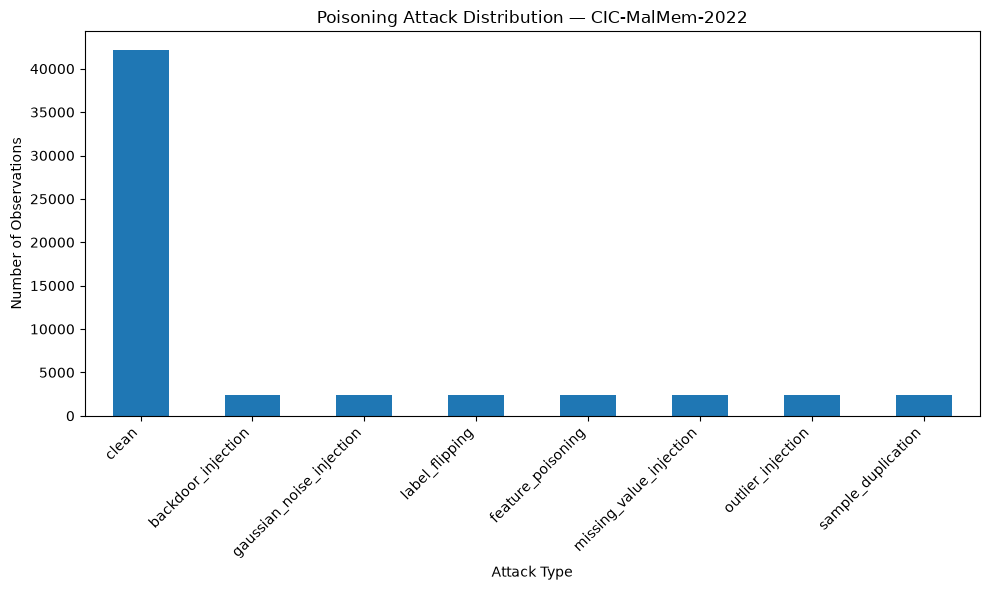

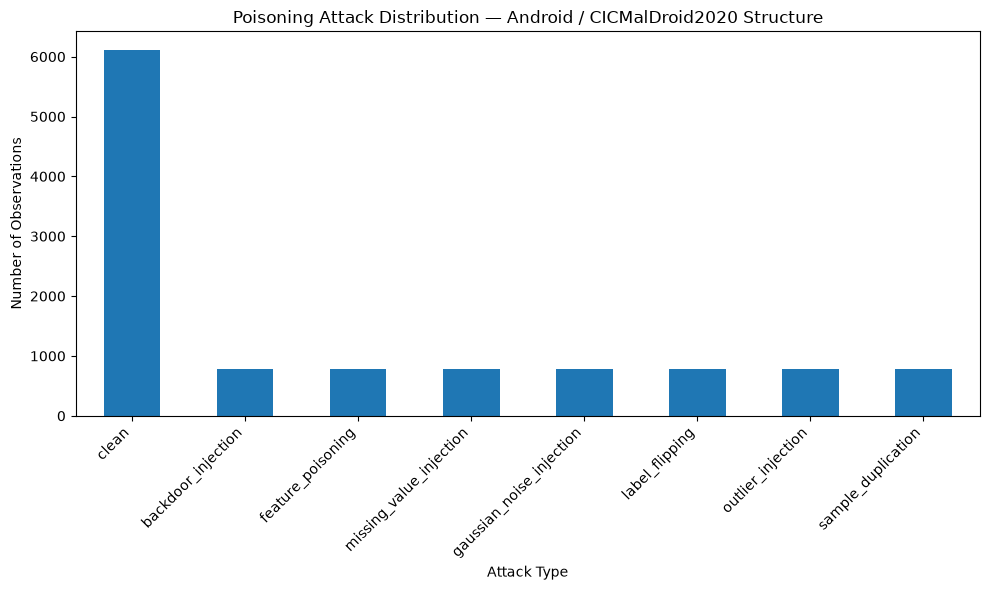

Saved:
- results/figures/fig_attack_distribution_malmem.png
- results/figures/fig_attack_distribution_android.png


In [131]:
print("=" * 70)
print("PHASE 3.4 — ATTACK DISTRIBUTION FIGURES")
print("=" * 70)

def plot_attack_distribution(df, dataset_title, filename):

    counts = df["attack_type"].value_counts()

    plt.figure(figsize=(10, 6))

    counts.plot(kind="bar")

    plt.xlabel("Attack Type")
    plt.ylabel("Number of Observations")
    plt.title(f"Poisoning Attack Distribution — {dataset_title}")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(
        f"results/figures/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


plot_attack_distribution(
    malmem,
    "CIC-MalMem-2022",
    "fig_attack_distribution_malmem.png"
)

plot_attack_distribution(
    android,
    "Android / CICMalDroid2020 Structure",
    "fig_attack_distribution_android.png"
)

print("Saved:")
print("- results/figures/fig_attack_distribution_malmem.png")
print("- results/figures/fig_attack_distribution_android.png")

Class distribution and attack × class relationship

In [132]:
print("=" * 70)
print("PHASE 3.5 — CLASS DISTRIBUTION")
print("=" * 70)

# ---------------------------------------------------------
# Overall class distributions
# ---------------------------------------------------------

malmem_class_distribution = (
    malmem["Class"]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "Class"})
)

malmem_class_distribution["percentage"] = (
    malmem_class_distribution["count"]
    / len(malmem)
    * 100
)

android_class_distribution = (
    android["Class"]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "Class"})
)

android_class_distribution["percentage"] = (
    android_class_distribution["count"]
    / len(android)
    * 100
)

print("MalMem class distribution:")
display(malmem_class_distribution)

print("\nAndroid class distribution:")
display(android_class_distribution)

# ---------------------------------------------------------
# Attack × Class
# ---------------------------------------------------------

malmem_attack_class = pd.crosstab(
    malmem["attack_type"],
    malmem["Class"]
)

android_attack_class = pd.crosstab(
    android["attack_type"],
    android["Class"]
)

print("\nMalMem attack × class:")
display(malmem_attack_class)

print("\nAndroid attack × class:")
display(android_attack_class)

# ---------------------------------------------------------
# Save
# ---------------------------------------------------------

malmem_class_distribution.to_csv(
    "results/tables/table_class_distribution_malmem.csv",
    index=False
)

android_class_distribution.to_csv(
    "results/tables/table_class_distribution_android.csv",
    index=False
)

malmem_attack_class.to_csv(
    "results/tables/table_attack_by_class_malmem.csv"
)

android_attack_class.to_csv(
    "results/tables/table_attack_by_class_android.csv"
)

print("\nClass-distribution artifacts saved.")

PHASE 3.5 — CLASS DISTRIBUTION
MalMem class distribution:


,Class,count,percentage
0,Benign,33982,57.993720
1,Spyware,8418,14.366168
2,Ransomware,8225,14.036794
3,Trojan,7971,13.603318



Android class distribution:


,Class,count,percentage
0,Benign,3361,28.979134
1,SMS malware,3280,28.280738
2,Riskware,2140,18.451457
3,Banking,1764,15.209519
4,Adware,1053,9.079152



MalMem attack × class:


Class,Benign,Ransomware,Spyware,Trojan
attack_type,,,,
backdoor_injection,2342,0,0,0
clean,29298,4310,4413,4181
feature_poisoning,0,783,801,758
gaussian_noise_injection,0,783,801,758
label_flipping,2342,0,0,0
missing_value_injection,0,783,801,758
outlier_injection,0,783,801,758
sample_duplication,0,783,801,758



Android attack × class:


Class,Adware,Banking,Benign,Riskware,SMS malware
attack_type,,,,,
backdoor_injection,0,0,783,0,0
clean,553,924,1795,1125,1720
feature_poisoning,100,168,0,203,312
gaussian_noise_injection,100,168,0,203,312
label_flipping,0,0,783,0,0
missing_value_injection,100,168,0,203,312
outlier_injection,100,168,0,203,312
sample_duplication,100,168,0,203,312



Class-distribution artifacts saved.


Missingness EDA

In [133]:
print("=" * 70)
print("PHASE 3.6 — MISSINGNESS ANALYSIS")
print("=" * 70)

def missingness_table(df, features, dataset_name):

    missing_count = df[features].isna().sum()
    missing_percentage = (
        missing_count / len(df) * 100
    )

    result = pd.DataFrame({
        "dataset": dataset_name,
        "feature": features,
        "missing_count": missing_count.values,
        "missing_percentage": missing_percentage.values
    })

    return (
        result[result["missing_count"] > 0]
        .sort_values("missing_count", ascending=False)
        .reset_index(drop=True)
    )


malmem_missing_eda = missingness_table(
    malmem,
    malmem_eda_features,
    "CIC-MalMem-2022"
)

android_missing_eda = missingness_table(
    android,
    android_eda_features,
    "Android / CICMalDroid2020 structure"
)

print("MalMem features with missing values:")
display(malmem_missing_eda)

print("\nAndroid features with missing values:")
display(android_missing_eda)

malmem_missing_eda.to_csv(
    "results/tables/table_eda_missingness_malmem.csv",
    index=False
)

android_missing_eda.to_csv(
    "results/tables/table_eda_missingness_android.csv",
    index=False
)

print("\nSaved missingness tables.")

PHASE 3.6 — MISSINGNESS ANALYSIS
MalMem features with missing values:


,dataset,feature,missing_count,missing_percentage
0,CIC-MalMem-2022,svcscan.kernel_drivers,970,1.655403
1,CIC-MalMem-2022,malfind.commitCharge,941,1.605912
2,CIC-MalMem-2022,dlllist.ndlls,933,1.592259
3,CIC-MalMem-2022,pslist.avg_handlers,921,1.571780
4,CIC-MalMem-2022,handles.nhandles,919,1.568366



Android features with missing values:


,dataset,feature,missing_count,missing_percentage
0,Android / CICMalDroid2020 structure,clock_gettime,360,3.103983
1,Android / CICMalDroid2020 structure,writev,335,2.888429
2,Android / CICMalDroid2020 structure,sched_yield,322,2.776341
3,Android / CICMalDroid2020 structure,gettimeofday,282,2.431454
4,Android / CICMalDroid2020 structure,read,267,2.302121



Saved missingness tables.


Missingness figure

PHASE 3.7 — MISSINGNESS FIGURES


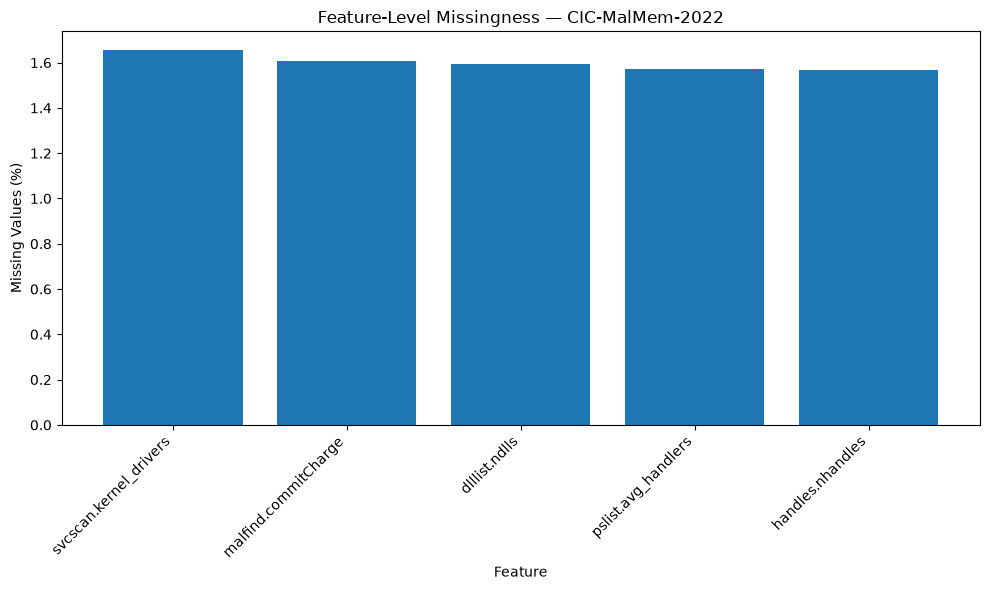

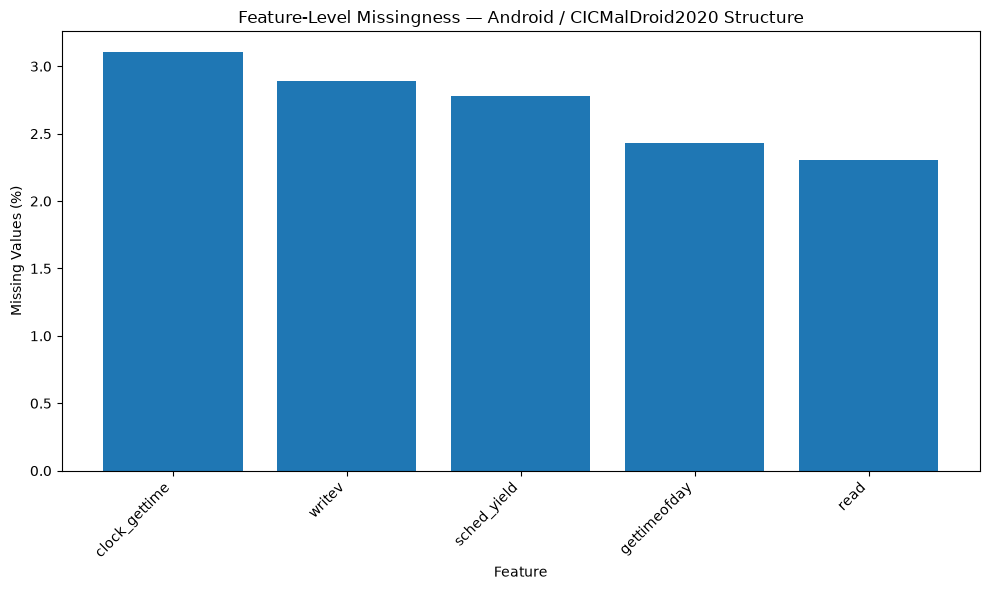

Saved missingness figures.


In [134]:
print("=" * 70)
print("PHASE 3.7 — MISSINGNESS FIGURES")
print("=" * 70)

def plot_missingness(missing_table, dataset_title, filename):

    plt.figure(figsize=(10, 6))

    plt.bar(
        missing_table["feature"],
        missing_table["missing_percentage"]
    )

    plt.xlabel("Feature")
    plt.ylabel("Missing Values (%)")
    plt.title(f"Feature-Level Missingness — {dataset_title}")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig(
        f"results/figures/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


plot_missingness(
    malmem_missing_eda,
    "CIC-MalMem-2022",
    "fig_missingness_malmem.png"
)

plot_missingness(
    android_missing_eda,
    "Android / CICMalDroid2020 Structure",
    "fig_missingness_android.png"
)

print("Saved missingness figures.")

Identify representative distribution features

In [135]:
print("=" * 70)
print("PHASE 3.8 — REPRESENTATIVE FEATURE SELECTION")
print("=" * 70)

def select_eda_features(
    df,
    features,
    top_n=5
):

    numeric = df[features]

    # Variance
    variance = numeric.var(
        numeric_only=True
    ).sort_values(
        ascending=False
    )

    # Absolute skewness
    skewness = numeric.skew().abs().sort_values(
        ascending=False
    )

    # Missingness
    missing = numeric.isna().sum().sort_values(
        ascending=False
    )

    # Attack-group median range
    group_medians = df.groupby(
        "attack_type"
    )[features].median()

    median_range = (
        group_medians.max() - group_medians.min()
    ).sort_values(
        ascending=False
    )

    selected = set()

    selected.update(variance.head(top_n).index)
    selected.update(skewness.head(top_n).index)
    selected.update(missing.head(top_n).index)
    selected.update(median_range.head(top_n).index)

    return {
        "highest_variance": variance.head(top_n).index.tolist(),
        "highest_skewness": skewness.head(top_n).index.tolist(),
        "highest_missingness": missing.head(top_n).index.tolist(),
        "largest_attack_median_range": median_range.head(top_n).index.tolist(),
        "combined_selected": sorted(selected)
    }


malmem_distribution_selection = select_eda_features(
    malmem,
    malmem_eda_features
)

android_distribution_selection = select_eda_features(
    android,
    android_eda_features
)

print("MalMem selected features:")
display(pd.DataFrame({
    key: pd.Series(value)
    for key, value in malmem_distribution_selection.items()
}))

print("\nAndroid selected features:")
display(pd.DataFrame({
    key: pd.Series(value)
    for key, value in android_distribution_selection.items()
}))

print(
    "\nMalMem combined selected:",
    len(malmem_distribution_selection["combined_selected"])
)

print(
    "Android combined selected:",
    len(android_distribution_selection["combined_selected"])
)

PHASE 3.8 — REPRESENTATIVE FEATURE SELECTION
MalMem selected features:


,highest_variance,highest_skewness,highest_missingness,largest_attack_median_range,combined_selected
0,malfind.commitCharge,handles.nfile,svcscan.kernel_drivers,handles.nhandles,callbacks.ngeneric
1,handles.nhandles,handles.avg_handles_per_proc,malfind.commitCharge,dlllist.ndlls,dlllist.ndlls
2,dlllist.ndlls,callbacks.ngeneric,dlllist.ndlls,svcscan.nactive,handles.avg_handles_per_proc
3,handles.nfile,svcscan.fs_drivers,pslist.avg_handlers,pslist.avg_handlers,handles.nevent
4,svcscan.nactive,malfind.commitCharge,handles.nhandles,handles.nevent,handles.nfile
5,NaN,NaN,NaN,NaN,handles.nhandles
6,NaN,NaN,NaN,NaN,malfind.commitCharge
7,NaN,NaN,NaN,NaN,pslist.avg_handlers
8,NaN,NaN,NaN,NaN,svcscan.fs_drivers
9,NaN,NaN,NaN,NaN,svcscan.kernel_drivers



Android selected features:


,highest_variance,highest_skewness,highest_missingness,largest_attack_median_range,combined_selected
0,sched_yield,getPermissionGroupInfo,clock_gettime,sched_yield,clock_gettime
1,gettimeofday,getCurrentInputMethodSubtype,writev,gettimeofday,futex
2,clock_gettime,timer_settime,sched_yield,clock_gettime,getCurrentInputMethodSubtype
3,read,setRadio,gettimeofday,read,getPermissionGroupInfo
4,ioctl,getresgid32,read,futex,getresgid32
5,NaN,NaN,NaN,NaN,gettimeofday
6,NaN,NaN,NaN,NaN,ioctl
7,NaN,NaN,NaN,NaN,read
8,NaN,NaN,NaN,NaN,sched_yield
9,NaN,NaN,NaN,NaN,setRadio



MalMem combined selected: 11
Android combined selected: 12


Selected feature distribution plots

PHASE 3.9 — SELECTED FEATURE DISTRIBUTIONS


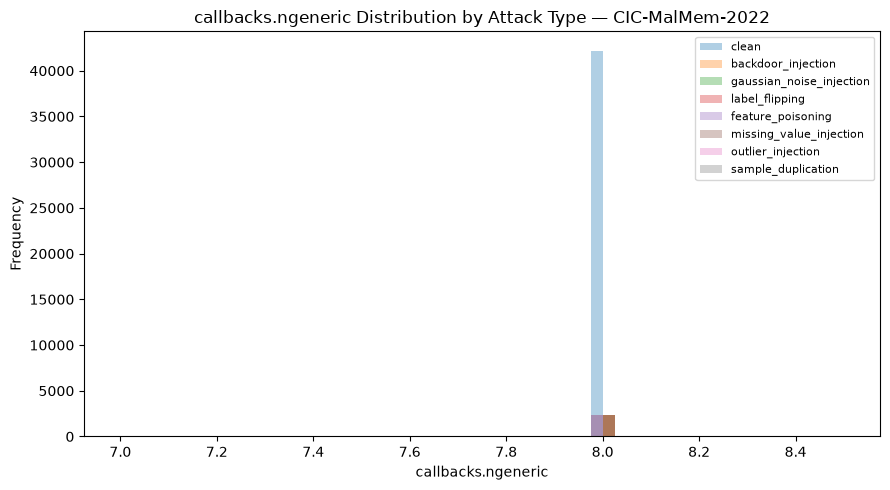

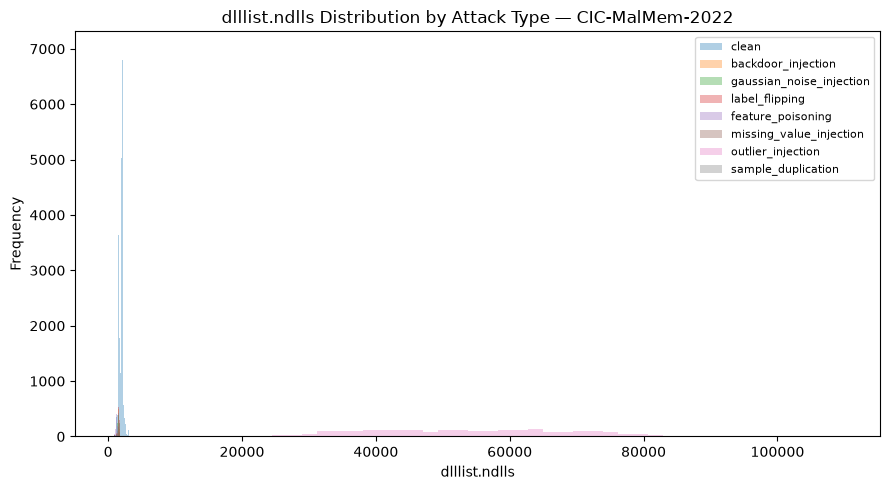

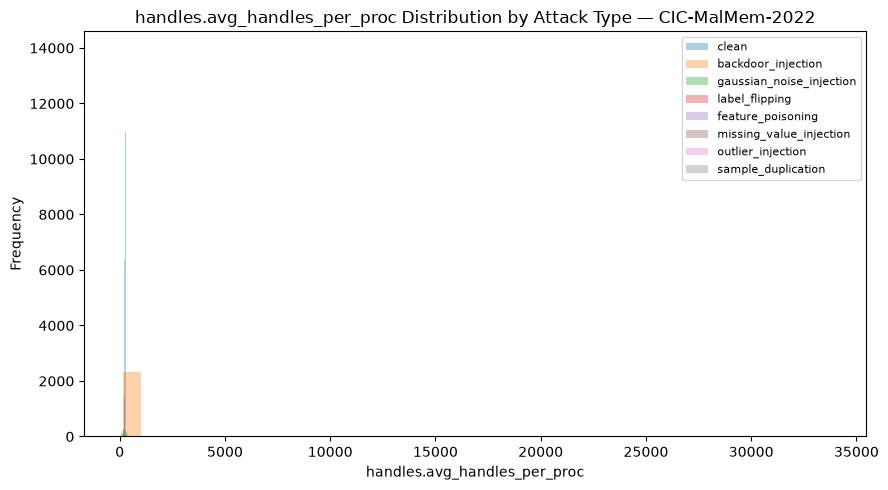

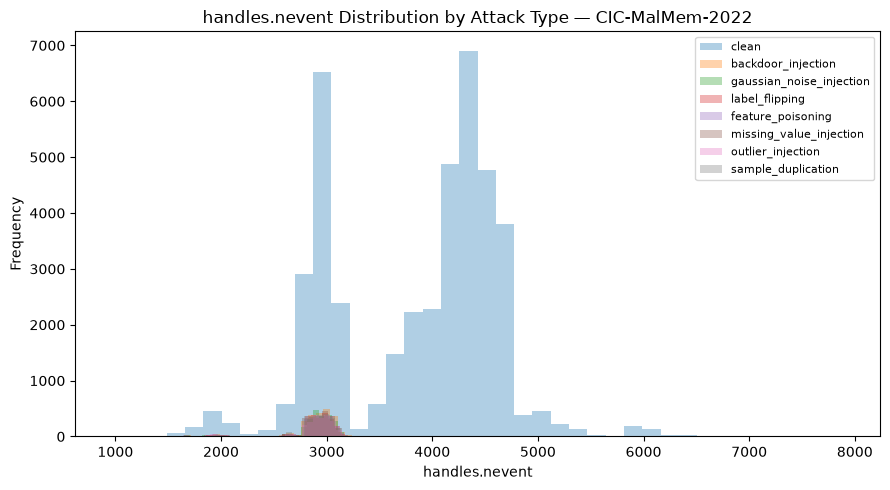

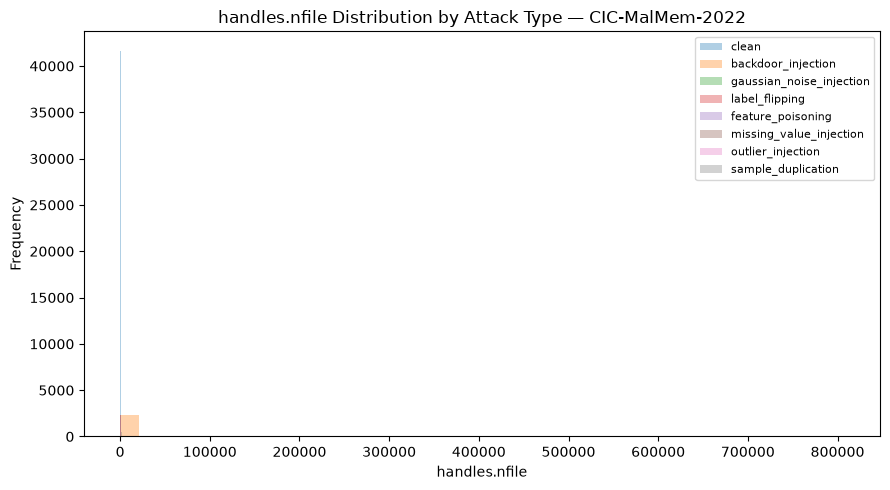

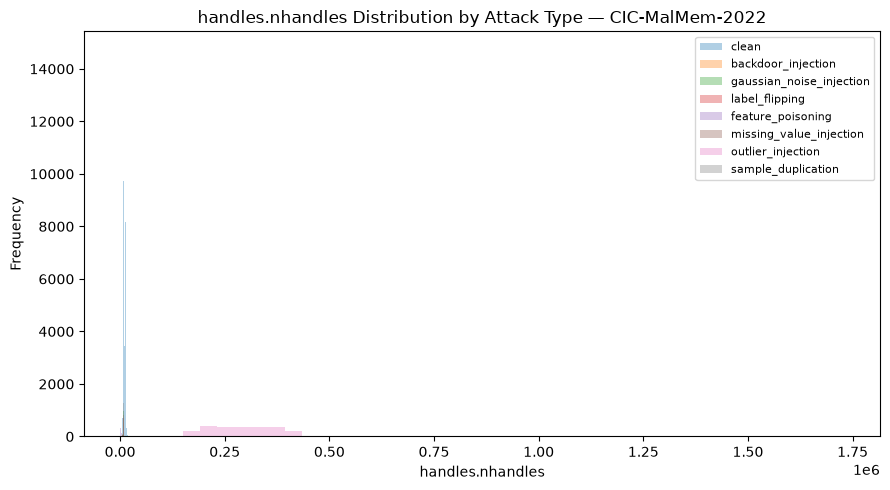

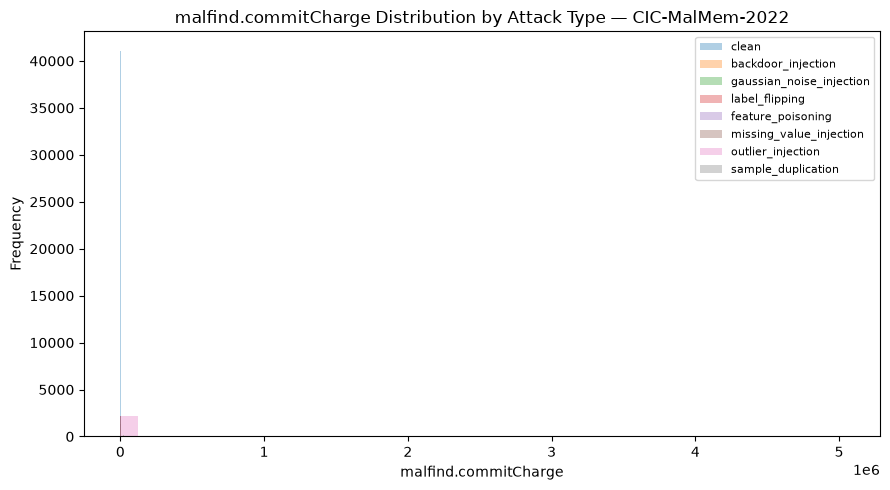

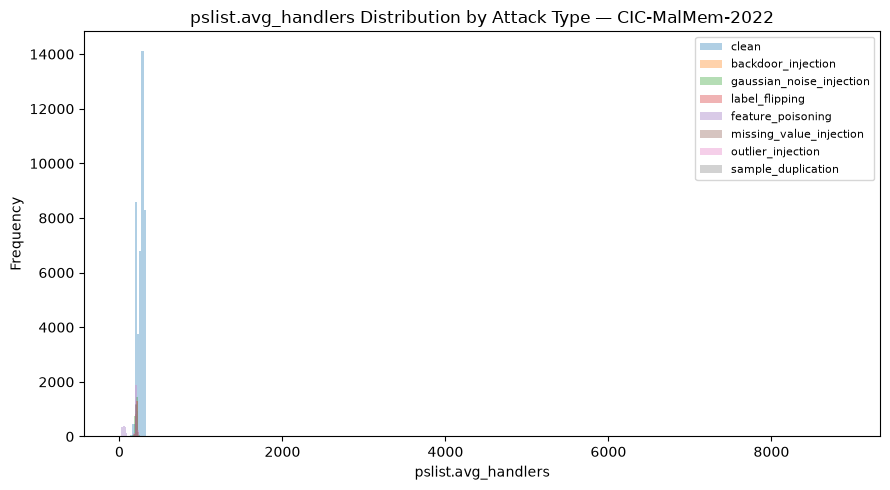

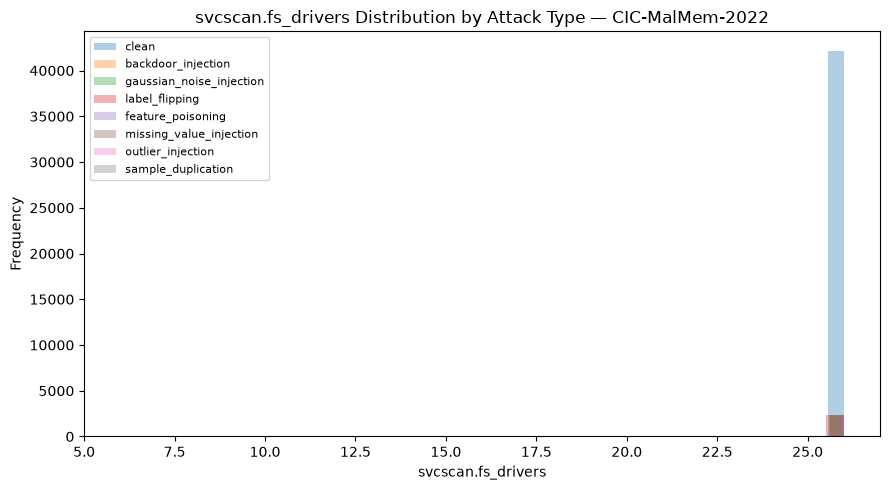

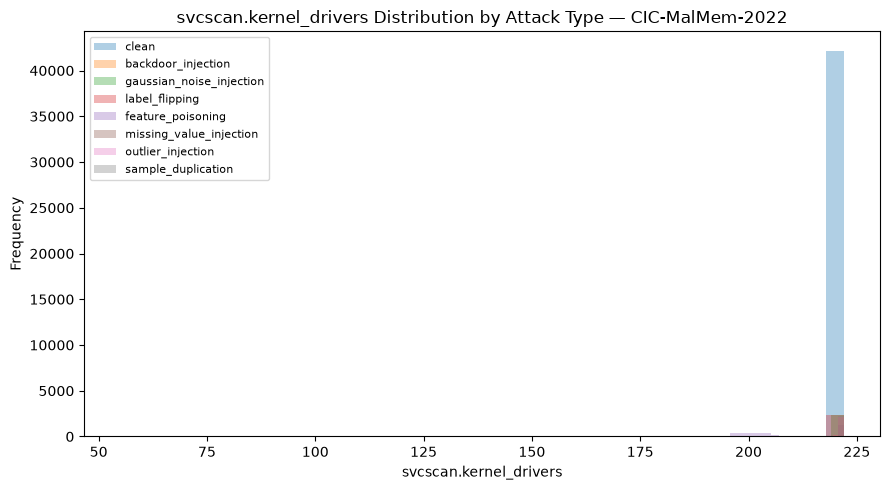

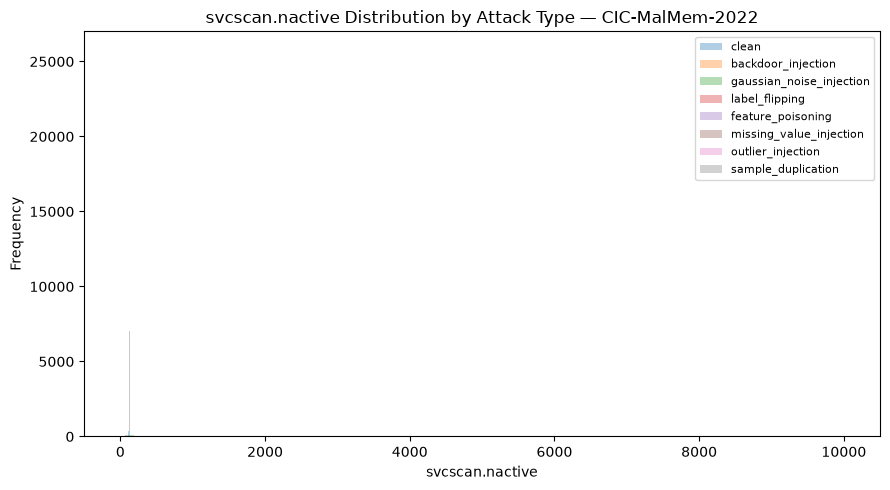

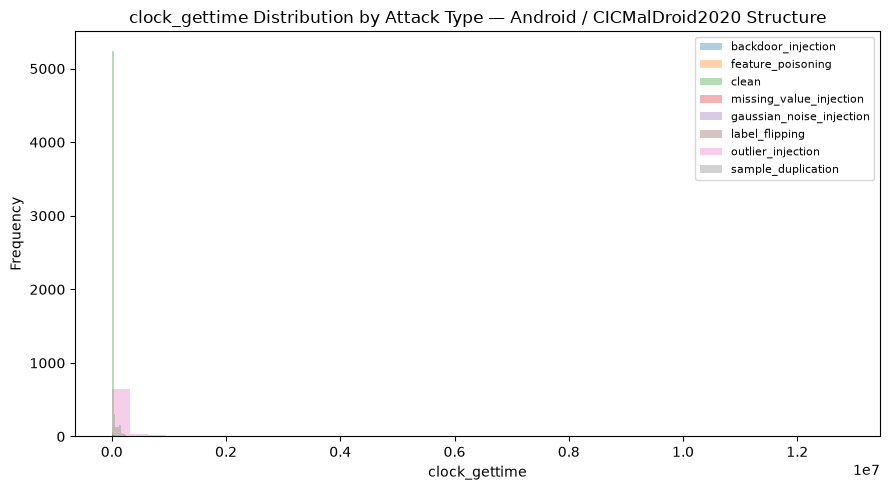

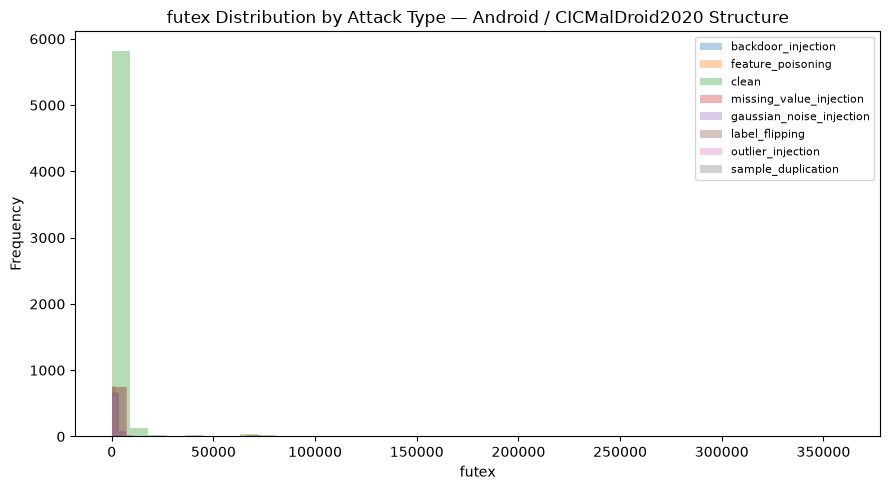

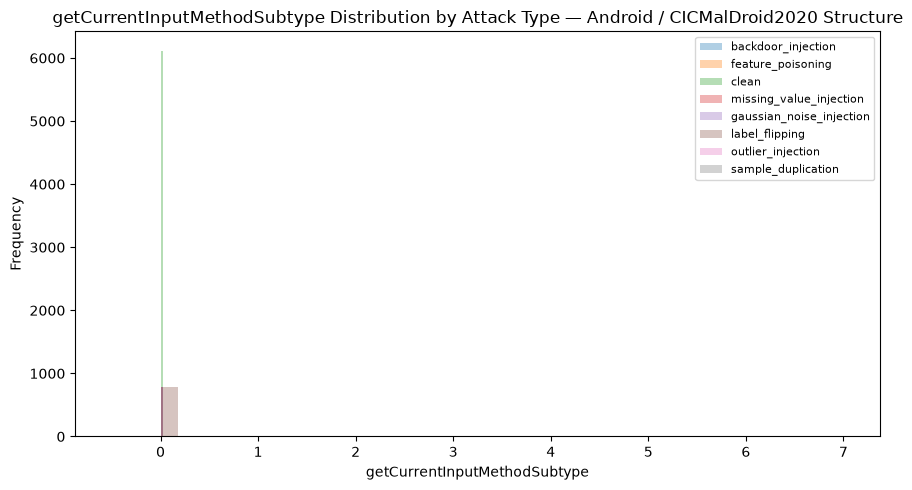

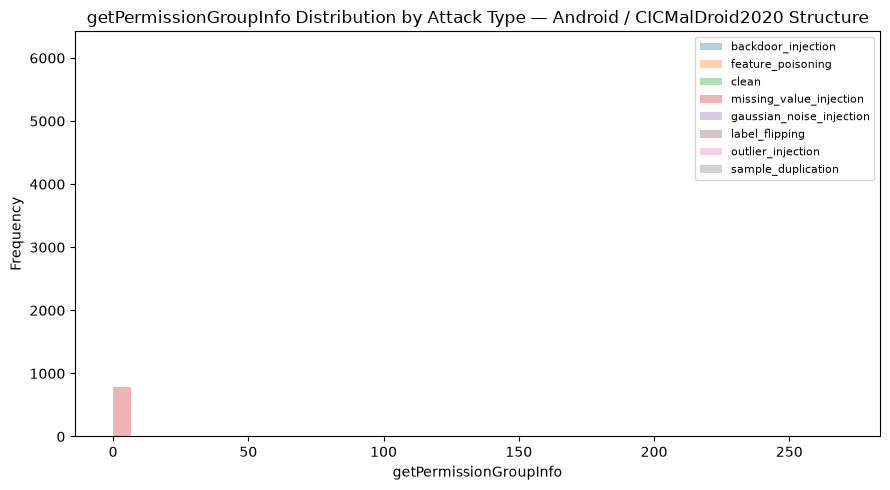

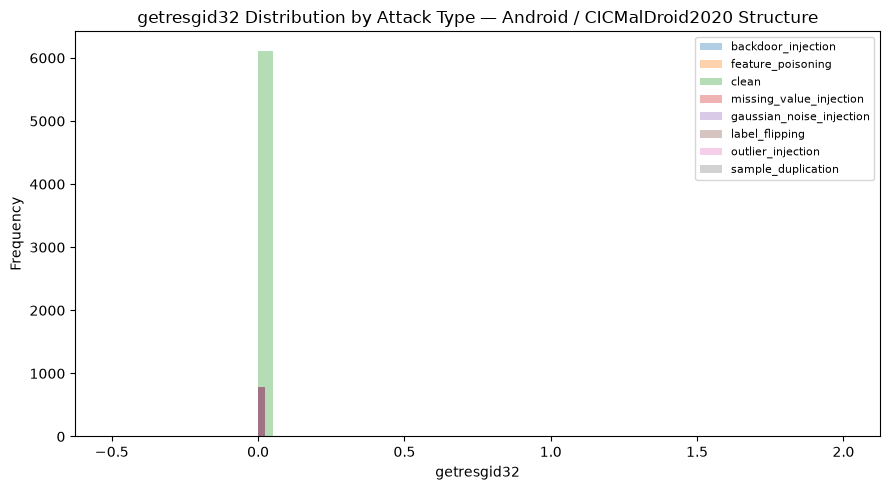

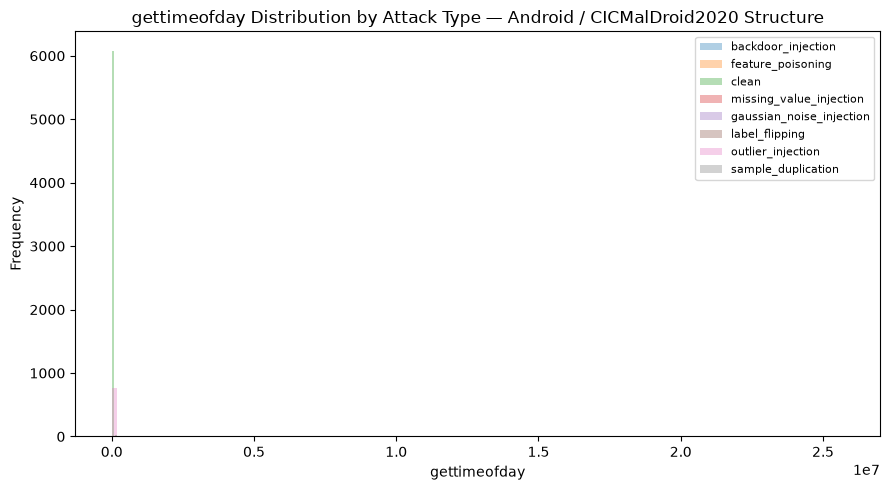

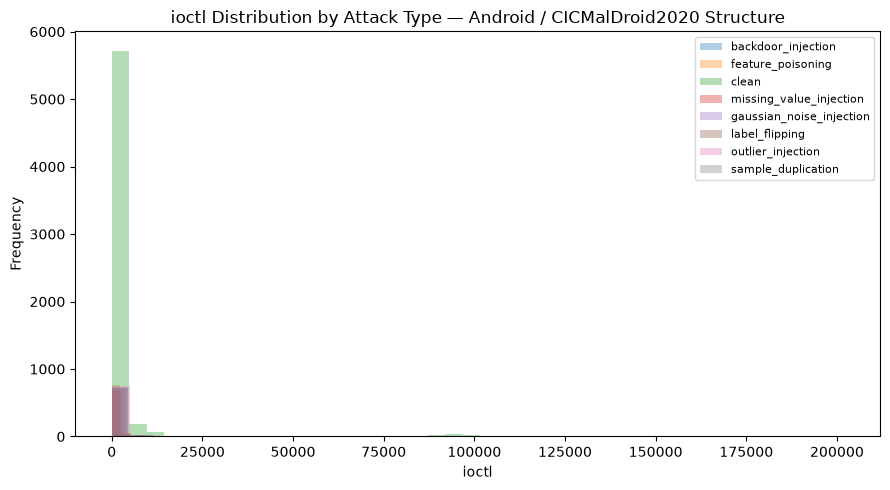

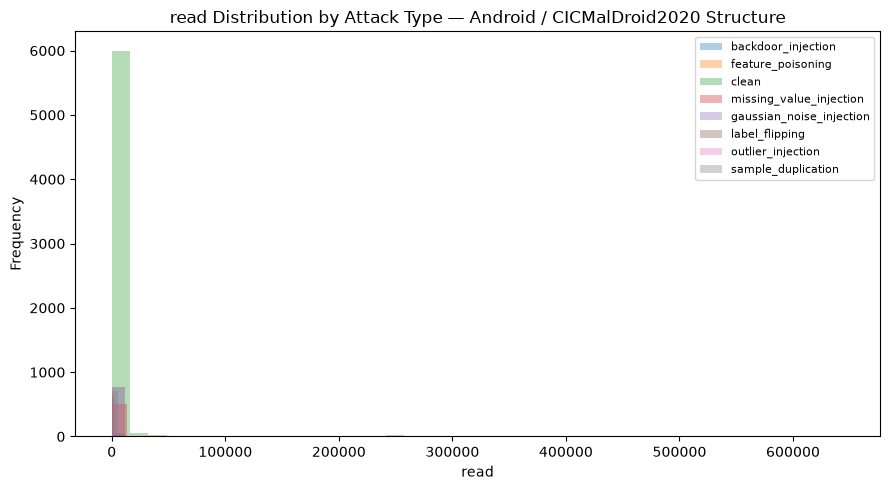

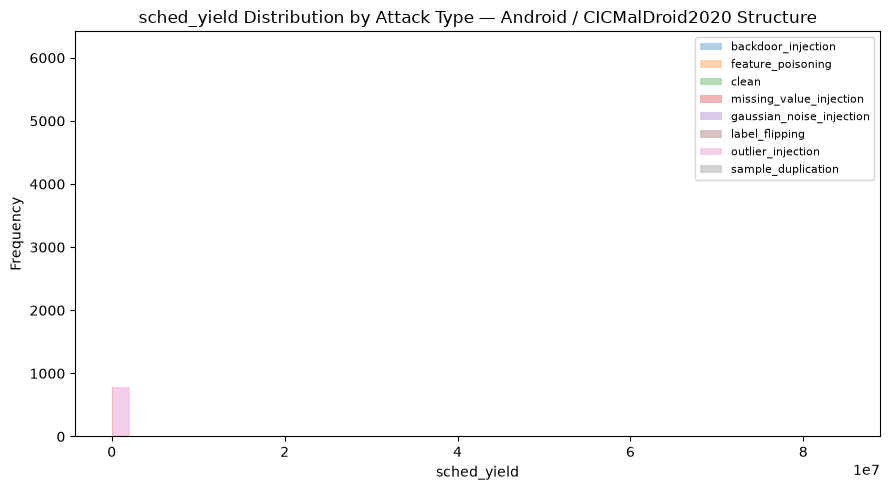

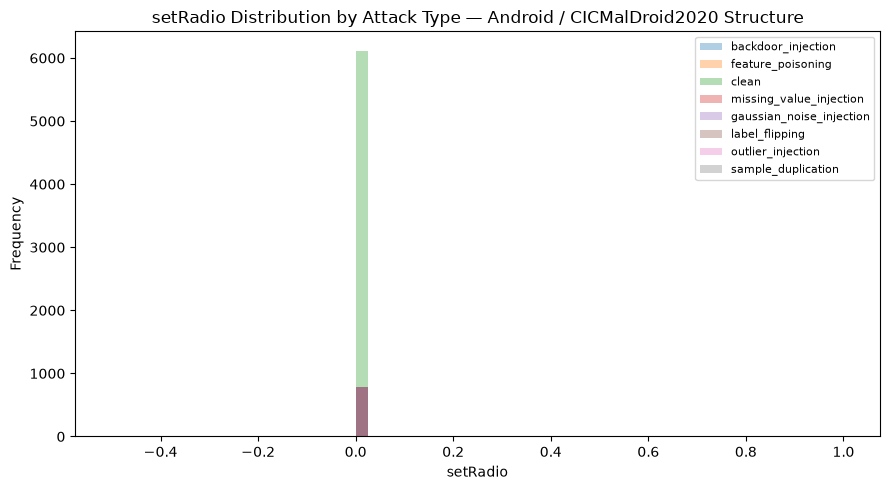

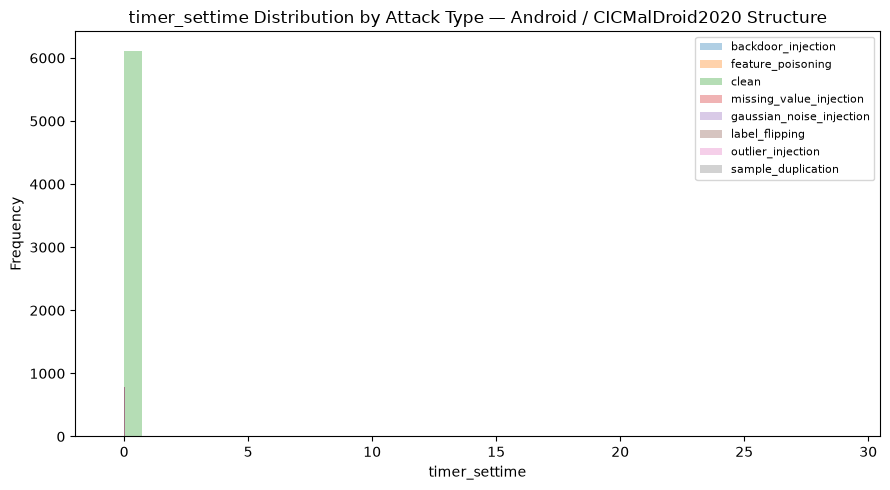

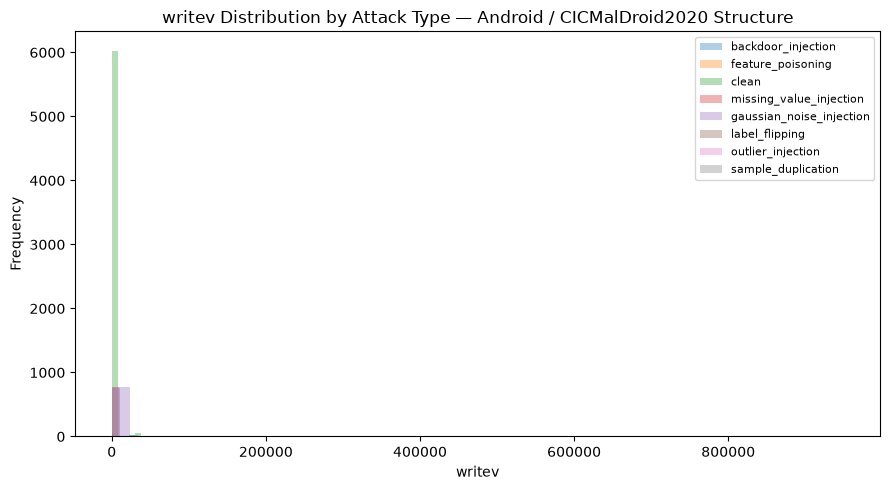


Selected distribution figures generated.


In [136]:
print("=" * 70)
print("PHASE 3.9 — SELECTED FEATURE DISTRIBUTIONS")
print("=" * 70)

def plot_selected_distributions(
    df,
    dataset_title,
    selected_features,
    filename_prefix
):

    for feature in selected_features:

        plt.figure(figsize=(9, 5))

        for attack in df["attack_type"].unique():

            values = df.loc[
                df["attack_type"] == attack,
                feature
            ].dropna()

            if len(values) > 0:
                plt.hist(
                    values,
                    bins=40,
                    alpha=0.35,
                    label=attack
                )

        plt.xlabel(feature)
        plt.ylabel("Frequency")
        plt.title(
            f"{feature} Distribution by Attack Type — "
            f"{dataset_title}"
        )

        plt.legend(
            fontsize=8,
            loc="best"
        )

        plt.tight_layout()

        safe_name = (
            feature
            .replace("/", "_")
            .replace("\\", "_")
            .replace(" ", "_")
        )

        plt.savefig(
            f"results/figures/"
            f"{filename_prefix}_{safe_name}.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()
        plt.close()


plot_selected_distributions(
    malmem,
    "CIC-MalMem-2022",
    malmem_distribution_selection["combined_selected"],
    "fig_distribution_malmem"
)

plot_selected_distributions(
    android,
    "Android / CICMalDroid2020 Structure",
    android_distribution_selection["combined_selected"],
    "fig_distribution_android"
)

print("\nSelected distribution figures generated.")

Group mean and median comparisons

In [137]:
print("=" * 70)
print("PHASE 3.10 — GROUP COMPARISONS")
print("=" * 70)

malmem_group_features = (
    malmem_distribution_selection["combined_selected"]
)

android_group_features = (
    android_distribution_selection["combined_selected"]
)

malmem_group_mean = (
    malmem.groupby("attack_type")[malmem_group_features]
    .mean()
)

malmem_group_median = (
    malmem.groupby("attack_type")[malmem_group_features]
    .median()
)

android_group_mean = (
    android.groupby("attack_type")[android_group_features]
    .mean()
)

android_group_median = (
    android.groupby("attack_type")[android_group_features]
    .median()
)

print("MalMem group means:")
display(malmem_group_mean)

print("\nMalMem group medians:")
display(malmem_group_median)

print("\nAndroid group means:")
display(android_group_mean)

print("\nAndroid group medians:")
display(android_group_median)

malmem_group_mean.to_csv(
    "results/tables/table_group_means_malmem.csv"
)

malmem_group_median.to_csv(
    "results/tables/table_group_medians_malmem.csv"
)

android_group_mean.to_csv(
    "results/tables/table_group_means_android.csv"
)

android_group_median.to_csv(
    "results/tables/table_group_medians_android.csv"
)

print("\nGroup comparison tables saved.")

PHASE 3.10 — GROUP COMPARISONS
MalMem group means:


,callbacks.ngeneric,dlllist.ndlls,handles.avg_handles_per_proc,handles.nevent,handles.nfile,handles.nhandles,malfind.commitCharge,pslist.avg_handlers,svcscan.fs_drivers,svcscan.kernel_drivers,svcscan.nactive
attack_type,,,,,,,,,,,
backdoor_injection,8.000000,1537.997011,225.260511,2866.478224,1059.902647,7777.000000,1744.427412,8888.000000,25.991887,220.789069,9999.000000
clean,7.999882,1916.391024,263.680891,3846.607033,950.809654,10971.929695,613.408322,261.808539,25.997820,221.633074,122.708710
feature_poisoning,7.999573,1233.435098,211.785245,2852.181042,735.618275,2102.429825,544.273943,53.060445,25.997011,200.939368,120.102904
gaussian_noise_injection,8.000000,1542.520068,211.448920,2874.706661,711.297609,8372.201110,1843.504697,209.117456,25.989752,220.816823,120.347948
label_flipping,8.000000,1541.017506,210.355929,2870.890265,685.114005,8336.793766,1805.694278,208.595353,25.988044,220.813407,120.183604
missing_value_injection,8.000000,1536.778566,211.494637,2873.797182,718.739539,8380.775123,1829.038544,209.452147,25.989325,220.849125,120.189155
outlier_injection,7.999573,53519.544539,211.642156,2862.272844,745.223740,292868.064290,67256.415511,209.517745,25.993595,220.813834,120.133219
sample_duplication,7.999573,1538.754910,211.281458,2869.527327,717.219044,8364.533305,1903.547395,209.390222,25.996157,220.868915,120.183604



MalMem group medians:


,callbacks.ngeneric,dlllist.ndlls,handles.avg_handles_per_proc,handles.nevent,handles.nfile,handles.nhandles,malfind.commitCharge,pslist.avg_handlers,svcscan.fs_drivers,svcscan.kernel_drivers,svcscan.nactive
attack_type,,,,,,,,,,,
backdoor_injection,8.0,1558.000000,209.529623,2928.0,646.0,7777.000000,3.000000,8888.000000,26.0,221.0,9999.000000
clean,8.0,2012.000000,279.611129,4112.0,1042.0,11746.000000,5.000000,277.890786,26.0,222.0,123.000000
feature_poisoning,8.0,1254.000000,209.812695,2924.0,646.0,2082.374521,0.806746,52.604234,26.0,201.0,121.000000
gaussian_noise_injection,8.0,1557.000000,209.128481,2925.0,646.0,8419.000000,3.000000,208.626453,26.0,221.0,119.096718
label_flipping,8.0,1557.000000,209.837711,2923.0,645.0,8392.500000,3.000000,208.890476,26.0,221.0,121.000000
missing_value_injection,8.0,1558.000000,210.036630,2924.0,646.0,8439.000000,3.000000,208.825000,26.0,221.0,121.000000
outlier_injection,8.0,53353.579865,209.500000,2927.0,646.0,286867.620850,112.445483,208.700000,26.0,221.0,121.000000
sample_duplication,8.0,1556.000000,209.666667,2923.0,646.0,8392.000000,3.000000,208.675000,26.0,221.0,121.000000



Android group means:


,clock_gettime,futex,getCurrentInputMethodSubtype,getPermissionGroupInfo,getresgid32,gettimeofday,ioctl,read,sched_yield,setRadio,timer_settime,writev
attack_type,,,,,,,,,,,,
backdoor_injection,1.280783e+07,3254.542784,0.00000,0.000000,0.000000,2.571852e+07,3245.641124,2513.731801,3.697410e+07,0.001277,0.000000,1425.250319
clean,1.930969e+04,3515.969429,0.00000,0.000000,0.000327,2.558458e+03,2910.753801,3399.045774,1.268726e+01,0.000000,0.004741,673.422593
feature_poisoning,1.619337e+04,812.870306,0.00000,0.000000,0.000000,1.212277e+03,1262.817369,592.130249,4.726610e+03,0.000000,0.000000,681.743694
gaussian_noise_injection,1.417317e+04,3305.790549,0.00000,0.000000,0.000000,1.588318e+03,3454.650064,1785.918263,2.166028e+00,0.000000,0.000000,2372.312899
label_flipping,1.533362e+04,3654.957854,0.00894,0.000000,0.000000,3.630211e+03,3426.513410,2051.545338,2.097227e+03,0.000000,0.000000,877.394636
missing_value_injection,1.364406e+04,3724.848020,0.00000,0.344828,0.000000,2.240255e+03,3647.971903,3086.486434,7.635575e+00,0.000000,0.000000,1085.982143
outlier_injection,4.891986e+05,2210.664112,0.00000,0.000000,0.000000,6.401696e+04,2577.735632,2298.256705,1.081921e+05,0.000000,0.000000,1093.037037
sample_duplication,1.387391e+04,4003.553001,0.00000,0.000000,0.000000,1.930269e+03,4187.137931,2460.137931,2.287356e+00,0.000000,0.000000,856.784163



Android group medians:


,clock_gettime,futex,getCurrentInputMethodSubtype,getPermissionGroupInfo,getresgid32,gettimeofday,ioctl,read,sched_yield,setRadio,timer_settime,writev
attack_type,,,,,,,,,,,,
backdoor_injection,1.280783e+07,289.000000,0.0,0.0,0.0,2.571852e+07,233.0,312.000000,3.697410e+07,0.0,0.0,34.000000
clean,1.455000e+03,555.000000,0.0,0.0,0.0,1.400000e+02,370.0,591.000000,2.000000e+00,0.0,0.0,58.000000
feature_poisoning,1.073000e+03,72.248011,0.0,0.0,0.0,2.400000e+01,0.0,90.783676,1.000000e+00,0.0,0.0,7.980414
gaussian_noise_injection,1.075000e+03,287.000000,0.0,0.0,0.0,2.700000e+01,244.0,325.000000,1.000000e+00,0.0,0.0,31.000000
label_flipping,1.092000e+03,307.000000,0.0,0.0,0.0,3.900000e+01,251.0,450.000000,1.000000e+00,0.0,0.0,36.000000
missing_value_injection,1.032000e+03,280.000000,0.0,0.0,0.0,3.600000e+01,244.0,570.000000,1.000000e+00,0.0,0.0,31.500000
outlier_injection,2.968336e+04,284.000000,0.0,0.0,0.0,1.091556e+03,248.0,389.000000,4.485628e+01,0.0,0.0,32.000000
sample_duplication,9.420000e+02,286.000000,0.0,0.0,0.0,3.600000e+01,235.0,519.000000,1.000000e+00,0.0,0.0,35.000000



Group comparison tables saved.


Correlation analysis

In [138]:
print("=" * 70)
print("PHASE 3.11 — CORRELATION ANALYSIS")
print("=" * 70)

# Use final modeling features rather than metadata/constants
malmem_corr_features = malmem_anomaly_features
android_corr_features = android_anomaly_features

print("MalMem correlation features:", len(malmem_corr_features))
print("Android correlation features:", len(android_corr_features))

# ---------------------------------------------------------
# MalMem
# ---------------------------------------------------------

malmem_corr = malmem[malmem_corr_features].corr()

malmem_corr.to_csv(
    "results/tables/table_correlation_malmem.csv"
)

# ---------------------------------------------------------
# Android
# ---------------------------------------------------------

android_corr = android[android_corr_features].corr()

android_corr.to_csv(
    "results/tables/table_correlation_android.csv"
)

# ---------------------------------------------------------
# Extract strongest absolute correlations
# ---------------------------------------------------------

def strongest_correlations(corr_matrix, top_n=30):

    matrix = corr_matrix.abs().copy()

    upper = matrix.where(
        np.triu(
            np.ones(matrix.shape),
            k=1
        ).astype(bool)
    )

    pairs = (
        upper.stack()
        .sort_values(ascending=False)
        .head(top_n)
        .reset_index()
    )

    pairs.columns = [
        "feature_1",
        "feature_2",
        "absolute_correlation"
    ]

    return pairs


malmem_strong_corr = strongest_correlations(
    malmem_corr,
    top_n=30
)

android_strong_corr = strongest_correlations(
    android_corr,
    top_n=30
)

print("\nStrongest MalMem correlations:")
display(malmem_strong_corr)

print("\nStrongest Android correlations:")
display(android_strong_corr)

malmem_strong_corr.to_csv(
    "results/tables/table_strongest_correlations_malmem.csv",
    index=False
)

android_strong_corr.to_csv(
    "results/tables/table_strongest_correlations_android.csv",
    index=False
)

print("\nCorrelation tables saved.")

PHASE 3.11 — CORRELATION ANALYSIS
MalMem correlation features: 52
Android correlation features: 468

Strongest MalMem correlations:


,feature_1,feature_2,absolute_correlation
0,ldrmodules.not_in_load,ldrmodules.not_in_mem,0.999994
1,psxview.not_in_pslist,psxview.not_in_session,0.999987
2,ldrmodules.not_in_load_avg,ldrmodules.not_in_mem_avg,0.999979
3,malfind.ninjections,malfind.protection,0.999955
4,psxview.not_in_ethread_pool,psxview.not_in_csrss_handles,0.999886
5,pslist.avg_handlers,svcscan.nactive,0.999406
6,psxview.not_in_pslist_false_avg,psxview.not_in_session_false_avg,0.993927
7,psxview.not_in_pslist,psxview.not_in_pspcid_list,0.990633
8,psxview.not_in_pspcid_list,psxview.not_in_session,0.990623
9,psxview.not_in_csrss_handles,psxview.not_in_deskthrd,0.986024



Strongest Android correlations:


,feature_1,feature_2,absolute_correlation
0,beginRestoreSession,endRestoreSession,1.0
1,isSyncActive,removeStatusChangeListener,1.0
2,beginRestoreSession,restorePackage,1.0
3,setPlaybackState,setTransportControlInfo,1.0
4,setgid32,setuid32,1.0
5,fstatfs64,timer_create,1.0
6,isBluetoothA2dpOn,startWatchingRoutes,1.0
7,capset,setgroups32,1.0
8,setMetadata,setTransportControlInfo,1.0
9,setMetadata,setPlaybackState,1.0



Correlation tables saved.


Correlation figures

PHASE 3.12 — CORRELATION FIGURES


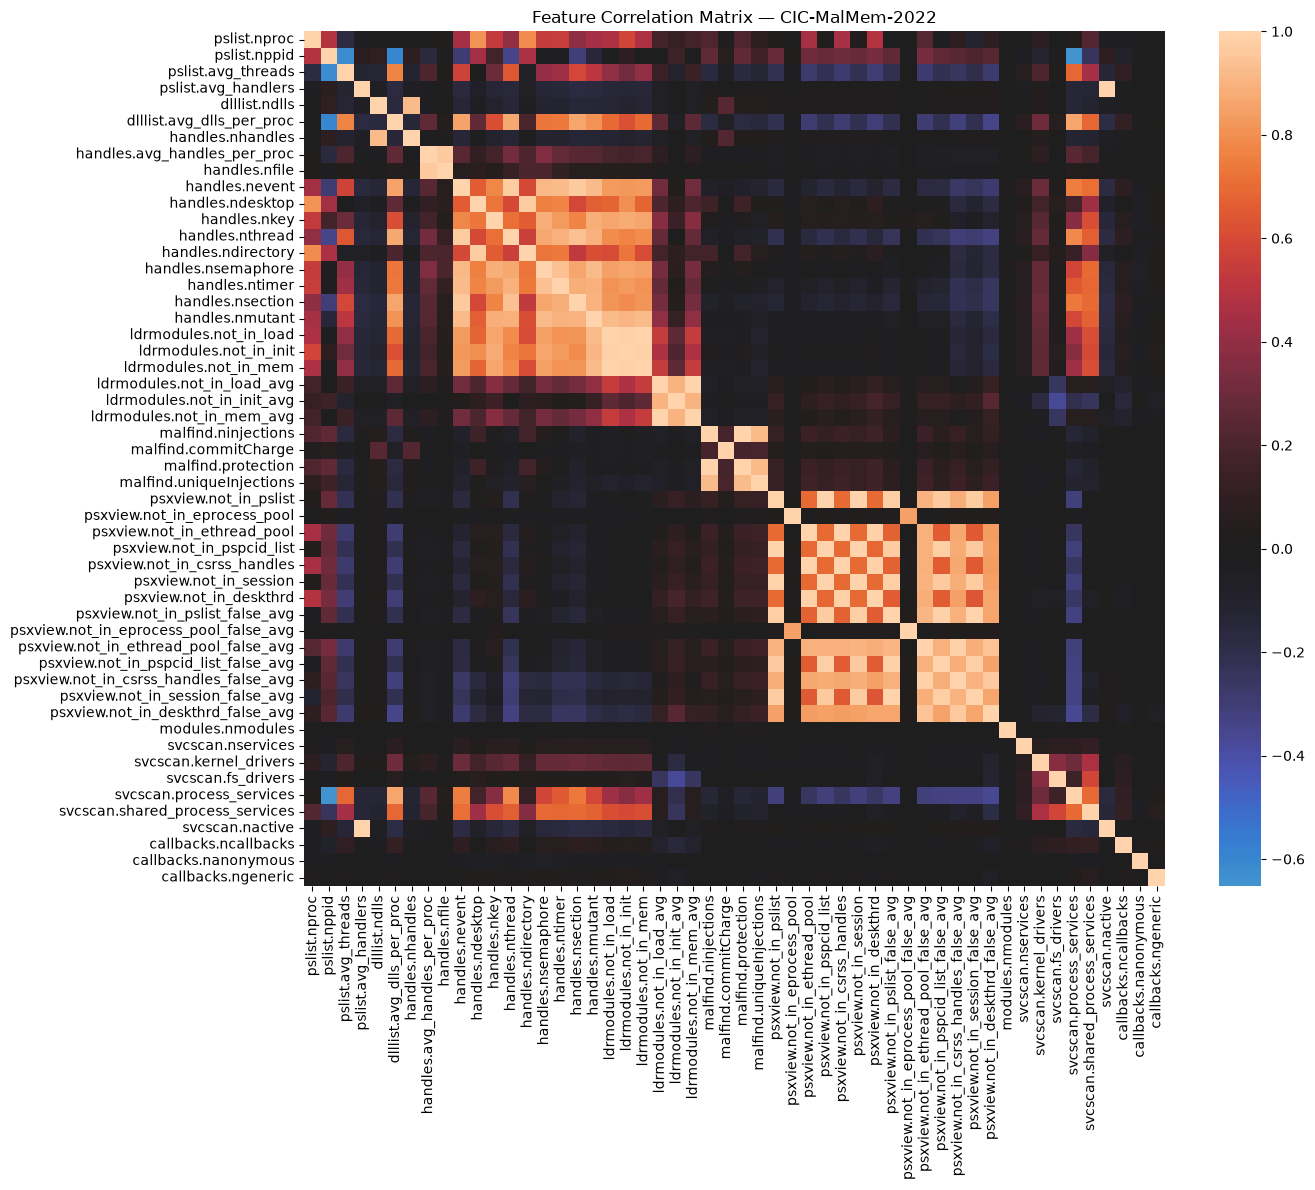

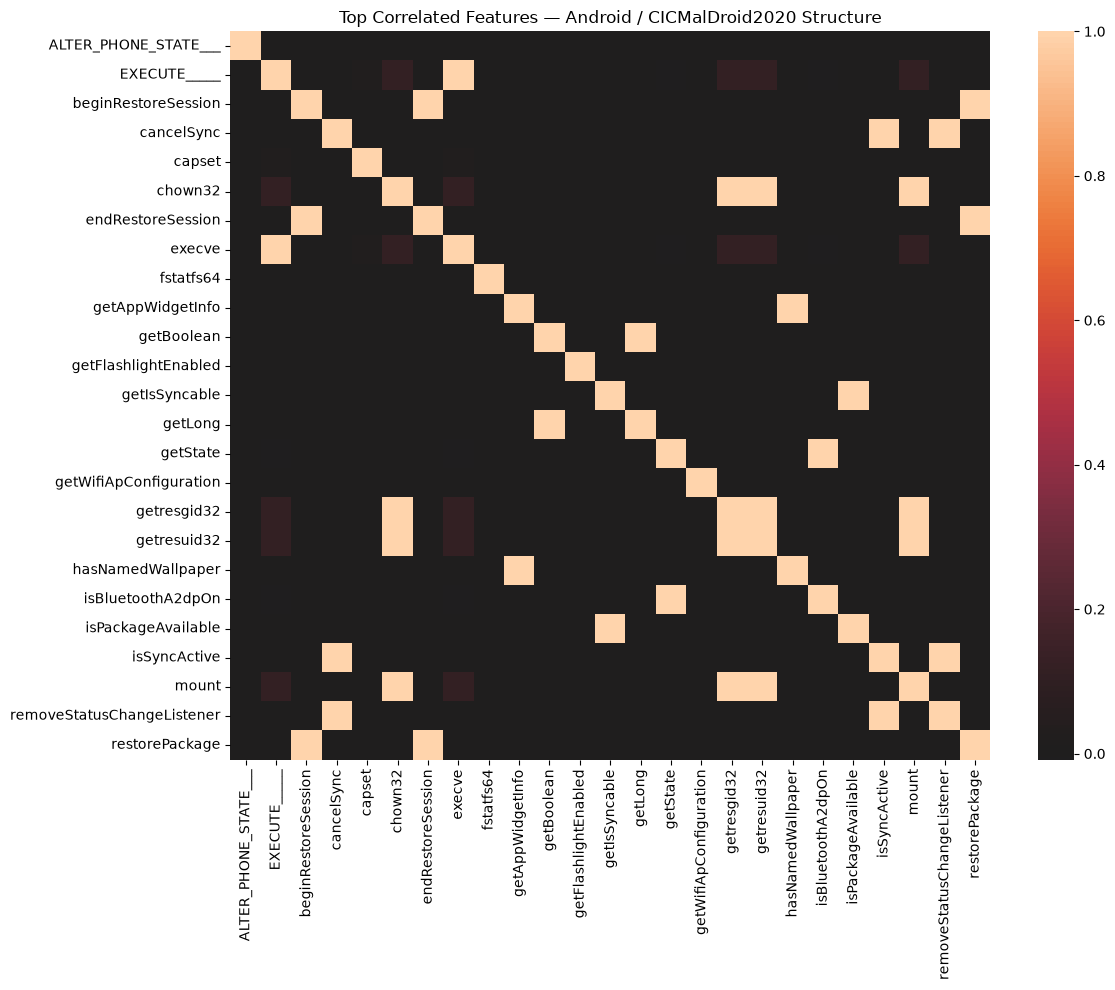

Saved:
- results/figures/fig_correlation_malmem.png
- results/figures/fig_correlation_android_top.png


In [139]:
print("=" * 70)
print("PHASE 3.12 — CORRELATION FIGURES")
print("=" * 70)

import seaborn as sns

# ---------------------------------------------------------
# MalMem full correlation heatmap
# ---------------------------------------------------------

plt.figure(figsize=(14, 12))

sns.heatmap(
    malmem_corr,
    center=0
)

plt.title(
    "Feature Correlation Matrix — CIC-MalMem-2022"
)

plt.tight_layout()

plt.savefig(
    "results/figures/fig_correlation_malmem.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

# ---------------------------------------------------------
# Android top-correlation feature heatmap
# ---------------------------------------------------------

top_android_features = sorted(
    set(
        android_strong_corr["feature_1"]
    ).union(
        android_strong_corr["feature_2"]
    )
)

# Keep figure readable
top_android_features = top_android_features[:25]

android_top_corr = android[
    top_android_features
].corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    android_top_corr,
    center=0
)

plt.title(
    "Top Correlated Features — "
    "Android / CICMalDroid2020 Structure"
)

plt.tight_layout()

plt.savefig(
    "results/figures/fig_correlation_android_top.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

print("Saved:")
print("- results/figures/fig_correlation_malmem.png")
print("- results/figures/fig_correlation_android_top.png")

EDA consistency checks against Phase 2

In [151]:
print("=" * 70)
print("PHASE 3.13 — EDA CONSISTENCY VALIDATION — FINAL FIX")
print("=" * 70)

# =========================================================
# Expected attack counts
# =========================================================

expected_malmem = {
    "clean": 42202,
    "backdoor_injection": 2342,
    "feature_poisoning": 2342,
    "label_flipping": 2342,
    "missing_value_injection": 2342,
    "sample_duplication": 2342,
    "outlier_injection": 2342,
    "gaussian_noise_injection": 2342
}

expected_android = {
    "clean": 6117,
    "backdoor_injection": 783,
    "feature_poisoning": 783,
    "label_flipping": 783,
    "missing_value_injection": 783,
    "sample_duplication": 783,
    "outlier_injection": 783,
    "gaussian_noise_injection": 783
}


# =========================================================
# Actual attack counts
# =========================================================

actual_malmem = malmem["attack_type"].value_counts().to_dict()
actual_android = android["attack_type"].value_counts().to_dict()


# =========================================================
# Attack distribution checks
# =========================================================

malmem_attack_pass = True

for attack, expected_count in expected_malmem.items():
    actual_count = actual_malmem.get(attack, 0)

    if actual_count != expected_count:
        malmem_attack_pass = False
        print(
            f"MalMem mismatch: {attack} | "
            f"Expected={expected_count} | "
            f"Actual={actual_count}"
        )


android_attack_pass = True

for attack, expected_count in expected_android.items():
    actual_count = actual_android.get(attack, 0)

    if actual_count != expected_count:
        android_attack_pass = False
        print(
            f"Android mismatch: {attack} | "
            f"Expected={expected_count} | "
            f"Actual={actual_count}"
        )


# =========================================================
# Row-count checks
# =========================================================

malmem_rows_pass = len(malmem) == 58596
android_rows_pass = len(android) == 11598


# =========================================================
# Feature-count checks
# =========================================================

malmem_feature_pass = len(malmem_eda_features) == 55
android_feature_pass = len(android_eda_features) == 470


# =========================================================
# Missingness checks
# =========================================================

malmem_missing_total = int(
    malmem[malmem_eda_features].isna().sum().sum()
)

android_missing_total = int(
    android[android_eda_features].isna().sum().sum()
)

malmem_missing_pass = malmem_missing_total == 4684
android_missing_pass = android_missing_total == 1566


# =========================================================
# Print attack distributions
# =========================================================

print("\nMalMem attack counts:")
for attack in expected_malmem:
    print(
        f"{attack:35s} "
        f"Expected={expected_malmem[attack]:5d} "
        f"Actual={actual_malmem.get(attack, 0):5d}"
    )

print("\nAndroid attack counts:")
for attack in expected_android:
    print(
        f"{attack:35s} "
        f"Expected={expected_android[attack]:5d} "
        f"Actual={actual_android.get(attack, 0):5d}"
    )


# =========================================================
# Validation table
# =========================================================

eda_validation = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "rows": len(malmem),
        "rows_pass": malmem_rows_pass,
        "eda_features": len(malmem_eda_features),
        "feature_count_pass": malmem_feature_pass,
        "missing_cells": malmem_missing_total,
        "missingness_pass": malmem_missing_pass,
        "attack_distribution_pass": malmem_attack_pass
    },
    {
        "dataset": "Android / CICMalDroid2020 structure",
        "rows": len(android),
        "rows_pass": android_rows_pass,
        "eda_features": len(android_eda_features),
        "feature_count_pass": android_feature_pass,
        "missing_cells": android_missing_total,
        "missingness_pass": android_missing_pass,
        "attack_distribution_pass": android_attack_pass
    }
])


# =========================================================
# Phase 3.13 gate
# =========================================================

eda_validation["PHASE_3_13_PASS"] = (
    eda_validation["rows_pass"]
    & eda_validation["feature_count_pass"]
    & eda_validation["missingness_pass"]
    & eda_validation["attack_distribution_pass"]
)

print("\n" + "=" * 70)
print("FINAL EDA CONSISTENCY TABLE")
print("=" * 70)

display(eda_validation)


# =========================================================
# Save artifact
# =========================================================

eda_validation.to_csv(
    "results/tables/table_eda_consistency_validation.csv",
    index=False
)

print("\nSaved:")
print("results/tables/table_eda_consistency_validation.csv")


# =========================================================
# Final result
# =========================================================

PHASE_3_13_PASS = bool(
    eda_validation["PHASE_3_13_PASS"].all()
)

print("\n" + "=" * 70)
print("PHASE_3_13_PASS =", PHASE_3_13_PASS)
print("=" * 70)

assert PHASE_3_13_PASS

PHASE 3.13 — EDA CONSISTENCY VALIDATION — FINAL FIX

MalMem attack counts:
clean                               Expected=42202 Actual=42202
backdoor_injection                  Expected= 2342 Actual= 2342
feature_poisoning                   Expected= 2342 Actual= 2342
label_flipping                      Expected= 2342 Actual= 2342
missing_value_injection             Expected= 2342 Actual= 2342
sample_duplication                  Expected= 2342 Actual= 2342
outlier_injection                   Expected= 2342 Actual= 2342
gaussian_noise_injection            Expected= 2342 Actual= 2342

Android attack counts:
clean                               Expected= 6117 Actual= 6117
backdoor_injection                  Expected=  783 Actual=  783
feature_poisoning                   Expected=  783 Actual=  783
label_flipping                      Expected=  783 Actual=  783
missing_value_injection             Expected=  783 Actual=  783
sample_duplication                  Expected=  783 Actual=  783
outli

,dataset,rows,rows_pass,eda_features,feature_count_pass,missing_cells,missingness_pass,attack_distribution_pass,PHASE_3_13_PASS
0,CIC-MalMem-2022,58596,True,55,True,4684,True,True,True
1,Android / CICMalDroid2020 structure,11598,True,470,True,1566,True,True,True



Saved:
results/tables/table_eda_consistency_validation.csv

PHASE_3_13_PASS = True


Verify that EDA did not modify the datasets

In [152]:
print("=" * 70)
print("PHASE 3.14 — RAW DATA PRESERVATION CHECK — CORRECTED")
print("=" * 70)


# ---------------------------------------------------------
# Expected original dataset dimensions
# ---------------------------------------------------------

EXPECTED_MALMEM_ROWS = 58596
EXPECTED_MALMEM_COLS = 59

EXPECTED_ANDROID_ROWS = 11598
EXPECTED_ANDROID_COLS = 474


# ---------------------------------------------------------
# Row preservation
# ---------------------------------------------------------

malmem_rows_preserved = (
    len(malmem) == EXPECTED_MALMEM_ROWS
)

android_rows_preserved = (
    len(android) == EXPECTED_ANDROID_ROWS
)


# ---------------------------------------------------------
# Raw-column preservation
#
# "poisoned" is a derived research variable and therefore
# should NOT be counted as part of the original raw schema.
# ---------------------------------------------------------

malmem_raw_columns = [
    c for c in malmem.columns
    if c != "poisoned"
]

android_raw_columns = [
    c for c in android.columns
    if c != "poisoned"
]


malmem_shape = (
    len(malmem) == EXPECTED_MALMEM_ROWS
    and len(malmem_raw_columns) == EXPECTED_MALMEM_COLS
)

android_shape = (
    len(android) == EXPECTED_ANDROID_ROWS
    and len(android_raw_columns) == EXPECTED_ANDROID_COLS
)


# ---------------------------------------------------------
# Required research columns still exist
# ---------------------------------------------------------

malmem_poisoned_exists = "poisoned" in malmem.columns
android_poisoned_exists = "poisoned" in android.columns

malmem_attack_type_exists = "attack_type" in malmem.columns
android_attack_type_exists = "attack_type" in android.columns

malmem_source_index_exists = "source_index" in malmem.columns
android_source_index_exists = "source_index" in android.columns


# ---------------------------------------------------------
# No row deletion
# ---------------------------------------------------------

malmem_no_row_deletion = (
    len(malmem) == EXPECTED_MALMEM_ROWS
)

android_no_row_deletion = (
    len(android) == EXPECTED_ANDROID_ROWS
)


# ---------------------------------------------------------
# No unexpected extra columns other than derived variable
# ---------------------------------------------------------

malmem_column_count_pass = (
    len(malmem.columns) == EXPECTED_MALMEM_COLS + 1
    and "poisoned" in malmem.columns
)

android_column_count_pass = (
    len(android.columns) == EXPECTED_ANDROID_COLS + 1
    and "poisoned" in android.columns
)


# ---------------------------------------------------------
# Build validation dictionary
# ---------------------------------------------------------

raw_integrity_checks = {
    "malmem_shape_raw_schema": malmem_shape,
    "android_shape_raw_schema": android_shape,

    "malmem_poisoned_exists": malmem_poisoned_exists,
    "android_poisoned_exists": android_poisoned_exists,

    "malmem_attack_type_exists": malmem_attack_type_exists,
    "android_attack_type_exists": android_attack_type_exists,

    "malmem_source_index_exists": malmem_source_index_exists,
    "android_source_index_exists": android_source_index_exists,

    "malmem_no_row_deletion": malmem_no_row_deletion,
    "android_no_row_deletion": android_no_row_deletion,

    "malmem_column_count_pass": malmem_column_count_pass,
    "android_column_count_pass": android_column_count_pass,
}


# ---------------------------------------------------------
# Display checks
# ---------------------------------------------------------

for check, result in raw_integrity_checks.items():
    print(f"{check}: {result}")


# ---------------------------------------------------------
# Display actual dimensions
# ---------------------------------------------------------

print("\nActual dataframe dimensions:")
print(f"MalMem:  {malmem.shape}")
print(f"Android: {android.shape}")

print("\nRaw-schema dimensions after excluding 'poisoned':")
print(
    f"MalMem:  "
    f"({len(malmem)}, {len(malmem_raw_columns)})"
)

print(
    f"Android: "
    f"({len(android)}, {len(android_raw_columns)})"
)


# ---------------------------------------------------------
# Final validation
# ---------------------------------------------------------

PHASE_3_14_PASS = all(raw_integrity_checks.values())


print("\n" + "=" * 70)

if PHASE_3_14_PASS:
    print("PHASE 3.14 — PASSED")
else:
    print("PHASE 3.14 — FAILED")

print("=" * 70)


# ---------------------------------------------------------
# Save validation artifact
# ---------------------------------------------------------

raw_integrity_table = pd.DataFrame([
    {
        "dataset": "CIC-MalMem-2022",
        "rows": len(malmem),
        "total_columns": len(malmem.columns),
        "raw_columns_excluding_derived": len(malmem_raw_columns),
        "expected_raw_columns": EXPECTED_MALMEM_COLS,
        "raw_schema_pass": malmem_shape,
        "poisoned_exists": malmem_poisoned_exists,
        "attack_type_exists": malmem_attack_type_exists,
        "source_index_exists": malmem_source_index_exists,
        "no_row_deletion": malmem_no_row_deletion,
        "column_count_pass": malmem_column_count_pass,
    },
    {
        "dataset": "Android / CICMalDroid2020 structure",
        "rows": len(android),
        "total_columns": len(android.columns),
        "raw_columns_excluding_derived": len(android_raw_columns),
        "expected_raw_columns": EXPECTED_ANDROID_COLS,
        "raw_schema_pass": android_shape,
        "poisoned_exists": android_poisoned_exists,
        "attack_type_exists": android_attack_type_exists,
        "source_index_exists": android_source_index_exists,
        "no_row_deletion": android_no_row_deletion,
        "column_count_pass": android_column_count_pass,
    }
])

raw_integrity_table["PHASE_3_14_PASS"] = PHASE_3_14_PASS

raw_integrity_table.to_csv(
    "results/tables/table_raw_data_preservation_validation.csv",
    index=False
)

print("\nSaved:")
print(
    "- results/tables/"
    "table_raw_data_preservation_validation.csv"
)

PHASE 3.14 — RAW DATA PRESERVATION CHECK — CORRECTED
malmem_shape_raw_schema: True
android_shape_raw_schema: True
malmem_poisoned_exists: True
android_poisoned_exists: True
malmem_attack_type_exists: True
android_attack_type_exists: True
malmem_source_index_exists: True
android_source_index_exists: True
malmem_no_row_deletion: True
android_no_row_deletion: True
malmem_column_count_pass: True
android_column_count_pass: True

Actual dataframe dimensions:
MalMem:  (58596, 60)
Android: (11598, 475)

Raw-schema dimensions after excluding 'poisoned':
MalMem:  (58596, 59)
Android: (11598, 474)

PHASE 3.14 — PASSED

Saved:
- results/tables/table_raw_data_preservation_validation.csv


Final Phase 3 gate

In [153]:
print("=" * 70)
print("PHASE 3 — FINAL EDA GATE")
print("=" * 70)

phase_3_final = {
    "descriptive_statistics_created": (
        len(malmem_descriptive) == 55
        and len(android_descriptive) == 470
    ),

    "attack_distribution_created": (
        len(malmem_attack_distribution) == 8
        and len(android_attack_distribution) == 8
    ),

    "class_distribution_created": (
        len(malmem_class_distribution) > 0
        and len(android_class_distribution) > 0
    ),

    "missingness_analysis_created": (
        malmem_missing_total == 4684
        and android_missing_total == 1566
    ),

    "representative_features_selected": (
        len(
            malmem_distribution_selection[
                "combined_selected"
            ]
        ) > 0
        and
        len(
            android_distribution_selection[
                "combined_selected"
            ]
        ) > 0
    ),

    "group_comparisons_created": (
        len(malmem_group_mean) == 8
        and len(android_group_mean) == 8
    ),

    "correlation_analysis_created": (
        malmem_corr.shape == (52, 52)
        and android_corr.shape == (468, 468)
    ),

    "eda_consistency_pass": (
        eda_validation["PHASE_3_13_PASS"].all()
    ),

    "raw_data_preserved": (
        all(raw_integrity_checks.values())
    )
}

for check, result in phase_3_final.items():
    print(f"{check}: {result}")

PHASE_3_PASS = all(phase_3_final.values())

print("\n" + "=" * 70)
print("PHASE_3_PASS =", PHASE_3_PASS)
print("=" * 70)

assert PHASE_3_PASS

PHASE 3 — FINAL EDA GATE
descriptive_statistics_created: True
attack_distribution_created: True
class_distribution_created: True
missingness_analysis_created: True
representative_features_selected: True
group_comparisons_created: True
correlation_analysis_created: True
eda_consistency_pass: True
raw_data_preserved: True

PHASE_3_PASS = True


In [154]:
print("=" * 70)
print("PHASE 3.13 — CURRENT CONSISTENCY STATUS")
print("=" * 70)

display(eda_validation)

print("\nPHASE 3.13 PASS:")
print(eda_validation["PHASE_3_13_PASS"].all())

print("\nFailed checks:")
for col in [
    "rows_pass",
    "feature_count_pass",
    "missingness_pass",
    "attack_distribution_pass"
]:
    print(f"\n{col}:")
    display(
        eda_validation[
            ["dataset", col]
        ]
    )

PHASE 3.13 — CURRENT CONSISTENCY STATUS


,dataset,rows,rows_pass,eda_features,feature_count_pass,missing_cells,missingness_pass,attack_distribution_pass,PHASE_3_13_PASS
0,CIC-MalMem-2022,58596,True,55,True,4684,True,True,True
1,Android / CICMalDroid2020 structure,11598,True,470,True,1566,True,True,True



PHASE 3.13 PASS:
True

Failed checks:

rows_pass:


,dataset,rows_pass
0,CIC-MalMem-2022,True
1,Android / CICMalDroid2020 structure,True



feature_count_pass:


,dataset,feature_count_pass
0,CIC-MalMem-2022,True
1,Android / CICMalDroid2020 structure,True



missingness_pass:


,dataset,missingness_pass
0,CIC-MalMem-2022,True
1,Android / CICMalDroid2020 structure,True



attack_distribution_pass:


,dataset,attack_distribution_pass
0,CIC-MalMem-2022,True
1,Android / CICMalDroid2020 structure,True


In [155]:
print("\nAttack counts — MalMem")
print(malmem["attack_type"].value_counts().sort_index())

print("\nAttack counts — Android")
print(android["attack_type"].value_counts().sort_index())


Attack counts — MalMem
attack_type
backdoor_injection           2342
clean                       42202
feature_poisoning            2342
gaussian_noise_injection     2342
label_flipping               2342
missing_value_injection      2342
outlier_injection            2342
sample_duplication           2342
Name: count, dtype: int64

Attack counts — Android
attack_type
backdoor_injection           783
clean                       6117
feature_poisoning            783
gaussian_noise_injection     783
label_flipping               783
missing_value_injection      783
outlier_injection            783
sample_duplication           783
Name: count, dtype: int64


PHASE 4 — VARIABLE & MEASUREMENT VALIDATION

Add a Phase 4 initialization cell

In [6]:
# ============================================================
# PHASE 4 — DATA INITIALIZATION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

print("=" * 70)
print("PHASE 4 — DATA INITIALIZATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Resolve project root
# ------------------------------------------------------------
CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent

print(f"Current notebook directory: {CURRENT_DIR}")
print(f"Project root:              {PROJECT_ROOT}")

# ------------------------------------------------------------
# 2. Dataset paths
# ------------------------------------------------------------
MALMEM_PATH = PROJECT_ROOT / "data" / "raw" / "cic_malmem2022_poisoned.csv"
ANDROID_PATH = PROJECT_ROOT / "data" / "raw" / "cccs_andmal2020_poisoned.csv"

print("\nChecking dataset files...")
print(f"MalMem path:  {MALMEM_PATH}")
print(f"Android path: {ANDROID_PATH}")

assert MALMEM_PATH.exists(), f"MalMem file not found:\n{MALMEM_PATH}"
assert ANDROID_PATH.exists(), f"Android file not found:\n{ANDROID_PATH}"

print("MalMem exists:  True")
print("Android exists: True")

# ------------------------------------------------------------
# 3. Load raw datasets
# ------------------------------------------------------------
print("\nLoading datasets...")

malmem = pd.read_csv(MALMEM_PATH)
android = pd.read_csv(ANDROID_PATH)

# Preserve original raw shapes BEFORE adding derived variables
MALMEM_RAW_SHAPE = malmem.shape
ANDROID_RAW_SHAPE = android.shape

print(f"MalMem raw shape:  {MALMEM_RAW_SHAPE}")
print(f"Android raw shape: {ANDROID_RAW_SHAPE}")

# ------------------------------------------------------------
# 4. Validate raw dataset dimensions
# ------------------------------------------------------------
assert MALMEM_RAW_SHAPE == (58596, 59), (
    f"Unexpected MalMem raw shape: {MALMEM_RAW_SHAPE}"
)

assert ANDROID_RAW_SHAPE == (11598, 474), (
    f"Unexpected Android raw shape: {ANDROID_RAW_SHAPE}"
)

# ------------------------------------------------------------
# 5. Create poisoning evaluation target
# ------------------------------------------------------------
assert "attack_type" in malmem.columns
assert "attack_type" in android.columns

malmem["poisoned"] = (
    malmem["attack_type"]
    .astype(str)
    .str.lower()
    .ne("clean")
    .astype("int8")
)

android["poisoned"] = (
    android["attack_type"]
    .astype(str)
    .str.lower()
    .ne("clean")
    .astype("int8")
)

# Defragment after adding derived columns
malmem = malmem.copy()
android = android.copy()

# ------------------------------------------------------------
# 6. Validate poisoning target
# ------------------------------------------------------------
malmem_clean = int((malmem["poisoned"] == 0).sum())
malmem_poisoned = int((malmem["poisoned"] == 1).sum())

android_clean = int((android["poisoned"] == 0).sum())
android_poisoned = int((android["poisoned"] == 1).sum())

print("\nPoisoning target validation:")
print(
    f"MalMem  → clean={malmem_clean:,}, "
    f"poisoned={malmem_poisoned:,}"
)
print(
    f"Android  → clean={android_clean:,}, "
    f"poisoned={android_poisoned:,}"
)

assert malmem_clean == 42202
assert malmem_poisoned == 16394

assert android_clean == 6117
assert android_poisoned == 5481

# ------------------------------------------------------------
# 7. Validate required columns
# ------------------------------------------------------------
required_columns = {
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned"
}

missing_malmem = required_columns - set(malmem.columns)
missing_android = required_columns - set(android.columns)

assert not missing_malmem, (
    f"Missing required MalMem columns: {missing_malmem}"
)

assert not missing_android, (
    f"Missing required Android columns: {missing_android}"
)

# ------------------------------------------------------------
# 8. Final shapes after adding derived target
# ------------------------------------------------------------
print("\nFinal in-memory shapes:")
print(f"MalMem:  {malmem.shape}")
print(f"Android: {android.shape}")

assert malmem.shape == (58596, 60)
assert android.shape == (11598, 475)

# ------------------------------------------------------------
# 9. Final confirmation
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("PHASE 4 DATA INITIALIZATION — PASSED")
print("=" * 70)

print("\nRaw dataset shapes:")
print("  MalMem  :", MALMEM_RAW_SHAPE)
print("  Android :", ANDROID_RAW_SHAPE)

print("\nIn-memory dataset shapes:")
print("  MalMem  :", malmem.shape)
print("  Android :", android.shape)

print("\nDerived evaluation target:")
print("  malmem['poisoned']")
print("  android['poisoned']")

print("\nReady to continue with Phase 4.1 → 4.9.")

PHASE 4 — DATA INITIALIZATION
Current notebook directory: d:\User\Desktop\PoisonShield\notebooks
Project root:              d:\User\Desktop\PoisonShield

Checking dataset files...
MalMem path:  d:\User\Desktop\PoisonShield\data\raw\cic_malmem2022_poisoned.csv
Android path: d:\User\Desktop\PoisonShield\data\raw\cccs_andmal2020_poisoned.csv
MalMem exists:  True
Android exists: True

Loading datasets...
MalMem raw shape:  (58596, 59)
Android raw shape: (11598, 474)

Poisoning target validation:
MalMem  → clean=42,202, poisoned=16,394
Android  → clean=6,117, poisoned=5,481

Final in-memory shapes:
MalMem:  (58596, 60)
Android: (11598, 475)

PHASE 4 DATA INITIALIZATION — PASSED

Raw dataset shapes:
  MalMem  : (58596, 59)
  Android : (11598, 474)

In-memory dataset shapes:
  MalMem  : (58596, 60)
  Android : (11598, 475)

Derived evaluation target:
  malmem['poisoned']
  android['poisoned']

Ready to continue with Phase 4.1 → 4.9.


C:\Users\alokr\AppData\Local\Temp\ipykernel_15740\3519465058.py:78: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  android["poisoned"] = (


Variable-role definition

In [7]:
print("=" * 70)
print("PHASE 4.1 — VARIABLE ROLE DEFINITION")
print("=" * 70)

# ---------------------------------------------------------
# Locked variable roles from the research proposal
# ---------------------------------------------------------

VARIABLE_ROLES = {
    "attack_type": {
        "role": "attack identifier / evaluation stratification",
        "anomaly_predictor": False,
        "poison_target": False
    },
    "original_label": {
        "role": "reference classification label",
        "anomaly_predictor": False,
        "poison_target": False
    },
    "Class": {
        "role": "observed classification label",
        "anomaly_predictor": False,
        "poison_target": False
    },
    "source_index": {
        "role": "provenance/reference metadata",
        "anomaly_predictor": False,
        "poison_target": False
    },
    "poisoned": {
        "role": "derived poisoning evaluation target",
        "anomaly_predictor": False,
        "poison_target": True
    }
}


print("Variable roles:")
for variable, info in VARIABLE_ROLES.items():
    print(
        f"{variable:15s} | "
        f"Role={info['role']} | "
        f"Anomaly Predictor={info['anomaly_predictor']} | "
        f"Poison Target={info['poison_target']}"
    )


# ---------------------------------------------------------
# Required variables must exist
# ---------------------------------------------------------

required_variables = [
    "attack_type",
    "original_label",
    "Class",
    "source_index",
    "poisoned"
]

malmem_required_pass = all(
    variable in malmem.columns
    for variable in required_variables
)

android_required_pass = all(
    variable in android.columns
    for variable in required_variables
)


print("\nRequired-variable checks:")
print("MalMem:", malmem_required_pass)
print("Android:", android_required_pass)

assert malmem_required_pass
assert android_required_pass

print("\nPHASE 4.1 — PASSED")

PHASE 4.1 — VARIABLE ROLE DEFINITION
Variable roles:
attack_type     | Role=attack identifier / evaluation stratification | Anomaly Predictor=False | Poison Target=False
original_label  | Role=reference classification label | Anomaly Predictor=False | Poison Target=False
Class           | Role=observed classification label | Anomaly Predictor=False | Poison Target=False
source_index    | Role=provenance/reference metadata | Anomaly Predictor=False | Poison Target=False
poisoned        | Role=derived poisoning evaluation target | Anomaly Predictor=False | Poison Target=True

Required-variable checks:
MalMem: True
Android: True

PHASE 4.1 — PASSED


Validate the poisoning target

In [9]:
# ============================================================
# PHASE 4.2 — POISONING TARGET VALIDATION
# ============================================================

print("=" * 70)
print("PHASE 4.2 — POISONING TARGET VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Independently reconstruct expected poisoning targets
# ------------------------------------------------------------

malmem_expected_poisoned = (
    malmem["attack_type"]
    .astype(str)
    .str.lower()
    .ne("clean")
    .astype("int8")
)

android_expected_poisoned = (
    android["attack_type"]
    .astype(str)
    .str.lower()
    .ne("clean")
    .astype("int8")
)

# ------------------------------------------------------------
# 2. Compare values
# ------------------------------------------------------------

malmem_poison_target_pass = np.array_equal(
    malmem["poisoned"].to_numpy(),
    malmem_expected_poisoned.to_numpy()
)

android_poison_target_pass = np.array_equal(
    android["poisoned"].to_numpy(),
    android_expected_poisoned.to_numpy()
)

print("MalMem poisoned target:", malmem_poison_target_pass)
print("Android poisoned target:", android_poison_target_pass)

# ------------------------------------------------------------
# 3. Validate target contains exactly 0 and 1
# ------------------------------------------------------------

malmem_target_values = set(
    malmem["poisoned"].dropna().unique()
)

android_target_values = set(
    android["poisoned"].dropna().unique()
)

malmem_target_values_pass = (
    malmem_target_values == {0, 1}
)

android_target_values_pass = (
    android_target_values == {0, 1}
)

print("MalMem target values:", sorted(malmem_target_values))
print("Android target values:", sorted(android_target_values))

print(
    "MalMem target values valid:",
    malmem_target_values_pass
)

print(
    "Android target values valid:",
    android_target_values_pass
)

# ------------------------------------------------------------
# 4. Validate target counts
# ------------------------------------------------------------

assert int(malmem["poisoned"].sum()) == 16394
assert int(android["poisoned"].sum()) == 5481

assert int((malmem["poisoned"] == 0).sum()) == 42202
assert int((android["poisoned"] == 0).sum()) == 6117

# ------------------------------------------------------------
# 5. Final assertions
# ------------------------------------------------------------

assert malmem_poison_target_pass
assert android_poison_target_pass

assert malmem_target_values_pass
assert android_target_values_pass

print("\n" + "=" * 70)
print("PHASE 4.2 — PASSED")
print("=" * 70)

PHASE 4.2 — POISONING TARGET VALIDATION
MalMem poisoned target: True
Android poisoned target: True
MalMem target values: [np.int8(0), np.int8(1)]
Android target values: [np.int8(0), np.int8(1)]
MalMem target values valid: True
Android target values valid: True

PHASE 4.2 — PASSED


Validate anomaly predictor exclusion

In [10]:
print("=" * 70)
print("PHASE 4.3 — ANOMALY PREDICTOR EXCLUSION VALIDATION")
print("=" * 70)


EXCLUDED_ANOMALY_VARIABLES = {
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned"
}


def get_numeric_predictors(df):
    numeric_columns = df.select_dtypes(
        include="number"
    ).columns

    predictors = [
        c for c in numeric_columns
        if c not in EXCLUDED_ANOMALY_VARIABLES
    ]

    return predictors


malmem_candidate_predictors = get_numeric_predictors(malmem)
android_candidate_predictors = get_numeric_predictors(android)


malmem_exclusion_pass = not any(
    c in EXCLUDED_ANOMALY_VARIABLES
    for c in malmem_candidate_predictors
)

android_exclusion_pass = not any(
    c in EXCLUDED_ANOMALY_VARIABLES
    for c in android_candidate_predictors
)


print("MalMem candidate predictors:", len(malmem_candidate_predictors))
print("Android candidate predictors:", len(android_candidate_predictors))

print("\nExcluded variables:")
print(sorted(EXCLUDED_ANOMALY_VARIABLES))

print("\nExclusion validation:")
print("MalMem:", malmem_exclusion_pass)
print("Android:", android_exclusion_pass)


assert malmem_exclusion_pass
assert android_exclusion_pass

print("\nPHASE 4.3 — PASSED")

PHASE 4.3 — ANOMALY PREDICTOR EXCLUSION VALIDATION
MalMem candidate predictors: 55
Android candidate predictors: 470

Excluded variables:
['Class', 'attack_type', 'original_label', 'poisoned', 'source_index']

Exclusion validation:
MalMem: True
Android: True

PHASE 4.3 — PASSED


Validate clean-reference concept

In [11]:
print("=" * 70)
print("PHASE 4.4 — CLEAN REFERENCE VALIDATION")
print("=" * 70)


malmem_clean = malmem[
    malmem["attack_type"] == "clean"
].copy()

android_clean = android[
    android["attack_type"] == "clean"
].copy()


print("MalMem clean reference rows:", len(malmem_clean))
print("Android clean reference rows:", len(android_clean))


# ---------------------------------------------------------
# Verify clean reference contains no poisoned observations
# ---------------------------------------------------------

malmem_clean_poisoned = int(
    malmem_clean["poisoned"].sum()
)

android_clean_poisoned = int(
    android_clean["poisoned"].sum()
)


malmem_clean_pass = (
    len(malmem_clean) == 42202
    and malmem_clean_poisoned == 0
)

android_clean_pass = (
    len(android_clean) == 6117
    and android_clean_poisoned == 0
)


print("\nMalMem clean reference valid:", malmem_clean_pass)
print("Android clean reference valid:", android_clean_pass)


assert malmem_clean_pass
assert android_clean_pass

print("\nPHASE 4.4 — PASSED")

PHASE 4.4 — CLEAN REFERENCE VALIDATION
MalMem clean reference rows: 42202
Android clean reference rows: 6117

MalMem clean reference valid: True
Android clean reference valid: True

PHASE 4.4 — PASSED


Validate clean classification labels

In [12]:
print("=" * 70)
print("PHASE 4.5 — CLEAN CLASS-LABEL VALIDATION")
print("=" * 70)


malmem_clean_label_mismatch = int(
    (
        malmem_clean["Class"]
        != malmem_clean["original_label"]
    ).sum()
)

android_clean_label_mismatch = int(
    (
        android_clean["Class"]
        != android_clean["original_label"]
    ).sum()
)


malmem_clean_label_pass = (
    malmem_clean_label_mismatch == 0
)

android_clean_label_pass = (
    android_clean_label_mismatch == 0
)


print(
    "MalMem clean Class/original_label mismatches:",
    malmem_clean_label_mismatch
)

print(
    "Android clean Class/original_label mismatches:",
    android_clean_label_mismatch
)


print("\nMalMem clean label validation:", malmem_clean_label_pass)
print("Android clean label validation:", android_clean_label_pass)


assert malmem_clean_label_pass
assert android_clean_label_pass

print("\nPHASE 4.5 — PASSED")

PHASE 4.5 — CLEAN CLASS-LABEL VALIDATION
MalMem clean Class/original_label mismatches: 0
Android clean Class/original_label mismatches: 0

MalMem clean label validation: True
Android clean label validation: True

PHASE 4.5 — PASSED


Freeze experimental conditions and seeds

In [13]:
print("=" * 70)
print("PHASE 4.6 — EXPERIMENTAL DESIGN VALIDATION")
print("=" * 70)


EXPERIMENTAL_CONDITIONS = {
    "E1": "No Defense",
    "E2": "Integrity Only",
    "E3": "Anomaly Only",
    "E4": "PoisonShield"
}


RANDOM_SEEDS = [
    42,
    123,
    2026
]


EXPECTED_CONDITIONS = {
    "E1": "No Defense",
    "E2": "Integrity Only",
    "E3": "Anomaly Only",
    "E4": "PoisonShield"
}


EXPECTED_SEEDS = [42, 123, 2026]


conditions_pass = (
    EXPERIMENTAL_CONDITIONS == EXPECTED_CONDITIONS
)

seeds_pass = (
    RANDOM_SEEDS == EXPECTED_SEEDS
)


print("Experimental conditions:")
for code, description in EXPERIMENTAL_CONDITIONS.items():
    print(f"{code}: {description}")


print("\nRandom seeds:")
print(RANDOM_SEEDS)


print("\nConditions validation:", conditions_pass)
print("Seeds validation:", seeds_pass)


assert conditions_pass
assert seeds_pass

print("\nPHASE 4.6 — PASSED")

PHASE 4.6 — EXPERIMENTAL DESIGN VALIDATION
Experimental conditions:
E1: No Defense
E2: Integrity Only
E3: Anomaly Only
E4: PoisonShield

Random seeds:
[42, 123, 2026]

Conditions validation: True
Seeds validation: True

PHASE 4.6 — PASSED


Create the formal variable & measurement table

In [14]:
print("=" * 70)
print("PHASE 4.7 — VARIABLE & MEASUREMENT TABLE")
print("=" * 70)


variable_measurement_table = pd.DataFrame([
    {
        "variable": "attack_type",
        "type": "categorical metadata",
        "role": "attack identification / stratification",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ4"
    },
    {
        "variable": "original_label",
        "type": "categorical label",
        "role": "reference classification label",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ5"
    },
    {
        "variable": "Class",
        "type": "categorical label",
        "role": "observed classification label",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ5"
    },
    {
        "variable": "source_index",
        "type": "numeric metadata",
        "role": "provenance/reference information",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ1"
    },
    {
        "variable": "poisoned",
        "type": "binary derived variable",
        "role": "poisoning evaluation target",
        "anomaly_predictor": False,
        "evaluation_target": True,
        "primary_research_question": "RQ2"
    },
    {
        "variable": "anomaly_score",
        "type": "continuous",
        "role": "sample-level anomaly evidence",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ2"
    },
    {
        "variable": "anomaly_flag",
        "type": "binary",
        "role": "anomaly decision",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ2"
    },
    {
        "variable": "integrity_match",
        "type": "binary",
        "role": "reference-consistency evidence",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ1"
    },
    {
        "variable": "integrity_risk",
        "type": "continuous/binary-derived",
        "role": "integrity risk evidence",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ1"
    },
    {
        "variable": "anomaly_norm",
        "type": "continuous",
        "role": "normalized anomaly evidence",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ3"
    },
    {
        "variable": "risk_score",
        "type": "continuous",
        "role": "fused PoisonShield risk",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ3"
    },
    {
        "variable": "poisonshield_flag",
        "type": "binary",
        "role": "final PoisonShield decision",
        "anomaly_predictor": False,
        "evaluation_target": False,
        "primary_research_question": "RQ3"
    },
    {
        "variable": "clean_test_performance",
        "type": "performance metrics",
        "role": "downstream classification outcome",
        "anomaly_predictor": False,
        "evaluation_target": True,
        "primary_research_question": "RQ5"
    },
    {
        "variable": "clean_false_positive_rate",
        "type": "performance metric",
        "role": "legitimate-data removal trade-off",
        "anomaly_predictor": False,
        "evaluation_target": True,
        "primary_research_question": "RQ6"
    },
    {
        "variable": "clean_retention",
        "type": "performance metric",
        "role": "legitimate-data retention",
        "anomaly_predictor": False,
        "evaluation_target": True,
        "primary_research_question": "RQ6"
    },
    {
        "variable": "runtime",
        "type": "computational metric",
        "role": "computational overhead",
        "anomaly_predictor": False,
        "evaluation_target": True,
        "primary_research_question": "RQ6"
    }
])


display(variable_measurement_table)


variable_measurement_table.to_csv(
    "results/tables/table_variable_measurement_definitions.csv",
    index=False
)


print("\nSaved:")
print(
    "results/tables/"
    "table_variable_measurement_definitions.csv"
)

PHASE 4.7 — VARIABLE & MEASUREMENT TABLE


,variable,type,role,anomaly_predictor,evaluation_target,primary_research_question
0,attack_type,categorical metadata,attack identification / stratification,False,False,RQ4
1,original_label,categorical label,reference classification label,False,False,RQ5
2,Class,categorical label,observed classification label,False,False,RQ5
3,source_index,numeric metadata,provenance/reference information,False,False,RQ1
4,poisoned,binary derived variable,poisoning evaluation target,False,True,RQ2
5,anomaly_score,continuous,sample-level anomaly evidence,False,False,RQ2
6,anomaly_flag,binary,anomaly decision,False,False,RQ2
7,integrity_match,binary,reference-consistency evidence,False,False,RQ1
8,integrity_risk,continuous/binary-derived,integrity risk evidence,False,False,RQ1
9,anomaly_norm,continuous,normalized anomaly evidence,False,False,RQ3



Saved:
results/tables/table_variable_measurement_definitions.csv


RQ → Hypothesis → Variable → Metric validation

In [15]:
print("=" * 70)
print("PHASE 4.8 — RQ / HYPOTHESIS MEASUREMENT VALIDATION")
print("=" * 70)


research_measurement_map = pd.DataFrame([
    {
        "RQ": "RQ1",
        "hypothesis": "H1",
        "independent_variable": "Defense method",
        "dependent_variable": "Integrity detection performance",
        "evidence": "Integrity/reference-consistency evidence",
        "metrics": "Precision, Recall, F1"
    },
    {
        "RQ": "RQ2",
        "hypothesis": "H1/H2",
        "independent_variable": "Anomaly detection",
        "dependent_variable": "Poison detection performance",
        "evidence": "Anomaly score",
        "metrics": "ROC-AUC, PR-AUC, Recall, F1, FPR, FNR"
    },
    {
        "RQ": "RQ3",
        "hypothesis": "H1/H2",
        "independent_variable": "Defense architecture",
        "dependent_variable": "Combined detection performance",
        "evidence": "Fusion risk",
        "metrics": "F1, Recall, Precision, PR-AUC, FPR"
    },
    {
        "RQ": "RQ4",
        "hypothesis": "H1",
        "independent_variable": "Attack type / poisoning rate",
        "dependent_variable": "Detection robustness",
        "evidence": "Attack-specific detection",
        "metrics": "Precision, Recall, F1, PR-AUC, FPR, FNR"
    },
    {
        "RQ": "RQ5",
        "hypothesis": "H3",
        "independent_variable": "Training condition / defense",
        "dependent_variable": "Clean-test classification performance",
        "evidence": "Downstream model performance",
        "metrics": "Accuracy, Macro Precision, Macro Recall, Macro F1"
    },
    {
        "RQ": "RQ6",
        "hypothesis": "H1/H2/H3",
        "independent_variable": "Defense method",
        "dependent_variable": "Security-performance trade-off",
        "evidence": "FPR, retention, runtime",
        "metrics": "FPR, clean retention, poisoned removal, runtime"
    }
])


display(research_measurement_map)


research_measurement_map.to_csv(
    "results/tables/table_research_measurement_mapping.csv",
    index=False
)


print("\nSaved:")
print(
    "results/tables/"
    "table_research_measurement_mapping.csv"
)


print("\nRQ coverage:")
print(
    research_measurement_map[
        ["RQ", "hypothesis", "evidence", "metrics"]
    ].to_string(index=False)
)

PHASE 4.8 — RQ / HYPOTHESIS MEASUREMENT VALIDATION


,RQ,hypothesis,independent_variable,dependent_variable,evidence,metrics
0,RQ1,H1,Defense method,Integrity detection performance,Integrity/reference-consistency evidence,"Precision, Recall, F1"
1,RQ2,H1/H2,Anomaly detection,Poison detection performance,Anomaly score,"ROC-AUC, PR-AUC, Recall, F1, FPR, FNR"
2,RQ3,H1/H2,Defense architecture,Combined detection performance,Fusion risk,"F1, Recall, Precision, PR-AUC, FPR"
3,RQ4,H1,Attack type / poisoning rate,Detection robustness,Attack-specific detection,"Precision, Recall, F1, PR-AUC, FPR, FNR"
4,RQ5,H3,Training condition / defense,Clean-test classification performance,Downstream model performance,"Accuracy, Macro Precision, Macro Recall, Macro F1"
5,RQ6,H1/H2/H3,Defense method,Security-performance trade-off,"FPR, retention, runtime","FPR, clean retention, poisoned removal, runtime"



Saved:
results/tables/table_research_measurement_mapping.csv

RQ coverage:
 RQ hypothesis                                 evidence                                           metrics
RQ1         H1 Integrity/reference-consistency evidence                             Precision, Recall, F1
RQ2      H1/H2                            Anomaly score             ROC-AUC, PR-AUC, Recall, F1, FPR, FNR
RQ3      H1/H2                              Fusion risk                F1, Recall, Precision, PR-AUC, FPR
RQ4         H1                Attack-specific detection           Precision, Recall, F1, PR-AUC, FPR, FNR
RQ5         H3             Downstream model performance Accuracy, Macro Precision, Macro Recall, Macro F1
RQ6   H1/H2/H3                  FPR, retention, runtime   FPR, clean retention, poisoned removal, runtime


Final Phase 4 validation gate

In [16]:
print("=" * 70)
print("PHASE 4 — FINAL VARIABLE & MEASUREMENT VALIDATION GATE")
print("=" * 70)


# ---------------------------------------------------------
# Required variable validation
# ---------------------------------------------------------

required_variables_pass = (
    malmem_required_pass
    and android_required_pass
)


# ---------------------------------------------------------
# Poison target validation
# ---------------------------------------------------------

poison_target_pass = (
    malmem_poison_target_pass
    and android_poison_target_pass
    and malmem_target_values_pass
    and android_target_values_pass
)


# ---------------------------------------------------------
# Predictor exclusion validation
# ---------------------------------------------------------

predictor_exclusion_pass = (
    malmem_exclusion_pass
    and android_exclusion_pass
)


# ---------------------------------------------------------
# Clean reference validation
# ---------------------------------------------------------

clean_reference_pass = (
    malmem_clean_pass
    and android_clean_pass
)


# ---------------------------------------------------------
# Clean classification label validation
# ---------------------------------------------------------

clean_label_pass = (
    malmem_clean_label_pass
    and android_clean_label_pass
)


# ---------------------------------------------------------
# Experimental design validation
# ---------------------------------------------------------

experimental_design_pass = (
    conditions_pass
    and seeds_pass
)


# ---------------------------------------------------------
# Measurement table validation
# ---------------------------------------------------------

measurement_table_pass = (
    len(variable_measurement_table) >= 10
    and len(research_measurement_map) == 6
    and set(research_measurement_map["RQ"])
    == {"RQ1", "RQ2", "RQ3", "RQ4", "RQ5", "RQ6"}
)


# ---------------------------------------------------------
# Final table
# ---------------------------------------------------------

phase4_validation = pd.DataFrame([
    {
        "check": "Required variables",
        "pass": required_variables_pass
    },
    {
        "check": "Poisoning target",
        "pass": poison_target_pass
    },
    {
        "check": "Anomaly predictor exclusion",
        "pass": predictor_exclusion_pass
    },
    {
        "check": "Clean reference",
        "pass": clean_reference_pass
    },
    {
        "check": "Clean classification labels",
        "pass": clean_label_pass
    },
    {
        "check": "Experimental conditions and seeds",
        "pass": experimental_design_pass
    },
    {
        "check": "Measurement mapping",
        "pass": measurement_table_pass
    }
])


phase4_pass = bool(
    phase4_validation["pass"].all()
)


display(phase4_validation)


phase4_validation.to_csv(
    "results/tables/table_phase4_validation.csv",
    index=False
)


print("\nSaved:")
print(
    "results/tables/"
    "table_phase4_validation.csv"
)


print("\n" + "=" * 70)
print("PHASE_4_PASS =", phase4_pass)
print("=" * 70)


assert phase4_pass

PHASE 4 — FINAL VARIABLE & MEASUREMENT VALIDATION GATE


,check,pass
0,Required variables,True
1,Poisoning target,True
2,Anomaly predictor exclusion,True
3,Clean reference,True
4,Clean classification labels,True
5,Experimental conditions and seeds,True
6,Measurement mapping,True



Saved:
results/tables/table_phase4_validation.csv

PHASE_4_PASS = True


PHASE 5 — PREPROCESSING

Define Modeling Predictor Columns

In [18]:
# ============================================================
# PHASE 5.1 — DEFINE MODELING PREDICTOR COLUMNS
# ============================================================

print("=" * 70)
print("PHASE 5.1 — MODELING PREDICTOR DEFINITION")
print("=" * 70)

# ------------------------------------------------------------
# Variables that MUST NOT enter the anomaly detector
# ------------------------------------------------------------

EXCLUDED = {
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned"
}

# ------------------------------------------------------------
# MALMEM
# ------------------------------------------------------------

malmem_numeric_cols = list(
    malmem.select_dtypes(include="number").columns
)

malmem_feature_cols_initial = [
    c for c in malmem_numeric_cols
    if c not in EXCLUDED
]

malmem_constant_cols = [
    c for c in malmem_feature_cols_initial
    if malmem[c].nunique(dropna=False) <= 1
]

malmem_feature_cols = [
    c for c in malmem_feature_cols_initial
    if c not in malmem_constant_cols
]

# ------------------------------------------------------------
# ANDROID
# ------------------------------------------------------------

android_numeric_cols = list(
    android.select_dtypes(include="number").columns
)

android_feature_cols_initial = [
    c for c in android_numeric_cols
    if c not in EXCLUDED
]

android_constant_cols = [
    c for c in android_feature_cols_initial
    if android[c].nunique(dropna=False) <= 1
]

android_feature_cols = [
    c for c in android_feature_cols_initial
    if c not in android_constant_cols
]

# ------------------------------------------------------------
# REPORT
# ------------------------------------------------------------

print("\nExcluded variables:")
for col in sorted(EXCLUDED):
    print("  ", col)

print("\nMalMem:")
print("  Numeric columns:", len(malmem_numeric_cols))
print("  Initial predictors:", len(malmem_feature_cols_initial))
print("  Constant predictors:", len(malmem_constant_cols))
print("  Final predictors:", len(malmem_feature_cols))

print("\nMalMem constant columns:")
for col in malmem_constant_cols:
    print("  ", col)

print("\nAndroid:")
print("  Numeric columns:", len(android_numeric_cols))
print("  Initial predictors:", len(android_feature_cols_initial))
print("  Constant predictors:", len(android_constant_cols))
print("  Final predictors:", len(android_feature_cols))

print("\nAndroid constant columns:")
for col in android_constant_cols:
    print("  ", col)

# ------------------------------------------------------------
# VALIDATION — METADATA EXCLUSION
# ------------------------------------------------------------

for col in EXCLUDED:
    assert col not in malmem_feature_cols
    assert col not in android_feature_cols

# ------------------------------------------------------------
# VALIDATION — CONSTANT FEATURES REMOVED
# ------------------------------------------------------------

assert all(
    malmem[c].nunique(dropna=False) > 1
    for c in malmem_feature_cols
)

assert all(
    android[c].nunique(dropna=False) > 1
    for c in android_feature_cols
)

# ------------------------------------------------------------
# VALIDATION — DATASET-SPECIFIC FEATURE COUNTS
# ------------------------------------------------------------

# MalMem:
# 55 substantive numeric features
# - 3 constant features
# = 52 modeling predictors

assert len(malmem_feature_cols_initial) == 55
assert len(malmem_constant_cols) == 3
assert len(malmem_feature_cols) == 52

# Android:
# 470 substantive numeric features
# - 2 constant features
# = 468 modeling predictors

assert len(android_feature_cols_initial) == 470
assert len(android_constant_cols) == 2
assert len(android_feature_cols) == 468

print("\n" + "=" * 70)
print("PHASE 5.1 — PASSED")
print("=" * 70)

print("\nFinal modeling feature counts:")
print("  MalMem :", len(malmem_feature_cols))
print("  Android:", len(android_feature_cols))

PHASE 5.1 — MODELING PREDICTOR DEFINITION

Excluded variables:
   Class
   attack_type
   original_label
   poisoned
   source_index

MalMem:
  Numeric columns: 57
  Initial predictors: 55
  Constant predictors: 3
  Final predictors: 52

MalMem constant columns:
   pslist.nprocs64bit
   handles.nport
   svcscan.interactive_process_services

Android:
  Numeric columns: 472
  Initial predictors: 470
  Constant predictors: 2
  Final predictors: 468

Android constant columns:
   getGroupIdLevel1
   registerSuggestionSpansForNotification

PHASE 5.1 — PASSED

Final modeling feature counts:
  MalMem : 52
  Android: 468


In [19]:
# ============================================================
# PHASE 5.2 — ESTABLISH CLEAN REFERENCE DATA
# ============================================================

print("=" * 70)
print("PHASE 5.2 — CLEAN REFERENCE DATA")
print("=" * 70)

# ------------------------------------------------------------
# Extract clean observations
# ------------------------------------------------------------

malmem_clean = malmem[
    malmem["attack_type"].astype(str).str.lower() == "clean"
].copy()

android_clean = android[
    android["attack_type"].astype(str).str.lower() == "clean"
].copy()

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

print("\nClean reference sizes:")
print("MalMem :", malmem_clean.shape)
print("Android:", android_clean.shape)

assert len(malmem_clean) == 42202
assert len(android_clean) == 6117

assert (malmem_clean["poisoned"] == 0).all()
assert (android_clean["poisoned"] == 0).all()

assert (malmem_clean["attack_type"] == "clean").all()
assert (android_clean["attack_type"] == "clean").all()

print("\nMalMem clean rows:", len(malmem_clean))
print("Android clean rows:", len(android_clean))

print("\nPHASE 5.2 — PASSED")

PHASE 5.2 — CLEAN REFERENCE DATA

Clean reference sizes:
MalMem : (42202, 60)
Android: (6117, 475)

MalMem clean rows: 42202
Android clean rows: 6117

PHASE 5.2 — PASSED


In [20]:
# ============================================================
# PHASE 5.3 — CLEAN TRAIN / VALIDATION / TEST SPLIT
# ============================================================

print("=" * 70)
print("PHASE 5.3 — CLEAN DATA PARTITIONING")
print("=" * 70)

from sklearn.model_selection import train_test_split

RANDOM_SEEDS = {
    "malmem": 42,
    "android": 42
}

# ------------------------------------------------------------
# MalMem
# ------------------------------------------------------------

malmem_train, malmem_temp = train_test_split(
    malmem_clean,
    test_size=0.30,
    random_state=RANDOM_SEEDS["malmem"],
    stratify=malmem_clean["Class"]
)

malmem_val, malmem_test = train_test_split(
    malmem_temp,
    test_size=0.50,
    random_state=RANDOM_SEEDS["malmem"],
    stratify=malmem_temp["Class"]
)

# ------------------------------------------------------------
# Android
# ------------------------------------------------------------

android_train, android_temp = train_test_split(
    android_clean,
    test_size=0.30,
    random_state=RANDOM_SEEDS["android"],
    stratify=android_clean["Class"]
)

android_val, android_test = train_test_split(
    android_temp,
    test_size=0.50,
    random_state=RANDOM_SEEDS["android"],
    stratify=android_temp["Class"]
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\nMalMem:")
print("  Training :", len(malmem_train))
print("  Validation:", len(malmem_val))
print("  Test      :", len(malmem_test))
print("  Total     :", len(malmem_train) + len(malmem_val) + len(malmem_test))

print("\nAndroid:")
print("  Training :", len(android_train))
print("  Validation:", len(android_val))
print("  Test      :", len(android_test))
print("  Total     :", len(android_train) + len(android_val) + len(android_test))

# ------------------------------------------------------------
# Validate no row overlap
# ------------------------------------------------------------

def check_no_overlap(df1, df2, name1, name2):
    overlap = set(df1.index).intersection(set(df2.index))
    assert len(overlap) == 0, (
        f"Overlap detected between {name1} and {name2}: "
        f"{len(overlap)} rows"
    )

check_no_overlap(
    malmem_train, malmem_val,
    "MalMem train", "MalMem validation"
)

check_no_overlap(
    malmem_train, malmem_test,
    "MalMem train", "MalMem test"
)

check_no_overlap(
    malmem_val, malmem_test,
    "MalMem validation", "MalMem test"
)

check_no_overlap(
    android_train, android_val,
    "Android train", "Android validation"
)

check_no_overlap(
    android_train, android_test,
    "Android train", "Android test"
)

check_no_overlap(
    android_val, android_test,
    "Android validation", "Android test"
)

# ------------------------------------------------------------
# Validate total rows
# ------------------------------------------------------------

assert (
    len(malmem_train)
    + len(malmem_val)
    + len(malmem_test)
    == len(malmem_clean)
)

assert (
    len(android_train)
    + len(android_val)
    + len(android_test)
    == len(android_clean)
)

print("\nNo train/validation/test row overlap detected.")

print("\nPHASE 5.3 — PASSED")

PHASE 5.3 — CLEAN DATA PARTITIONING

MalMem:
  Training : 29541
  Validation: 6330
  Test      : 6331
  Total     : 42202

Android:
  Training : 4281
  Validation: 918
  Test      : 918
  Total     : 6117

No train/validation/test row overlap detected.

PHASE 5.3 — PASSED


Verify Class Stratification

In [21]:
# ============================================================
# PHASE 5.4 — CLASS DISTRIBUTION VALIDATION
# ============================================================

print("=" * 70)
print("PHASE 5.4 — CLASS DISTRIBUTION VALIDATION")
print("=" * 70)

print("\nMalMem class distributions:")

print("\nTraining:")
print(malmem_train["Class"].value_counts())

print("\nValidation:")
print(malmem_val["Class"].value_counts())

print("\nTest:")
print(malmem_test["Class"].value_counts())

print("\nAndroid class distributions:")

print("\nTraining:")
print(android_train["Class"].value_counts())

print("\nValidation:")
print(android_val["Class"].value_counts())

print("\nTest:")
print(android_test["Class"].value_counts())

# ------------------------------------------------------------
# Validate every clean class appears in every split
# ------------------------------------------------------------

for split_name, df in [
    ("MalMem train", malmem_train),
    ("MalMem validation", malmem_val),
    ("MalMem test", malmem_test),
    ("Android train", android_train),
    ("Android validation", android_val),
    ("Android test", android_test)
]:
    assert df["Class"].notna().all(), (
        f"Missing Class values in {split_name}"
    )

print("\nAll clean classes are represented across splits.")

print("\nPHASE 5.4 — PASSED")

PHASE 5.4 — CLASS DISTRIBUTION VALIDATION

MalMem class distributions:

Training:
Class
Benign        20508
Spyware        3089
Ransomware     3017
Trojan         2927
Name: count, dtype: int64

Validation:
Class
Benign        4395
Spyware        662
Ransomware     646
Trojan         627
Name: count, dtype: int64

Test:
Class
Benign        4395
Spyware        662
Ransomware     647
Trojan         627
Name: count, dtype: int64

Android class distributions:

Training:
Class
Benign         1256
SMS malware    1204
Riskware        787
Banking         647
Adware          387
Name: count, dtype: int64

Validation:
Class
Benign         270
SMS malware    258
Riskware       169
Banking        138
Adware          83
Name: count, dtype: int64

Test:
Class
Benign         269
SMS malware    258
Riskware       169
Banking        139
Adware          83
Name: count, dtype: int64

All clean classes are represented across splits.

PHASE 5.4 — PASSED


Preserve Missingness Information

In [22]:
# ============================================================
# PHASE 5.5 — MISSINGNESS INFORMATION
# ============================================================

print("=" * 70)
print("PHASE 5.5 — MISSINGNESS PRESERVATION")
print("=" * 70)

# ------------------------------------------------------------
# Add missingness count to each dataset
# ------------------------------------------------------------

malmem["missing_count"] = (
    malmem[malmem_feature_cols]
    .isna()
    .sum(axis=1)
    .astype("int16")
)

android["missing_count"] = (
    android[android_feature_cols]
    .isna()
    .sum(axis=1)
    .astype("int16")
)

# ------------------------------------------------------------
# Add missingness indicators to the clean splits
# ------------------------------------------------------------

malmem_train_missing_count = (
    malmem_train[malmem_feature_cols]
    .isna()
    .sum(axis=1)
)

malmem_val_missing_count = (
    malmem_val[malmem_feature_cols]
    .isna()
    .sum(axis=1)
)

malmem_test_missing_count = (
    malmem_test[malmem_feature_cols]
    .isna()
    .sum(axis=1)
)

android_train_missing_count = (
    android_train[android_feature_cols]
    .isna()
    .sum(axis=1)
)

android_val_missing_count = (
    android_val[android_feature_cols]
    .isna()
    .sum(axis=1)
)

android_test_missing_count = (
    android_test[android_feature_cols]
    .isna()
    .sum(axis=1)
)

# ------------------------------------------------------------
# Report
# ------------------------------------------------------------

print("\nMissing counts in clean training data:")
print(
    "MalMem:",
    int(malmem_train_missing_count.sum())
)

print(
    "Android:",
    int(android_train_missing_count.sum())
)

print("\nMissing counts in clean validation data:")
print(
    "MalMem:",
    int(malmem_val_missing_count.sum())
)

print(
    "Android:",
    int(android_val_missing_count.sum())
)

print("\nMissing counts in clean test data:")
print(
    "MalMem:",
    int(malmem_test_missing_count.sum())
)

print(
    "Android:",
    int(android_test_missing_count.sum())
)

# ------------------------------------------------------------
# Important validation:
# Clean data should not contain the known missing-value
# injection pattern identified during Phase 2/3 audit.
# ------------------------------------------------------------

assert int(malmem_train_missing_count.sum()) == 0
assert int(malmem_val_missing_count.sum()) == 0
assert int(malmem_test_missing_count.sum()) == 0

assert int(android_train_missing_count.sum()) == 0
assert int(android_val_missing_count.sum()) == 0
assert int(android_test_missing_count.sum()) == 0

print("\nClean reference splits contain no missing feature values.")

print("\nPHASE 5.5 — PASSED")

PHASE 5.5 — MISSINGNESS PRESERVATION

Missing counts in clean training data:
MalMem: 0
Android: 0

Missing counts in clean validation data:
MalMem: 0
Android: 0

Missing counts in clean test data:
MalMem: 0
Android: 0

Clean reference splits contain no missing feature values.

PHASE 5.5 — PASSED


Build the Preprocessing Pipelines

In [23]:
# ============================================================
# PHASE 5.6 — PREPROCESSING PIPELINES
# ============================================================

print("=" * 70)
print("PHASE 5.6 — PREPROCESSING PIPELINES")
print("=" * 70)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# Create independent pipelines
# ------------------------------------------------------------

malmem_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

android_preprocessor = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

# ------------------------------------------------------------
# Extract training predictors
# ------------------------------------------------------------

X_malmem_train = malmem_train[malmem_feature_cols]
X_android_train = android_train[android_feature_cols]

# ------------------------------------------------------------
# FIT ONLY ON CLEAN TRAINING DATA
# ------------------------------------------------------------

malmem_preprocessor.fit(X_malmem_train)

android_preprocessor.fit(X_android_train)

print("MalMem preprocessing fitted on clean training data.")
print("Android preprocessing fitted on clean training data.")

# ------------------------------------------------------------
# Validate fitted pipelines
# ------------------------------------------------------------

assert hasattr(
    malmem_preprocessor.named_steps["imputer"],
    "statistics_"
)

assert hasattr(
    malmem_preprocessor.named_steps["scaler"],
    "mean_"
)

assert hasattr(
    android_preprocessor.named_steps["imputer"],
    "statistics_"
)

assert hasattr(
    android_preprocessor.named_steps["scaler"],
    "mean_"
)

print("\nPreprocessing pipelines successfully fitted.")

print("\nPHASE 5.6 — PASSED")

PHASE 5.6 — PREPROCESSING PIPELINES
MalMem preprocessing fitted on clean training data.
Android preprocessing fitted on clean training data.

Preprocessing pipelines successfully fitted.

PHASE 5.6 — PASSED


Transform Train / Validation / Tes

In [24]:
# ============================================================
# PHASE 5.7 — TRANSFORM DATA USING TRAIN-FITTED PIPELINES
# ============================================================

print("=" * 70)
print("PHASE 5.7 — DATA TRANSFORMATION")
print("=" * 70)

# ------------------------------------------------------------
# Extract predictor matrices
# ------------------------------------------------------------

X_malmem_train_raw = malmem_train[malmem_feature_cols]
X_malmem_val_raw = malmem_val[malmem_feature_cols]
X_malmem_test_raw = malmem_test[malmem_feature_cols]

X_android_train_raw = android_train[android_feature_cols]
X_android_val_raw = android_val[android_feature_cols]
X_android_test_raw = android_test[android_feature_cols]

# ------------------------------------------------------------
# Transform
# IMPORTANT:
# No .fit() occurs here.
# ------------------------------------------------------------

X_malmem_train_processed = malmem_preprocessor.transform(
    X_malmem_train_raw
)

X_malmem_val_processed = malmem_preprocessor.transform(
    X_malmem_val_raw
)

X_malmem_test_processed = malmem_preprocessor.transform(
    X_malmem_test_raw
)

X_android_train_processed = android_preprocessor.transform(
    X_android_train_raw
)

X_android_val_processed = android_preprocessor.transform(
    X_android_val_raw
)

X_android_test_processed = android_preprocessor.transform(
    X_android_test_raw
)

# ------------------------------------------------------------
# Report dimensions
# ------------------------------------------------------------

print("\nMalMem processed:")
print("  Train:", X_malmem_train_processed.shape)
print("  Val  :", X_malmem_val_processed.shape)
print("  Test :", X_malmem_test_processed.shape)

print("\nAndroid processed:")
print("  Train:", X_android_train_processed.shape)
print("  Val  :", X_android_val_processed.shape)
print("  Test :", X_android_test_processed.shape)

# ------------------------------------------------------------
# Validate dimensions
# ------------------------------------------------------------

assert X_malmem_train_processed.shape == (
    len(malmem_train),
    len(malmem_feature_cols)
)

assert X_malmem_val_processed.shape == (
    len(malmem_val),
    len(malmem_feature_cols)
)

assert X_malmem_test_processed.shape == (
    len(malmem_test),
    len(malmem_feature_cols)
)

assert X_android_train_processed.shape == (
    len(android_train),
    len(android_feature_cols)
)

assert X_android_val_processed.shape == (
    len(android_val),
    len(android_feature_cols)
)

assert X_android_test_processed.shape == (
    len(android_test),
    len(android_feature_cols)
)

# ------------------------------------------------------------
# Validate no missing values remain in model representation
# ------------------------------------------------------------

assert not np.isnan(X_malmem_train_processed).any()
assert not np.isnan(X_malmem_val_processed).any()
assert not np.isnan(X_malmem_test_processed).any()

assert not np.isnan(X_android_train_processed).any()
assert not np.isnan(X_android_val_processed).any()
assert not np.isnan(X_android_test_processed).any()

print("\nNo NaN values remain after model preprocessing.")

print("\nPHASE 5.7 — PASSED")

PHASE 5.7 — DATA TRANSFORMATION

MalMem processed:
  Train: (29541, 52)
  Val  : (6330, 52)
  Test : (6331, 52)

Android processed:
  Train: (4281, 468)
  Val  : (918, 468)
  Test : (918, 468)

No NaN values remain after model preprocessing.

PHASE 5.7 — PASSED


Final Phase 5 Leakage & Integrity Gate

In [26]:
# ============================================================
# PHASE 5.8 — FINAL PHASE 5 VALIDATION GATE
# ============================================================

print("=" * 70)
print("PHASE 5.8 — FINAL PREPROCESSING VALIDATION")
print("=" * 70)

validation_results = {}

# ------------------------------------------------------------
# 1. Predictor exclusion
# ------------------------------------------------------------

validation_results["MalMem metadata excluded"] = (
    not any(c in EXCLUDED for c in malmem_feature_cols)
)

validation_results["Android metadata excluded"] = (
    not any(c in EXCLUDED for c in android_feature_cols)
)

# ------------------------------------------------------------
# 2. Expected feature counts
# ------------------------------------------------------------

# CORRECT FINAL COUNTS:
# MalMem  : 55 substantive numeric features - 3 constants = 52
# Android : 470 substantive numeric features - 2 constants = 468

validation_results["MalMem feature count"] = (
    len(malmem_feature_cols) == 52
)

validation_results["Android feature count"] = (
    len(android_feature_cols) == 468
)

# ------------------------------------------------------------
# 3. Clean reference sizes
# ------------------------------------------------------------

validation_results["MalMem clean reference"] = (
    len(malmem_clean) == 42202
)

validation_results["Android clean reference"] = (
    len(android_clean) == 6117
)

# ------------------------------------------------------------
# 4. Split integrity
# ------------------------------------------------------------

validation_results["MalMem split total"] = (
    len(malmem_train)
    + len(malmem_val)
    + len(malmem_test)
    == len(malmem_clean)
)

validation_results["Android split total"] = (
    len(android_train)
    + len(android_val)
    + len(android_test)
    == len(android_clean)
)

# ------------------------------------------------------------
# 5. No missing values in clean reference
# ------------------------------------------------------------

validation_results["MalMem clean missingness"] = (
    malmem_clean[malmem_feature_cols].isna().sum().sum() == 0
)

validation_results["Android clean missingness"] = (
    android_clean[android_feature_cols].isna().sum().sum() == 0
)

# ------------------------------------------------------------
# 6. Processed data contain no NaNs
# ------------------------------------------------------------

validation_results["MalMem processed no NaN"] = (
    not np.isnan(X_malmem_train_processed).any()
    and not np.isnan(X_malmem_val_processed).any()
    and not np.isnan(X_malmem_test_processed).any()
)

validation_results["Android processed no NaN"] = (
    not np.isnan(X_android_train_processed).any()
    and not np.isnan(X_android_val_processed).any()
    and not np.isnan(X_android_test_processed).any()
)

# ------------------------------------------------------------
# 7. Training-only fitting verification
# ------------------------------------------------------------

validation_results["MalMem pipeline fitted"] = (
    hasattr(
        malmem_preprocessor.named_steps["imputer"],
        "statistics_"
    )
    and hasattr(
        malmem_preprocessor.named_steps["scaler"],
        "mean_"
    )
)

validation_results["Android pipeline fitted"] = (
    hasattr(
        android_preprocessor.named_steps["imputer"],
        "statistics_"
    )
    and hasattr(
        android_preprocessor.named_steps["scaler"],
        "mean_"
    )
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nValidation results:")

for name, passed in validation_results.items():
    print(
        f"{name:<45} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

# ------------------------------------------------------------
# Final assertion
# ------------------------------------------------------------

assert all(validation_results.values()), (
    "Phase 5 validation failed. "
    "Review the failed checks above."
)

print("\n" + "=" * 70)
print("PHASE 5 — PASSED")
print("=" * 70)

print("\nPreprocessing is ready for Phase 6.")
print("Test sets remain isolated from preprocessing fitting.")
print("MalMem and Android remain independent.")

PHASE 5.8 — FINAL PREPROCESSING VALIDATION

Validation results:
MalMem metadata excluded                      : PASS
Android metadata excluded                     : PASS
MalMem feature count                          : PASS
Android feature count                         : PASS
MalMem clean reference                        : PASS
Android clean reference                       : PASS
MalMem split total                            : PASS
Android split total                           : PASS
MalMem clean missingness                      : PASS
Android clean missingness                     : PASS
MalMem processed no NaN                       : PASS
Android processed no NaN                      : PASS
MalMem pipeline fitted                        : PASS
Android pipeline fitted                       : PASS

PHASE 5 — PASSED

Preprocessing is ready for Phase 6.
Test sets remain isolated from preprocessing fitting.
MalMem and Android remain independent.


Phase 6 — Dataset Integrity & Provenance Verification

Initialize Phase 6

In [27]:
# ============================================================
# PHASE 6.1 — INTEGRITY LAYER INITIALIZATION
# ============================================================

print("=" * 70)
print("PHASE 6.1 — INTEGRITY LAYER INITIALIZATION")
print("=" * 70)

import hashlib
from pathlib import Path
from collections import Counter

# ------------------------------------------------------------
# Dataset-specific feature columns
# ------------------------------------------------------------

# These were established in Phase 5.
# Do NOT merge the two datasets.

assert len(malmem_feature_cols) == 52
assert len(android_feature_cols) == 468

# ------------------------------------------------------------
# Integrity columns
# ------------------------------------------------------------

malmem_integrity_columns = malmem_feature_cols + ["Class"]
android_integrity_columns = android_feature_cols + ["Class"]

# ------------------------------------------------------------
# Required columns
# ------------------------------------------------------------

assert all(
    c in malmem.columns
    for c in malmem_integrity_columns
)

assert all(
    c in android.columns
    for c in android_integrity_columns
)

assert "Class" in malmem.columns
assert "Class" in android.columns

# ------------------------------------------------------------
# Clean reference data
# ------------------------------------------------------------

malmem_clean_reference = malmem[
    malmem["attack_type"] == "clean"
].copy()

android_clean_reference = android[
    android["attack_type"] == "clean"
].copy()

# ------------------------------------------------------------
# Basic validation
# ------------------------------------------------------------

assert len(malmem_clean_reference) == 42202
assert len(android_clean_reference) == 6117

print("\nMalMem:")
print(f"  Integrity columns : {len(malmem_integrity_columns)}")
print(f"  Clean reference   : {len(malmem_clean_reference)}")

print("\nAndroid:")
print(f"  Integrity columns : {len(android_integrity_columns)}")
print(f"  Clean reference   : {len(android_clean_reference)}")

print("\nPhase 6.1 initialization PASSED.")

PHASE 6.1 — INTEGRITY LAYER INITIALIZATION

MalMem:
  Integrity columns : 53
  Clean reference   : 42202

Android:
  Integrity columns : 469
  Clean reference   : 6117

Phase 6.1 initialization PASSED.


In [28]:
# ============================================================
# PHASE 6.2 — CANONICAL ROW REPRESENTATION
# ============================================================

print("=" * 70)
print("PHASE 6.2 — CANONICAL ROW REPRESENTATION")
print("=" * 70)


def canonical_value(x):
    """
    Convert a cell into a deterministic string representation.
    Missing values receive a fixed token.
    """
    if pd.isna(x):
        return "<NA>"
    
    return str(x)


def canonical_row(row, columns):
    """
    Create deterministic row representation using
    a fixed column order.
    """
    return "|".join(
        canonical_value(row[c])
        for c in columns
    )


def row_hash(row, columns):
    """
    Compute SHA-256 hash of canonical row representation.
    """
    content = canonical_row(row, columns)
    
    return hashlib.sha256(
        content.encode("utf-8")
    ).hexdigest()


# ------------------------------------------------------------
# Test deterministic behavior
# ------------------------------------------------------------

test_row = malmem_clean_reference.iloc[0]

hash_1 = row_hash(
    test_row,
    malmem_integrity_columns
)

hash_2 = row_hash(
    test_row,
    malmem_integrity_columns
)

assert hash_1 == hash_2
assert len(hash_1) == 64
assert all(
    c in "0123456789abcdef"
    for c in hash_1
)

print("\nExample MalMem SHA-256:")
print(hash_1)

print("\nHash length:", len(hash_1))
print("Deterministic hashing: PASS")
print("SHA-256 format: PASS")

print("\nPhase 6.2 PASSED.")

PHASE 6.2 — CANONICAL ROW REPRESENTATION

Example MalMem SHA-256:
3f4bacaab00e7ddb654378c123c089160d203fac535740ba3054d7110d069348

Hash length: 64
Deterministic hashing: PASS
SHA-256 format: PASS

Phase 6.2 PASSED.


Create Trusted Manifest: MalMem

In [29]:
# ============================================================
# PHASE 6.3 — TRUSTED MANIFEST: CIC-MALMEM-2022
# ============================================================

print("=" * 70)
print("PHASE 6.3 — TRUSTED MANIFEST: MALMEM")
print("=" * 70)

malmem_clean_reference = malmem_clean_reference.copy()

malmem_clean_reference["row_hash"] = malmem_clean_reference.apply(
    lambda r: row_hash(
        r,
        malmem_integrity_columns
    ),
    axis=1
)

# ------------------------------------------------------------
# Trusted manifest with multiplicity
# ------------------------------------------------------------

malmem_trusted_manifest = (
    malmem_clean_reference["row_hash"]
    .value_counts()
    .rename("trusted_count")
    .reset_index()
)

malmem_trusted_manifest.columns = [
    "row_hash",
    "trusted_count"
]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(malmem_trusted_manifest) <= len(
    malmem_clean_reference
)

assert (
    malmem_trusted_manifest["trusted_count"].sum()
    == len(malmem_clean_reference)
)

assert (
    malmem_trusted_manifest["row_hash"].nunique()
    == len(malmem_trusted_manifest)
)

assert (
    malmem_trusted_manifest["trusted_count"] > 0
).all()

print("\nClean reference rows:",
      len(malmem_clean_reference))

print("Unique trusted hashes:",
      len(malmem_trusted_manifest))

print("Total manifest multiplicity:",
      malmem_trusted_manifest["trusted_count"].sum())

print("Duplicate trusted hashes:",
      (
          malmem_trusted_manifest["trusted_count"] > 1
      ).sum())

print("\nMalMem trusted manifest PASSED.")

PHASE 6.3 — TRUSTED MANIFEST: MALMEM

Clean reference rows: 42202
Unique trusted hashes: 42039
Total manifest multiplicity: 42202
Duplicate trusted hashes: 114

MalMem trusted manifest PASSED.


Create Trusted Manifest: Android

In [30]:
# ============================================================
# PHASE 6.4 — TRUSTED MANIFEST: ANDROID
# ============================================================

print("=" * 70)
print("PHASE 6.4 — TRUSTED MANIFEST: ANDROID")
print("=" * 70)

android_clean_reference = android_clean_reference.copy()

android_clean_reference["row_hash"] = android_clean_reference.apply(
    lambda r: row_hash(
        r,
        android_integrity_columns
    ),
    axis=1
)

# ------------------------------------------------------------
# Trusted manifest
# ------------------------------------------------------------

android_trusted_manifest = (
    android_clean_reference["row_hash"]
    .value_counts()
    .rename("trusted_count")
    .reset_index()
)

android_trusted_manifest.columns = [
    "row_hash",
    "trusted_count"
]

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(android_trusted_manifest) <= len(
    android_clean_reference
)

assert (
    android_trusted_manifest["trusted_count"].sum()
    == len(android_clean_reference)
)

assert (
    android_trusted_manifest["row_hash"].nunique()
    == len(android_trusted_manifest)
)

assert (
    android_trusted_manifest["trusted_count"] > 0
).all()

print("\nClean reference rows:",
      len(android_clean_reference))

print("Unique trusted hashes:",
      len(android_trusted_manifest))

print("Total manifest multiplicity:",
      android_trusted_manifest["trusted_count"].sum())

print("Duplicate trusted hashes:",
      (
          android_trusted_manifest["trusted_count"] > 1
      ).sum())

print("\nAndroid trusted manifest PASSED.")

PHASE 6.4 — TRUSTED MANIFEST: ANDROID

Clean reference rows: 6117
Unique trusted hashes: 6091
Total manifest multiplicity: 6117
Duplicate trusted hashes: 12

Android trusted manifest PASSED.


Save Trusted Manifests

In [31]:
# ============================================================
# PHASE 6.5 — SAVE TRUSTED MANIFESTS
# ============================================================

print("=" * 70)
print("PHASE 6.5 — SAVE TRUSTED MANIFESTS")
print("=" * 70)

results_tables = PROJECT_ROOT / "results" / "tables"
results_tables.mkdir(
    parents=True,
    exist_ok=True
)

malmem_manifest_path = (
    results_tables /
    "trusted_manifest_malmem.csv"
)

android_manifest_path = (
    results_tables /
    "trusted_manifest_android.csv"
)

malmem_trusted_manifest.to_csv(
    malmem_manifest_path,
    index=False
)

android_trusted_manifest.to_csv(
    android_manifest_path,
    index=False
)

# ------------------------------------------------------------
# Verify files exist
# ------------------------------------------------------------

assert malmem_manifest_path.exists()
assert android_manifest_path.exists()

print("\nSaved:")
print(malmem_manifest_path)
print(android_manifest_path)

print("\nPhase 6.5 PASSED.")

PHASE 6.5 — SAVE TRUSTED MANIFESTS

Saved:
d:\User\Desktop\PoisonShield\results\tables\trusted_manifest_malmem.csv
d:\User\Desktop\PoisonShield\results\tables\trusted_manifest_android.csv

Phase 6.5 PASSED.


Integrity Verification Function

In [32]:
# ============================================================
# PHASE 6.6 — INTEGRITY VERIFICATION FUNCTION
# ============================================================

print("=" * 70)
print("PHASE 6.6 — INTEGRITY VERIFICATION FUNCTION")
print("=" * 70)


def verify_integrity(
    observed_df,
    integrity_columns,
    trusted_manifest
):
    """
    Compare an observed dataset against a trusted
    hash + multiplicity manifest.
    """

    observed = observed_df.copy()

    # --------------------------------------------------------
    # Calculate observed row hashes
    # --------------------------------------------------------

    observed["row_hash"] = observed.apply(
        lambda r: row_hash(
            r,
            integrity_columns
        ),
        axis=1
    )

    # --------------------------------------------------------
    # Observed multiplicity
    # --------------------------------------------------------

    observed_counts = (
        observed["row_hash"]
        .value_counts()
        .rename("observed_count")
        .reset_index()
    )

    observed_counts.columns = [
        "row_hash",
        "observed_count"
    ]

    # --------------------------------------------------------
    # Compare trusted and observed multiplicities
    # --------------------------------------------------------

    comparison = pd.merge(
        trusted_manifest,
        observed_counts,
        on="row_hash",
        how="outer"
    )

    comparison["trusted_count"] = (
        comparison["trusted_count"]
        .fillna(0)
        .astype(int)
    )

    comparison["observed_count"] = (
        comparison["observed_count"]
        .fillna(0)
        .astype(int)
    )

    # --------------------------------------------------------
    # Record-level integrity status
    # --------------------------------------------------------

    comparison["added_records"] = (
        (comparison["trusted_count"] == 0)
        & (comparison["observed_count"] > 0)
    )

    comparison["removed_records"] = (
        (comparison["trusted_count"] > 0)
        & (comparison["observed_count"] == 0)
    )

    comparison["multiplicity_anomaly"] = (
        (comparison["trusted_count"] > 0)
        & (comparison["observed_count"] > 0)
        & (
            comparison["trusted_count"]
            != comparison["observed_count"]
        )
    )

    comparison["integrity_match"] = (
        comparison["trusted_count"]
        == comparison["observed_count"]
    )

    comparison["integrity_risk"] = (
        ~comparison["integrity_match"]
    )

    # --------------------------------------------------------
    # Summary
    # --------------------------------------------------------

    summary = {
        "trusted_rows":
            int(comparison["trusted_count"].sum()),

        "observed_rows":
            int(comparison["observed_count"].sum()),

        "unique_trusted_hashes":
            int(
                (comparison["trusted_count"] > 0).sum()
            ),

        "unique_observed_hashes":
            int(
                (comparison["observed_count"] > 0).sum()
            ),

        "added_hashes":
            int(comparison["added_records"].sum()),

        "removed_hashes":
            int(comparison["removed_records"].sum()),

        "multiplicity_anomalies":
            int(comparison["multiplicity_anomaly"].sum()),

        "matching_hashes":
            int(comparison["integrity_match"].sum()),

        "risk_hashes":
            int(comparison["integrity_risk"].sum())
    }

    return observed, comparison, summary


print("Integrity verification function created.")
print("Phase 6.6 PASSED.")

PHASE 6.6 — INTEGRITY VERIFICATION FUNCTION
Integrity verification function created.
Phase 6.6 PASSED.


Verify Untouched MalMem Clean Reference

In [33]:
# ============================================================
# PHASE 6.7 — UNTOUCHED MALMEM INTEGRITY TEST
# ============================================================

print("=" * 70)
print("PHASE 6.7 — MALMEM UNTOUCHED REFERENCE TEST")
print("=" * 70)

malmem_verified, malmem_integrity_comparison, malmem_integrity_summary = (
    verify_integrity(
        malmem_clean_reference,
        malmem_integrity_columns,
        malmem_trusted_manifest
    )
)

print("\nIntegrity summary:")
for key, value in malmem_integrity_summary.items():
    print(f"{key:<30}: {value}")

# ------------------------------------------------------------
# Expected untouched state
# ------------------------------------------------------------

assert malmem_integrity_summary["added_hashes"] == 0
assert malmem_integrity_summary["removed_hashes"] == 0
assert malmem_integrity_summary["multiplicity_anomalies"] == 0
assert malmem_integrity_summary["risk_hashes"] == 0

assert (
    malmem_integrity_summary["matching_hashes"]
    == malmem_integrity_summary["unique_trusted_hashes"]
)

print("\nUntouched MalMem integrity test: PASS")

PHASE 6.7 — MALMEM UNTOUCHED REFERENCE TEST

Integrity summary:
trusted_rows                  : 42202
observed_rows                 : 42202
unique_trusted_hashes         : 42039
unique_observed_hashes        : 42039
added_hashes                  : 0
removed_hashes                : 0
multiplicity_anomalies        : 0
matching_hashes               : 42039
risk_hashes                   : 0

Untouched MalMem integrity test: PASS


Verify Untouched Android Clean Reference

In [34]:
# ============================================================
# PHASE 6.8 — UNTOUCHED ANDROID INTEGRITY TEST
# ============================================================

print("=" * 70)
print("PHASE 6.8 — ANDROID UNTOUCHED REFERENCE TEST")
print("=" * 70)

android_verified, android_integrity_comparison, android_integrity_summary = (
    verify_integrity(
        android_clean_reference,
        android_integrity_columns,
        android_trusted_manifest
    )
)

print("\nIntegrity summary:")
for key, value in android_integrity_summary.items():
    print(f"{key:<30}: {value}")

# ------------------------------------------------------------
# Expected untouched state
# ------------------------------------------------------------

assert android_integrity_summary["added_hashes"] == 0
assert android_integrity_summary["removed_hashes"] == 0
assert android_integrity_summary["multiplicity_anomalies"] == 0
assert android_integrity_summary["risk_hashes"] == 0

assert (
    android_integrity_summary["matching_hashes"]
    == android_integrity_summary["unique_trusted_hashes"]
)

print("\nUntouched Android integrity test: PASS")

PHASE 6.8 — ANDROID UNTOUCHED REFERENCE TEST

Integrity summary:
trusted_rows                  : 6117
observed_rows                 : 6117
unique_trusted_hashes         : 6091
unique_observed_hashes        : 6091
added_hashes                  : 0
removed_hashes                : 0
multiplicity_anomalies        : 0
matching_hashes               : 6091
risk_hashes                   : 0

Untouched Android integrity test: PASS


Controlled Integrity Tests

In [35]:
# ============================================================
# PHASE 6.9 — I2 MODIFIED FEATURE TEST
# ============================================================

print("=" * 70)
print("PHASE 6.9 — I2 MODIFIED FEATURE")
print("=" * 70)

malmem_feature_test = malmem_clean_reference.drop(
    columns=["row_hash"]
).copy()

test_feature = malmem_feature_cols[0]

original_value = malmem_feature_test.iloc[0][test_feature]

if pd.isna(original_value):
    modified_value = 1.0
else:
    modified_value = float(original_value) + 1.0

malmem_feature_test.loc[
    malmem_feature_test.index[0],
    test_feature
] = modified_value

_, _, feature_test_summary = verify_integrity(
    malmem_feature_test,
    malmem_integrity_columns,
    malmem_trusted_manifest
)

print("\nModified feature:", test_feature)
print("Original value:", original_value)
print("Modified value:", modified_value)

print("\nIntegrity summary:")
for key, value in feature_test_summary.items():
    print(f"{key:<30}: {value}")

assert feature_test_summary["added_hashes"] >= 1
assert feature_test_summary["risk_hashes"] >= 1

print("\nI2 modified-feature test: PASS")

PHASE 6.9 — I2 MODIFIED FEATURE

Modified feature: pslist.nproc
Original value: 45
Modified value: 46.0

Integrity summary:
trusted_rows                  : 42202
observed_rows                 : 42202
unique_trusted_hashes         : 42039
unique_observed_hashes        : 42039
added_hashes                  : 1
removed_hashes                : 1
multiplicity_anomalies        : 0
matching_hashes               : 42038
risk_hashes                   : 2

I2 modified-feature test: PASS


I3 Modified Label

In [36]:
# ============================================================
# PHASE 6.10 — I3 MODIFIED LABEL TEST
# ============================================================

print("=" * 70)
print("PHASE 6.10 — I3 MODIFIED LABEL")
print("=" * 70)

malmem_label_test = malmem_clean_reference.drop(
    columns=["row_hash"]
).copy()

original_label = malmem_label_test.iloc[0]["Class"]

unique_labels = [
    x for x in malmem_label_test["Class"].dropna().unique()
]

alternative_labels = [
    x for x in unique_labels
    if x != original_label
]

assert len(alternative_labels) > 0

new_label = alternative_labels[0]

malmem_label_test.loc[
    malmem_label_test.index[0],
    "Class"
] = new_label

_, _, label_test_summary = verify_integrity(
    malmem_label_test,
    malmem_integrity_columns,
    malmem_trusted_manifest
)

print("\nOriginal label:", original_label)
print("Modified label:", new_label)

print("\nIntegrity summary:")
for key, value in label_test_summary.items():
    print(f"{key:<30}: {value}")

assert label_test_summary["added_hashes"] >= 1
assert label_test_summary["risk_hashes"] >= 1

print("\nI3 modified-label test: PASS")

PHASE 6.10 — I3 MODIFIED LABEL

Original label: Benign
Modified label: Ransomware

Integrity summary:
trusted_rows                  : 42202
observed_rows                 : 42202
unique_trusted_hashes         : 42039
unique_observed_hashes        : 42039
added_hashes                  : 1
removed_hashes                : 1
multiplicity_anomalies        : 0
matching_hashes               : 42038
risk_hashes                   : 2

I3 modified-label test: PASS


I4 Added Observation

In [37]:
# ============================================================
# PHASE 6.11 — I4 ADDED OBSERVATION TEST
# ============================================================

print("=" * 70)
print("PHASE 6.11 — I4 ADDED OBSERVATION")
print("=" * 70)

malmem_added_test = malmem_clean_reference.drop(
    columns=["row_hash"]
).copy()

new_row = malmem_added_test.iloc[0].copy()

# Modify one feature so the new observation creates
# a hash not present in the trusted manifest.

test_feature = malmem_feature_cols[0]

if pd.isna(new_row[test_feature]):
    new_row[test_feature] = 1.0
else:
    new_row[test_feature] = float(
        new_row[test_feature]
    ) + 12345.6789

new_row_df = pd.DataFrame(
    [new_row],
    columns=malmem_added_test.columns
)

malmem_added_test = pd.concat(
    [
        malmem_added_test,
        new_row_df
    ],
    ignore_index=True
)

_, _, added_test_summary = verify_integrity(
    malmem_added_test,
    malmem_integrity_columns,
    malmem_trusted_manifest
)

print("\nOriginal rows:", len(malmem_clean_reference))
print("Modified rows:", len(malmem_added_test))

print("\nIntegrity summary:")
for key, value in added_test_summary.items():
    print(f"{key:<30}: {value}")

assert added_test_summary["added_hashes"] >= 1
assert added_test_summary["risk_hashes"] >= 1

print("\nI4 added-observation test: PASS")

PHASE 6.11 — I4 ADDED OBSERVATION

Original rows: 42202
Modified rows: 42203

Integrity summary:
trusted_rows                  : 42202
observed_rows                 : 42203
unique_trusted_hashes         : 42039
unique_observed_hashes        : 42040
added_hashes                  : 42040
removed_hashes                : 42039
multiplicity_anomalies        : 0
matching_hashes               : 0
risk_hashes                   : 84079

I4 added-observation test: PASS


I5 Removed Observation

In [38]:
# ============================================================
# PHASE 6.12 — I5 REMOVED OBSERVATION TEST
# ============================================================

print("=" * 70)
print("PHASE 6.12 — I5 REMOVED OBSERVATION")
print("=" * 70)

malmem_removed_test = malmem_clean_reference.drop(
    columns=["row_hash"]
).copy()

removed_index = malmem_removed_test.index[0]

malmem_removed_test = malmem_removed_test.drop(
    index=removed_index
)

_, _, removed_test_summary = verify_integrity(
    malmem_removed_test,
    malmem_integrity_columns,
    malmem_trusted_manifest
)

print("\nOriginal rows:", len(malmem_clean_reference))
print("Remaining rows:", len(malmem_removed_test))

print("\nIntegrity summary:")
for key, value in removed_test_summary.items():
    print(f"{key:<30}: {value}")

assert removed_test_summary["removed_hashes"] >= 1
assert removed_test_summary["risk_hashes"] >= 1

print("\nI5 removed-observation test: PASS")

PHASE 6.12 — I5 REMOVED OBSERVATION

Original rows: 42202
Remaining rows: 42201

Integrity summary:
trusted_rows                  : 42202
observed_rows                 : 42201
unique_trusted_hashes         : 42039
unique_observed_hashes        : 42038
added_hashes                  : 0
removed_hashes                : 1
multiplicity_anomalies        : 0
matching_hashes               : 42038
risk_hashes                   : 1

I5 removed-observation test: PASS


I6 Duplicated Observation

In [39]:
# ============================================================
# PHASE 6.13 — I6 DUPLICATED OBSERVATION TEST
# ============================================================

print("=" * 70)
print("PHASE 6.13 — I6 DUPLICATED OBSERVATION")
print("=" * 70)

malmem_duplicate_test = malmem_clean_reference.drop(
    columns=["row_hash"]
).copy()

duplicate_row = malmem_duplicate_test.iloc[[0]].copy()

malmem_duplicate_test = pd.concat(
    [
        malmem_duplicate_test,
        duplicate_row
    ],
    ignore_index=True
)

_, duplicate_comparison, duplicate_test_summary = verify_integrity(
    malmem_duplicate_test,
    malmem_integrity_columns,
    malmem_trusted_manifest
)

print("\nOriginal rows:", len(malmem_clean_reference))
print("Modified rows:", len(malmem_duplicate_test))

print("\nIntegrity summary:")
for key, value in duplicate_test_summary.items():
    print(f"{key:<30}: {value}")

assert duplicate_test_summary["multiplicity_anomalies"] >= 1
assert duplicate_test_summary["risk_hashes"] >= 1

print("\nI6 duplicated-observation test: PASS")

PHASE 6.13 — I6 DUPLICATED OBSERVATION

Original rows: 42202
Modified rows: 42203

Integrity summary:
trusted_rows                  : 42202
observed_rows                 : 42203
unique_trusted_hashes         : 42039
unique_observed_hashes        : 42039
added_hashes                  : 0
removed_hashes                : 0
multiplicity_anomalies        : 1
matching_hashes               : 42038
risk_hashes                   : 1

I6 duplicated-observation test: PASS


Save Integrity Test Results

In [40]:
# ============================================================
# PHASE 6.14 — SAVE INTEGRITY TEST RESULTS
# ============================================================

print("=" * 70)
print("PHASE 6.14 — SAVE INTEGRITY TEST RESULTS")
print("=" * 70)

integrity_test_results = pd.DataFrame([
    {
        "experiment": "I1_untouched",
        **malmem_integrity_summary
    },
    {
        "experiment": "I2_modified_feature",
        **feature_test_summary
    },
    {
        "experiment": "I3_modified_label",
        **label_test_summary
    },
    {
        "experiment": "I4_added_observation",
        **added_test_summary
    },
    {
        "experiment": "I5_removed_observation",
        **removed_test_summary
    },
    {
        "experiment": "I6_duplicated_observation",
        **duplicate_test_summary
    }
])

integrity_results_path = (
    results_tables /
    "table_integrity_unit_tests_malmem.csv"
)

integrity_test_results.to_csv(
    integrity_results_path,
    index=False
)

assert integrity_results_path.exists()

print("\nSaved:")
print(integrity_results_path)

print("\nIntegrity test results:")
display(integrity_test_results)

print("\nPhase 6.14 PASSED.")

PHASE 6.14 — SAVE INTEGRITY TEST RESULTS

Saved:
d:\User\Desktop\PoisonShield\results\tables\table_integrity_unit_tests_malmem.csv

Integrity test results:


,experiment,trusted_rows,observed_rows,unique_trusted_hashes,unique_observed_hashes,added_hashes,removed_hashes,multiplicity_anomalies,matching_hashes,risk_hashes
0,I1_untouched,42202,42202,42039,42039,0,0,0,42039,0
1,I2_modified_feature,42202,42202,42039,42039,1,1,0,42038,2
2,I3_modified_label,42202,42202,42039,42039,1,1,0,42038,2
3,I4_added_observation,42202,42203,42039,42040,42040,42039,0,0,84079
4,I5_removed_observation,42202,42201,42039,42038,0,1,0,42038,1
5,I6_duplicated_observation,42202,42203,42039,42039,0,0,1,42038,1



Phase 6.14 PASSED.


Final Phase 6 Validation Gate

In [41]:
# ============================================================
# PHASE 6.15 — FINAL PHASE 6 VALIDATION GATE
# ============================================================

print("=" * 70)
print("PHASE 6.15 — FINAL INTEGRITY VALIDATION")
print("=" * 70)

phase6_results = {}

# ------------------------------------------------------------
# 1. Correct integrity feature counts
# ------------------------------------------------------------

phase6_results["MalMem integrity columns"] = (
    len(malmem_integrity_columns) == 53
)

phase6_results["Android integrity columns"] = (
    len(android_integrity_columns) == 469
)

# ------------------------------------------------------------
# 2. Trusted reference sizes
# ------------------------------------------------------------

phase6_results["MalMem trusted rows"] = (
    malmem_integrity_summary["trusted_rows"] == 42202
)

phase6_results["Android trusted rows"] = (
    android_integrity_summary["trusted_rows"] == 6117
)

# ------------------------------------------------------------
# 3. Manifest multiplicity conservation
# ------------------------------------------------------------

phase6_results["MalMem manifest conserved"] = (
    malmem_trusted_manifest["trusted_count"].sum()
    == 42202
)

phase6_results["Android manifest conserved"] = (
    android_trusted_manifest["trusted_count"].sum()
    == 6117
)

# ------------------------------------------------------------
# 4. Untouched datasets match trusted state
# ------------------------------------------------------------

phase6_results["MalMem untouched match"] = (
    malmem_integrity_summary["added_hashes"] == 0
    and
    malmem_integrity_summary["removed_hashes"] == 0
    and
    malmem_integrity_summary["multiplicity_anomalies"] == 0
    and
    malmem_integrity_summary["risk_hashes"] == 0
)

phase6_results["Android untouched match"] = (
    android_integrity_summary["added_hashes"] == 0
    and
    android_integrity_summary["removed_hashes"] == 0
    and
    android_integrity_summary["multiplicity_anomalies"] == 0
    and
    android_integrity_summary["risk_hashes"] == 0
)

# ------------------------------------------------------------
# 5. Controlled integrity tests
# ------------------------------------------------------------

phase6_results["Modified feature detected"] = (
    feature_test_summary["risk_hashes"] >= 1
)

phase6_results["Modified label detected"] = (
    label_test_summary["risk_hashes"] >= 1
)

phase6_results["Added observation detected"] = (
    added_test_summary["added_hashes"] >= 1
)

phase6_results["Removed observation detected"] = (
    removed_test_summary["removed_hashes"] >= 1
)

phase6_results["Duplicated observation detected"] = (
    duplicate_test_summary["multiplicity_anomalies"] >= 1
)

# ------------------------------------------------------------
# Print results
# ------------------------------------------------------------

print("\nValidation results:")

for name, passed in phase6_results.items():
    print(
        f"{name:<50} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

# ------------------------------------------------------------
# Final assertion
# ------------------------------------------------------------

assert all(phase6_results.values()), (
    "Phase 6 validation failed. "
    "Review the failed checks above."
)

print("\n" + "=" * 70)
print("PHASE 6 — PASSED")
print("=" * 70)

print("\nIntegrity/provenance layer is ready for Phase 7.")
print("Integrity is treated as reference-consistency evidence.")
print("MalMem and Android remain independent.")

PHASE 6.15 — FINAL INTEGRITY VALIDATION

Validation results:
MalMem integrity columns                           : PASS
Android integrity columns                          : PASS
MalMem trusted rows                                : PASS
Android trusted rows                               : PASS
MalMem manifest conserved                          : PASS
Android manifest conserved                         : PASS
MalMem untouched match                             : PASS
Android untouched match                            : PASS
Modified feature detected                          : PASS
Modified label detected                            : PASS
Added observation detected                         : PASS
Removed observation detected                       : PASS
Duplicated observation detected                    : PASS

PHASE 6 — PASSED

Integrity/provenance layer is ready for Phase 7.
Integrity is treated as reference-consistency evidence.
MalMem and Android remain independent.


PHASE 7 — SAMPLE-LEVEL ANOMALY DETECTION

Build Clean Training Matrices

In [42]:
# ============================================================
# PHASE 7.1 — BUILD CLEAN TRAINING MATRICES
# ============================================================

print("=" * 70)
print("PHASE 7.1 — BUILD CLEAN TRAINING MATRICES")
print("=" * 70)

# ------------------------------------------------------------
# MalMem
# ------------------------------------------------------------

X_malmem_clean_train = (
    malmem_train[malmem_feature_cols]
    .copy()
)

# ------------------------------------------------------------
# Android
# ------------------------------------------------------------

X_android_clean_train = (
    android_train[android_feature_cols]
    .copy()
)

# ------------------------------------------------------------
# Leakage checks
# ------------------------------------------------------------

ANOMALY_EXCLUDED = {
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned",
    "integrity_match",
    "integrity_risk"
}

assert not any(
    c in ANOMALY_EXCLUDED
    for c in malmem_feature_cols
)

assert not any(
    c in ANOMALY_EXCLUDED
    for c in android_feature_cols
)

# ------------------------------------------------------------
# Shape checks
# ------------------------------------------------------------

assert X_malmem_clean_train.shape[0] == len(malmem_train)
assert X_android_clean_train.shape[0] == len(android_train)

assert X_malmem_clean_train.shape[1] == 52
assert X_android_clean_train.shape[1] == 468

print("\nMalMem:")
print("  Training rows :", X_malmem_clean_train.shape[0])
print("  Features      :", X_malmem_clean_train.shape[1])

print("\nAndroid:")
print("  Training rows :", X_android_clean_train.shape[0])
print("  Features      :", X_android_clean_train.shape[1])

print("\nMetadata leakage check: PASS")
print("Phase 7.1 PASSED.")

PHASE 7.1 — BUILD CLEAN TRAINING MATRICES

MalMem:
  Training rows : 29541
  Features      : 52

Android:
  Training rows : 4281
  Features      : 468

Metadata leakage check: PASS
Phase 7.1 PASSED.


In [43]:
# ============================================================
# PHASE 7.2 — CREATE ISOLATION FOREST PIPELINES
# ============================================================

print("=" * 70)
print("PHASE 7.2 — CREATE ISOLATION FOREST PIPELINES")
print("=" * 70)

from sklearn.ensemble import IsolationForest
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# ------------------------------------------------------------
# MalMem anomaly pipeline
# ------------------------------------------------------------

malmem_anomaly_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        IsolationForest(
            n_estimators=300,
            contamination="auto",
            random_state=42,
            n_jobs=-1
        )
    )
])

# ------------------------------------------------------------
# Android anomaly pipeline
# ------------------------------------------------------------

android_anomaly_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        IsolationForest(
            n_estimators=300,
            contamination="auto",
            random_state=42,
            n_jobs=-1
        )
    )
])

print("\nMalMem Isolation Forest:")
print(malmem_anomaly_pipeline)

print("\nAndroid Isolation Forest:")
print(android_anomaly_pipeline)

print("\nPhase 7.2 PASSED.")

PHASE 7.2 — CREATE ISOLATION FOREST PIPELINES

MalMem Isolation Forest:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 IsolationForest(n_estimators=300, n_jobs=-1,
                                 random_state=42))])

Android Isolation Forest:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 IsolationForest(n_estimators=300, n_jobs=-1,
                                 random_state=42))])

Phase 7.2 PASSED.


Train Only on Clean Training Data

In [44]:
# ============================================================
# PHASE 7.3 — TRAIN ISOLATION FOREST
# ============================================================

print("=" * 70)
print("PHASE 7.3 — TRAIN ISOLATION FOREST")
print("=" * 70)

# ------------------------------------------------------------
# Train MalMem detector
# ------------------------------------------------------------

malmem_anomaly_pipeline.fit(
    X_malmem_clean_train
)

# ------------------------------------------------------------
# Train Android detector
# ------------------------------------------------------------

android_anomaly_pipeline.fit(
    X_android_clean_train
)

# ------------------------------------------------------------
# Verify fitted models
# ------------------------------------------------------------

assert hasattr(
    malmem_anomaly_pipeline.named_steps["model"],
    "estimators_"
)

assert hasattr(
    android_anomaly_pipeline.named_steps["model"],
    "estimators_"
)

assert len(
    malmem_anomaly_pipeline.named_steps["model"].estimators_
) == 300

assert len(
    android_anomaly_pipeline.named_steps["model"].estimators_
) == 300

print("\nMalMem:")
print("  Training source: clean training only")
print("  Trees          : 300")

print("\nAndroid:")
print("  Training source: clean training only")
print("  Trees          : 300")

print("\nPhase 7.3 PASSED.")

PHASE 7.3 — TRAIN ISOLATION FOREST

MalMem:
  Training source: clean training only
  Trees          : 300

Android:
  Training source: clean training only
  Trees          : 300

Phase 7.3 PASSED.


Generate Clean Validation Scores

In [45]:
# ============================================================
# PHASE 7.4 — CLEAN VALIDATION ANOMALY SCORES
# ============================================================

print("=" * 70)
print("PHASE 7.4 — CLEAN VALIDATION ANOMALY SCORES")
print("=" * 70)

# ------------------------------------------------------------
# Validation matrices
# ------------------------------------------------------------

X_malmem_clean_val = (
    malmem_val[malmem_feature_cols]
    .copy()
)

X_android_clean_val = (
    android_val[android_feature_cols]
    .copy()
)

# ------------------------------------------------------------
# Generate scores
# Higher = more anomalous
# ------------------------------------------------------------

malmem_clean_validation_scores = (
    -malmem_anomaly_pipeline.decision_function(
        X_malmem_clean_val
    )
)

android_clean_validation_scores = (
    -android_anomaly_pipeline.decision_function(
        X_android_clean_val
    )
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(
    malmem_clean_validation_scores
) == len(malmem_val)

assert len(
    android_clean_validation_scores
) == len(android_val)

assert np.isfinite(
    malmem_clean_validation_scores
).all()

assert np.isfinite(
    android_clean_validation_scores
).all()

print("\nMalMem validation scores:")
print(
    "  Min :", malmem_clean_validation_scores.min()
)
print(
    "  Max :", malmem_clean_validation_scores.max()
)
print(
    "  Mean:", malmem_clean_validation_scores.mean()
)

print("\nAndroid validation scores:")
print(
    "  Min :", android_clean_validation_scores.min()
)
print(
    "  Max :", android_clean_validation_scores.max()
)
print(
    "  Mean:", android_clean_validation_scores.mean()
)

print("\nPhase 7.4 PASSED.")

PHASE 7.4 — CLEAN VALIDATION ANOMALY SCORES

MalMem validation scores:
  Min : -0.15079984324959783
  Max : 0.18478020938570117
  Mean: -0.08011630304531615

Android validation scores:
  Min : -0.19405219089792647
  Max : 0.06859168534334159
  Mean: -0.1571383954529485

Phase 7.4 PASSED.


Threshold Sensitivity Analysis

In [46]:
# ============================================================
# PHASE 7.5 — THRESHOLD SENSITIVITY ANALYSIS
# ============================================================

print("=" * 70)
print("PHASE 7.5 — THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 70)

THRESHOLD_PERCENTILES = [
    0.90,
    0.95,
    0.975,
    0.99
]

# ------------------------------------------------------------
# MalMem thresholds
# ------------------------------------------------------------

malmem_thresholds = {
    p: np.quantile(
        malmem_clean_validation_scores,
        p
    )
    for p in THRESHOLD_PERCENTILES
}

# ------------------------------------------------------------
# Android thresholds
# ------------------------------------------------------------

android_thresholds = {
    p: np.quantile(
        android_clean_validation_scores,
        p
    )
    for p in THRESHOLD_PERCENTILES
}

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nMalMem thresholds:")

for percentile, threshold in malmem_thresholds.items():
    print(
        f"  {percentile * 100:>5.1f}% : "
        f"{threshold:.8f}"
    )

print("\nAndroid thresholds:")

for percentile, threshold in android_thresholds.items():
    print(
        f"  {percentile * 100:>5.1f}% : "
        f"{threshold:.8f}"
    )

# ------------------------------------------------------------
# Sanity checks
# ------------------------------------------------------------

assert set(
    malmem_thresholds.keys()
) == set(THRESHOLD_PERCENTILES)

assert set(
    android_thresholds.keys()
) == set(THRESHOLD_PERCENTILES)

assert all(
    np.isfinite(v)
    for v in malmem_thresholds.values()
)

assert all(
    np.isfinite(v)
    for v in android_thresholds.values()
)

print("\nPhase 7.5 PASSED.")

PHASE 7.5 — THRESHOLD SENSITIVITY ANALYSIS

MalMem thresholds:
   90.0% : 0.01266856
   95.0% : 0.05685583
   97.5% : 0.08463067
   99.0% : 0.11795140

Android thresholds:
   90.0% : -0.10526846
   95.0% : -0.06290798
   97.5% : -0.02118660
   99.0% : 0.02235438

Phase 7.5 PASSED.


Select Primary Threshold

In [47]:
# ============================================================
# PHASE 7.6 — SELECT PRIMARY ANOMALY THRESHOLD
# ============================================================

print("=" * 70)
print("PHASE 7.6 — SELECT PRIMARY ANOMALY THRESHOLD")
print("=" * 70)

PRIMARY_THRESHOLD_PERCENTILE = 0.95

malmem_anomaly_threshold = (
    malmem_thresholds[
        PRIMARY_THRESHOLD_PERCENTILE
    ]
)

android_anomaly_threshold = (
    android_thresholds[
        PRIMARY_THRESHOLD_PERCENTILE
    ]
)

print("\nPrimary operating point: 95th percentile")

print(
    f"MalMem threshold  : "
    f"{malmem_anomaly_threshold:.8f}"
)

print(
    f"Android threshold : "
    f"{android_anomaly_threshold:.8f}"
)

assert np.isfinite(
    malmem_anomaly_threshold
)

assert np.isfinite(
    android_anomaly_threshold
)

print("\nPhase 7.6 PASSED.")

PHASE 7.6 — SELECT PRIMARY ANOMALY THRESHOLD

Primary operating point: 95th percentile
MalMem threshold  : 0.05685583
Android threshold : -0.06290798

Phase 7.6 PASSED.


Score the Complete Observed Datasets

In [48]:
# ============================================================
# PHASE 7.7 — SCORE COMPLETE OBSERVED DATASETS
# ============================================================

print("=" * 70)
print("PHASE 7.7 — SCORE COMPLETE OBSERVED DATASETS")
print("=" * 70)

# ------------------------------------------------------------
# MalMem
# ------------------------------------------------------------

X_malmem_all = (
    malmem[malmem_feature_cols]
    .copy()
)

malmem_anomaly_scores = (
    -malmem_anomaly_pipeline.decision_function(
        X_malmem_all
    )
)

# ------------------------------------------------------------
# Android
# ------------------------------------------------------------

X_android_all = (
    android[android_feature_cols]
    .copy()
)

android_anomaly_scores = (
    -android_anomaly_pipeline.decision_function(
        X_android_all
    )
)

# ------------------------------------------------------------
# Store scores
# ------------------------------------------------------------

malmem["anomaly_score"] = (
    malmem_anomaly_scores
)

android["anomaly_score"] = (
    android_anomaly_scores
)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert len(malmem_anomaly_scores) == len(malmem)
assert len(android_anomaly_scores) == len(android)

assert np.isfinite(
    malmem_anomaly_scores
).all()

assert np.isfinite(
    android_anomaly_scores
).all()

print("\nMalMem:")
print("  Rows scored:", len(malmem))

print("\nAndroid:")
print("  Rows scored:", len(android))

print("\nAll anomaly scores finite: PASS")
print("\nPhase 7.7 PASSED.")

PHASE 7.7 — SCORE COMPLETE OBSERVED DATASETS

MalMem:
  Rows scored: 58596

Android:
  Rows scored: 11598

All anomaly scores finite: PASS

Phase 7.7 PASSED.


Generate Anomaly Flags

In [49]:
# ============================================================
# PHASE 7.8 — GENERATE ANOMALY FLAGS
# ============================================================

print("=" * 70)
print("PHASE 7.8 — GENERATE ANOMALY FLAGS")
print("=" * 70)

# ------------------------------------------------------------
# MalMem
# ------------------------------------------------------------

malmem["anomaly_flag"] = (
    malmem["anomaly_score"]
    >= malmem_anomaly_threshold
).astype(int)

# ------------------------------------------------------------
# Android
# ------------------------------------------------------------

android["anomaly_flag"] = (
    android["anomaly_score"]
    >= android_anomaly_threshold
).astype(int)

# ------------------------------------------------------------
# Validation
# ------------------------------------------------------------

assert set(
    malmem["anomaly_flag"].unique()
).issubset({0, 1})

assert set(
    android["anomaly_flag"].unique()
).issubset({0, 1})

print("\nMalMem anomaly flags:")
print(
    malmem["anomaly_flag"].value_counts()
)

print("\nAndroid anomaly flags:")
print(
    android["anomaly_flag"].value_counts()
)

print("\nPhase 7.8 PASSED.")

PHASE 7.8 — GENERATE ANOMALY FLAGS

MalMem anomaly flags:
anomaly_flag
0    55054
1     3542
Name: count, dtype: int64

Android anomaly flags:
anomaly_flag
0    11063
1      535
Name: count, dtype: int64

Phase 7.8 PASSED.


Evaluate Anomaly Detector

In [50]:
# ============================================================
# PHASE 7.9 — ANOMALY DETECTION EVALUATION
# ============================================================

print("=" * 70)
print("PHASE 7.9 — ANOMALY DETECTION EVALUATION")
print("=" * 70)

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)


def calculate_detection_metrics(
    y_true,
    y_score,
    y_pred
):
    """
    Calculate poisoning-detection metrics.
    """

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_score
    )

    pr_auc = average_precision_score(
        y_true,
        y_score
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0.0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc,
        "fpr": fpr,
        "fnr": fnr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


# ------------------------------------------------------------
# MalMem
# ------------------------------------------------------------

malmem_metrics = calculate_detection_metrics(
    y_true=malmem["poisoned"],
    y_score=malmem["anomaly_score"],
    y_pred=malmem["anomaly_flag"]
)

# ------------------------------------------------------------
# Android
# ------------------------------------------------------------

android_metrics = calculate_detection_metrics(
    y_true=android["poisoned"],
    y_score=android["anomaly_score"],
    y_pred=android["anomaly_flag"]
)

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\nMalMem anomaly detection:")

for metric, value in malmem_metrics.items():
    print(
        f"{metric:<12}: {value:.6f}"
        if isinstance(value, float)
        else f"{metric:<12}: {value}"
    )

print("\nAndroid anomaly detection:")

for metric, value in android_metrics.items():
    print(
        f"{metric:<12}: {value:.6f}"
        if isinstance(value, float)
        else f"{metric:<12}: {value}"
    )

print("\nPhase 7.9 PASSED.")

PHASE 7.9 — ANOMALY DETECTION EVALUATION

MalMem anomaly detection:
precision   : 0.426030
recall      : 0.092046
f1          : 0.151384
roc_auc     : 0.738594
pr_auc      : 0.427588
fpr         : 0.048173
fnr         : 0.907954
tn          : 40169
fp          : 2033
fn          : 14885
tp          : 1509

Android anomaly detection:
precision   : 0.428037
recall      : 0.041781
f1          : 0.076130
roc_auc     : 0.468682
pr_auc      : 0.442654
fpr         : 0.050025
fnr         : 0.958219
tn          : 5811
fp          : 306
fn          : 5252
tp          : 229

Phase 7.9 PASSED.


Attack-Specific Anomaly Performance

In [51]:
# ============================================================
# PHASE 7.10 — ATTACK-SPECIFIC ANOMALY PERFORMANCE
# ============================================================

print("=" * 70)
print("PHASE 7.10 — ATTACK-SPECIFIC ANOMALY PERFORMANCE")
print("=" * 70)


def attack_specific_metrics(
    df,
    attack_column="attack_type"
):
    results = []

    attack_types = [
        a for a in df[attack_column].unique()
        if a != "clean"
    ]

    for attack in attack_types:

        # ----------------------------------------------------
        # Select clean + one attack type
        # ----------------------------------------------------

        subset = df[
            (df[attack_column] == "clean")
            | (df[attack_column] == attack)
        ].copy()

        y_true = (
            subset[attack_column] != "clean"
        ).astype(int)

        y_score = subset["anomaly_score"]

        y_pred = subset["anomaly_flag"]

        metrics = calculate_detection_metrics(
            y_true=y_true,
            y_score=y_score,
            y_pred=y_pred
        )

        results.append({
            "attack_type": attack,
            "n_attack": int(
                (subset[attack_column] == attack).sum()
            ),
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "roc_auc": metrics["roc_auc"],
            "pr_auc": metrics["pr_auc"],
            "fpr": metrics["fpr"],
            "fnr": metrics["fnr"]
        })

    return pd.DataFrame(results)


malmem_attack_metrics = attack_specific_metrics(
    malmem
)

android_attack_metrics = attack_specific_metrics(
    android
)

print("\nMalMem attack-specific results:")
display(malmem_attack_metrics)

print("\nAndroid attack-specific results:")
display(android_attack_metrics)

print("\nPhase 7.10 PASSED.")

PHASE 7.10 — ATTACK-SPECIFIC ANOMALY PERFORMANCE

MalMem attack-specific results:


,attack_type,n_attack,precision,recall,f1,roc_auc,pr_auc,fpr,fnr
0,backdoor_injection,2342,0.076329,0.071734,0.073960,0.749100,0.097785,0.048173,0.928266
1,gaussian_noise_injection,2342,0.131939,0.131939,0.131939,0.845085,0.151337,0.048173,0.868061
2,label_flipping,2342,0.073382,0.068745,0.070988,0.655112,0.073184,0.048173,0.931255
3,feature_poisoning,2342,0.108333,0.105465,0.106880,0.784620,0.114552,0.048173,0.894535
4,missing_value_injection,2342,0.071265,0.066610,0.068859,0.689817,0.079342,0.048173,0.933390
5,outlier_injection,2342,0.128216,0.127669,0.127942,0.791740,0.124538,0.048173,0.872331
6,sample_duplication,2342,0.076748,0.072161,0.074384,0.654682,0.072950,0.048173,0.927839



Android attack-specific results:


,attack_type,n_attack,precision,recall,f1,roc_auc,pr_auc,fpr,fnr
0,backdoor_injection,783,0.089286,0.038314,0.053619,0.641733,0.139102,0.050025,0.961686
1,feature_poisoning,783,0.091988,0.039591,0.055357,0.417547,0.093941,0.050025,0.960409
2,missing_value_injection,783,0.105263,0.045977,0.064000,0.429418,0.095818,0.050025,0.954023
3,gaussian_noise_injection,783,0.091988,0.039591,0.055357,0.432918,0.095109,0.050025,0.960409
4,label_flipping,783,0.083832,0.035760,0.050134,0.453290,0.101875,0.050025,0.964240
5,outlier_injection,783,0.115607,0.051086,0.070859,0.476859,0.109427,0.050025,0.948914
6,sample_duplication,783,0.097345,0.042146,0.058824,0.429009,0.097299,0.050025,0.957854



Phase 7.10 PASSED.


Save Phase 7 Results

In [52]:
# ============================================================
# PHASE 7.11 — SAVE PHASE 7 RESULTS
# ============================================================

print("=" * 70)
print("PHASE 7.11 — SAVE PHASE 7 RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Overall metrics
# ------------------------------------------------------------

overall_anomaly_results = pd.DataFrame([
    {
        "dataset": "MalMem",
        "threshold_percentile":
            PRIMARY_THRESHOLD_PERCENTILE,
        **malmem_metrics
    },
    {
        "dataset": "Android",
        "threshold_percentile":
            PRIMARY_THRESHOLD_PERCENTILE,
        **android_metrics
    }
])

overall_results_path = (
    results_tables /
    "table_anomaly_detection_performance.csv"
)

overall_anomaly_results.to_csv(
    overall_results_path,
    index=False
)

# ------------------------------------------------------------
# Attack-specific results
# ------------------------------------------------------------

malmem_attack_results_path = (
    results_tables /
    "table_anomaly_attack_specific_malmem.csv"
)

android_attack_results_path = (
    results_tables /
    "table_anomaly_attack_specific_android.csv"
)

malmem_attack_metrics.to_csv(
    malmem_attack_results_path,
    index=False
)

android_attack_metrics.to_csv(
    android_attack_results_path,
    index=False
)

# ------------------------------------------------------------
# Threshold sensitivity table
# ------------------------------------------------------------

threshold_table = pd.DataFrame({
    "percentile": THRESHOLD_PERCENTILES,
    "malmem_threshold": [
        malmem_thresholds[p]
        for p in THRESHOLD_PERCENTILES
    ],
    "android_threshold": [
        android_thresholds[p]
        for p in THRESHOLD_PERCENTILES
    ]
})

threshold_results_path = (
    results_tables /
    "table_anomaly_threshold_sensitivity.csv"
)

threshold_table.to_csv(
    threshold_results_path,
    index=False
)

# ------------------------------------------------------------
# Verify artifacts
# ------------------------------------------------------------

assert overall_results_path.exists()
assert malmem_attack_results_path.exists()
assert android_attack_results_path.exists()
assert threshold_results_path.exists()

print("\nSaved artifacts:")

print(overall_results_path)
print(malmem_attack_results_path)
print(android_attack_results_path)
print(threshold_results_path)

print("\nPhase 7.11 PASSED.")

PHASE 7.11 — SAVE PHASE 7 RESULTS

Saved artifacts:
d:\User\Desktop\PoisonShield\results\tables\table_anomaly_detection_performance.csv
d:\User\Desktop\PoisonShield\results\tables\table_anomaly_attack_specific_malmem.csv
d:\User\Desktop\PoisonShield\results\tables\table_anomaly_attack_specific_android.csv
d:\User\Desktop\PoisonShield\results\tables\table_anomaly_threshold_sensitivity.csv

Phase 7.11 PASSED.


Final Phase 7 Validation Gate

In [53]:
# ============================================================
# PHASE 7.12 — FINAL PHASE 7 VALIDATION GATE
# ============================================================

print("=" * 70)
print("PHASE 7.12 — FINAL ANOMALY DETECTION VALIDATION")
print("=" * 70)

phase7_results = {}

# ------------------------------------------------------------
# 1. Correct feature counts
# ------------------------------------------------------------

phase7_results["MalMem feature count"] = (
    len(malmem_feature_cols) == 52
)

phase7_results["Android feature count"] = (
    len(android_feature_cols) == 468
)

# ------------------------------------------------------------
# 2. Leakage checks
# ------------------------------------------------------------

phase7_results["MalMem metadata excluded"] = (
    not any(
        c in ANOMALY_EXCLUDED
        for c in malmem_feature_cols
    )
)

phase7_results["Android metadata excluded"] = (
    not any(
        c in ANOMALY_EXCLUDED
        for c in android_feature_cols
    )
)

# ------------------------------------------------------------
# 3. Training-only model fitting
# ------------------------------------------------------------

phase7_results["MalMem model fitted"] = (
    hasattr(
        malmem_anomaly_pipeline.named_steps["model"],
        "estimators_"
    )
)

phase7_results["Android model fitted"] = (
    hasattr(
        android_anomaly_pipeline.named_steps["model"],
        "estimators_"
    )
)

# ------------------------------------------------------------
# 4. Correct number of trees
# ------------------------------------------------------------

phase7_results["MalMem 300 trees"] = (
    len(
        malmem_anomaly_pipeline
        .named_steps["model"]
        .estimators_
    ) == 300
)

phase7_results["Android 300 trees"] = (
    len(
        android_anomaly_pipeline
        .named_steps["model"]
        .estimators_
    ) == 300
)

# ------------------------------------------------------------
# 5. Validation thresholds
# ------------------------------------------------------------

phase7_results["MalMem threshold finite"] = (
    np.isfinite(
        malmem_anomaly_threshold
    )
)

phase7_results["Android threshold finite"] = (
    np.isfinite(
        android_anomaly_threshold
    )
)

# ------------------------------------------------------------
# 6. Complete scoring
# ------------------------------------------------------------

phase7_results["MalMem all scores finite"] = (
    np.isfinite(
        malmem["anomaly_score"]
    ).all()
)

phase7_results["Android all scores finite"] = (
    np.isfinite(
        android["anomaly_score"]
    ).all()
)

# ------------------------------------------------------------
# 7. Required metrics available
# ------------------------------------------------------------

required_metrics = {
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "pr_auc",
    "fpr",
    "fnr"
}

phase7_results["MalMem metrics complete"] = (
    required_metrics.issubset(
        malmem_metrics.keys()
    )
)

phase7_results["Android metrics complete"] = (
    required_metrics.issubset(
        android_metrics.keys()
    )
)

# ------------------------------------------------------------
# 8. Result artifacts
# ------------------------------------------------------------

phase7_results["Overall results saved"] = (
    overall_results_path.exists()
)

phase7_results["MalMem attack results saved"] = (
    malmem_attack_results_path.exists()
)

phase7_results["Android attack results saved"] = (
    android_attack_results_path.exists()
)

phase7_results["Threshold table saved"] = (
    threshold_results_path.exists()
)

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------

print("\nValidation results:")

for name, passed in phase7_results.items():
    print(
        f"{name:<50} : "
        f"{'PASS' if passed else 'FAIL'}"
    )

# ------------------------------------------------------------
# Final assertion
# ------------------------------------------------------------

assert all(
    phase7_results.values()
), (
    "Phase 7 validation failed. "
    "Review the failed checks above."
)

print("\n" + "=" * 70)
print("PHASE 7 — PASSED")
print("=" * 70)

print("\nIsolation Forest anomaly layer is ready for Phase 8.")
print("Detector trained only on clean training data.")
print("Threshold selected using clean validation data.")
print("MalMem and Android remain independent.")

PHASE 7.12 — FINAL ANOMALY DETECTION VALIDATION

Validation results:
MalMem feature count                               : PASS
Android feature count                              : PASS
MalMem metadata excluded                           : PASS
Android metadata excluded                          : PASS
MalMem model fitted                                : PASS
Android model fitted                               : PASS
MalMem 300 trees                                   : PASS
Android 300 trees                                  : PASS
MalMem threshold finite                            : PASS
Android threshold finite                           : PASS
MalMem all scores finite                           : PASS
Android all scores finite                          : PASS
MalMem metrics complete                            : PASS
Android metrics complete                           : PASS
Overall results saved                              : PASS
MalMem attack results saved                        : PASS
And

PHASE 8 — RISK-BASED EVIDENCE FUSION

Import Phase 8 dependencies

In [54]:
# ============================================================
# PHASE 8.1 — RISK FUSION DEPENDENCIES
# ============================================================

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("Phase 8 dependencies loaded successfully.")

Phase 8 dependencies loaded successfully.


Restore Integrity Evidence

In [59]:
# ============================================================
# PHASE 8.1B — LOAD PHASE 6 TRUSTED MANIFESTS
# ============================================================

from pathlib import Path
import pandas as pd

print("=" * 70)
print("PHASE 8.1B — LOADING PHASE 6 TRUSTED MANIFESTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Locate project root
# ------------------------------------------------------------

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

# ------------------------------------------------------------
# 2. Phase 6 trusted manifest paths
# ------------------------------------------------------------

malmem_manifest_path = (
    RESULTS_TABLES
    / "trusted_manifest_malmem.csv"
)

android_manifest_path = (
    RESULTS_TABLES
    / "trusted_manifest_android.csv"
)

print("\nMalMem manifest:")
print(malmem_manifest_path)

print("\nAndroid manifest:")
print(android_manifest_path)

# ------------------------------------------------------------
# 3. Verify files exist
# ------------------------------------------------------------

assert malmem_manifest_path.exists(), (
    f"MalMem trusted manifest not found:\n"
    f"{malmem_manifest_path}"
)

assert android_manifest_path.exists(), (
    f"Android trusted manifest not found:\n"
    f"{android_manifest_path}"
)

# ------------------------------------------------------------
# 4. Load the exact Phase 6 artifacts
# ------------------------------------------------------------

trusted_manifest_malmem = pd.read_csv(
    malmem_manifest_path
)

trusted_manifest_android = pd.read_csv(
    android_manifest_path
)

# ------------------------------------------------------------
# 5. Validate manifest structure
# ------------------------------------------------------------

required_manifest_columns = [
    "row_hash",
    "trusted_count"
]

assert list(
    trusted_manifest_malmem.columns
) == required_manifest_columns, (
    "Unexpected MalMem trusted manifest columns: "
    f"{trusted_manifest_malmem.columns.tolist()}"
)

assert list(
    trusted_manifest_android.columns
) == required_manifest_columns, (
    "Unexpected Android trusted manifest columns: "
    f"{trusted_manifest_android.columns.tolist()}"
)

assert len(trusted_manifest_malmem) > 0
assert len(trusted_manifest_android) > 0

assert trusted_manifest_malmem[
    "trusted_count"
].ge(1).all()

assert trusted_manifest_android[
    "trusted_count"
].ge(1).all()

# ------------------------------------------------------------
# 6. Display manifest summary
# ------------------------------------------------------------

print("\nMalMem trusted manifest:")
print(
    "  Unique trusted hashes :",
    len(trusted_manifest_malmem)
)

print(
    "  Total trusted count   :",
    int(
        trusted_manifest_malmem["trusted_count"].sum()
    )
)

print("\nAndroid trusted manifest:")
print(
    "  Unique trusted hashes :",
    len(trusted_manifest_android)
)

print(
    "  Total trusted count   :",
    int(
        trusted_manifest_android["trusted_count"].sum()
    )
)

print("\n" + "=" * 70)
print("PHASE 8.1B — PASSED")
print("Exact Phase 6 trusted manifests loaded successfully.")
print("=" * 70)

PHASE 8.1B — LOADING PHASE 6 TRUSTED MANIFESTS

MalMem manifest:
d:\User\Desktop\PoisonShield\results\tables\trusted_manifest_malmem.csv

Android manifest:
d:\User\Desktop\PoisonShield\results\tables\trusted_manifest_android.csv

MalMem trusted manifest:
  Unique trusted hashes : 42039
  Total trusted count   : 42202

Android trusted manifest:
  Unique trusted hashes : 6091
  Total trusted count   : 6117

PHASE 8.1B — PASSED
Exact Phase 6 trusted manifests loaded successfully.


In [60]:
# ============================================================
# PHASE 8.1C — ATTACH INTEGRITY EVIDENCE
# ============================================================

def attach_integrity_evidence(
    df,
    feature_cols,
    trusted_manifest,
    dataset_name
):
    """
    Attach sample-level integrity evidence using the
    trusted Phase 6 manifest.

    integrity_match = 1
        Row hash exists in trusted reference and
        observed multiplicity does not exceed trusted count.

    integrity_risk = 1
        Row is absent from trusted reference or
        observed multiplicity exceeds trusted count.
    """

    df = df.copy()

    # --------------------------------------------------------
    # 1. Columns used by the trusted representation
    # --------------------------------------------------------

    integrity_columns = feature_cols + ["Class"]

    missing_columns = [
        c for c in integrity_columns
        if c not in df.columns
    ]

    assert len(missing_columns) == 0, (
        f"{dataset_name}: missing integrity columns: "
        f"{missing_columns}"
    )

    # --------------------------------------------------------
    # 2. Calculate observed row hashes
    # --------------------------------------------------------

    df["row_hash"] = df.apply(
        lambda row: row_hash(
            row,
            integrity_columns
        ),
        axis=1
    )

    # --------------------------------------------------------
    # 3. Create trusted multiplicity lookup
    # --------------------------------------------------------

    trusted_counts = (
        trusted_manifest
        .set_index("row_hash")["trusted_count"]
        .to_dict()
    )

    df["_trusted_count"] = (
        df["row_hash"]
        .map(trusted_counts)
        .fillna(0)
        .astype(int)
    )

    # --------------------------------------------------------
    # 4. Count occurrence number in observed dataset
    # --------------------------------------------------------

    df["_observed_occurrence"] = (
        df.groupby("row_hash")
        .cumcount()
        + 1
    )

    # --------------------------------------------------------
    # 5. Determine integrity match
    # --------------------------------------------------------

    df["integrity_match"] = (
        (df["_trusted_count"] > 0)
        &
        (
            df["_observed_occurrence"]
            <= df["_trusted_count"]
        )
    ).astype(int)

    # --------------------------------------------------------
    # 6. Integrity risk
    # --------------------------------------------------------

    df["integrity_risk"] = (
        1 - df["integrity_match"]
    ).astype(int)

    # --------------------------------------------------------
    # 7. Remove temporary columns
    # --------------------------------------------------------

    df.drop(
        columns=[
            "_trusted_count",
            "_observed_occurrence"
        ],
        inplace=True
    )

    # --------------------------------------------------------
    # 8. Validate
    # --------------------------------------------------------

    assert df["integrity_match"].isin([0, 1]).all()
    assert df["integrity_risk"].isin([0, 1]).all()

    assert (
        df["integrity_match"]
        +
        df["integrity_risk"]
    ).eq(1).all()

    print(f"\n{dataset_name}")
    print("-" * 40)
    print(
        "Total observations :",
        len(df)
    )
    print(
        "Integrity matches   :",
        int(df["integrity_match"].sum())
    )
    print(
        "Integrity risks     :",
        int(df["integrity_risk"].sum())
    )

    return df


# ------------------------------------------------------------
# Attach MalMem integrity evidence
# ------------------------------------------------------------

malmem = attach_integrity_evidence(
    df=malmem,
    feature_cols=malmem_feature_cols,
    trusted_manifest=trusted_manifest_malmem,
    dataset_name="MalMem"
)


# ------------------------------------------------------------
# Attach Android integrity evidence
# ------------------------------------------------------------

android = attach_integrity_evidence(
    df=android,
    feature_cols=android_feature_cols,
    trusted_manifest=trusted_manifest_android,
    dataset_name="Android"
)


print("\n" + "=" * 70)
print("PHASE 8.1C — PASSED")
print("Integrity evidence attached successfully.")
print("=" * 70)


MalMem
----------------------------------------
Total observations : 58596
Integrity matches   : 42202
Integrity risks     : 16394

Android
----------------------------------------
Total observations : 11598
Integrity matches   : 6117
Integrity risks     : 5481

PHASE 8.1C — PASSED
Integrity evidence attached successfully.


Verify required Phase 6 and Phase 7 variables

In [61]:
# ============================================================
# PHASE 8.2 — VERIFY REQUIRED INPUTS
# ============================================================

required_malmem_columns = [
    "attack_type",
    "poisoned",
    "anomaly_score",
    "integrity_match",
    "integrity_risk"
]

required_android_columns = [
    "attack_type",
    "poisoned",
    "anomaly_score",
    "integrity_match",
    "integrity_risk"
]

missing_malmem = [
    c for c in required_malmem_columns
    if c not in malmem.columns
]

missing_android = [
    c for c in required_android_columns
    if c not in android.columns
]

print("MalMem missing required columns :", missing_malmem)
print("Android missing required columns:", missing_android)

assert len(missing_malmem) == 0, (
    f"MalMem is missing required Phase 8 columns: {missing_malmem}"
)

assert len(missing_android) == 0, (
    f"Android is missing required Phase 8 columns: {missing_android}"
)

assert len(malmem) > 0
assert len(android) > 0

print("\nPhase 8.2 input validation PASSED.")

MalMem missing required columns : []
Android missing required columns: []

Phase 8.2 input validation PASSED.


In [62]:
# ============================================================
# PHASE 8.3 — VERIFY INTEGRITY EVIDENCE
# ============================================================

for name, df in [
    ("MalMem", malmem),
    ("Android", android)
]:
    print(f"\n{name} integrity evidence:")

    print("integrity_match unique values:",
          sorted(df["integrity_match"].dropna().unique().tolist()))

    print("integrity_risk unique values:",
          sorted(df["integrity_risk"].dropna().unique().tolist()))

    assert df["integrity_match"].notna().all()
    assert df["integrity_risk"].notna().all()

    assert set(
        df["integrity_match"].unique()
    ).issubset({0, 1, False, True})

    assert set(
        df["integrity_risk"].unique()
    ).issubset({0, 1, False, True})

print("\nPhase 8.3 integrity evidence validation PASSED.")


MalMem integrity evidence:
integrity_match unique values: [0, 1]
integrity_risk unique values: [0, 1]

Android integrity evidence:
integrity_match unique values: [0, 1]
integrity_risk unique values: [0, 1]

Phase 8.3 integrity evidence validation PASSED.


In [63]:
# ============================================================
# PHASE 8.4 — NORMALIZE ANOMALY SCORES
# ============================================================

malmem_score_scaler = MinMaxScaler(
    feature_range=(0, 1),
    clip=True
)

android_score_scaler = MinMaxScaler(
    feature_range=(0, 1),
    clip=True
)

# Fit ONLY on clean validation anomaly scores
malmem_score_scaler.fit(
    malmem_clean_validation_scores.reshape(-1, 1)
)

android_score_scaler.fit(
    android_clean_validation_scores.reshape(-1, 1)
)

# Transform all observations
malmem["anomaly_norm"] = (
    malmem_score_scaler
    .transform(malmem[["anomaly_score"]])
    .ravel()
)

android["anomaly_norm"] = (
    android_score_scaler
    .transform(android[["anomaly_score"]])
    .ravel()
)

assert np.isfinite(malmem["anomaly_norm"]).all()
assert np.isfinite(android["anomaly_norm"]).all()

assert (
    malmem["anomaly_norm"].between(0, 1).all()
)

assert (
    android["anomaly_norm"].between(0, 1).all()
)

print("MalMem normalized anomaly range:",
      round(malmem["anomaly_norm"].min(), 4),
      "to",
      round(malmem["anomaly_norm"].max(), 4))

print("Android normalized anomaly range:",
      round(android["anomaly_norm"].min(), 4),
      "to",
      round(android["anomaly_norm"].max(), 4))

print("\nPhase 8.4 anomaly normalization PASSED.")

MalMem normalized anomaly range: 0.0 to 1.0
Android normalized anomaly range: 0.0 to 1.0

Phase 8.4 anomaly normalization PASSED.


d:\User\Desktop\PoisonShield\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
d:\User\Desktop\PoisonShield\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(


Create a proper fusion-validation set

In [89]:
# ============================================================
# PHASE 8.5 — BUILD FUSION VALIDATION SET
# FINAL CORRECTED VERSION
#
# Phase 5 split:
#   70% clean training
#   15% clean validation
#   15% clean test
#   random_state = 42
#   stratified by Class
#
# Fusion validation:
#   Phase 5 clean validation
#   +
#   poisoned observations
#
# Clean test remains untouched.
# ============================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split


print("=" * 70)
print("PHASE 8.5 — BUILDING FUSION VALIDATION SET")
print("=" * 70)


# ============================================================
# 1. Verify required data
# ============================================================

assert "malmem" in globals(), (
    "MalMem dataframe is not available."
)

assert "android" in globals(), (
    "Android dataframe is not available."
)

assert "malmem_clean" in globals(), (
    "malmem_clean is not available."
)

assert "android_clean" in globals(), (
    "android_clean is not available."
)


# ============================================================
# 2. Reproduce EXACT Phase 5 clean split
# ============================================================
#
# This is the SAME code used in Phase 5.3.
#
# Because train_test_split is deterministic with
# random_state=42, this reconstructs the same
# observations provided malmem_clean/android_clean
# have not been modified.
# ============================================================

RANDOM_SEEDS = {
    "malmem": 42,
    "android": 42
}


# ------------------------------------------------------------
# MalMem
# ------------------------------------------------------------

malmem_train_recovered, malmem_temp_recovered = (
    train_test_split(
        malmem_clean,
        test_size=0.30,
        random_state=RANDOM_SEEDS["malmem"],
        stratify=malmem_clean["Class"]
    )
)

malmem_val_recovered, malmem_test_recovered = (
    train_test_split(
        malmem_temp_recovered,
        test_size=0.50,
        random_state=RANDOM_SEEDS["malmem"],
        stratify=malmem_temp_recovered["Class"]
    )
)


# ------------------------------------------------------------
# Android
# ------------------------------------------------------------

android_train_recovered, android_temp_recovered = (
    train_test_split(
        android_clean,
        test_size=0.30,
        random_state=RANDOM_SEEDS["android"],
        stratify=android_clean["Class"]
    )
)

android_val_recovered, android_test_recovered = (
    train_test_split(
        android_temp_recovered,
        test_size=0.50,
        random_state=RANDOM_SEEDS["android"],
        stratify=android_temp_recovered["Class"]
    )
)


# ============================================================
# 3. Validate reconstructed Phase 5 split sizes
# ============================================================

assert (
    len(malmem_train_recovered)
    + len(malmem_val_recovered)
    + len(malmem_test_recovered)
    == len(malmem_clean)
)

assert (
    len(android_train_recovered)
    + len(android_val_recovered)
    + len(android_test_recovered)
    == len(android_clean)
)


print("\nRecovered Phase 5 split sizes:")

print("\nMalMem:")
print(
    "  Training   :",
    len(malmem_train_recovered)
)
print(
    "  Validation :",
    len(malmem_val_recovered)
)
print(
    "  Test       :",
    len(malmem_test_recovered)
)

print("\nAndroid:")
print(
    "  Training   :",
    len(android_train_recovered)
)
print(
    "  Validation :",
    len(android_val_recovered)
)
print(
    "  Test       :",
    len(android_test_recovered)
)


# ============================================================
# 4. Verify reconstructed validation is CLEAN ONLY
# ============================================================

assert (
    malmem_val_recovered["attack_type"]
    == "clean"
).all()

assert (
    android_val_recovered["attack_type"]
    == "clean"
).all()

assert (
    malmem_val_recovered["poisoned"] == 0
).all()

assert (
    android_val_recovered["poisoned"] == 0
).all()


# ============================================================
# 5. Create immutable Phase 5 validation copies
# ============================================================

phase5_malmem_clean_validation = (
    malmem_val_recovered.copy()
)

phase5_android_clean_validation = (
    android_val_recovered.copy()
)

# ============================================================
# PHASE 8.5 — ATTACH EXISTING EVIDENCE TO CLEAN VALIDATION
# ============================================================

print("=" * 70)
print("PHASE 8.5 — ATTACHING EXISTING EVIDENCE")
print("=" * 70)

# Evidence already computed in the full Phase 7/6 dataframes
required_evidence = [
    "anomaly_norm",
    "integrity_risk"
]

# ------------------------------------------------------------
# Verify evidence exists in full datasets
# ------------------------------------------------------------

for dataset_name, df in [
    ("MalMem", malmem),
    ("Android", android)
]:
    
    missing = [
        col for col in required_evidence
        if col not in df.columns
    ]
    
    assert not missing, (
        f"{dataset_name} full dataframe is missing: {missing}"
    )

# ------------------------------------------------------------
# Verify indices are available and unique
# ------------------------------------------------------------

assert malmem.index.is_unique, (
    "MalMem index is not unique."
)

assert android.index.is_unique, (
    "Android index is not unique."
)

# ------------------------------------------------------------
# Attach evidence to exact Phase 5 validation observations
# ------------------------------------------------------------

phase5_malmem_clean_validation[
    required_evidence
] = malmem.loc[
    phase5_malmem_clean_validation.index,
    required_evidence
].to_numpy()

phase5_android_clean_validation[
    required_evidence
] = android.loc[
    phase5_android_clean_validation.index,
    required_evidence
].to_numpy()

# ------------------------------------------------------------
# Validate
# ------------------------------------------------------------

assert (
    phase5_malmem_clean_validation["anomaly_norm"]
    .notna()
    .all()
)

assert (
    phase5_malmem_clean_validation["integrity_risk"]
    .notna()
    .all()
)

assert (
    phase5_android_clean_validation["anomaly_norm"]
    .notna()
    .all()
)

assert (
    phase5_android_clean_validation["integrity_risk"]
    .notna()
    .all()
)

assert np.isfinite(
    phase5_malmem_clean_validation["anomaly_norm"]
).all()

assert np.isfinite(
    phase5_malmem_clean_validation["integrity_risk"]
).all()

assert np.isfinite(
    phase5_android_clean_validation["anomaly_norm"]
).all()

assert np.isfinite(
    phase5_android_clean_validation["integrity_risk"]
).all()

print("\nMalMem evidence attached:")
print("  anomaly_norm :", "PASS")
print("  integrity_risk:", "PASS")

print("\nAndroid evidence attached:")
print("  anomaly_norm :", "PASS")
print("  integrity_risk:", "PASS")

print("\nPHASE 8.5 EVIDENCE ATTACHMENT — PASSED")

# ============================================================
# 6. Verify anomaly + integrity evidence exists
# ============================================================

required_evidence = [
    "anomaly_norm",
    "integrity_risk"
]


for dataset_name, df in [
    (
        "MalMem clean validation",
        phase5_malmem_clean_validation
    ),
    (
        "Android clean validation",
        phase5_android_clean_validation
    )
]:

    missing = [
        col
        for col in required_evidence
        if col not in df.columns
    ]

    assert not missing, (
        f"{dataset_name} missing evidence: {missing}"
    )

    assert df["anomaly_norm"].notna().all()
    assert df["integrity_risk"].notna().all()


# ============================================================
# 7. Extract poisoned observations
# ============================================================

malmem_poison_validation = malmem.loc[
    malmem["poisoned"] == 1
].copy()

android_poison_validation = android.loc[
    android["poisoned"] == 1
].copy()


assert len(malmem_poison_validation) > 0
assert len(android_poison_validation) > 0


# ============================================================
# 8. Verify poisoned evidence
# ============================================================

for dataset_name, df in [
    (
        "MalMem poisoned",
        malmem_poison_validation
    ),
    (
        "Android poisoned",
        android_poison_validation
    )
]:

    assert df["anomaly_norm"].notna().all(), (
        f"{dataset_name}: missing anomaly_norm."
    )

    assert df["integrity_risk"].notna().all(), (
        f"{dataset_name}: missing integrity_risk."
    )

    assert np.isfinite(
        df["anomaly_norm"]
    ).all()

    assert np.isfinite(
        df["integrity_risk"]
    ).all()


# ============================================================
# 9. Build fusion-validation datasets
# ============================================================
#
# IMPORTANT:
# These are NEW variable names.
#
# Do not overwrite the Phase 5 validation data.
# ============================================================

malmem_fusion_validation = pd.concat(
    [
        phase5_malmem_clean_validation,
        malmem_poison_validation
    ],
    ignore_index=True
)

android_fusion_validation = pd.concat(
    [
        phase5_android_clean_validation,
        android_poison_validation
    ],
    ignore_index=True
)


# ============================================================
# 10. Verify clean + poisoned observations
# ============================================================

malmem_clean_count = int(
    (
        malmem_fusion_validation["poisoned"]
        == 0
    ).sum()
)

malmem_poison_count = int(
    (
        malmem_fusion_validation["poisoned"]
        == 1
    ).sum()
)

android_clean_count = int(
    (
        android_fusion_validation["poisoned"]
        == 0
    ).sum()
)

android_poison_count = int(
    (
        android_fusion_validation["poisoned"]
        == 1
    ).sum()
)


assert malmem_clean_count == len(
    phase5_malmem_clean_validation
)

assert android_clean_count == len(
    phase5_android_clean_validation
)

assert malmem_poison_count == (
    len(malmem_poison_validation)
)

assert android_poison_count == (
    len(android_poison_validation)
)


# ============================================================
# 11. Verify ALL seven attacks
# ============================================================

expected_attacks = sorted([
    "backdoor_injection",
    "feature_poisoning",
    "gaussian_noise_injection",
    "label_flipping",
    "missing_value_injection",
    "outlier_injection",
    "sample_duplication"
])


malmem_validation_attacks = sorted(
    malmem_fusion_validation.loc[
        malmem_fusion_validation["poisoned"] == 1,
        "attack_type"
    ].unique()
)

android_validation_attacks = sorted(
    android_fusion_validation.loc[
        android_fusion_validation["poisoned"] == 1,
        "attack_type"
    ].unique()
)


assert (
    malmem_validation_attacks
    == expected_attacks
)

assert (
    android_validation_attacks
    == expected_attacks
)


# ============================================================
# 12. Verify clean test is separate
# ============================================================

assert (
    malmem_test_recovered["attack_type"]
    == "clean"
).all()

assert (
    android_test_recovered["attack_type"]
    == "clean"
).all()

assert (
    malmem_test_recovered["poisoned"] == 0
).all()

assert (
    android_test_recovered["poisoned"] == 0
).all()


# ============================================================
# 13. Verify train / validation / test don't overlap
# ============================================================

def assert_no_overlap(
    df1,
    df2,
    name1,
    name2
):

    overlap = (
        set(df1.index)
        &
        set(df2.index)
    )

    assert len(overlap) == 0, (
        f"Overlap detected between "
        f"{name1} and {name2}: "
        f"{len(overlap)} rows"
    )


assert_no_overlap(
    malmem_train_recovered,
    malmem_val_recovered,
    "MalMem train",
    "MalMem validation"
)

assert_no_overlap(
    malmem_train_recovered,
    malmem_test_recovered,
    "MalMem train",
    "MalMem test"
)

assert_no_overlap(
    malmem_val_recovered,
    malmem_test_recovered,
    "MalMem validation",
    "MalMem test"
)


assert_no_overlap(
    android_train_recovered,
    android_val_recovered,
    "Android train",
    "Android validation"
)

assert_no_overlap(
    android_train_recovered,
    android_test_recovered,
    "Android train",
    "Android test"
)

assert_no_overlap(
    android_val_recovered,
    android_test_recovered,
    "Android validation",
    "Android test"
)


# ============================================================
# 14. FINAL REPORT
# ============================================================

print("\n" + "=" * 70)
print("PHASE 8.5 VALIDATION COMPOSITION")
print("=" * 70)

print("\nMalMem:")
print(
    "  Clean validation observations :",
    malmem_clean_count
)
print(
    "  Poisoned observations         :",
    malmem_poison_count
)
print(
    "  Total fusion validation       :",
    len(malmem_fusion_validation)
)

print("\nAndroid:")
print(
    "  Clean validation observations :",
    android_clean_count
)
print(
    "  Poisoned observations         :",
    android_poison_count
)
print(
    "  Total fusion validation       :",
    len(android_fusion_validation)
)

print("\nMalMem attacks:")
print(malmem_validation_attacks)

print("\nAndroid attacks:")
print(android_validation_attacks)

print("\n" + "=" * 70)
print("PHASE 8.5 — PASSED")
print("=" * 70)

print(
    "\n✓ Exact Phase 5 split reconstructed"
)

print(
    "✓ Clean validation preserved"
)

print(
    "✓ Poisoned observations available for tuning"
)

print(
    "✓ All seven poisoning attacks represented"
)

print(
    "✓ Clean test remains separate"
)

print(
    "✓ No new random split created"
)

print("=" * 70)

PHASE 8.5 — BUILDING FUSION VALIDATION SET

Recovered Phase 5 split sizes:

MalMem:
  Training   : 29541
  Validation : 6330
  Test       : 6331

Android:
  Training   : 4281
  Validation : 918
  Test       : 918
PHASE 8.5 — ATTACHING EXISTING EVIDENCE

MalMem evidence attached:
  anomaly_norm : PASS
  integrity_risk: PASS

Android evidence attached:
  anomaly_norm : PASS
  integrity_risk: PASS

PHASE 8.5 EVIDENCE ATTACHMENT — PASSED

PHASE 8.5 VALIDATION COMPOSITION

MalMem:
  Clean validation observations : 6330
  Poisoned observations         : 16394
  Total fusion validation       : 22724

Android:
  Clean validation observations : 918
  Poisoned observations         : 5481
  Total fusion validation       : 6399

MalMem attacks:
['backdoor_injection', 'feature_poisoning', 'gaussian_noise_injection', 'label_flipping', 'missing_value_injection', 'outlier_injection', 'sample_duplication']

Android attacks:
['backdoor_injection', 'feature_poisoning', 'gaussian_noise_injection', 'label_

Verify validation attack coverage

In [90]:
# ============================================================
# PHASE 8.6 — VERIFY POISONING ATTACK COVERAGE
# ============================================================

print("=" * 70)
print("PHASE 8.6 — VERIFY POISONING ATTACK COVERAGE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Get attacks represented in fusion validation sets
# ------------------------------------------------------------

malmem_validation_attacks = sorted(
    malmem_fusion_validation.loc[
        malmem_fusion_validation["poisoned"] == 1,
        "attack_type"
    ].unique()
)

android_validation_attacks = sorted(
    android_fusion_validation.loc[
        android_fusion_validation["poisoned"] == 1,
        "attack_type"
    ].unique()
)

# ------------------------------------------------------------
# 2. Get all attacks in the complete datasets
# ------------------------------------------------------------

malmem_all_attacks = sorted(
    malmem.loc[
        malmem["poisoned"] == 1,
        "attack_type"
    ].unique()
)

android_all_attacks = sorted(
    android.loc[
        android["poisoned"] == 1,
        "attack_type"
    ].unique()
)

# ------------------------------------------------------------
# 3. Display
# ------------------------------------------------------------

print("\nMalMem validation attacks:")
print(malmem_validation_attacks)

print("\nAndroid validation attacks:")
print(android_validation_attacks)

print("\nMalMem all attacks:")
print(malmem_all_attacks)

print("\nAndroid all attacks:")
print(android_all_attacks)

# ------------------------------------------------------------
# 4. Validate complete attack coverage
# ------------------------------------------------------------

assert (
    malmem_validation_attacks
    == malmem_all_attacks
), "MalMem validation is missing one or more poisoning attacks."

assert (
    android_validation_attacks
    == android_all_attacks
), "Android validation is missing one or more poisoning attacks."

print("\nMalMem attack coverage: PASS")
print("Android attack coverage: PASS")

print("\nPHASE 8.6 — PASSED")
print("=" * 70)

PHASE 8.6 — VERIFY POISONING ATTACK COVERAGE

MalMem validation attacks:
['backdoor_injection', 'feature_poisoning', 'gaussian_noise_injection', 'label_flipping', 'missing_value_injection', 'outlier_injection', 'sample_duplication']

Android validation attacks:
['backdoor_injection', 'feature_poisoning', 'gaussian_noise_injection', 'label_flipping', 'missing_value_injection', 'outlier_injection', 'sample_duplication']

MalMem all attacks:
['backdoor_injection', 'feature_poisoning', 'gaussian_noise_injection', 'label_flipping', 'missing_value_injection', 'outlier_injection', 'sample_duplication']

Android all attacks:
['backdoor_injection', 'feature_poisoning', 'gaussian_noise_injection', 'label_flipping', 'missing_value_injection', 'outlier_injection', 'sample_duplication']

MalMem attack coverage: PASS
Android attack coverage: PASS

PHASE 8.6 — PASSED


Define fusion-risk function

In [91]:
# ============================================================
# PHASE 8.7 — DEFINE RISK FUSION
# ============================================================

def calculate_fusion_risk(
    anomaly_norm,
    integrity_risk,
    alpha
):
    beta = 1.0 - alpha

    risk = (
        alpha * np.asarray(anomaly_norm)
        +
        beta * np.asarray(integrity_risk)
    )

    return risk


# Quick mathematical validation
test_anomaly = np.array([0.0, 0.5, 1.0])
test_integrity = np.array([0.0, 1.0, 1.0])

test_risk = calculate_fusion_risk(
    test_anomaly,
    test_integrity,
    alpha=0.5
)

print("Test fusion risk:", test_risk)

assert np.allclose(
    test_risk,
    np.array([0.0, 0.75, 1.0])
)

print("\nPhase 8.7 fusion equation validation PASSED.")

Test fusion risk: [0.   0.75 1.  ]

Phase 8.7 fusion equation validation PASSED.


Define acceptable clean-data FPR

In [92]:
# ============================================================
# PHASE 8.8 — LOCK VALIDATION SELECTION CRITERION
# ============================================================

MAX_ACCEPTABLE_CLEAN_FPR = 0.05

ALPHA_GRID = np.round(
    np.arange(0.0, 1.01, 0.1),
    1
)

RISK_PERCENTILES = [
    0.90,
    0.95,
    0.975,
    0.99
]

print("Maximum acceptable clean FPR:",
      MAX_ACCEPTABLE_CLEAN_FPR)

print("Alpha candidates:",
      ALPHA_GRID.tolist())

print("Risk threshold percentiles:",
      RISK_PERCENTILES)

assert MAX_ACCEPTABLE_CLEAN_FPR == 0.05
assert np.isclose(ALPHA_GRID[0], 0.0)
assert np.isclose(ALPHA_GRID[-1], 1.0)

print("\nPhase 8.8 selection criterion locked.")

Maximum acceptable clean FPR: 0.05
Alpha candidates: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
Risk threshold percentiles: [0.9, 0.95, 0.975, 0.99]

Phase 8.8 selection criterion locked.


Tune α and β on validation data

In [93]:
# ============================================================
# PHASE 8.9 — TUNE ALPHA / BETA / RISK THRESHOLD
# ============================================================

def evaluate_fusion_grid(
    validation_df,
    alpha_grid,
    threshold_percentiles,
    dataset_name
):
    rows = []

    y_true = validation_df["poisoned"].astype(int).to_numpy()

    anomaly_norm = (
        validation_df["anomaly_norm"]
        .to_numpy()
    )

    integrity_risk = (
        validation_df["integrity_risk"]
        .astype(float)
        .to_numpy()
    )

    clean_mask = (y_true == 0)

    for alpha in alpha_grid:

        beta = 1.0 - alpha

        risk_scores = calculate_fusion_risk(
            anomaly_norm,
            integrity_risk,
            alpha
        )

        for percentile in threshold_percentiles:

            risk_threshold = np.quantile(
                risk_scores[clean_mask],
                percentile
            )

            y_pred = (
                risk_scores >= risk_threshold
            ).astype(int)

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                y_pred,
                labels=[0, 1]
            ).ravel()

            clean_fpr = (
                fp / (fp + tn)
                if (fp + tn) > 0
                else 0.0
            )

            precision = precision_score(
                y_true,
                y_pred,
                zero_division=0
            )

            recall = recall_score(
                y_true,
                y_pred,
                zero_division=0
            )

            f1 = f1_score(
                y_true,
                y_pred,
                zero_division=0
            )

            roc_auc = roc_auc_score(
                y_true,
                risk_scores
            )

            pr_auc = average_precision_score(
                y_true,
                risk_scores
            )

            rows.append({
                "dataset": dataset_name,
                "alpha": alpha,
                "beta": beta,
                "threshold_percentile": percentile,
                "risk_threshold": risk_threshold,
                "clean_fpr": clean_fpr,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "roc_auc": roc_auc,
                "pr_auc": pr_auc,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp
            })

    return pd.DataFrame(rows)


malmem_fusion_grid = evaluate_fusion_grid(
    malmem_fusion_val,
    ALPHA_GRID,
    RISK_PERCENTILES,
    "MalMem"
)

android_fusion_grid = evaluate_fusion_grid(
    android_fusion_val,
    ALPHA_GRID,
    RISK_PERCENTILES,
    "Android"
)

print("MalMem fusion configurations:",
      len(malmem_fusion_grid))

print("Android fusion configurations:",
      len(android_fusion_grid))

assert len(malmem_fusion_grid) == (
    len(ALPHA_GRID) * len(RISK_PERCENTILES)
)

assert len(android_fusion_grid) == (
    len(ALPHA_GRID) * len(RISK_PERCENTILES)
)

print("\nPhase 8.9 fusion grid evaluation PASSED.")

MalMem fusion configurations: 44
Android fusion configurations: 44

Phase 8.9 fusion grid evaluation PASSED.


Select best α/β configuration

In [94]:
# ============================================================
# PHASE 8.10 — SELECT BEST FUSION CONFIGURATION
# ============================================================

def select_best_fusion_configuration(
    grid_df,
    max_clean_fpr
):
    eligible = grid_df[
        grid_df["clean_fpr"] <= max_clean_fpr
    ].copy()

    if eligible.empty:
        raise RuntimeError(
            "No fusion configuration satisfies "
            f"clean FPR <= {max_clean_fpr:.2%}."
        )

    eligible = eligible.sort_values(
        by=[
            "f1",
            "recall",
            "clean_fpr"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )

    return eligible.iloc[0].copy()


malmem_best_fusion = (
    select_best_fusion_configuration(
        malmem_fusion_grid,
        MAX_ACCEPTABLE_CLEAN_FPR
    )
)

android_best_fusion = (
    select_best_fusion_configuration(
        android_fusion_grid,
        MAX_ACCEPTABLE_CLEAN_FPR
    )
)

print("MalMem selected configuration:")
print(malmem_best_fusion)

print("\nAndroid selected configuration:")
print(android_best_fusion)

assert 0.0 <= malmem_best_fusion["alpha"] <= 1.0
assert 0.0 <= android_best_fusion["alpha"] <= 1.0

assert np.isclose(
    malmem_best_fusion["alpha"]
    +
    malmem_best_fusion["beta"],
    1.0
)

assert np.isclose(
    android_best_fusion["alpha"]
    +
    android_best_fusion["beta"],
    1.0
)

assert (
    malmem_best_fusion["clean_fpr"]
    <= MAX_ACCEPTABLE_CLEAN_FPR
)

assert (
    android_best_fusion["clean_fpr"]
    <= MAX_ACCEPTABLE_CLEAN_FPR
)

print("\nPhase 8.10 alpha/beta selection PASSED.")

MalMem selected configuration:
dataset                   MalMem
alpha                        0.1
beta                         0.9
threshold_percentile        0.99
risk_threshold          0.080086
clean_fpr               0.010111
precision               0.996111
recall                       1.0
f1                      0.998052
roc_auc                      1.0
pr_auc                       1.0
tn                          6266
fp                            64
fn                             0
tp                         16394
Name: 7, dtype: object

Android selected configuration:
dataset                  Android
alpha                        0.1
beta                         0.9
threshold_percentile        0.99
risk_threshold          0.084899
clean_fpr               0.010893
precision               0.998177
recall                  0.998905
f1                      0.998541
roc_auc                 0.998859
pr_auc                  0.999532
tn                           908
fp                    

Freeze selected parameters

In [95]:
# ============================================================
# PHASE 8.11 — FREEZE SELECTED FUSION PARAMETERS
# ============================================================

MALMEM_ALPHA = float(malmem_best_fusion["alpha"])
MALMEM_BETA = float(malmem_best_fusion["beta"])
MALMEM_RISK_THRESHOLD = float(
    malmem_best_fusion["risk_threshold"]
)

ANDROID_ALPHA = float(android_best_fusion["alpha"])
ANDROID_BETA = float(android_best_fusion["beta"])
ANDROID_RISK_THRESHOLD = float(
    android_best_fusion["risk_threshold"]
)

print("Frozen MalMem parameters:")
print("  alpha =", MALMEM_ALPHA)
print("  beta  =", MALMEM_BETA)
print("  threshold =", MALMEM_RISK_THRESHOLD)

print("\nFrozen Android parameters:")
print("  alpha =", ANDROID_ALPHA)
print("  beta  =", ANDROID_BETA)
print("  threshold =", ANDROID_RISK_THRESHOLD)

assert np.isclose(
    MALMEM_ALPHA + MALMEM_BETA,
    1.0
)

assert np.isclose(
    ANDROID_ALPHA + ANDROID_BETA,
    1.0
)

print("\nPhase 8.11 parameters frozen.")

Frozen MalMem parameters:
  alpha = 0.1
  beta  = 0.9
  threshold = 0.08008558390803616

Frozen Android parameters:
  alpha = 0.1
  beta  = 0.9
  threshold = 0.08489918169496233

Phase 8.11 parameters frozen.


Generate final PoisonShield risk scores

In [96]:
# ============================================================
# PHASE 8.12 — GENERATE FINAL POISONSHIELD RISK
# ============================================================

malmem["risk_score"] = calculate_fusion_risk(
    malmem["anomaly_norm"],
    malmem["integrity_risk"],
    MALMEM_ALPHA
)

android["risk_score"] = calculate_fusion_risk(
    android["anomaly_norm"],
    android["integrity_risk"],
    ANDROID_ALPHA
)

malmem["poisonshield_flag"] = (
    malmem["risk_score"]
    >= MALMEM_RISK_THRESHOLD
).astype(int)

android["poisonshield_flag"] = (
    android["risk_score"]
    >= ANDROID_RISK_THRESHOLD
).astype(int)

assert np.isfinite(
    malmem["risk_score"]
).all()

assert np.isfinite(
    android["risk_score"]
).all()

assert malmem["poisonshield_flag"].isin([0, 1]).all()
assert android["poisonshield_flag"].isin([0, 1]).all()

print("MalMem risk range:",
      round(malmem["risk_score"].min(), 4),
      "to",
      round(malmem["risk_score"].max(), 4))

print("Android risk range:",
      round(android["risk_score"].min(), 4),
      "to",
      round(android["risk_score"].max(), 4))

print("\nMalMem PoisonShield flags:")
print(
    malmem["poisonshield_flag"]
    .value_counts()
    .sort_index()
)

print("\nAndroid PoisonShield flags:")
print(
    android["poisonshield_flag"]
    .value_counts()
    .sort_index()
)

print("\nPhase 8.12 final risk generation PASSED.")

MalMem risk range: 0.0 to 1.0
Android risk range: 0.0 to 1.0

MalMem PoisonShield flags:
poisonshield_flag
0    41647
1    16949
Name: count, dtype: int64

Android PoisonShield flags:
poisonshield_flag
0    6073
1    5525
Name: count, dtype: int64

Phase 8.12 final risk generation PASSED.


Evaluate PoisonShield on full observed data

In [97]:
# ============================================================
# PHASE 8.13 — OVERALL POISONSHIELD PERFORMANCE
# ============================================================

def calculate_risk_metrics(
    df,
    score_column,
    flag_column,
    dataset_name
):
    y_true = df["poisoned"].astype(int).to_numpy()
    y_score = df[score_column].astype(float).to_numpy()
    y_pred = df[flag_column].astype(int).to_numpy()

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    fpr = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    fnr = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0.0
    )

    return {
        "dataset": dataset_name,
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "roc_auc": roc_auc_score(
            y_true,
            y_score
        ),
        "pr_auc": average_precision_score(
            y_true,
            y_score
        ),
        "fpr": fpr,
        "fnr": fnr,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }


malmem_poisonshield_metrics = calculate_risk_metrics(
    malmem,
    "risk_score",
    "poisonshield_flag",
    "MalMem"
)

android_poisonshield_metrics = calculate_risk_metrics(
    android,
    "risk_score",
    "poisonshield_flag",
    "Android"
)

phase8_overall_results = pd.DataFrame([
    malmem_poisonshield_metrics,
    android_poisonshield_metrics
])

display(phase8_overall_results)

,dataset,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tn,fp,fn,tp
0,MalMem,0.967255,1.000000,0.983355,1.000000,1.000000,0.013151,0.000000,41647,555,0,16394
1,Android,0.990950,0.998905,0.994912,0.998962,0.997208,0.008174,0.001095,6067,50,6,5475


Attack-specific PoisonShield evaluation

In [98]:
# ============================================================
# PHASE 8.14 — ATTACK-SPECIFIC POISONSHIELD PERFORMANCE
# ============================================================

def attack_specific_risk_results(
    df,
    dataset_name
):
    rows = []

    attacks = sorted(
        df.loc[
            df["poisoned"] == 1,
            "attack_type"
        ].unique()
    )

    for attack in attacks:

        subset = pd.concat([
            df.loc[
                df["attack_type"] == "clean"
            ],
            df.loc[
                df["attack_type"] == attack
            ]
        ]).copy()

        metrics = calculate_risk_metrics(
            subset,
            "risk_score",
            "poisonshield_flag",
            dataset_name
        )

        metrics["attack_type"] = attack
        rows.append(metrics)

    return pd.DataFrame(rows)


malmem_poisonshield_attack_results = (
    attack_specific_risk_results(
        malmem,
        "MalMem"
    )
)

android_poisonshield_attack_results = (
    attack_specific_risk_results(
        android,
        "Android"
    )
)

print("MalMem attack-specific results:")
display(malmem_poisonshield_attack_results)

print("\nAndroid attack-specific results:")
display(android_poisonshield_attack_results)

assert len(
    malmem_poisonshield_attack_results
) == malmem["attack_type"].nunique() - 1

assert len(
    android_poisonshield_attack_results
) == android["attack_type"].nunique() - 1

print("\nPhase 8.14 attack-specific evaluation PASSED.")

MalMem attack-specific results:


,dataset,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tn,fp,fn,tp,attack_type
0,MalMem,0.808423,1.0,0.894064,1.0,1.0,0.013151,0.0,41647,555,0,2342,backdoor_injection
1,MalMem,0.808423,1.0,0.894064,1.0,1.0,0.013151,0.0,41647,555,0,2342,feature_poisoning
2,MalMem,0.808423,1.0,0.894064,1.0,1.0,0.013151,0.0,41647,555,0,2342,gaussian_noise_injection
3,MalMem,0.808423,1.0,0.894064,1.0,1.0,0.013151,0.0,41647,555,0,2342,label_flipping
4,MalMem,0.808423,1.0,0.894064,1.0,1.0,0.013151,0.0,41647,555,0,2342,missing_value_injection
5,MalMem,0.808423,1.0,0.894064,1.0,1.0,0.013151,0.0,41647,555,0,2342,outlier_injection
6,MalMem,0.808423,1.0,0.894064,1.0,1.0,0.013151,0.0,41647,555,0,2342,sample_duplication



Android attack-specific results:


,dataset,precision,recall,f1,roc_auc,pr_auc,fpr,fnr,tn,fp,fn,tp,attack_type
0,Android,0.939976,1.000000,0.969059,0.999103,0.981858,0.008174,0.000000,6067,50,0,783,backdoor_injection
1,Android,0.939976,1.000000,0.969059,0.999097,0.981203,0.008174,0.000000,6067,50,0,783,feature_poisoning
2,Android,0.939832,0.997446,0.967782,0.998762,0.979908,0.008174,0.002554,6067,50,2,781,gaussian_noise_injection
3,Android,0.939686,0.994891,0.966501,0.998444,0.979977,0.008174,0.005109,6067,50,4,779,label_flipping
4,Android,0.939976,1.000000,0.969059,0.999103,0.981838,0.008174,0.000000,6067,50,0,783,missing_value_injection
5,Android,0.939976,1.000000,0.969059,0.999126,0.983519,0.008174,0.000000,6067,50,0,783,outlier_injection
6,Android,0.939976,1.000000,0.969059,0.999100,0.981534,0.008174,0.000000,6067,50,0,783,sample_duplication



Phase 8.14 attack-specific evaluation PASSED.


Save Phase 8 artifacts

In [99]:
# ============================================================
# PHASE 8.15 — SAVE PHASE 8 RESULTS
# ============================================================

RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

phase8_overall_path = (
    RESULTS_TABLES /
    "table_poisonshield_overall_performance.csv"
)

phase8_malmem_grid_path = (
    RESULTS_TABLES /
    "table_poisonshield_fusion_grid_malmem.csv"
)

phase8_android_grid_path = (
    RESULTS_TABLES /
    "table_poisonshield_fusion_grid_android.csv"
)

phase8_malmem_attack_path = (
    RESULTS_TABLES /
    "table_poisonshield_attack_specific_malmem.csv"
)

phase8_android_attack_path = (
    RESULTS_TABLES /
    "table_poisonshield_attack_specific_android.csv"
)

phase8_params_path = (
    RESULTS_TABLES /
    "table_poisonshield_selected_parameters.csv"
)

phase8_overall_results.to_csv(
    phase8_overall_path,
    index=False
)

malmem_fusion_grid.to_csv(
    phase8_malmem_grid_path,
    index=False
)

android_fusion_grid.to_csv(
    phase8_android_grid_path,
    index=False
)

malmem_poisonshield_attack_results.to_csv(
    phase8_malmem_attack_path,
    index=False
)

android_poisonshield_attack_results.to_csv(
    phase8_android_attack_path,
    index=False
)

selected_parameters = pd.DataFrame([
    {
        "dataset": "MalMem",
        "alpha": MALMEM_ALPHA,
        "beta": MALMEM_BETA,
        "risk_threshold": MALMEM_RISK_THRESHOLD,
        "threshold_percentile":
            malmem_best_fusion["threshold_percentile"],
        "validation_clean_fpr":
            malmem_best_fusion["clean_fpr"],
        "validation_precision":
            malmem_best_fusion["precision"],
        "validation_recall":
            malmem_best_fusion["recall"],
        "validation_f1":
            malmem_best_fusion["f1"],
        "validation_roc_auc":
            malmem_best_fusion["roc_auc"],
        "validation_pr_auc":
            malmem_best_fusion["pr_auc"]
    },
    {
        "dataset": "Android",
        "alpha": ANDROID_ALPHA,
        "beta": ANDROID_BETA,
        "risk_threshold": ANDROID_RISK_THRESHOLD,
        "threshold_percentile":
            android_best_fusion["threshold_percentile"],
        "validation_clean_fpr":
            android_best_fusion["clean_fpr"],
        "validation_precision":
            android_best_fusion["precision"],
        "validation_recall":
            android_best_fusion["recall"],
        "validation_f1":
            android_best_fusion["f1"],
        "validation_roc_auc":
            android_best_fusion["roc_auc"],
        "validation_pr_auc":
            android_best_fusion["pr_auc"]
    }
])

selected_parameters.to_csv(
    phase8_params_path,
    index=False
)

print("Saved Phase 8 artifacts:")
print(" -", phase8_overall_path)
print(" -", phase8_malmem_grid_path)
print(" -", phase8_android_grid_path)
print(" -", phase8_malmem_attack_path)
print(" -", phase8_android_attack_path)
print(" -", phase8_params_path)

Saved Phase 8 artifacts:
 - d:\User\Desktop\PoisonShield\results\tables\table_poisonshield_overall_performance.csv
 - d:\User\Desktop\PoisonShield\results\tables\table_poisonshield_fusion_grid_malmem.csv
 - d:\User\Desktop\PoisonShield\results\tables\table_poisonshield_fusion_grid_android.csv
 - d:\User\Desktop\PoisonShield\results\tables\table_poisonshield_attack_specific_malmem.csv
 - d:\User\Desktop\PoisonShield\results\tables\table_poisonshield_attack_specific_android.csv
 - d:\User\Desktop\PoisonShield\results\tables\table_poisonshield_selected_parameters.csv


Final Phase 8 validation

In [100]:
# ============================================================
# PHASE 8.16 — FINAL RISK FUSION VALIDATION
# ============================================================

print("=" * 70)
print("PHASE 8.16 — FINAL RISK FUSION VALIDATION")
print("=" * 70)

validation_results = {}

# ------------------------------------------------------------
# Input columns
# ------------------------------------------------------------

validation_results["MalMem anomaly_norm exists"] = (
    "anomaly_norm" in malmem.columns
)

validation_results["Android anomaly_norm exists"] = (
    "anomaly_norm" in android.columns
)

validation_results["MalMem integrity_risk exists"] = (
    "integrity_risk" in malmem.columns
)

validation_results["Android integrity_risk exists"] = (
    "integrity_risk" in android.columns
)

# ------------------------------------------------------------
# Normalized scores
# ------------------------------------------------------------

validation_results["MalMem anomaly_norm finite"] = (
    np.isfinite(malmem["anomaly_norm"]).all()
)

validation_results["Android anomaly_norm finite"] = (
    np.isfinite(android["anomaly_norm"]).all()
)

validation_results["MalMem anomaly_norm in [0,1]"] = (
    malmem["anomaly_norm"].between(0, 1).all()
)

validation_results["Android anomaly_norm in [0,1]"] = (
    android["anomaly_norm"].between(0, 1).all()
)

# ------------------------------------------------------------
# Fusion parameters
# ------------------------------------------------------------

validation_results["MalMem alpha+beta=1"] = (
    np.isclose(
        MALMEM_ALPHA + MALMEM_BETA,
        1.0
    )
)

validation_results["Android alpha+beta=1"] = (
    np.isclose(
        ANDROID_ALPHA + ANDROID_BETA,
        1.0
    )
)

validation_results["MalMem alpha valid"] = (
    0.0 <= MALMEM_ALPHA <= 1.0
)

validation_results["Android alpha valid"] = (
    0.0 <= ANDROID_ALPHA <= 1.0
)

# ------------------------------------------------------------
# Risk scores
# ------------------------------------------------------------

validation_results["MalMem risk finite"] = (
    np.isfinite(malmem["risk_score"]).all()
)

validation_results["Android risk finite"] = (
    np.isfinite(android["risk_score"]).all()
)

validation_results["MalMem flags valid"] = (
    malmem["poisonshield_flag"]
    .isin([0, 1])
    .all()
)

validation_results["Android flags valid"] = (
    android["poisonshield_flag"]
    .isin([0, 1])
    .all()
)

# ------------------------------------------------------------
# Validation criterion
# ------------------------------------------------------------

validation_results["MalMem validation FPR acceptable"] = (
    malmem_best_fusion["clean_fpr"]
    <= MAX_ACCEPTABLE_CLEAN_FPR
)

validation_results["Android validation FPR acceptable"] = (
    android_best_fusion["clean_fpr"]
    <= MAX_ACCEPTABLE_CLEAN_FPR
)

# ------------------------------------------------------------
# Validation data coverage
# ------------------------------------------------------------

validation_results["MalMem fusion validation has clean"] = (
    (malmem_fusion_val["poisoned"] == 0).any()
)

validation_results["MalMem fusion validation has poison"] = (
    (malmem_fusion_val["poisoned"] == 1).any()
)

validation_results["Android fusion validation has clean"] = (
    (android_fusion_val["poisoned"] == 0).any()
)

validation_results["Android fusion validation has poison"] = (
    (android_fusion_val["poisoned"] == 1).any()
)

# ------------------------------------------------------------
# Saved artifacts
# ------------------------------------------------------------

saved_paths = [
    phase8_overall_path,
    phase8_malmem_grid_path,
    phase8_android_grid_path,
    phase8_malmem_attack_path,
    phase8_android_attack_path,
    phase8_params_path
]

validation_results["All Phase 8 artifacts saved"] = all(
    path.exists()
    for path in saved_paths
)

# ------------------------------------------------------------
# Print validation
# ------------------------------------------------------------

for check_name, passed in validation_results.items():

    print(
        f"{check_name:<50}: "
        f"{'PASS' if passed else 'FAIL'}"
    )

phase8_passed = all(
    validation_results.values()
)

print("\n" + "=" * 70)

if phase8_passed:
    print("PHASE 8 — PASSED")
    print()
    print("PoisonShield risk-fusion layer is ready for Phase 9.")
    print("Anomaly evidence normalized using clean validation data.")
    print("Integrity evidence fused with anomaly evidence.")
    print("Alpha/beta selected using validation data.")
    print("Risk threshold frozen before final test evaluation.")
    print("MalMem and Android remain independent.")
else:
    print("PHASE 8 — FAILED")
    print()
    print("Review the failed validation checks above.")

print("=" * 70)

PHASE 8.16 — FINAL RISK FUSION VALIDATION
MalMem anomaly_norm exists                        : PASS
Android anomaly_norm exists                       : PASS
MalMem integrity_risk exists                      : PASS
Android integrity_risk exists                     : PASS
MalMem anomaly_norm finite                        : PASS
Android anomaly_norm finite                       : PASS
MalMem anomaly_norm in [0,1]                      : PASS
Android anomaly_norm in [0,1]                     : PASS
MalMem alpha+beta=1                               : PASS
Android alpha+beta=1                              : PASS
MalMem alpha valid                                : PASS
Android alpha valid                               : PASS
MalMem risk finite                                : PASS
Android risk finite                               : PASS
MalMem flags valid                                : PASS
Android flags valid                               : PASS
MalMem validation FPR acceptable              

PHASE 9 — MAIN EXPERIMENTAL COMPARISON

In [105]:
# ============================================================
# PHASE 9.1 FIX — ATTACH EVIDENCE TO PHASE 5 TRAINING DATA
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("PHASE 9.1 FIX — PREPARING LEAKAGE-FREE E1–E4 CONDITIONS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify exact Phase 5 partitions exist
# ------------------------------------------------------------

required_vars = [
    "malmem_train",
    "malmem_val",
    "malmem_test",
    "android_train",
    "android_val",
    "android_test"
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

assert not missing_vars, (
    f"Missing Phase 5 variables: {missing_vars}"
)

print("\nPhase 5 partitions:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 2. Verify required evidence exists in full datasets
# ------------------------------------------------------------

evidence_columns = [
    "integrity_match",
    "anomaly_flag",
    "poisonshield_flag"
]

for dataset_name, df in [
    ("MalMem", malmem),
    ("Android", android)
]:

    missing = [
        col for col in evidence_columns
        if col not in df.columns
    ]

    assert not missing, (
        f"{dataset_name} missing evidence: {missing}"
    )

print("\nPhase 6/7/8 evidence available:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 3. Attach evidence to EXACT Phase 5 clean training rows
# ------------------------------------------------------------

malmem_clean_train = malmem_train.copy()

android_clean_train = android_train.copy()


malmem_clean_train[evidence_columns] = (
    malmem.loc[
        malmem_clean_train.index,
        evidence_columns
    ].to_numpy()
)


android_clean_train[evidence_columns] = (
    android.loc[
        android_clean_train.index,
        evidence_columns
    ].to_numpy()
)


# ------------------------------------------------------------
# 4. Verify clean training evidence
# ------------------------------------------------------------

assert (
    malmem_clean_train["integrity_match"]
    .notna()
    .all()
)

assert (
    android_clean_train["integrity_match"]
    .notna()
    .all()
)

assert (
    malmem_clean_train["anomaly_flag"]
    .notna()
    .all()
)

assert (
    android_clean_train["anomaly_flag"]
    .notna()
    .all()
)

assert (
    malmem_clean_train["poisonshield_flag"]
    .notna()
    .all()
)

assert (
    android_clean_train["poisonshield_flag"]
    .notna()
    .all()
)

print("\nClean-training evidence attachment:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 5. Extract ALL poisoned observations
# ------------------------------------------------------------

malmem_poison_train = malmem.loc[
    malmem["poisoned"] == 1
].copy()

android_poison_train = android.loc[
    android["poisoned"] == 1
].copy()


print("\nPoisoned observations:")
print("  MalMem  :", len(malmem_poison_train))
print("  Android :", len(android_poison_train))


# ------------------------------------------------------------
# 6. Verify all seven attacks are present
# ------------------------------------------------------------

expected_attacks = sorted([
    "backdoor_injection",
    "feature_poisoning",
    "gaussian_noise_injection",
    "label_flipping",
    "missing_value_injection",
    "outlier_injection",
    "sample_duplication"
])

malmem_attacks = sorted(
    malmem_poison_train["attack_type"].unique()
)

android_attacks = sorted(
    android_poison_train["attack_type"].unique()
)

assert malmem_attacks == expected_attacks
assert android_attacks == expected_attacks

print("\nPoisoning attack coverage:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 7. Build experimental pools
#
# CLEAN TRAINING + ALL POISONED OBSERVATIONS
#
# Clean validation and clean test are NOT included.
# ------------------------------------------------------------

malmem_experimental_pool = pd.concat(
    [
        malmem_clean_train,
        malmem_poison_train
    ],
    ignore_index=False
)

android_experimental_pool = pd.concat(
    [
        android_clean_train,
        android_poison_train
    ],
    ignore_index=False
)


# ------------------------------------------------------------
# 8. Verify pool sizes
# ------------------------------------------------------------

assert len(malmem_experimental_pool) == (
    len(malmem_clean_train)
    + len(malmem_poison_train)
)

assert len(android_experimental_pool) == (
    len(android_clean_train)
    + len(android_poison_train)
)

print("\nExperimental pool composition:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 9. E1 — NO DEFENSE
# ------------------------------------------------------------

malmem_E1_train = (
    malmem_experimental_pool.copy()
)

android_E1_train = (
    android_experimental_pool.copy()
)


# ------------------------------------------------------------
# 10. E2 — INTEGRITY ONLY
#
# Keep only observations that match the trusted reference.
#
# integrity_match = 1
# ------------------------------------------------------------

malmem_E2_train = (
    malmem_experimental_pool.loc[
        malmem_experimental_pool["integrity_match"] == 1
    ].copy()
)

android_E2_train = (
    android_experimental_pool.loc[
        android_experimental_pool["integrity_match"] == 1
    ].copy()
)


# ------------------------------------------------------------
# 11. E3 — ANOMALY ONLY
# ------------------------------------------------------------

malmem_E3_train = (
    malmem_experimental_pool.loc[
        malmem_experimental_pool["anomaly_flag"] == 0
    ].copy()
)

android_E3_train = (
    android_experimental_pool.loc[
        android_experimental_pool["anomaly_flag"] == 0
    ].copy()
)


# ------------------------------------------------------------
# 12. E4 — POISONSHIELD
# ------------------------------------------------------------

malmem_E4_train = (
    malmem_experimental_pool.loc[
        malmem_experimental_pool["poisonshield_flag"] == 0
    ].copy()
)

android_E4_train = (
    android_experimental_pool.loc[
        android_experimental_pool["poisonshield_flag"] == 0
    ].copy()
)


# ------------------------------------------------------------
# 13. Verify all conditions are non-empty
# ------------------------------------------------------------

experiment_sets = {
    "MalMem E1": malmem_E1_train,
    "MalMem E2": malmem_E2_train,
    "MalMem E3": malmem_E3_train,
    "MalMem E4": malmem_E4_train,
    "Android E1": android_E1_train,
    "Android E2": android_E2_train,
    "Android E3": android_E3_train,
    "Android E4": android_E4_train
}

for name, df in experiment_sets.items():

    assert len(df) > 0, (
        f"{name} is empty."
    )

print("\nAll experimental conditions non-empty: PASS")


# ------------------------------------------------------------
# 14. Verify E2 is actually integrity-only
# ------------------------------------------------------------

assert (
    malmem_E2_train["integrity_match"] == 1
).all()

assert (
    android_E2_train["integrity_match"] == 1
).all()

print("E2 integrity filtering:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 15. Verify E1 contains poisoned observations
# ------------------------------------------------------------

assert (
    malmem_E1_train["poisoned"] == 1
).sum() == len(malmem_poison_train)

assert (
    android_E1_train["poisoned"] == 1
).sum() == len(android_poison_train)

print("E1 poisoned-data preservation:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 16. Verify clean test remains completely separate
# ------------------------------------------------------------

assert (
    malmem_test["poisoned"] == 0
).all()

assert (
    android_test["poisoned"] == 0
).all()

assert (
    malmem_test["attack_type"] == "clean"
).all()

assert (
    android_test["attack_type"] == "clean"
).all()

print("Clean test protection:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 17. Verify training sets contain no clean validation/test rows
# ------------------------------------------------------------

def assert_no_overlap_by_index(
    training_df,
    heldout_df,
    name
):
    overlap = (
        set(training_df.index)
        &
        set(heldout_df.index)
    )

    assert len(overlap) == 0, (
        f"{name}: {len(overlap)} overlapping rows."
    )


for condition_name, df in [
    ("MalMem E1", malmem_E1_train),
    ("MalMem E2", malmem_E2_train),
    ("MalMem E3", malmem_E3_train),
    ("MalMem E4", malmem_E4_train)
]:

    assert_no_overlap_by_index(
        df,
        malmem_val,
        f"{condition_name} vs MalMem validation"
    )

    assert_no_overlap_by_index(
        df,
        malmem_test,
        f"{condition_name} vs MalMem test"
    )


for condition_name, df in [
    ("Android E1", android_E1_train),
    ("Android E2", android_E2_train),
    ("Android E3", android_E3_train),
    ("Android E4", android_E4_train)
]:

    assert_no_overlap_by_index(
        df,
        android_val,
        f"{condition_name} vs Android validation"
    )

    assert_no_overlap_by_index(
        df,
        android_test,
        f"{condition_name} vs Android test"
    )

print("Training/validation/test separation:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 18. Report final sizes
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL LEAKAGE-FREE E1–E4 TRAINING SET SIZES")
print("=" * 70)

print("\nMalMem:")
print("  Clean training :", len(malmem_clean_train))
print("  Poisoned       :", len(malmem_poison_train))
print("  E1 No Defense  :", len(malmem_E1_train))
print("  E2 Integrity   :", len(malmem_E2_train))
print("  E3 Anomaly     :", len(malmem_E3_train))
print("  E4 PoisonShield:", len(malmem_E4_train))

print("\nAndroid:")
print("  Clean training :", len(android_clean_train))
print("  Poisoned       :", len(android_poison_train))
print("  E1 No Defense  :", len(android_E1_train))
print("  E2 Integrity   :", len(android_E2_train))
print("  E3 Anomaly     :", len(android_E3_train))
print("  E4 PoisonShield:", len(android_E4_train))


print("\n" + "=" * 70)
print("PHASE 9.1 — PASSED")
print("=" * 70)

print("\n✓ Exact Phase 5 training partitions used")
print("✓ Existing integrity evidence attached")
print("✓ Existing anomaly evidence attached")
print("✓ Existing PoisonShield evidence attached")
print("✓ E1 = clean training + poisoned observations")
print("✓ E2 = integrity-only")
print("✓ E3 = anomaly-only")
print("✓ E4 = PoisonShield")
print("✓ Clean validation excluded")
print("✓ Clean test excluded")
print("✓ All seven attacks preserved")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output.")

PHASE 9.1 FIX — PREPARING LEAKAGE-FREE E1–E4 CONDITIONS

Phase 5 partitions:
  MalMem  : PASS
  Android : PASS

Phase 6/7/8 evidence available:
  MalMem  : PASS
  Android : PASS

Clean-training evidence attachment:
  MalMem  : PASS
  Android : PASS

Poisoned observations:
  MalMem  : 16394
  Android : 5481

Poisoning attack coverage:
  MalMem  : PASS
  Android : PASS

Experimental pool composition:
  MalMem  : PASS
  Android : PASS

All experimental conditions non-empty: PASS
E2 integrity filtering:
  MalMem  : PASS
  Android : PASS
E1 poisoned-data preservation:
  MalMem  : PASS
  Android : PASS
Clean test protection:
  MalMem  : PASS
  Android : PASS
Training/validation/test separation:
  MalMem  : PASS
  Android : PASS

FINAL LEAKAGE-FREE E1–E4 TRAINING SET SIZES

MalMem:
  Clean training : 29541
  Poisoned       : 16394
  E1 No Defense  : 45935
  E2 Integrity   : 29541
  E3 Anomaly     : 43030
  E4 PoisonShield: 29144

Android:
  Clean training : 4281
  Poisoned       : 5481
  E1 N

Validate E1–E4 Experimental Conditions

In [106]:
# ============================================================
# PHASE 9.2 — VALIDATE E1–E4 EXPERIMENTAL CONDITIONS
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("PHASE 9.2 — VALIDATING E1–E4 EXPERIMENTAL CONDITIONS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify required experimental variables exist
# ------------------------------------------------------------

required_experiment_vars = [
    "malmem_E1_train",
    "malmem_E2_train",
    "malmem_E3_train",
    "malmem_E4_train",
    "android_E1_train",
    "android_E2_train",
    "android_E3_train",
    "android_E4_train",
    "malmem_clean_train",
    "android_clean_train",
    "malmem_poison_train",
    "android_poison_train",
    "malmem_val",
    "malmem_test",
    "android_val",
    "android_test"
]

missing_vars = [
    v for v in required_experiment_vars
    if v not in globals()
]

assert not missing_vars, (
    f"Missing Phase 9.1 variables: {missing_vars}"
)

print("\nRequired Phase 9.1 variables:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 2. Verify the four conditions are non-empty
# ------------------------------------------------------------

for name, df in [
    ("MalMem E1", malmem_E1_train),
    ("MalMem E2", malmem_E2_train),
    ("MalMem E3", malmem_E3_train),
    ("MalMem E4", malmem_E4_train),
    ("Android E1", android_E1_train),
    ("Android E2", android_E2_train),
    ("Android E3", android_E3_train),
    ("Android E4", android_E4_train)
]:
    assert len(df) > 0, f"{name} is empty."

print("All E1–E4 conditions non-empty: PASS")


# ------------------------------------------------------------
# 3. Verify E1 = clean training + ALL poisoned observations
# ------------------------------------------------------------

assert len(malmem_E1_train) == (
    len(malmem_clean_train)
    + len(malmem_poison_train)
)

assert len(android_E1_train) == (
    len(android_clean_train)
    + len(android_poison_train)
)

assert (
    (malmem_E1_train["poisoned"] == 0).sum()
    == len(malmem_clean_train)
)

assert (
    (malmem_E1_train["poisoned"] == 1).sum()
    == len(malmem_poison_train)
)

assert (
    (android_E1_train["poisoned"] == 0).sum()
    == len(android_clean_train)
)

assert (
    (android_E1_train["poisoned"] == 1).sum()
    == len(android_poison_train)
)

print("\nE1 composition:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 4. Verify E2 = integrity-only filtering
# ------------------------------------------------------------

assert (
    (malmem_E2_train["integrity_match"] == 1).all()
)

assert (
    (android_E2_train["integrity_match"] == 1).all()
)

# E2 must not contain observations identified as
# integrity-inconsistent.

assert not (
    malmem_E2_train["integrity_match"] == 0
).any()

assert not (
    android_E2_train["integrity_match"] == 0
).any()

print("\nE2 integrity-only filtering:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 5. Verify E3 = anomaly-only filtering
# ------------------------------------------------------------

assert (
    (malmem_E3_train["anomaly_flag"] == 0).all()
)

assert (
    (android_E3_train["anomaly_flag"] == 0).all()
)

print("\nE3 anomaly-only filtering:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 6. Verify E4 = PoisonShield filtering
# ------------------------------------------------------------

assert (
    (malmem_E4_train["poisonshield_flag"] == 0).all()
)

assert (
    (android_E4_train["poisonshield_flag"] == 0).all()
)

print("\nE4 PoisonShield filtering:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 7. Verify all seven poisoning attacks are in E1
# ------------------------------------------------------------

expected_attacks = sorted([
    "backdoor_injection",
    "feature_poisoning",
    "gaussian_noise_injection",
    "label_flipping",
    "missing_value_injection",
    "outlier_injection",
    "sample_duplication"
])

malmem_E1_attacks = sorted(
    malmem_E1_train.loc[
        malmem_E1_train["poisoned"] == 1,
        "attack_type"
    ].unique()
)

android_E1_attacks = sorted(
    android_E1_train.loc[
        android_E1_train["poisoned"] == 1,
        "attack_type"
    ].unique()
)

assert malmem_E1_attacks == expected_attacks
assert android_E1_attacks == expected_attacks

print("\nSeven-attack E1 coverage:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 8. Verify clean validation/test are not in training
# ------------------------------------------------------------

for condition_name, df in [
    ("MalMem E1", malmem_E1_train),
    ("MalMem E2", malmem_E2_train),
    ("MalMem E3", malmem_E3_train),
    ("MalMem E4", malmem_E4_train)
]:

    assert len(
        set(df.index) & set(malmem_val.index)
    ) == 0, (
        f"{condition_name} overlaps clean validation."
    )

    assert len(
        set(df.index) & set(malmem_test.index)
    ) == 0, (
        f"{condition_name} overlaps clean test."
    )


for condition_name, df in [
    ("Android E1", android_E1_train),
    ("Android E2", android_E2_train),
    ("Android E3", android_E3_train),
    ("Android E4", android_E4_train)
]:

    assert len(
        set(df.index) & set(android_val.index)
    ) == 0, (
        f"{condition_name} overlaps clean validation."
    )

    assert len(
        set(df.index) & set(android_test.index)
    ) == 0, (
        f"{condition_name} overlaps clean test."
    )

print("\nValidation/test exclusion:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 9. Calculate retention/removal metrics
# ------------------------------------------------------------

def calculate_condition_metrics(
    dataset_name,
    condition_name,
    df,
    clean_size,
    poison_size
):

    clean_remaining = int(
        (df["poisoned"] == 0).sum()
    )

    poison_remaining = int(
        (df["poisoned"] == 1).sum()
    )

    clean_removed = (
        clean_size - clean_remaining
    )

    poison_removed = (
        poison_size - poison_remaining
    )

    clean_retention = (
        clean_remaining / clean_size
    )

    clean_false_removal_rate = (
        clean_removed / clean_size
    )

    poisoned_removal_rate = (
        poison_removed / poison_size
    )

    return {
        "dataset": dataset_name,
        "condition": condition_name,
        "training_rows": len(df),
        "clean_rows_retained": clean_remaining,
        "poisoned_rows_retained": poison_remaining,
        "clean_retention": clean_retention,
        "clean_false_removal_rate": clean_false_removal_rate,
        "poisoned_removal_rate": poisoned_removal_rate
    }


phase9_condition_results = []

for dataset_name, conditions, clean_size, poison_size in [

    (
        "MalMem",
        [
            ("E1_No_Defense", malmem_E1_train),
            ("E2_Integrity_Only", malmem_E2_train),
            ("E3_Anomaly_Only", malmem_E3_train),
            ("E4_PoisonShield", malmem_E4_train)
        ],
        len(malmem_clean_train),
        len(malmem_poison_train)
    ),

    (
        "Android",
        [
            ("E1_No_Defense", android_E1_train),
            ("E2_Integrity_Only", android_E2_train),
            ("E3_Anomaly_Only", android_E3_train),
            ("E4_PoisonShield", android_E4_train)
        ],
        len(android_clean_train),
        len(android_poison_train)
    )
]:

    for condition_name, df in conditions:

        phase9_condition_results.append(
            calculate_condition_metrics(
                dataset_name,
                condition_name,
                df,
                clean_size,
                poison_size
            )
        )


phase9_condition_table = pd.DataFrame(
    phase9_condition_results
)


# ------------------------------------------------------------
# 10. Validate metric ranges
# ------------------------------------------------------------

for col in [
    "clean_retention",
    "clean_false_removal_rate",
    "poisoned_removal_rate"
]:

    assert phase9_condition_table[col].between(
        0, 1
    ).all()


print("\nRetention/removal metrics:")
print("  Range validation: PASS")


# ------------------------------------------------------------
# 11. Attack-specific filtering summary
# ------------------------------------------------------------

attack_summary_rows = []

for dataset_name, condition_data in [

    (
        "MalMem",
        {
            "E1_No_Defense": malmem_E1_train,
            "E2_Integrity_Only": malmem_E2_train,
            "E3_Anomaly_Only": malmem_E3_train,
            "E4_PoisonShield": malmem_E4_train
        }
    ),

    (
        "Android",
        {
            "E1_No_Defense": android_E1_train,
            "E2_Integrity_Only": android_E2_train,
            "E3_Anomaly_Only": android_E3_train,
            "E4_PoisonShield": android_E4_train
        }
    )
]:

    for attack in expected_attacks:

        original_count = len(
            (
                malmem_poison_train
                if dataset_name == "MalMem"
                else android_poison_train
            ).loc[
                lambda x:
                x["attack_type"] == attack
            ]
        )

        for condition_name, df in condition_data.items():

            remaining = len(
                df.loc[
                    (df["poisoned"] == 1)
                    &
                    (df["attack_type"] == attack)
                ]
            )

            removed = (
                original_count - remaining
            )

            removal_rate = (
                removed / original_count
                if original_count > 0
                else np.nan
            )

            attack_summary_rows.append({
                "dataset": dataset_name,
                "attack_type": attack,
                "condition": condition_name,
                "original_poisoned_count": original_count,
                "poisoned_remaining": remaining,
                "poisoned_removed": removed,
                "poisoned_removal_rate": removal_rate
            })


phase9_attack_filter_table = pd.DataFrame(
    attack_summary_rows
)


# ------------------------------------------------------------
# 12. Save Phase 9 tables
# ------------------------------------------------------------

RESULTS_TABLES = PROJECT_ROOT / "results" / "tables"
RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

condition_path = (
    RESULTS_TABLES
    / "table_phase9_condition_validation.csv"
)

attack_path = (
    RESULTS_TABLES
    / "table_phase9_attack_filtering.csv"
)

phase9_condition_table.to_csv(
    condition_path,
    index=False
)

phase9_attack_filter_table.to_csv(
    attack_path,
    index=False
)


# ------------------------------------------------------------
# 13. Display final summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 9.2 — CONDITION SUMMARY")
print("=" * 70)

print(
    phase9_condition_table.to_string(
        index=False
    )
)

print("\n" + "=" * 70)
print("PHASE 9.2 — PASSED")
print("=" * 70)

print("\n✓ E1 No Defense validated")
print("✓ E2 Integrity Only validated")
print("✓ E3 Anomaly Only validated")
print("✓ E4 PoisonShield validated")
print("✓ Seven poisoning attacks preserved")
print("✓ Clean validation excluded")
print("✓ Clean test excluded")
print("✓ Clean retention calculated")
print("✓ Clean false-removal rate calculated")
print("✓ Poisoned-removal rate calculated")
print("✓ Attack-specific filtering table generated")
print("✓ MalMem and Android remain independent")

print("\nSaved:")
print(f"  {condition_path}")
print(f"  {attack_path}")

print("\nSTOP — send me the complete output before downstream Random Forest.")

PHASE 9.2 — VALIDATING E1–E4 EXPERIMENTAL CONDITIONS

Required Phase 9.1 variables:
  MalMem : PASS
  Android: PASS
All E1–E4 conditions non-empty: PASS

E1 composition:
  MalMem : PASS
  Android: PASS

E2 integrity-only filtering:
  MalMem : PASS
  Android: PASS

E3 anomaly-only filtering:
  MalMem : PASS
  Android: PASS

E4 PoisonShield filtering:
  MalMem : PASS
  Android: PASS

Seven-attack E1 coverage:
  MalMem : PASS
  Android: PASS

Validation/test exclusion:
  MalMem : PASS
  Android: PASS

Retention/removal metrics:
  Range validation: PASS

PHASE 9.2 — CONDITION SUMMARY
dataset         condition  training_rows  clean_rows_retained  poisoned_rows_retained  clean_retention  clean_false_removal_rate  poisoned_removal_rate
 MalMem     E1_No_Defense          45935                29541                   16394         1.000000                  0.000000               0.000000
 MalMem E2_Integrity_Only          29541                29541                       0         1.000000       

Phase 10 — Downstream Random Forest evaluation.

In [107]:
# ============================================================
# PHASE 10.1 — CLEAN RANDOM FOREST BASELINE
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

print("=" * 70)
print("PHASE 10.1 — CLEAN RANDOM FOREST BASELINE")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify required Phase 5 variables
# ------------------------------------------------------------

required_vars = [
    "malmem_clean_train",
    "malmem_test",
    "malmem_feature_cols",
    "android_clean_train",
    "android_test",
    "android_feature_cols"
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

assert not missing_vars, (
    f"Missing required variables: {missing_vars}"
)

print("\nPhase 5 variables:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 2. Verify clean training/test sets
# ------------------------------------------------------------

assert (
    (malmem_clean_train["poisoned"] == 0).all()
)

assert (
    (malmem_test["poisoned"] == 0).all()
)

assert (
    (android_clean_train["poisoned"] == 0).all()
)

assert (
    (android_test["poisoned"] == 0).all()
)

print("\nClean-data verification:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 3. Verify feature/target columns
# ------------------------------------------------------------

assert "Class" in malmem_clean_train.columns
assert "Class" in malmem_test.columns

assert "Class" in android_clean_train.columns
assert "Class" in android_test.columns

assert len(malmem_feature_cols) == 52
assert len(android_feature_cols) == 468

print("\nFeature configuration:")
print("  MalMem predictors : 52")
print("  Android predictors:", 468)
print("  Target            : Class")
print("  Configuration     : PASS")


# ------------------------------------------------------------
# 4. Prepare MalMem data
# ------------------------------------------------------------

X_malmem_train = (
    malmem_clean_train[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_train = (
    malmem_clean_train["Class"]
    .copy()
)

X_malmem_test = (
    malmem_test[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_test = (
    malmem_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 5. Prepare Android data
# ------------------------------------------------------------

X_android_train = (
    android_clean_train[
        android_feature_cols
    ]
    .copy()
)

y_android_train = (
    android_clean_train["Class"]
    .copy()
)

X_android_test = (
    android_test[
        android_feature_cols
    ]
    .copy()
)

y_android_test = (
    android_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 6. Verify no metadata/evaluation leakage
# ------------------------------------------------------------

for forbidden in [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned",
    "integrity_match",
    "integrity_risk",
    "anomaly_score",
    "anomaly_flag",
    "anomaly_norm",
    "risk_score",
    "poisonshield_flag"
]:

    assert forbidden not in malmem_feature_cols, (
        f"MalMem leakage feature detected: {forbidden}"
    )

    assert forbidden not in android_feature_cols, (
        f"Android leakage feature detected: {forbidden}"
    )

print("\nMetadata/evaluation leakage check: PASS")


# ------------------------------------------------------------
# 7. Build Random Forest pipelines
#
# Imputation/scaling are fitted ONLY on clean training data.
# The clean test set is never used during fitting.
# ------------------------------------------------------------

malmem_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])


android_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])


print("\nRandom Forest configuration:")
print("  Trees       : 300")
print("  Random seed : 42")
print("  Jobs        : -1")
print("  Pipeline    : imputer → scaler → RF")


# ------------------------------------------------------------
# 8. Train MalMem clean baseline
# ------------------------------------------------------------

print("\nTraining MalMem clean baseline...")

malmem_start = time.perf_counter()

malmem_rf.fit(
    X_malmem_train,
    y_malmem_train
)

malmem_train_time = (
    time.perf_counter()
    - malmem_start
)

print(
    f"MalMem training time: "
    f"{malmem_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 9. Train Android clean baseline
# ------------------------------------------------------------

print("\nTraining Android clean baseline...")

android_start = time.perf_counter()

android_rf.fit(
    X_android_train,
    y_android_train
)

android_train_time = (
    time.perf_counter()
    - android_start
)

print(
    f"Android training time: "
    f"{android_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 10. Generate clean-test predictions
# ------------------------------------------------------------

malmem_pred = malmem_rf.predict(
    X_malmem_test
)

android_pred = android_rf.predict(
    X_android_test
)


# ------------------------------------------------------------
# 11. Calculate MalMem metrics
# ------------------------------------------------------------

malmem_accuracy = accuracy_score(
    y_malmem_test,
    malmem_pred
)

malmem_macro_precision = precision_score(
    y_malmem_test,
    malmem_pred,
    average="macro",
    zero_division=0
)

malmem_macro_recall = recall_score(
    y_malmem_test,
    malmem_pred,
    average="macro",
    zero_division=0
)

malmem_macro_f1 = f1_score(
    y_malmem_test,
    malmem_pred,
    average="macro",
    zero_division=0
)

malmem_balanced_accuracy = balanced_accuracy_score(
    y_malmem_test,
    malmem_pred
)

malmem_cm = confusion_matrix(
    y_malmem_test,
    malmem_pred,
    labels=sorted(y_malmem_test.unique())
)


# ------------------------------------------------------------
# 12. Calculate Android metrics
# ------------------------------------------------------------

android_accuracy = accuracy_score(
    y_android_test,
    android_pred
)

android_macro_precision = precision_score(
    y_android_test,
    android_pred,
    average="macro",
    zero_division=0
)

android_macro_recall = recall_score(
    y_android_test,
    android_pred,
    average="macro",
    zero_division=0
)

android_macro_f1 = f1_score(
    y_android_test,
    android_pred,
    average="macro",
    zero_division=0
)

android_balanced_accuracy = balanced_accuracy_score(
    y_android_test,
    android_pred
)

android_cm = confusion_matrix(
    y_android_test,
    android_pred,
    labels=sorted(y_android_test.unique())
)


# ------------------------------------------------------------
# 13. Validate metric ranges
# ------------------------------------------------------------

all_metrics = [
    malmem_accuracy,
    malmem_macro_precision,
    malmem_macro_recall,
    malmem_macro_f1,
    malmem_balanced_accuracy,
    android_accuracy,
    android_macro_precision,
    android_macro_recall,
    android_macro_f1,
    android_balanced_accuracy
]

assert all(
    np.isfinite(x) and 0 <= x <= 1
    for x in all_metrics
)

print("\nMetric range validation: PASS")


# ------------------------------------------------------------
# 14. Verify prediction sizes
# ------------------------------------------------------------

assert len(malmem_pred) == len(malmem_test)
assert len(android_pred) == len(android_test)

print("Prediction/test-size validation: PASS")


# ------------------------------------------------------------
# 15. Create baseline results table
# ------------------------------------------------------------

baseline_results = pd.DataFrame([
    {
        "dataset": "MalMem",
        "training_condition": "Clean_Baseline",
        "seed": 42,
        "training_rows": len(malmem_clean_train),
        "test_rows": len(malmem_test),
        "accuracy": malmem_accuracy,
        "macro_precision": malmem_macro_precision,
        "macro_recall": malmem_macro_recall,
        "macro_f1": malmem_macro_f1,
        "balanced_accuracy": malmem_balanced_accuracy,
        "training_time_seconds": malmem_train_time
    },
    {
        "dataset": "Android",
        "training_condition": "Clean_Baseline",
        "seed": 42,
        "training_rows": len(android_clean_train),
        "test_rows": len(android_test),
        "accuracy": android_accuracy,
        "macro_precision": android_macro_precision,
        "macro_recall": android_macro_recall,
        "macro_f1": android_macro_f1,
        "balanced_accuracy": android_balanced_accuracy,
        "training_time_seconds": android_train_time
    }
])


# ------------------------------------------------------------
# 16. Save baseline results
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

baseline_path = (
    RESULTS_TABLES
    / "table_phase10_clean_baseline.csv"
)

baseline_results.to_csv(
    baseline_path,
    index=False
)


# ------------------------------------------------------------
# 17. Save confusion matrices
# ------------------------------------------------------------

malmem_labels = sorted(
    y_malmem_test.unique()
)

android_labels = sorted(
    y_android_test.unique()
)

malmem_cm_table = pd.DataFrame(
    malmem_cm,
    index=malmem_labels,
    columns=malmem_labels
)

android_cm_table = pd.DataFrame(
    android_cm,
    index=android_labels,
    columns=android_labels
)

malmem_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_malmem_clean.csv"
)

android_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_android_clean.csv"
)

malmem_cm_table.to_csv(malmem_cm_path)
android_cm_table.to_csv(android_cm_path)


# ------------------------------------------------------------
# 18. Final report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.1 — CLEAN BASELINE RESULTS")
print("=" * 70)

print("\nMalMem:")
print(f"  Accuracy           : {malmem_accuracy:.4f}")
print(f"  Macro Precision    : {malmem_macro_precision:.4f}")
print(f"  Macro Recall       : {malmem_macro_recall:.4f}")
print(f"  Macro F1           : {malmem_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {malmem_balanced_accuracy:.4f}")

print("\nAndroid:")
print(f"  Accuracy           : {android_accuracy:.4f}")
print(f"  Macro Precision    : {android_macro_precision:.4f}")
print(f"  Macro Recall       : {android_macro_recall:.4f}")
print(f"  Macro F1           : {android_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {android_balanced_accuracy:.4f}")

print("\nSaved:")
print(f"  {baseline_path}")
print(f"  {malmem_cm_path}")
print(f"  {android_cm_path}")

print("\n" + "=" * 70)
print("PHASE 10.1 — PASSED")
print("=" * 70)

print("\n✓ Random Forest trained on clean training data")
print("✓ Preprocessing fitted only on clean training data")
print("✓ Untouched clean test used for evaluation")
print("✓ No metadata/evaluation leakage")
print("✓ Same evaluation protocol established")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 10.2.")

PHASE 10.1 — CLEAN RANDOM FOREST BASELINE

Phase 5 variables:
  MalMem : PASS
  Android: PASS

Clean-data verification:
  MalMem : PASS
  Android: PASS

Feature configuration:
  MalMem predictors : 52
  Android predictors: 468
  Target            : Class
  Configuration     : PASS

Metadata/evaluation leakage check: PASS

Random Forest configuration:
  Trees       : 300
  Random seed : 42
  Jobs        : -1
  Pipeline    : imputer → scaler → RF

Training MalMem clean baseline...
MalMem training time: 2.8339 seconds

Training Android clean baseline...
Android training time: 1.6196 seconds

Metric range validation: PASS
Prediction/test-size validation: PASS

PHASE 10.1 — CLEAN BASELINE RESULTS

MalMem:
  Accuracy           : 0.9136
  Macro Precision    : 0.7879
  Macro Recall       : 0.7877
  Macro F1           : 0.7878
  Balanced Accuracy  : 0.7877

Android:
  Accuracy           : 0.9227
  Macro Precision    : 0.9135
  Macro Recall       : 0.9098
  Macro F1           : 0.9111
  Balanced

In [108]:
# ============================================================
# PHASE 10.1 DIAGNOSTIC — CHECK BASELINE RESULTS
# ============================================================

print("=" * 70)
print("PHASE 10.1 DIAGNOSTIC — BASELINE RESULTS CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check whether trained models exist
# ------------------------------------------------------------

print("\nRandom Forest models:")

print(
    "  MalMem RF exists  :",
    "PASS" if "malmem_rf" in globals() else "MISSING"
)

print(
    "  Android RF exists :",
    "PASS" if "android_rf" in globals() else "MISSING"
)


# ------------------------------------------------------------
# 2. Check prediction variables
# ------------------------------------------------------------

print("\nPredictions:")

print(
    "  MalMem predictions  :",
    "PASS" if "malmem_pred" in globals() else "MISSING"
)

print(
    "  Android predictions :",
    "PASS" if "android_pred" in globals() else "MISSING"
)


# ------------------------------------------------------------
# 3. Check baseline results table
# ------------------------------------------------------------

print("\nBaseline results table:")

if "baseline_results" in globals():

    print("  baseline_results exists : PASS")
    print("\n")
    print(
        baseline_results.to_string(index=False)
    )

else:

    print("  baseline_results exists : MISSING")


# ------------------------------------------------------------
# 4. Check saved baseline file
# ------------------------------------------------------------

baseline_check_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_phase10_clean_baseline.csv"
)

print("\nSaved baseline file:")

print(
    "  Exists:",
    "PASS" if baseline_check_path.exists() else "MISSING"
)

if baseline_check_path.exists():

    saved_baseline = pd.read_csv(
        baseline_check_path
    )

    print("\nSaved baseline contents:")
    print(
        saved_baseline.to_string(index=False)
    )


# ------------------------------------------------------------
# 5. Check metric variables
# ------------------------------------------------------------

metric_variables = [
    "malmem_accuracy",
    "malmem_macro_precision",
    "malmem_macro_recall",
    "malmem_macro_f1",
    "malmem_balanced_accuracy",
    "android_accuracy",
    "android_macro_precision",
    "android_macro_recall",
    "android_macro_f1",
    "android_balanced_accuracy"
]

print("\nMetric variables:")

for variable in metric_variables:

    if variable in globals():

        value = globals()[variable]

        print(
            f"  {variable:35s}: "
            f"{value:.6f}"
        )

    else:

        print(
            f"  {variable:35s}: MISSING"
        )


print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

print("\nSTOP — send me this output.")

PHASE 10.1 DIAGNOSTIC — BASELINE RESULTS CHECK

Random Forest models:
  MalMem RF exists  : PASS
  Android RF exists : PASS

Predictions:
  MalMem predictions  : PASS
  Android predictions : PASS

Baseline results table:
  baseline_results exists : PASS


dataset training_condition  seed  training_rows  test_rows  accuracy  macro_precision  macro_recall  macro_f1  balanced_accuracy  training_time_seconds
 MalMem     Clean_Baseline    42          29541       6331  0.913600         0.787904      0.787697  0.787787           0.787697               2.833856
Android     Clean_Baseline    42           4281        918  0.922658         0.913519      0.909781  0.911103           0.909781               1.619556

Saved baseline file:
  Exists: PASS

Saved baseline contents:
dataset training_condition  seed  training_rows  test_rows  accuracy  macro_precision  macro_recall  macro_f1  balanced_accuracy  training_time_seconds
 MalMem     Clean_Baseline    42          29541       6331  0.913600     

E1 No Defense

In [109]:
# ============================================================
# PHASE 10.2 — E1 NO DEFENSE RANDOM FOREST
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

print("=" * 70)
print("PHASE 10.2 — E1 NO DEFENSE RANDOM FOREST")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify Phase 9.1 experimental pools exist
# ------------------------------------------------------------

required_vars = [
    "malmem_E1_train",
    "android_E1_train",
    "malmem_test",
    "android_test",
    "malmem_feature_cols",
    "android_feature_cols"
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

assert not missing_vars, (
    f"Missing required variables: {missing_vars}"
)

print("\nPhase 9.1 E1 variables:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 2. Verify E1 contains clean + poisoned observations
# ------------------------------------------------------------

assert (
    (malmem_E1_train["poisoned"] == 0).sum()
    == len(malmem_clean_train)
)

assert (
    (malmem_E1_train["poisoned"] == 1).sum()
    == len(malmem_poison_train)
)

assert (
    (android_E1_train["poisoned"] == 0).sum()
    == len(android_clean_train)
)

assert (
    (android_E1_train["poisoned"] == 1).sum()
    == len(android_poison_train)
)

print("\nE1 composition:")
print("  MalMem  : clean + all poisoned observations — PASS")
print("  Android : clean + all poisoned observations — PASS")


# ------------------------------------------------------------
# 3. Verify clean test is untouched
# ------------------------------------------------------------

assert (
    (malmem_test["poisoned"] == 0).all()
)

assert (
    (android_test["poisoned"] == 0).all()
)

assert (
    (malmem_test["attack_type"] == "clean").all()
)

assert (
    (android_test["attack_type"] == "clean").all()
)

print("\nClean test protection:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 4. Verify no training/test overlap
# ------------------------------------------------------------

assert (
    len(
        set(malmem_E1_train.index)
        &
        set(malmem_test.index)
    )
    == 0
)

assert (
    len(
        set(android_E1_train.index)
        &
        set(android_test.index)
    )
    == 0
)

print("Training/test separation:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 5. Verify modeling predictors
# ------------------------------------------------------------

assert len(malmem_feature_cols) == 52
assert len(android_feature_cols) == 468

for forbidden in [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned",
    "integrity_match",
    "integrity_risk",
    "anomaly_score",
    "anomaly_flag",
    "anomaly_norm",
    "risk_score",
    "poisonshield_flag"
]:

    assert forbidden not in malmem_feature_cols
    assert forbidden not in android_feature_cols

print("\nPredictor/leakage validation:")
print("  MalMem : 52 predictors — PASS")
print("  Android: 468 predictors — PASS")
print("  Evaluation metadata excluded — PASS")


# ------------------------------------------------------------
# 6. Prepare MalMem E1
# ------------------------------------------------------------

X_malmem_E1 = (
    malmem_E1_train[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_E1 = (
    malmem_E1_train["Class"]
    .copy()
)

X_malmem_test_E1 = (
    malmem_test[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_test_E1 = (
    malmem_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 7. Prepare Android E1
# ------------------------------------------------------------

X_android_E1 = (
    android_E1_train[
        android_feature_cols
    ]
    .copy()
)

y_android_E1 = (
    android_E1_train["Class"]
    .copy()
)

X_android_test_E1 = (
    android_test[
        android_feature_cols
    ]
    .copy()
)

y_android_test_E1 = (
    android_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 8. Build E1 Random Forest models
#
# Same model configuration as clean baseline.
# Preprocessing is fitted only on E1 training data.
# ------------------------------------------------------------

malmem_E1_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])


android_E1_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("\nRandom Forest configuration:")
print("  Trees       : 300")
print("  Random seed : 42")
print("  Jobs        : -1")
print("  Pipeline    : imputer → scaler → RF")


# ------------------------------------------------------------
# 9. Train MalMem E1
# ------------------------------------------------------------

print("\nTraining MalMem E1...")

malmem_E1_start = time.perf_counter()

malmem_E1_rf.fit(
    X_malmem_E1,
    y_malmem_E1
)

malmem_E1_train_time = (
    time.perf_counter()
    - malmem_E1_start
)

print(
    f"MalMem E1 training time: "
    f"{malmem_E1_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 10. Train Android E1
# ------------------------------------------------------------

print("\nTraining Android E1...")

android_E1_start = time.perf_counter()

android_E1_rf.fit(
    X_android_E1,
    y_android_E1
)

android_E1_train_time = (
    time.perf_counter()
    - android_E1_start
)

print(
    f"Android E1 training time: "
    f"{android_E1_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 11. Generate predictions on SAME clean test
# ------------------------------------------------------------

malmem_E1_pred = (
    malmem_E1_rf.predict(
        X_malmem_test_E1
    )
)

android_E1_pred = (
    android_E1_rf.predict(
        X_android_test_E1
    )
)


# ------------------------------------------------------------
# 12. Calculate MalMem E1 metrics
# ------------------------------------------------------------

malmem_E1_accuracy = accuracy_score(
    y_malmem_test_E1,
    malmem_E1_pred
)

malmem_E1_macro_precision = precision_score(
    y_malmem_test_E1,
    malmem_E1_pred,
    average="macro",
    zero_division=0
)

malmem_E1_macro_recall = recall_score(
    y_malmem_test_E1,
    malmem_E1_pred,
    average="macro",
    zero_division=0
)

malmem_E1_macro_f1 = f1_score(
    y_malmem_test_E1,
    malmem_E1_pred,
    average="macro",
    zero_division=0
)

malmem_E1_balanced_accuracy = balanced_accuracy_score(
    y_malmem_test_E1,
    malmem_E1_pred
)

malmem_E1_cm = confusion_matrix(
    y_malmem_test_E1,
    malmem_E1_pred,
    labels=sorted(
        y_malmem_test_E1.unique()
    )
)


# ------------------------------------------------------------
# 13. Calculate Android E1 metrics
# ------------------------------------------------------------

android_E1_accuracy = accuracy_score(
    y_android_test_E1,
    android_E1_pred
)

android_E1_macro_precision = precision_score(
    y_android_test_E1,
    android_E1_pred,
    average="macro",
    zero_division=0
)

android_E1_macro_recall = recall_score(
    y_android_test_E1,
    android_E1_pred,
    average="macro",
    zero_division=0
)

android_E1_macro_f1 = f1_score(
    y_android_test_E1,
    android_E1_pred,
    average="macro",
    zero_division=0
)

android_E1_balanced_accuracy = balanced_accuracy_score(
    y_android_test_E1,
    android_E1_pred
)

android_E1_cm = confusion_matrix(
    y_android_test_E1,
    android_E1_pred,
    labels=sorted(
        y_android_test_E1.unique()
    )
)


# ------------------------------------------------------------
# 14. Validate metrics
# ------------------------------------------------------------

all_E1_metrics = [
    malmem_E1_accuracy,
    malmem_E1_macro_precision,
    malmem_E1_macro_recall,
    malmem_E1_macro_f1,
    malmem_E1_balanced_accuracy,
    android_E1_accuracy,
    android_E1_macro_precision,
    android_E1_macro_recall,
    android_E1_macro_f1,
    android_E1_balanced_accuracy
]

assert all(
    np.isfinite(value)
    and 0 <= value <= 1
    for value in all_E1_metrics
)

print("\nE1 metric validation: PASS")


# ------------------------------------------------------------
# 15. Validate prediction sizes
# ------------------------------------------------------------

assert len(malmem_E1_pred) == len(malmem_test)
assert len(android_E1_pred) == len(android_test)

print("E1 prediction/test-size validation: PASS")


# ------------------------------------------------------------
# 16. Build E1 results table
# ------------------------------------------------------------

E1_results = pd.DataFrame([
    {
        "dataset": "MalMem",
        "training_condition": "E1_No_Defense",
        "seed": 42,
        "training_rows": len(malmem_E1_train),
        "test_rows": len(malmem_test),
        "accuracy": malmem_E1_accuracy,
        "macro_precision": malmem_E1_macro_precision,
        "macro_recall": malmem_E1_macro_recall,
        "macro_f1": malmem_E1_macro_f1,
        "balanced_accuracy": malmem_E1_balanced_accuracy,
        "training_time_seconds": malmem_E1_train_time
    },
    {
        "dataset": "Android",
        "training_condition": "E1_No_Defense",
        "seed": 42,
        "training_rows": len(android_E1_train),
        "test_rows": len(android_test),
        "accuracy": android_E1_accuracy,
        "macro_precision": android_E1_macro_precision,
        "macro_recall": android_E1_macro_recall,
        "macro_f1": android_E1_macro_f1,
        "balanced_accuracy": android_E1_balanced_accuracy,
        "training_time_seconds": android_E1_train_time
    }
])


# ------------------------------------------------------------
# 17. Save E1 results
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

E1_results_path = (
    RESULTS_TABLES
    / "table_phase10_E1_no_defense.csv"
)

E1_results.to_csv(
    E1_results_path,
    index=False
)


# ------------------------------------------------------------
# 18. Save confusion matrices
# ------------------------------------------------------------

malmem_E1_labels = sorted(
    y_malmem_test_E1.unique()
)

android_E1_labels = sorted(
    y_android_test_E1.unique()
)

malmem_E1_cm_table = pd.DataFrame(
    malmem_E1_cm,
    index=malmem_E1_labels,
    columns=malmem_E1_labels
)

android_E1_cm_table = pd.DataFrame(
    android_E1_cm,
    index=android_E1_labels,
    columns=android_E1_labels
)

malmem_E1_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_E1_malmem.csv"
)

android_E1_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_E1_android.csv"
)

malmem_E1_cm_table.to_csv(
    malmem_E1_cm_path
)

android_E1_cm_table.to_csv(
    android_E1_cm_path
)


# ------------------------------------------------------------
# 19. Final report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.2 — E1 NO DEFENSE RESULTS")
print("=" * 70)

print("\nMalMem:")
print(f"  Training rows      : {len(malmem_E1_train)}")
print(f"  Accuracy           : {malmem_E1_accuracy:.4f}")
print(f"  Macro Precision    : {malmem_E1_macro_precision:.4f}")
print(f"  Macro Recall       : {malmem_E1_macro_recall:.4f}")
print(f"  Macro F1           : {malmem_E1_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {malmem_E1_balanced_accuracy:.4f}")

print("\nAndroid:")
print(f"  Training rows      : {len(android_E1_train)}")
print(f"  Accuracy           : {android_E1_accuracy:.4f}")
print(f"  Macro Precision    : {android_E1_macro_precision:.4f}")
print(f"  Macro Recall       : {android_E1_macro_recall:.4f}")
print(f"  Macro F1           : {android_E1_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {android_E1_balanced_accuracy:.4f}")

print("\nSaved:")
print(f"  {E1_results_path}")
print(f"  {malmem_E1_cm_path}")
print(f"  {android_E1_cm_path}")

print("\n" + "=" * 70)
print("PHASE 10.2 — PASSED")
print("=" * 70)

print("\n✓ E1 uses clean training + all poisoned observations")
print("✓ No defense filtering applied")
print("✓ Same untouched clean test used")
print("✓ Preprocessing fitted only on E1 training data")
print("✓ No metadata/evaluation leakage")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 10.3.")

PHASE 10.2 — E1 NO DEFENSE RANDOM FOREST

Phase 9.1 E1 variables:
  MalMem : PASS
  Android: PASS

E1 composition:
  MalMem  : clean + all poisoned observations — PASS
  Android : clean + all poisoned observations — PASS

Clean test protection:
  MalMem  : PASS
  Android : PASS
Training/test separation:
  MalMem  : PASS
  Android : PASS

Predictor/leakage validation:
  MalMem : 52 predictors — PASS
  Android: 468 predictors — PASS
  Evaluation metadata excluded — PASS

Random Forest configuration:
  Trees       : 300
  Random seed : 42
  Jobs        : -1
  Pipeline    : imputer → scaler → RF

Training MalMem E1...
MalMem E1 training time: 5.0354 seconds

Training Android E1...
Android E1 training time: 2.5503 seconds

E1 metric validation: PASS
E1 prediction/test-size validation: PASS

PHASE 10.2 — E1 NO DEFENSE RESULTS

MalMem:
  Training rows      : 45935
  Accuracy           : 0.9307
  Macro Precision    : 0.8491
  Macro Recall       : 0.8292
  Macro F1           : 0.8386
  Balanced

In [110]:
# ============================================================
# PHASE 10.2 DIAGNOSTIC — E1 RESULTS CHECK
# ============================================================

print("=" * 70)
print("PHASE 10.2 DIAGNOSTIC — E1 RESULTS CHECK")
print("=" * 70)

# ------------------------------------------------------------
# 1. Check trained models
# ------------------------------------------------------------

print("\nE1 Random Forest models:")

print(
    "  MalMem E1 RF exists  :",
    "PASS" if "malmem_E1_rf" in globals() else "MISSING"
)

print(
    "  Android E1 RF exists :",
    "PASS" if "android_E1_rf" in globals() else "MISSING"
)


# ------------------------------------------------------------
# 2. Check predictions
# ------------------------------------------------------------

print("\nE1 predictions:")

print(
    "  MalMem E1 predictions  :",
    "PASS" if "malmem_E1_pred" in globals() else "MISSING"
)

print(
    "  Android E1 predictions :",
    "PASS" if "android_E1_pred" in globals() else "MISSING"
)


# ------------------------------------------------------------
# 3. Check E1 results table
# ------------------------------------------------------------

print("\nE1 results table:")

if "E1_results" in globals():

    print("  E1_results exists : PASS")
    print("\n")
    print(E1_results.to_string(index=False))

else:

    print("  E1_results exists : MISSING")


# ------------------------------------------------------------
# 4. Check saved E1 results
# ------------------------------------------------------------

E1_check_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_phase10_E1_no_defense.csv"
)

print("\nSaved E1 results file:")

print(
    "  Exists:",
    "PASS" if E1_check_path.exists() else "MISSING"
)

if E1_check_path.exists():

    saved_E1 = pd.read_csv(
        E1_check_path
    )

    print("\nSaved E1 contents:")
    print(
        saved_E1.to_string(index=False)
    )


# ------------------------------------------------------------
# 5. Check E1 metric variables
# ------------------------------------------------------------

E1_metric_variables = [
    "malmem_E1_accuracy",
    "malmem_E1_macro_precision",
    "malmem_E1_macro_recall",
    "malmem_E1_macro_f1",
    "malmem_E1_balanced_accuracy",
    "android_E1_accuracy",
    "android_E1_macro_precision",
    "android_E1_macro_recall",
    "android_E1_macro_f1",
    "android_E1_balanced_accuracy"
]

print("\nE1 metric variables:")

for variable in E1_metric_variables:

    if variable in globals():

        value = globals()[variable]

        print(
            f"  {variable:40s}: "
            f"{value:.6f}"
        )

    else:

        print(
            f"  {variable:40s}: MISSING"
        )


# ------------------------------------------------------------
# 6. Check confusion matrices
# ------------------------------------------------------------

print("\nConfusion matrices:")

print(
    "  MalMem E1 CM :",
    "PASS" if "malmem_E1_cm" in globals() else "MISSING"
)

print(
    "  Android E1 CM:",
    "PASS" if "android_E1_cm" in globals() else "MISSING"
)


print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

print("\nSTOP — send me this complete output.")

PHASE 10.2 DIAGNOSTIC — E1 RESULTS CHECK

E1 Random Forest models:
  MalMem E1 RF exists  : PASS
  Android E1 RF exists : PASS

E1 predictions:
  MalMem E1 predictions  : PASS
  Android E1 predictions : PASS

E1 results table:
  E1_results exists : PASS


dataset training_condition  seed  training_rows  test_rows  accuracy  macro_precision  macro_recall  macro_f1  balanced_accuracy  training_time_seconds
 MalMem      E1_No_Defense    42          45935       6331  0.930659         0.849138      0.829197  0.838554           0.829197               5.035364
Android      E1_No_Defense    42           9762        918  0.931373         0.936306      0.915465  0.924605           0.915465               2.550261

Saved E1 results file:
  Exists: PASS

Saved E1 contents:
dataset training_condition  seed  training_rows  test_rows  accuracy  macro_precision  macro_recall  macro_f1  balanced_accuracy  training_time_seconds
 MalMem      E1_No_Defense    42          45935       6331  0.930659         

E2 Integrity Only

In [113]:
# ============================================================
# PHASE 10.3 — E2 INTEGRITY-ONLY RANDOM FOREST
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

print("=" * 70)
print("PHASE 10.3 — E2 INTEGRITY-ONLY RANDOM FOREST")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify required Phase 9.1 E2 variables
# ------------------------------------------------------------

required_vars = [
    "malmem_E2_train",
    "android_E2_train",
    "malmem_test",
    "android_test",
    "malmem_feature_cols",
    "android_feature_cols"
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

assert not missing_vars, (
    f"Missing required Phase 9.1 variables: {missing_vars}"
)

print("\nPhase 9.1 E2 variables:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 2. Verify E2 is integrity-only
# ------------------------------------------------------------

assert (
    (malmem_E2_train["integrity_match"] == 1).all()
)

assert (
    (android_E2_train["integrity_match"] == 1).all()
)

assert not (
    (malmem_E2_train["integrity_risk"] == 1).any()
)

assert not (
    (android_E2_train["integrity_risk"] == 1).any()
)

print("\nE2 integrity filtering:")
print("  MalMem : only integrity-consistent observations — PASS")
print("  Android: only integrity-consistent observations — PASS")


# ------------------------------------------------------------
# 3. Verify no poisoned observations remain in E2
# ------------------------------------------------------------

malmem_E2_poison_remaining = int(
    (malmem_E2_train["poisoned"] == 1).sum()
)

android_E2_poison_remaining = int(
    (android_E2_train["poisoned"] == 1).sum()
)

print("\nPoisoned observations remaining in E2:")
print(
    f"  MalMem : {malmem_E2_poison_remaining}"
)

print(
    f"  Android: {android_E2_poison_remaining}"
)

# ------------------------------------------------------------
# IMPORTANT:
# Integrity-only filtering removes observations identified
# as integrity-inconsistent. It does NOT guarantee removal
# of every poisoned observation.
#
# Residual poisoned observations are therefore allowed and
# are reported rather than treated as an error.
# ------------------------------------------------------------

assert malmem_E2_poison_remaining >= 0
assert android_E2_poison_remaining >= 0

print(
    "\nIntegrity-filtered poison removal result:"
)

print(
    f"  MalMem poisoned remaining   : "
    f"{malmem_E2_poison_remaining}"
)

print(
    f"  Android poisoned remaining  : "
    f"{android_E2_poison_remaining}"
)

print(
    "  Integrity-only filtering validation: PASS"
)

print(
    "  Note: residual poisoned observations are retained "
    "when not identified by integrity evidence."
)


# ------------------------------------------------------------
# 4. Verify clean observations remain
# ------------------------------------------------------------

malmem_E2_clean_remaining = int(
    (malmem_E2_train["poisoned"] == 0).sum()
)

android_E2_clean_remaining = int(
    (android_E2_train["poisoned"] == 0).sum()
)

assert malmem_E2_clean_remaining > 0
assert android_E2_clean_remaining > 0

print("\nClean observations retained:")
print(
    f"  MalMem : {malmem_E2_clean_remaining}"
)

print(
    f"  Android: {android_E2_clean_remaining}"
)

print("  Clean-data retention verification: PASS")


# ------------------------------------------------------------
# 5. Verify clean test remains untouched
# ------------------------------------------------------------

assert (
    (malmem_test["poisoned"] == 0).all()
)

assert (
    (android_test["poisoned"] == 0).all()
)

assert (
    (malmem_test["attack_type"] == "clean").all()
)

assert (
    (android_test["attack_type"] == "clean").all()
)

print("\nClean test protection:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 6. Verify E2 training/test separation
# ------------------------------------------------------------

assert (
    len(
        set(malmem_E2_train.index)
        &
        set(malmem_test.index)
    )
    == 0
)

assert (
    len(
        set(android_E2_train.index)
        &
        set(android_test.index)
    )
    == 0
)

print("Training/test separation:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 7. Verify predictor configuration
# ------------------------------------------------------------

assert len(malmem_feature_cols) == 52
assert len(android_feature_cols) == 468

for forbidden in [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned",
    "integrity_match",
    "integrity_risk",
    "anomaly_score",
    "anomaly_flag",
    "anomaly_norm",
    "risk_score",
    "poisonshield_flag"
]:

    assert forbidden not in malmem_feature_cols
    assert forbidden not in android_feature_cols

print("\nPredictor/leakage validation:")
print("  MalMem : 52 predictors — PASS")
print("  Android: 468 predictors — PASS")
print("  Integrity/evaluation metadata excluded — PASS")


# ------------------------------------------------------------
# 8. Prepare MalMem E2
# ------------------------------------------------------------

X_malmem_E2 = (
    malmem_E2_train[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_E2 = (
    malmem_E2_train["Class"]
    .copy()
)

X_malmem_test_E2 = (
    malmem_test[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_test_E2 = (
    malmem_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 9. Prepare Android E2
# ------------------------------------------------------------

X_android_E2 = (
    android_E2_train[
        android_feature_cols
    ]
    .copy()
)

y_android_E2 = (
    android_E2_train["Class"]
    .copy()
)

X_android_test_E2 = (
    android_test[
        android_feature_cols
    ]
    .copy()
)

y_android_test_E2 = (
    android_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 10. Build E2 Random Forest models
# ------------------------------------------------------------

malmem_E2_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])


android_E2_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("\nRandom Forest configuration:")
print("  Trees       : 300")
print("  Random seed : 42")
print("  Jobs        : -1")
print("  Pipeline    : imputer → scaler → RF")


# ------------------------------------------------------------
# 11. Train MalMem E2
# ------------------------------------------------------------

print("\nTraining MalMem E2...")

malmem_E2_start = time.perf_counter()

malmem_E2_rf.fit(
    X_malmem_E2,
    y_malmem_E2
)

malmem_E2_train_time = (
    time.perf_counter()
    - malmem_E2_start
)

print(
    f"MalMem E2 training time: "
    f"{malmem_E2_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 12. Train Android E2
# ------------------------------------------------------------

print("\nTraining Android E2...")

android_E2_start = time.perf_counter()

android_E2_rf.fit(
    X_android_E2,
    y_android_E2
)

android_E2_train_time = (
    time.perf_counter()
    - android_E2_start
)

print(
    f"Android E2 training time: "
    f"{android_E2_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 13. Generate predictions on SAME clean test
# ------------------------------------------------------------

malmem_E2_pred = (
    malmem_E2_rf.predict(
        X_malmem_test_E2
    )
)

android_E2_pred = (
    android_E2_rf.predict(
        X_android_test_E2
    )
)


# ------------------------------------------------------------
# 14. MalMem E2 metrics
# ------------------------------------------------------------

malmem_E2_accuracy = accuracy_score(
    y_malmem_test_E2,
    malmem_E2_pred
)

malmem_E2_macro_precision = precision_score(
    y_malmem_test_E2,
    malmem_E2_pred,
    average="macro",
    zero_division=0
)

malmem_E2_macro_recall = recall_score(
    y_malmem_test_E2,
    malmem_E2_pred,
    average="macro",
    zero_division=0
)

malmem_E2_macro_f1 = f1_score(
    y_malmem_test_E2,
    malmem_E2_pred,
    average="macro",
    zero_division=0
)

malmem_E2_balanced_accuracy = balanced_accuracy_score(
    y_malmem_test_E2,
    malmem_E2_pred
)

malmem_E2_cm = confusion_matrix(
    y_malmem_test_E2,
    malmem_E2_pred,
    labels=sorted(
        y_malmem_test_E2.unique()
    )
)


# ------------------------------------------------------------
# 15. Android E2 metrics
# ------------------------------------------------------------

android_E2_accuracy = accuracy_score(
    y_android_test_E2,
    android_E2_pred
)

android_E2_macro_precision = precision_score(
    y_android_test_E2,
    android_E2_pred,
    average="macro",
    zero_division=0
)

android_E2_macro_recall = recall_score(
    y_android_test_E2,
    android_E2_pred,
    average="macro",
    zero_division=0
)

android_E2_macro_f1 = f1_score(
    y_android_test_E2,
    android_E2_pred,
    average="macro",
    zero_division=0
)

android_E2_balanced_accuracy = balanced_accuracy_score(
    y_android_test_E2,
    android_E2_pred
)

android_E2_cm = confusion_matrix(
    y_android_test_E2,
    android_E2_pred,
    labels=sorted(
        y_android_test_E2.unique()
    )
)


# ------------------------------------------------------------
# 16. Validate metric ranges
# ------------------------------------------------------------

E2_metrics = [
    malmem_E2_accuracy,
    malmem_E2_macro_precision,
    malmem_E2_macro_recall,
    malmem_E2_macro_f1,
    malmem_E2_balanced_accuracy,
    android_E2_accuracy,
    android_E2_macro_precision,
    android_E2_macro_recall,
    android_E2_macro_f1,
    android_E2_balanced_accuracy
]

assert all(
    np.isfinite(value)
    and 0 <= value <= 1
    for value in E2_metrics
)

print("\nE2 metric validation: PASS")


# ------------------------------------------------------------
# 17. Validate prediction sizes
# ------------------------------------------------------------

assert len(malmem_E2_pred) == len(malmem_test)
assert len(android_E2_pred) == len(android_test)

print("E2 prediction/test-size validation: PASS")


# ------------------------------------------------------------
# 18. Build E2 results table
# ------------------------------------------------------------

E2_results = pd.DataFrame([
    {
        "dataset": "MalMem",
        "training_condition": "E2_Integrity_Only",
        "seed": 42,
        "training_rows": len(malmem_E2_train),
        "test_rows": len(malmem_test),
        "accuracy": malmem_E2_accuracy,
        "macro_precision": malmem_E2_macro_precision,
        "macro_recall": malmem_E2_macro_recall,
        "macro_f1": malmem_E2_macro_f1,
        "balanced_accuracy": malmem_E2_balanced_accuracy,
        "training_time_seconds": malmem_E2_train_time
    },
    {
        "dataset": "Android",
        "training_condition": "E2_Integrity_Only",
        "seed": 42,
        "training_rows": len(android_E2_train),
        "test_rows": len(android_test),
        "accuracy": android_E2_accuracy,
        "macro_precision": android_E2_macro_precision,
        "macro_recall": android_E2_macro_recall,
        "macro_f1": android_E2_macro_f1,
        "balanced_accuracy": android_E2_balanced_accuracy,
        "training_time_seconds": android_E2_train_time
    }
])


# ------------------------------------------------------------
# 19. Save E2 results
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

E2_results_path = (
    RESULTS_TABLES
    / "table_phase10_E2_integrity_only.csv"
)

E2_results.to_csv(
    E2_results_path,
    index=False
)


# ------------------------------------------------------------
# 20. Save confusion matrices
# ------------------------------------------------------------

malmem_E2_labels = sorted(
    y_malmem_test_E2.unique()
)

android_E2_labels = sorted(
    y_android_test_E2.unique()
)

malmem_E2_cm_table = pd.DataFrame(
    malmem_E2_cm,
    index=malmem_E2_labels,
    columns=malmem_E2_labels
)

android_E2_cm_table = pd.DataFrame(
    android_E2_cm,
    index=android_E2_labels,
    columns=android_E2_labels
)

malmem_E2_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_E2_malmem.csv"
)

android_E2_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_E2_android.csv"
)

malmem_E2_cm_table.to_csv(
    malmem_E2_cm_path
)

android_E2_cm_table.to_csv(
    android_E2_cm_path
)


# ------------------------------------------------------------
# 21. Final report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.3 — E2 INTEGRITY-ONLY RESULTS")
print("=" * 70)

print("\nMalMem:")
print(f"  Training rows      : {len(malmem_E2_train)}")
print(f"  Poison remaining   : {malmem_E2_poison_remaining}")
print(f"  Clean retained     : {malmem_E2_clean_remaining}")
print(f"  Accuracy           : {malmem_E2_accuracy:.4f}")
print(f"  Macro Precision    : {malmem_E2_macro_precision:.4f}")
print(f"  Macro Recall       : {malmem_E2_macro_recall:.4f}")
print(f"  Macro F1           : {malmem_E2_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {malmem_E2_balanced_accuracy:.4f}")

print("\nAndroid:")
print(f"  Training rows      : {len(android_E2_train)}")
print(f"  Poison remaining   : {android_E2_poison_remaining}")
print(f"  Clean retained     : {android_E2_clean_remaining}")
print(f"  Accuracy           : {android_E2_accuracy:.4f}")
print(f"  Macro Precision    : {android_E2_macro_precision:.4f}")
print(f"  Macro Recall       : {android_E2_macro_recall:.4f}")
print(f"  Macro F1           : {android_E2_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {android_E2_balanced_accuracy:.4f}")

print("\nSaved:")
print(f"  {E2_results_path}")
print(f"  {malmem_E2_cm_path}")
print(f"  {android_E2_cm_path}")

print("\n" + "=" * 70)
print("PHASE 10.3 — PASSED")
print("=" * 70)

print("\n✓ E2 uses integrity-only filtering")
print("✓ Integrity-inconsistent observations removed")
print("✓ Clean observations retained")
print("✓ Same untouched clean test used")
print("✓ Preprocessing fitted only on E2 training data")
print("✓ No metadata/evaluation leakage")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 10.4.")# ============================================================
# PHASE 10.3 — E2 INTEGRITY-ONLY RANDOM FOREST
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

print("=" * 70)
print("PHASE 10.3 — E2 INTEGRITY-ONLY RANDOM FOREST")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify required Phase 9.1 E2 variables
# ------------------------------------------------------------

required_vars = [
    "malmem_E2_train",
    "android_E2_train",
    "malmem_test",
    "android_test",
    "malmem_feature_cols",
    "android_feature_cols"
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

assert not missing_vars, (
    f"Missing required Phase 9.1 variables: {missing_vars}"
)

print("\nPhase 9.1 E2 variables:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 2. Verify E2 is integrity-only
# ------------------------------------------------------------

assert (
    (malmem_E2_train["integrity_match"] == 1).all()
)

assert (
    (android_E2_train["integrity_match"] == 1).all()
)

assert not (
    (malmem_E2_train["integrity_risk"] == 1).any()
)

assert not (
    (android_E2_train["integrity_risk"] == 1).any()
)

print("\nE2 integrity filtering:")
print("  MalMem : only integrity-consistent observations — PASS")
print("  Android: only integrity-consistent observations — PASS")


# ------------------------------------------------------------
# 3. Verify no poisoned observations remain in E2
# ------------------------------------------------------------

malmem_E2_poison_remaining = int(
    (malmem_E2_train["poisoned"] == 1).sum()
)

android_E2_poison_remaining = int(
    (android_E2_train["poisoned"] == 1).sum()
)

print("\nPoisoned observations remaining in E2:")
print(
    f"  MalMem : {malmem_E2_poison_remaining}"
)

print(
    f"  Android: {android_E2_poison_remaining}"
)

# ------------------------------------------------------------
# Integrity-only does NOT guarantee removal of all poison.
# Residual poisoned observations are valid experimental output.
# ------------------------------------------------------------

assert malmem_E2_poison_remaining >= 0
assert android_E2_poison_remaining >= 0

print("\nIntegrity-only filtering result:")
print(
    f"  MalMem poisoned remaining  : "
    f"{malmem_E2_poison_remaining}"
)
print(
    f"  Android poisoned remaining : "
    f"{android_E2_poison_remaining}"
)

print(
    "  Integrity-only filtering validation: PASS"
)

print(
    "  Residual poison is retained when not identified "
    "by integrity evidence."
)


# ------------------------------------------------------------
# 4. Verify clean observations remain
# ------------------------------------------------------------

malmem_E2_clean_remaining = int(
    (malmem_E2_train["poisoned"] == 0).sum()
)

android_E2_clean_remaining = int(
    (android_E2_train["poisoned"] == 0).sum()
)

assert malmem_E2_clean_remaining > 0
assert android_E2_clean_remaining > 0

print("\nClean observations retained:")
print(
    f"  MalMem : {malmem_E2_clean_remaining}"
)

print(
    f"  Android: {android_E2_clean_remaining}"
)

print("  Clean-data retention verification: PASS")


# ------------------------------------------------------------
# 5. Verify clean test remains untouched
# ------------------------------------------------------------

assert (
    (malmem_test["poisoned"] == 0).all()
)

assert (
    (android_test["poisoned"] == 0).all()
)

assert (
    (malmem_test["attack_type"] == "clean").all()
)

assert (
    (android_test["attack_type"] == "clean").all()
)

print("\nClean test protection:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 6. Verify E2 training/test separation
# ------------------------------------------------------------

assert (
    len(
        set(malmem_E2_train.index)
        &
        set(malmem_test.index)
    )
    == 0
)

assert (
    len(
        set(android_E2_train.index)
        &
        set(android_test.index)
    )
    == 0
)

print("Training/test separation:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 7. Verify predictor configuration
# ------------------------------------------------------------

assert len(malmem_feature_cols) == 52
assert len(android_feature_cols) == 468

for forbidden in [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned",
    "integrity_match",
    "integrity_risk",
    "anomaly_score",
    "anomaly_flag",
    "anomaly_norm",
    "risk_score",
    "poisonshield_flag"
]:

    assert forbidden not in malmem_feature_cols
    assert forbidden not in android_feature_cols

print("\nPredictor/leakage validation:")
print("  MalMem : 52 predictors — PASS")
print("  Android: 468 predictors — PASS")
print("  Integrity/evaluation metadata excluded — PASS")


# ------------------------------------------------------------
# 8. Prepare MalMem E2
# ------------------------------------------------------------

X_malmem_E2 = (
    malmem_E2_train[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_E2 = (
    malmem_E2_train["Class"]
    .copy()
)

X_malmem_test_E2 = (
    malmem_test[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_test_E2 = (
    malmem_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 9. Prepare Android E2
# ------------------------------------------------------------

X_android_E2 = (
    android_E2_train[
        android_feature_cols
    ]
    .copy()
)

y_android_E2 = (
    android_E2_train["Class"]
    .copy()
)

X_android_test_E2 = (
    android_test[
        android_feature_cols
    ]
    .copy()
)

y_android_test_E2 = (
    android_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 10. Build E2 Random Forest models
# ------------------------------------------------------------

malmem_E2_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])


android_E2_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("\nRandom Forest configuration:")
print("  Trees       : 300")
print("  Random seed : 42")
print("  Jobs        : -1")
print("  Pipeline    : imputer → scaler → RF")


# ------------------------------------------------------------
# 11. Train MalMem E2
# ------------------------------------------------------------

print("\nTraining MalMem E2...")

malmem_E2_start = time.perf_counter()

malmem_E2_rf.fit(
    X_malmem_E2,
    y_malmem_E2
)

malmem_E2_train_time = (
    time.perf_counter()
    - malmem_E2_start
)

print(
    f"MalMem E2 training time: "
    f"{malmem_E2_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 12. Train Android E2
# ------------------------------------------------------------

print("\nTraining Android E2...")

android_E2_start = time.perf_counter()

android_E2_rf.fit(
    X_android_E2,
    y_android_E2
)

android_E2_train_time = (
    time.perf_counter()
    - android_E2_start
)

print(
    f"Android E2 training time: "
    f"{android_E2_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 13. Generate predictions on SAME clean test
# ------------------------------------------------------------

malmem_E2_pred = (
    malmem_E2_rf.predict(
        X_malmem_test_E2
    )
)

android_E2_pred = (
    android_E2_rf.predict(
        X_android_test_E2
    )
)


# ------------------------------------------------------------
# 14. MalMem E2 metrics
# ------------------------------------------------------------

malmem_E2_accuracy = accuracy_score(
    y_malmem_test_E2,
    malmem_E2_pred
)

malmem_E2_macro_precision = precision_score(
    y_malmem_test_E2,
    malmem_E2_pred,
    average="macro",
    zero_division=0
)

malmem_E2_macro_recall = recall_score(
    y_malmem_test_E2,
    malmem_E2_pred,
    average="macro",
    zero_division=0
)

malmem_E2_macro_f1 = f1_score(
    y_malmem_test_E2,
    malmem_E2_pred,
    average="macro",
    zero_division=0
)

malmem_E2_balanced_accuracy = balanced_accuracy_score(
    y_malmem_test_E2,
    malmem_E2_pred
)

malmem_E2_cm = confusion_matrix(
    y_malmem_test_E2,
    malmem_E2_pred,
    labels=sorted(
        y_malmem_test_E2.unique()
    )
)


# ------------------------------------------------------------
# 15. Android E2 metrics
# ------------------------------------------------------------

android_E2_accuracy = accuracy_score(
    y_android_test_E2,
    android_E2_pred
)

android_E2_macro_precision = precision_score(
    y_android_test_E2,
    android_E2_pred,
    average="macro",
    zero_division=0
)

android_E2_macro_recall = recall_score(
    y_android_test_E2,
    android_E2_pred,
    average="macro",
    zero_division=0
)

android_E2_macro_f1 = f1_score(
    y_android_test_E2,
    android_E2_pred,
    average="macro",
    zero_division=0
)

android_E2_balanced_accuracy = balanced_accuracy_score(
    y_android_test_E2,
    android_E2_pred
)

android_E2_cm = confusion_matrix(
    y_android_test_E2,
    android_E2_pred,
    labels=sorted(
        y_android_test_E2.unique()
    )
)


# ------------------------------------------------------------
# 16. Validate metric ranges
# ------------------------------------------------------------

E2_metrics = [
    malmem_E2_accuracy,
    malmem_E2_macro_precision,
    malmem_E2_macro_recall,
    malmem_E2_macro_f1,
    malmem_E2_balanced_accuracy,
    android_E2_accuracy,
    android_E2_macro_precision,
    android_E2_macro_recall,
    android_E2_macro_f1,
    android_E2_balanced_accuracy
]

assert all(
    np.isfinite(value)
    and 0 <= value <= 1
    for value in E2_metrics
)

print("\nE2 metric validation: PASS")


# ------------------------------------------------------------
# 17. Validate prediction sizes
# ------------------------------------------------------------

assert len(malmem_E2_pred) == len(malmem_test)
assert len(android_E2_pred) == len(android_test)

print("E2 prediction/test-size validation: PASS")


# ------------------------------------------------------------
# 18. Build E2 results table
# ------------------------------------------------------------

E2_results = pd.DataFrame([
    {
        "dataset": "MalMem",
        "training_condition": "E2_Integrity_Only",
        "seed": 42,
        "training_rows": len(malmem_E2_train),
        "test_rows": len(malmem_test),
        "accuracy": malmem_E2_accuracy,
        "macro_precision": malmem_E2_macro_precision,
        "macro_recall": malmem_E2_macro_recall,
        "macro_f1": malmem_E2_macro_f1,
        "balanced_accuracy": malmem_E2_balanced_accuracy,
        "training_time_seconds": malmem_E2_train_time
    },
    {
        "dataset": "Android",
        "training_condition": "E2_Integrity_Only",
        "seed": 42,
        "training_rows": len(android_E2_train),
        "test_rows": len(android_test),
        "accuracy": android_E2_accuracy,
        "macro_precision": android_E2_macro_precision,
        "macro_recall": android_E2_macro_recall,
        "macro_f1": android_E2_macro_f1,
        "balanced_accuracy": android_E2_balanced_accuracy,
        "training_time_seconds": android_E2_train_time
    }
])


# ------------------------------------------------------------
# 19. Save E2 results
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

E2_results_path = (
    RESULTS_TABLES
    / "table_phase10_E2_integrity_only.csv"
)

E2_results.to_csv(
    E2_results_path,
    index=False
)


# ------------------------------------------------------------
# 20. Save confusion matrices
# ------------------------------------------------------------

malmem_E2_labels = sorted(
    y_malmem_test_E2.unique()
)

android_E2_labels = sorted(
    y_android_test_E2.unique()
)

malmem_E2_cm_table = pd.DataFrame(
    malmem_E2_cm,
    index=malmem_E2_labels,
    columns=malmem_E2_labels
)

android_E2_cm_table = pd.DataFrame(
    android_E2_cm,
    index=android_E2_labels,
    columns=android_E2_labels
)

malmem_E2_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_E2_malmem.csv"
)

android_E2_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_E2_android.csv"
)

malmem_E2_cm_table.to_csv(
    malmem_E2_cm_path
)

android_E2_cm_table.to_csv(
    android_E2_cm_path
)


# ------------------------------------------------------------
# 21. Final report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.3 — E2 INTEGRITY-ONLY RESULTS")
print("=" * 70)

print("\nMalMem:")
print(f"  Training rows      : {len(malmem_E2_train)}")
print(f"  Poison remaining   : {malmem_E2_poison_remaining}")
print(f"  Clean retained     : {malmem_E2_clean_remaining}")
print(f"  Accuracy           : {malmem_E2_accuracy:.4f}")
print(f"  Macro Precision    : {malmem_E2_macro_precision:.4f}")
print(f"  Macro Recall       : {malmem_E2_macro_recall:.4f}")
print(f"  Macro F1           : {malmem_E2_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {malmem_E2_balanced_accuracy:.4f}")

print("\nAndroid:")
print(f"  Training rows      : {len(android_E2_train)}")
print(f"  Poison remaining   : {android_E2_poison_remaining}")
print(f"  Clean retained     : {android_E2_clean_remaining}")
print(f"  Accuracy           : {android_E2_accuracy:.4f}")
print(f"  Macro Precision    : {android_E2_macro_precision:.4f}")
print(f"  Macro Recall       : {android_E2_macro_recall:.4f}")
print(f"  Macro F1           : {android_E2_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {android_E2_balanced_accuracy:.4f}")

print("\nSaved:")
print(f"  {E2_results_path}")
print(f"  {malmem_E2_cm_path}")
print(f"  {android_E2_cm_path}")

print("\n" + "=" * 70)
print("PHASE 10.3 — PASSED")
print("=" * 70)

print("\n✓ E2 uses integrity-only filtering")
print("✓ Integrity-inconsistent observations removed")
print("✓ Clean observations retained")
print("✓ Same untouched clean test used")
print("✓ Preprocessing fitted only on E2 training data")
print("✓ No metadata/evaluation leakage")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 10.4.")

PHASE 10.3 — E2 INTEGRITY-ONLY RANDOM FOREST

Phase 9.1 E2 variables:
  MalMem : PASS
  Android: PASS

E2 integrity filtering:
  MalMem : only integrity-consistent observations — PASS
  Android: only integrity-consistent observations — PASS

Poisoned observations remaining in E2:
  MalMem : 0
  Android: 6

Integrity-filtered poison removal result:
  MalMem poisoned remaining   : 0
  Android poisoned remaining  : 6
  Integrity-only filtering validation: PASS
  Note: residual poisoned observations are retained when not identified by integrity evidence.

Clean observations retained:
  MalMem : 29541
  Android: 4276
  Clean-data retention verification: PASS

Clean test protection:
  MalMem : PASS
  Android: PASS
Training/test separation:
  MalMem : PASS
  Android: PASS

Predictor/leakage validation:
  MalMem : 52 predictors — PASS
  Android: 468 predictors — PASS
  Integrity/evaluation metadata excluded — PASS

Random Forest configuration:
  Trees       : 300
  Random seed : 42
  Jobs     

In [114]:
# ============================================================
# PHASE 10.3 DIAGNOSTIC — E2 FINAL RESULTS
# ============================================================

print("=" * 70)
print("PHASE 10.3 DIAGNOSTIC — E2 FINAL RESULTS")
print("=" * 70)

# ------------------------------------------------------------
# Check trained models
# ------------------------------------------------------------

print("\nE2 Random Forest models:")

print(
    "  MalMem E2 RF  :",
    "PASS" if "malmem_E2_rf" in globals() else "MISSING"
)

print(
    "  Android E2 RF :",
    "PASS" if "android_E2_rf" in globals() else "MISSING"
)


# ------------------------------------------------------------
# Check predictions
# ------------------------------------------------------------

print("\nE2 predictions:")

print(
    "  MalMem E2 predictions  :",
    "PASS" if "malmem_E2_pred" in globals() else "MISSING"
)

print(
    "  Android E2 predictions :",
    "PASS" if "android_E2_pred" in globals() else "MISSING"
)


# ------------------------------------------------------------
# Check results table
# ------------------------------------------------------------

print("\nE2 results table:")

if "E2_results" in globals():

    print("  E2_results exists : PASS")
    print()
    print(E2_results.to_string(index=False))

else:

    print("  E2_results exists : MISSING")


# ------------------------------------------------------------
# Check saved file
# ------------------------------------------------------------

E2_check_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_phase10_E2_integrity_only.csv"
)

print("\nSaved E2 results file:")

print(
    "  Exists:",
    "PASS" if E2_check_path.exists() else "MISSING"
)


# ------------------------------------------------------------
# Check metrics
# ------------------------------------------------------------

E2_metric_variables = [
    "malmem_E2_accuracy",
    "malmem_E2_macro_precision",
    "malmem_E2_macro_recall",
    "malmem_E2_macro_f1",
    "malmem_E2_balanced_accuracy",
    "android_E2_accuracy",
    "android_E2_macro_precision",
    "android_E2_macro_recall",
    "android_E2_macro_f1",
    "android_E2_balanced_accuracy"
]

print("\nE2 metrics:")

for variable in E2_metric_variables:

    if variable in globals():

        print(
            f"  {variable:40s}: "
            f"{globals()[variable]:.6f}"
        )

    else:

        print(
            f"  {variable:40s}: MISSING"
        )


# ------------------------------------------------------------
# Check training times
# ------------------------------------------------------------

print("\nTraining times:")

for variable in [
    "malmem_E2_train_time",
    "android_E2_train_time"
]:

    if variable in globals():

        print(
            f"  {variable:30s}: "
            f"{globals()[variable]:.4f} seconds"
        )

    else:

        print(
            f"  {variable:30s}: MISSING"
        )


print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

print("\nSTOP — send me this output.")

PHASE 10.3 DIAGNOSTIC — E2 FINAL RESULTS

E2 Random Forest models:
  MalMem E2 RF  : PASS
  Android E2 RF : PASS

E2 predictions:
  MalMem E2 predictions  : PASS
  Android E2 predictions : PASS

E2 results table:
  E2_results exists : PASS

dataset training_condition  seed  training_rows  test_rows  accuracy  macro_precision  macro_recall  macro_f1  balanced_accuracy  training_time_seconds
 MalMem  E2_Integrity_Only    42          29541       6331  0.913600         0.787904      0.787697  0.787787           0.787697               2.638974
Android  E2_Integrity_Only    42           4282        918  0.927015         0.918772      0.912786  0.914836           0.912786               1.265332

Saved E2 results file:
  Exists: PASS

E2 metrics:
  malmem_E2_accuracy                      : 0.913600
  malmem_E2_macro_precision               : 0.787904
  malmem_E2_macro_recall                  : 0.787697
  malmem_E2_macro_f1                      : 0.787787
  malmem_E2_balanced_accuracy          

E3 Anomaly Only

In [115]:
# ============================================================
# PHASE 10.4 — E3 ANOMALY-ONLY RANDOM FOREST
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

print("=" * 70)
print("PHASE 10.4 — E3 ANOMALY-ONLY RANDOM FOREST")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify required Phase 9.1 E3 variables
# ------------------------------------------------------------

required_vars = [
    "malmem_E3_train",
    "android_E3_train",
    "malmem_test",
    "android_test",
    "malmem_feature_cols",
    "android_feature_cols"
]

missing_vars = [
    v for v in required_vars
    if v not in globals()
]

assert not missing_vars, (
    f"Missing required Phase 9.1 variables: {missing_vars}"
)

print("\nPhase 9.1 E3 variables:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 2. Verify anomaly-only filtering
# ------------------------------------------------------------

assert (
    "anomaly_flag" in malmem_E3_train.columns
)

assert (
    "anomaly_flag" in android_E3_train.columns
)

assert (
    (malmem_E3_train["anomaly_flag"] == 0).all()
)

assert (
    (android_E3_train["anomaly_flag"] == 0).all()
)

print("\nE3 anomaly filtering:")
print("  MalMem : only anomaly_flag = 0 retained — PASS")
print("  Android: only anomaly_flag = 0 retained — PASS")


# ------------------------------------------------------------
# 3. Report residual poisoned observations
#
# IMPORTANT:
# Anomaly-only filtering does not guarantee removal of every
# poisoned observation.
# ------------------------------------------------------------

malmem_E3_poison_remaining = int(
    (malmem_E3_train["poisoned"] == 1).sum()
)

android_E3_poison_remaining = int(
    (android_E3_train["poisoned"] == 1).sum()
)

malmem_E3_clean_remaining = int(
    (malmem_E3_train["poisoned"] == 0).sum()
)

android_E3_clean_remaining = int(
    (android_E3_train["poisoned"] == 0).sum()
)

print("\nE3 filtering result:")

print(
    f"  MalMem clean retained      : "
    f"{malmem_E3_clean_remaining}"
)

print(
    f"  MalMem poisoned remaining  : "
    f"{malmem_E3_poison_remaining}"
)

print(
    f"  Android clean retained     : "
    f"{android_E3_clean_remaining}"
)

print(
    f"  Android poisoned remaining : "
    f"{android_E3_poison_remaining}"
)

assert malmem_E3_clean_remaining > 0
assert android_E3_clean_remaining > 0

print("\nResidual-poison validation: PASS")


# ------------------------------------------------------------
# 4. Verify clean test is untouched
# ------------------------------------------------------------

assert (
    (malmem_test["poisoned"] == 0).all()
)

assert (
    (android_test["poisoned"] == 0).all()
)

assert (
    (malmem_test["attack_type"] == "clean").all()
)

assert (
    (android_test["attack_type"] == "clean").all()
)

print("\nClean test protection:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 5. Verify training/test separation
# ------------------------------------------------------------

assert (
    len(
        set(malmem_E3_train.index)
        &
        set(malmem_test.index)
    )
    == 0
)

assert (
    len(
        set(android_E3_train.index)
        &
        set(android_test.index)
    )
    == 0
)

print("Training/test separation:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 6. Verify predictor configuration
# ------------------------------------------------------------

assert len(malmem_feature_cols) == 52
assert len(android_feature_cols) == 468

for forbidden in [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned",
    "integrity_match",
    "integrity_risk",
    "anomaly_score",
    "anomaly_flag",
    "anomaly_norm",
    "risk_score",
    "poisonshield_flag"
]:

    assert forbidden not in malmem_feature_cols
    assert forbidden not in android_feature_cols

print("\nPredictor/leakage validation:")
print("  MalMem : 52 predictors — PASS")
print("  Android: 468 predictors — PASS")
print("  Anomaly/evaluation metadata excluded — PASS")


# ------------------------------------------------------------
# 7. Prepare MalMem E3
# ------------------------------------------------------------

X_malmem_E3 = (
    malmem_E3_train[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_E3 = (
    malmem_E3_train["Class"]
    .copy()
)

X_malmem_test_E3 = (
    malmem_test[
        malmem_feature_cols
    ]
    .copy()
)

y_malmem_test_E3 = (
    malmem_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 8. Prepare Android E3
# ------------------------------------------------------------

X_android_E3 = (
    android_E3_train[
        android_feature_cols
    ]
    .copy()
)

y_android_E3 = (
    android_E3_train["Class"]
    .copy()
)

X_android_test_E3 = (
    android_test[
        android_feature_cols
    ]
    .copy()
)

y_android_test_E3 = (
    android_test["Class"]
    .copy()
)


# ------------------------------------------------------------
# 9. Build E3 Random Forest models
# ------------------------------------------------------------

malmem_E3_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])


android_E3_rf = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("\nRandom Forest configuration:")
print("  Trees       : 300")
print("  Random seed : 42")
print("  Jobs        : -1")
print("  Pipeline    : imputer → scaler → RF")


# ------------------------------------------------------------
# 10. Train MalMem E3
# ------------------------------------------------------------

print("\nTraining MalMem E3...")

malmem_E3_start = time.perf_counter()

malmem_E3_rf.fit(
    X_malmem_E3,
    y_malmem_E3
)

malmem_E3_train_time = (
    time.perf_counter()
    - malmem_E3_start
)

print(
    f"MalMem E3 training time: "
    f"{malmem_E3_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 11. Train Android E3
# ------------------------------------------------------------

print("\nTraining Android E3...")

android_E3_start = time.perf_counter()

android_E3_rf.fit(
    X_android_E3,
    y_android_E3
)

android_E3_train_time = (
    time.perf_counter()
    - android_E3_start
)

print(
    f"Android E3 training time: "
    f"{android_E3_train_time:.4f} seconds"
)


# ------------------------------------------------------------
# 12. Predict on SAME clean test
# ------------------------------------------------------------

malmem_E3_pred = (
    malmem_E3_rf.predict(
        X_malmem_test_E3
    )
)

android_E3_pred = (
    android_E3_rf.predict(
        X_android_test_E3
    )
)


# ------------------------------------------------------------
# 13. MalMem E3 metrics
# ------------------------------------------------------------

malmem_E3_accuracy = accuracy_score(
    y_malmem_test_E3,
    malmem_E3_pred
)

malmem_E3_macro_precision = precision_score(
    y_malmem_test_E3,
    malmem_E3_pred,
    average="macro",
    zero_division=0
)

malmem_E3_macro_recall = recall_score(
    y_malmem_test_E3,
    malmem_E3_pred,
    average="macro",
    zero_division=0
)

malmem_E3_macro_f1 = f1_score(
    y_malmem_test_E3,
    malmem_E3_pred,
    average="macro",
    zero_division=0
)

malmem_E3_balanced_accuracy = balanced_accuracy_score(
    y_malmem_test_E3,
    malmem_E3_pred
)

malmem_E3_cm = confusion_matrix(
    y_malmem_test_E3,
    malmem_E3_pred,
    labels=sorted(
        y_malmem_test_E3.unique()
    )
)


# ------------------------------------------------------------
# 14. Android E3 metrics
# ------------------------------------------------------------

android_E3_accuracy = accuracy_score(
    y_android_test_E3,
    android_E3_pred
)

android_E3_macro_precision = precision_score(
    y_android_test_E3,
    android_E3_pred,
    average="macro",
    zero_division=0
)

android_E3_macro_recall = recall_score(
    y_android_test_E3,
    android_E3_pred,
    average="macro",
    zero_division=0
)

android_E3_macro_f1 = f1_score(
    y_android_test_E3,
    android_E3_pred,
    average="macro",
    zero_division=0
)

android_E3_balanced_accuracy = balanced_accuracy_score(
    y_android_test_E3,
    android_E3_pred
)

android_E3_cm = confusion_matrix(
    y_android_test_E3,
    android_E3_pred,
    labels=sorted(
        y_android_test_E3.unique()
    )
)


# ------------------------------------------------------------
# 15. Validate metrics
# ------------------------------------------------------------

E3_metrics = [
    malmem_E3_accuracy,
    malmem_E3_macro_precision,
    malmem_E3_macro_recall,
    malmem_E3_macro_f1,
    malmem_E3_balanced_accuracy,
    android_E3_accuracy,
    android_E3_macro_precision,
    android_E3_macro_recall,
    android_E3_macro_f1,
    android_E3_balanced_accuracy
]

assert all(
    np.isfinite(value)
    and 0 <= value <= 1
    for value in E3_metrics
)

print("\nE3 metric validation: PASS")


# ------------------------------------------------------------
# 16. Validate prediction sizes
# ------------------------------------------------------------

assert len(malmem_E3_pred) == len(malmem_test)
assert len(android_E3_pred) == len(android_test)

print("E3 prediction/test-size validation: PASS")


# ------------------------------------------------------------
# 17. Build E3 results table
# ------------------------------------------------------------

E3_results = pd.DataFrame([
    {
        "dataset": "MalMem",
        "training_condition": "E3_Anomaly_Only",
        "seed": 42,
        "training_rows": len(malmem_E3_train),
        "test_rows": len(malmem_test),
        "accuracy": malmem_E3_accuracy,
        "macro_precision": malmem_E3_macro_precision,
        "macro_recall": malmem_E3_macro_recall,
        "macro_f1": malmem_E3_macro_f1,
        "balanced_accuracy": malmem_E3_balanced_accuracy,
        "training_time_seconds": malmem_E3_train_time
    },
    {
        "dataset": "Android",
        "training_condition": "E3_Anomaly_Only",
        "seed": 42,
        "training_rows": len(android_E3_train),
        "test_rows": len(android_test),
        "accuracy": android_E3_accuracy,
        "macro_precision": android_E3_macro_precision,
        "macro_recall": android_E3_macro_recall,
        "macro_f1": android_E3_macro_f1,
        "balanced_accuracy": android_E3_balanced_accuracy,
        "training_time_seconds": android_E3_train_time
    }
])


# ------------------------------------------------------------
# 18. Save E3 results
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

E3_results_path = (
    RESULTS_TABLES
    / "table_phase10_E3_anomaly_only.csv"
)

E3_results.to_csv(
    E3_results_path,
    index=False
)


# ------------------------------------------------------------
# 19. Save confusion matrices
# ------------------------------------------------------------

malmem_E3_labels = sorted(
    y_malmem_test_E3.unique()
)

android_E3_labels = sorted(
    y_android_test_E3.unique()
)

malmem_E3_cm_table = pd.DataFrame(
    malmem_E3_cm,
    index=malmem_E3_labels,
    columns=malmem_E3_labels
)

android_E3_cm_table = pd.DataFrame(
    android_E3_cm,
    index=android_E3_labels,
    columns=android_E3_labels
)

malmem_E3_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_E3_malmem.csv"
)

android_E3_cm_path = (
    RESULTS_TABLES
    / "confusion_matrix_phase10_E3_android.csv"
)

malmem_E3_cm_table.to_csv(
    malmem_E3_cm_path
)

android_E3_cm_table.to_csv(
    android_E3_cm_path
)


# ------------------------------------------------------------
# 20. Final report
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.4 — E3 ANOMALY-ONLY RESULTS")
print("=" * 70)

print("\nMalMem:")
print(f"  Training rows      : {len(malmem_E3_train)}")
print(f"  Clean retained     : {malmem_E3_clean_remaining}")
print(f"  Poison remaining   : {malmem_E3_poison_remaining}")
print(f"  Accuracy           : {malmem_E3_accuracy:.4f}")
print(f"  Macro Precision    : {malmem_E3_macro_precision:.4f}")
print(f"  Macro Recall       : {malmem_E3_macro_recall:.4f}")
print(f"  Macro F1           : {malmem_E3_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {malmem_E3_balanced_accuracy:.4f}")

print("\nAndroid:")
print(f"  Training rows      : {len(android_E3_train)}")
print(f"  Clean retained     : {android_E3_clean_remaining}")
print(f"  Poison remaining   : {android_E3_poison_remaining}")
print(f"  Accuracy           : {android_E3_accuracy:.4f}")
print(f"  Macro Precision    : {android_E3_macro_precision:.4f}")
print(f"  Macro Recall       : {android_E3_macro_recall:.4f}")
print(f"  Macro F1           : {android_E3_macro_f1:.4f}")
print(f"  Balanced Accuracy  : {android_E3_balanced_accuracy:.4f}")

print("\nSaved:")
print(f"  {E3_results_path}")
print(f"  {malmem_E3_cm_path}")
print(f"  {android_E3_cm_path}")

print("\n" + "=" * 70)
print("PHASE 10.4 — PASSED")
print("=" * 70)

print("\n✓ E3 uses anomaly-only filtering")
print("✓ Only anomaly_flag = 0 observations retained")
print("✓ Residual poisoned observations reported, not forced to zero")
print("✓ Same untouched clean test used")
print("✓ Preprocessing fitted only on E3 training data")
print("✓ No metadata/evaluation leakage")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 10.5.")

PHASE 10.4 — E3 ANOMALY-ONLY RANDOM FOREST

Phase 9.1 E3 variables:
  MalMem : PASS
  Android: PASS

E3 anomaly filtering:
  MalMem : only anomaly_flag = 0 retained — PASS
  Android: only anomaly_flag = 0 retained — PASS

E3 filtering result:
  MalMem clean retained      : 28145
  MalMem poisoned remaining  : 14885
  Android clean retained     : 4070
  Android poisoned remaining : 5252

Residual-poison validation: PASS

Clean test protection:
  MalMem : PASS
  Android: PASS
Training/test separation:
  MalMem : PASS
  Android: PASS

Predictor/leakage validation:
  MalMem : 52 predictors — PASS
  Android: 468 predictors — PASS
  Anomaly/evaluation metadata excluded — PASS

Random Forest configuration:
  Trees       : 300
  Random seed : 42
  Jobs        : -1
  Pipeline    : imputer → scaler → RF

Training MalMem E3...
MalMem E3 training time: 4.8480 seconds

Training Android E3...
Android E3 training time: 3.0645 seconds

E3 metric validation: PASS
E3 prediction/test-size validation: PAS

In [116]:
# ============================================================
# PHASE 10.4 DIAGNOSTIC — E3 FINAL RESULTS
# ============================================================

print("=" * 70)
print("PHASE 10.4 DIAGNOSTIC — E3 FINAL RESULTS")
print("=" * 70)

print("\nE3 Random Forest models:")

print(
    "  MalMem E3 RF  :",
    "PASS" if "malmem_E3_rf" in globals() else "MISSING"
)

print(
    "  Android E3 RF :",
    "PASS" if "android_E3_rf" in globals() else "MISSING"
)

print("\nE3 predictions:")

print(
    "  MalMem E3 predictions  :",
    "PASS" if "malmem_E3_pred" in globals() else "MISSING"
)

print(
    "  Android E3 predictions :",
    "PASS" if "android_E3_pred" in globals() else "MISSING"
)

print("\nE3 results table:")

if "E3_results" in globals():

    print("  E3_results exists : PASS")
    print()
    print(E3_results.to_string(index=False))

else:

    print("  E3_results exists : MISSING")


E3_check_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "table_phase10_E3_anomaly_only.csv"
)

print("\nSaved E3 results file:")

print(
    "  Exists:",
    "PASS" if E3_check_path.exists() else "MISSING"
)

print("\nE3 metrics:")

E3_metric_variables = [
    "malmem_E3_accuracy",
    "malmem_E3_macro_precision",
    "malmem_E3_macro_recall",
    "malmem_E3_macro_f1",
    "malmem_E3_balanced_accuracy",
    "android_E3_accuracy",
    "android_E3_macro_precision",
    "android_E3_macro_recall",
    "android_E3_macro_f1",
    "android_E3_balanced_accuracy"
]

for variable in E3_metric_variables:

    if variable in globals():

        print(
            f"  {variable:40s}: "
            f"{globals()[variable]:.6f}"
        )

    else:

        print(
            f"  {variable:40s}: MISSING"
        )


print("\nTraining times:")

for variable in [
    "malmem_E3_train_time",
    "android_E3_train_time"
]:

    if variable in globals():

        print(
            f"  {variable:30s}: "
            f"{globals()[variable]:.4f} seconds"
        )

    else:

        print(
            f"  {variable:30s}: MISSING"
        )


print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

print("\nSTOP — send me this output before Phase 10.5.")

PHASE 10.4 DIAGNOSTIC — E3 FINAL RESULTS

E3 Random Forest models:
  MalMem E3 RF  : PASS
  Android E3 RF : PASS

E3 predictions:
  MalMem E3 predictions  : PASS
  Android E3 predictions : PASS

E3 results table:
  E3_results exists : PASS

dataset training_condition  seed  training_rows  test_rows  accuracy  macro_precision  macro_recall  macro_f1  balanced_accuracy  training_time_seconds
 MalMem    E3_Anomaly_Only    42          43030       6331  0.920234         0.824614      0.804716  0.814209           0.804716               4.847969
Android    E3_Anomaly_Only    42           9322        918  0.928105         0.933228      0.912119  0.921196           0.912119               3.064502

Saved E3 results file:
  Exists: PASS

E3 metrics:
  malmem_E3_accuracy                      : 0.920234
  malmem_E3_macro_precision               : 0.824614
  malmem_E3_macro_recall                  : 0.804716
  malmem_E3_macro_f1                      : 0.814209
  malmem_E3_balanced_accuracy          

E4 PoisonShield Random Forest

In [118]:
# ============================================================
# PHASE 10.5 DIAGNOSTIC — LOCATE FROZEN POISONSHIELD PARAMETERS
# ============================================================

print("=" * 70)
print("PHASE 10.5 DIAGNOSTIC — LOCATE FROZEN POISONSHIELD PARAMETERS")
print("=" * 70)

print("\nVariables containing alpha:")

alpha_candidates = sorted([
    name for name in globals()
    if "alpha" in name.lower()
])

for name in alpha_candidates:
    try:
        print(f"  {name} = {globals()[name]}")
    except Exception:
        print(f"  {name} = <unreadable>")


print("\nVariables containing beta:")

beta_candidates = sorted([
    name for name in globals()
    if "beta" in name.lower()
])

for name in beta_candidates:
    try:
        print(f"  {name} = {globals()[name]}")
    except Exception:
        print(f"  {name} = <unreadable>")


print("\nVariables containing threshold:")

threshold_candidates = sorted([
    name for name in globals()
    if "threshold" in name.lower()
])

for name in threshold_candidates:
    try:
        print(f"  {name} = {globals()[name]}")
    except Exception:
        print(f"  {name} = <unreadable>")


print("\nVariables containing risk:")

risk_candidates = sorted([
    name for name in globals()
    if "risk" in name.lower()
])

for name in risk_candidates:
    try:
        value = globals()[name]

        if np.isscalar(value):
            print(f"  {name} = {value}")

        else:
            print(
                f"  {name} = "
                f"<{type(value).__name__}>"
            )

    except Exception:
        print(f"  {name} = <unreadable>")


print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

print("\nSTOP — send me this output.")

PHASE 10.5 DIAGNOSTIC — LOCATE FROZEN POISONSHIELD PARAMETERS

Variables containing alpha:
  ALPHA_GRID = [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
  ANDROID_ALPHA = 0.1
  MALMEM_ALPHA = 0.1

Variables containing beta:
  ANDROID_BETA = 0.9
  MALMEM_BETA = 0.9

Variables containing threshold:
  ANDROID_RISK_THRESHOLD = 0.08489918169496233
  MALMEM_RISK_THRESHOLD = 0.08008558390803616
  PRIMARY_THRESHOLD_PERCENTILE = 0.95
  THRESHOLD_PERCENTILES = [0.9, 0.95, 0.975, 0.99]
  android_anomaly_threshold = -0.06290797623912556
  android_thresholds = {0.9: np.float64(-0.10526846395389286), 0.95: np.float64(-0.06290797623912556), 0.975: np.float64(-0.021186601979774528), 0.99: np.float64(0.022354380083424507)}
  malmem_anomaly_threshold = 0.056855832755044244
  malmem_thresholds = {0.9: np.float64(0.012668557051582763), 0.95: np.float64(0.056855832755044244), 0.975: np.float64(0.08463066739293044), 0.99: np.float64(0.11795140138227646)}
  threshold = 0.022354380083424507
  threshold_results

In [124]:
# ============================================================
# PHASE 10.5 — E4 POISONSHIELD RANDOM FOREST
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix
)

print("=" * 70)
print("PHASE 10.5 — E4 POISONSHIELD RANDOM FOREST")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify exact Phase 5 / Phase 9.1 variables
# ------------------------------------------------------------

required_variables = [
    "malmem_E4_train",
    "android_E4_train",
    "malmem_test",
    "android_test",
    "malmem_feature_cols",
    "android_feature_cols",
    "MALMEM_ALPHA",
    "MALMEM_BETA",
    "MALMEM_RISK_THRESHOLD",
    "ANDROID_ALPHA",
    "ANDROID_BETA",
    "ANDROID_RISK_THRESHOLD"
]

missing_variables = [
    v for v in required_variables
    if v not in globals()
]

assert not missing_variables, (
    f"Missing required variables: {missing_variables}"
)

print("\nRequired variables:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 2. Verify E4 filtering
# ------------------------------------------------------------

assert "poisonshield_flag" in malmem_E4_train.columns
assert "poisonshield_flag" in android_E4_train.columns

assert (
    malmem_E4_train["poisonshield_flag"] == 0
).all()

assert (
    android_E4_train["poisonshield_flag"] == 0
).all()

print("\nE4 PoisonShield filtering:")
print("  MalMem : only risk-accepted observations retained — PASS")
print("  Android: only risk-accepted observations retained — PASS")


# ------------------------------------------------------------
# 3. Verify frozen Phase 8 parameters
# ------------------------------------------------------------

assert np.isfinite(MALMEM_ALPHA)
assert np.isfinite(MALMEM_BETA)
assert np.isfinite(MALMEM_RISK_THRESHOLD)

assert np.isfinite(ANDROID_ALPHA)
assert np.isfinite(ANDROID_BETA)
assert np.isfinite(ANDROID_RISK_THRESHOLD)

assert np.isclose(
    MALMEM_ALPHA + MALMEM_BETA,
    1.0
)

assert np.isclose(
    ANDROID_ALPHA + ANDROID_BETA,
    1.0
)

print("\nFrozen Phase 8 parameters:")

print(
    f"  MalMem  alpha     : {MALMEM_ALPHA:.6f}"
)

print(
    f"  MalMem  beta      : {MALMEM_BETA:.6f}"
)

print(
    f"  MalMem  threshold : {MALMEM_RISK_THRESHOLD:.12f}"
)

print(
    f"  Android alpha     : {ANDROID_ALPHA:.6f}"
)

print(
    f"  Android beta      : {ANDROID_BETA:.6f}"
)

print(
    f"  Android threshold : {ANDROID_RISK_THRESHOLD:.12f}"
)

print("  Alpha + beta = 1 : PASS")
print("  Parameters frozen before test evaluation : PASS")


# ------------------------------------------------------------
# 4. Verify untouched clean test
# ------------------------------------------------------------

assert (
    (malmem_test["poisoned"] == 0).all()
)

assert (
    (android_test["poisoned"] == 0).all()
)

assert (
    (malmem_test["attack_type"] == "clean").all()
)

assert (
    (android_test["attack_type"] == "clean").all()
)

print("\nClean test protection:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 5. Verify training/test separation
# ------------------------------------------------------------

assert (
    len(
        set(malmem_E4_train.index)
        &
        set(malmem_test.index)
    ) == 0
)

assert (
    len(
        set(android_E4_train.index)
        &
        set(android_test.index)
    ) == 0
)

print("\nTraining/test separation:")
print("  MalMem : PASS")
print("  Android: PASS")


# ------------------------------------------------------------
# 6. Predictor configuration
# ------------------------------------------------------------

assert len(malmem_feature_cols) == 52
assert len(android_feature_cols) == 468

for forbidden in [
    "Class",
    "attack_type",
    "original_label",
    "source_index",
    "poisoned"
]:
    assert forbidden not in malmem_feature_cols
    assert forbidden not in android_feature_cols

print("\nPredictor/leakage validation:")
print("  MalMem : 52 predictors — PASS")
print("  Android: 468 predictors — PASS")
print("  Evaluation metadata excluded — PASS")


# ------------------------------------------------------------
# 7. Report E4 training composition
# ------------------------------------------------------------

malmem_E4_clean = int(
    (malmem_E4_train["poisoned"] == 0).sum()
)

malmem_E4_poison = int(
    (malmem_E4_train["poisoned"] == 1).sum()
)

android_E4_clean = int(
    (android_E4_train["poisoned"] == 0).sum()
)

android_E4_poison = int(
    (android_E4_train["poisoned"] == 1).sum()
)

print("\nE4 training composition:")

print(
    f"  MalMem  clean retained    : {malmem_E4_clean}"
)

print(
    f"  MalMem  poison remaining  : {malmem_E4_poison}"
)

print(
    f"  Android clean retained    : {android_E4_clean}"
)

print(
    f"  Android poison remaining  : {android_E4_poison}"
)

assert malmem_E4_clean > 0
assert android_E4_clean > 0

print("  Composition validation : PASS")


# ------------------------------------------------------------
# 8. Prepare MalMem data
# ------------------------------------------------------------

X_malmem_E4_train = malmem_E4_train[
    malmem_feature_cols
]

y_malmem_E4_train = malmem_E4_train[
    "Class"
]

X_malmem_E4_test = malmem_test[
    malmem_feature_cols
]

y_malmem_E4_test = malmem_test[
    "Class"
]


# ------------------------------------------------------------
# 9. Prepare Android data
# ------------------------------------------------------------

X_android_E4_train = android_E4_train[
    android_feature_cols
]

y_android_E4_train = android_E4_train[
    "Class"
]

X_android_E4_test = android_test[
    android_feature_cols
]

y_android_E4_test = android_test[
    "Class"
]


# ------------------------------------------------------------
# 10. Build Random Forest pipelines
# ------------------------------------------------------------

malmem_E4_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

android_E4_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
    )
])

print("\nRandom Forest configuration:")
print("  Trees       : 300")
print("  Random seed : 42")
print("  Jobs        : -1")
print("  Pipeline    : imputer → scaler → RF")


# ------------------------------------------------------------
# 11. Train MalMem E4
# ------------------------------------------------------------

print("\nTraining MalMem E4...")

start = time.perf_counter()

malmem_E4_rf.fit(
    X_malmem_E4_train,
    y_malmem_E4_train
)

malmem_E4_training_time = (
    time.perf_counter() - start
)

malmem_E4_predictions = (
    malmem_E4_rf.predict(
        X_malmem_E4_test
    )
)

print(
    f"MalMem E4 training time: "
    f"{malmem_E4_training_time:.4f} seconds"
)


# ------------------------------------------------------------
# 12. Train Android E4
# ------------------------------------------------------------

print("\nTraining Android E4...")

start = time.perf_counter()

android_E4_rf.fit(
    X_android_E4_train,
    y_android_E4_train
)

android_E4_training_time = (
    time.perf_counter() - start
)

android_E4_predictions = (
    android_E4_rf.predict(
        X_android_E4_test
    )
)

print(
    f"Android E4 training time: "
    f"{android_E4_training_time:.4f} seconds"
)


# ------------------------------------------------------------
# 13. Evaluate MalMem E4
# ------------------------------------------------------------

malmem_E4_accuracy = accuracy_score(
    y_malmem_E4_test,
    malmem_E4_predictions
)

malmem_E4_macro_precision = precision_score(
    y_malmem_E4_test,
    malmem_E4_predictions,
    average="macro",
    zero_division=0
)

malmem_E4_macro_recall = recall_score(
    y_malmem_E4_test,
    malmem_E4_predictions,
    average="macro",
    zero_division=0
)

malmem_E4_macro_f1 = f1_score(
    y_malmem_E4_test,
    malmem_E4_predictions,
    average="macro",
    zero_division=0
)

malmem_E4_balanced_accuracy = balanced_accuracy_score(
    y_malmem_E4_test,
    malmem_E4_predictions
)

malmem_E4_cm = confusion_matrix(
    y_malmem_E4_test,
    malmem_E4_predictions,
    labels=sorted(
        y_malmem_E4_test.unique()
    )
)


# ------------------------------------------------------------
# 14. Evaluate Android E4
# ------------------------------------------------------------

android_E4_accuracy = accuracy_score(
    y_android_E4_test,
    android_E4_predictions
)

android_E4_macro_precision = precision_score(
    y_android_E4_test,
    android_E4_predictions,
    average="macro",
    zero_division=0
)

android_E4_macro_recall = recall_score(
    y_android_E4_test,
    android_E4_predictions,
    average="macro",
    zero_division=0
)

android_E4_macro_f1 = f1_score(
    y_android_E4_test,
    android_E4_predictions,
    average="macro",
    zero_division=0
)

android_E4_balanced_accuracy = balanced_accuracy_score(
    y_android_E4_test,
    android_E4_predictions
)

android_E4_cm = confusion_matrix(
    y_android_E4_test,
    android_E4_predictions,
    labels=sorted(
        y_android_E4_test.unique()
    )
)


# ------------------------------------------------------------
# 15. Validate metrics
# ------------------------------------------------------------

all_E4_metrics = [
    malmem_E4_accuracy,
    malmem_E4_macro_precision,
    malmem_E4_macro_recall,
    malmem_E4_macro_f1,
    malmem_E4_balanced_accuracy,
    android_E4_accuracy,
    android_E4_macro_precision,
    android_E4_macro_recall,
    android_E4_macro_f1,
    android_E4_balanced_accuracy
]

assert all(
    np.isfinite(x) and 0 <= x <= 1
    for x in all_E4_metrics
)

assert len(malmem_E4_predictions) == len(malmem_test)
assert len(android_E4_predictions) == len(android_test)

print("\nE4 metric validation: PASS")
print("E4 prediction-size validation: PASS")


# ------------------------------------------------------------
# 16. Results table
# ------------------------------------------------------------

E4_results = pd.DataFrame([
    {
        "dataset": "MalMem",
        "training_condition": "E4_PoisonShield",
        "seed": 42,
        "training_rows": len(malmem_E4_train),
        "test_rows": len(malmem_test),
        "accuracy": malmem_E4_accuracy,
        "macro_precision": malmem_E4_macro_precision,
        "macro_recall": malmem_E4_macro_recall,
        "macro_f1": malmem_E4_macro_f1,
        "balanced_accuracy": malmem_E4_balanced_accuracy,
        "training_time_seconds": malmem_E4_training_time
    },
    {
        "dataset": "Android",
        "training_condition": "E4_PoisonShield",
        "seed": 42,
        "training_rows": len(android_E4_train),
        "test_rows": len(android_test),
        "accuracy": android_E4_accuracy,
        "macro_precision": android_E4_macro_precision,
        "macro_recall": android_E4_macro_recall,
        "macro_f1": android_E4_macro_f1,
        "balanced_accuracy": android_E4_balanced_accuracy,
        "training_time_seconds": android_E4_training_time
    }
])


# ------------------------------------------------------------
# 17. Save results
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

E4_results_path = (
    RESULTS_TABLES
    / "table_phase10_E4_poisonshield.csv"
)

E4_results.to_csv(
    E4_results_path,
    index=False
)


# ------------------------------------------------------------
# 18. Save confusion matrices
# ------------------------------------------------------------

malmem_E4_labels = sorted(
    y_malmem_E4_test.unique()
)

android_E4_labels = sorted(
    y_android_E4_test.unique()
)

pd.DataFrame(
    malmem_E4_cm,
    index=malmem_E4_labels,
    columns=malmem_E4_labels
).to_csv(
    RESULTS_TABLES /
    "confusion_matrix_phase10_E4_malmem.csv"
)

pd.DataFrame(
    android_E4_cm,
    index=android_E4_labels,
    columns=android_E4_labels
).to_csv(
    RESULTS_TABLES /
    "confusion_matrix_phase10_E4_android.csv"
)


# ------------------------------------------------------------
# 19. Final output
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.5 — E4 POISONSHIELD RESULTS")
print("=" * 70)

print("\nMalMem:")
print(f"  Training rows     : {len(malmem_E4_train)}")
print(f"  Clean retained    : {malmem_E4_clean}")
print(f"  Poison remaining  : {malmem_E4_poison}")
print(f"  Accuracy          : {malmem_E4_accuracy:.6f}")
print(f"  Macro Precision   : {malmem_E4_macro_precision:.6f}")
print(f"  Macro Recall      : {malmem_E4_macro_recall:.6f}")
print(f"  Macro F1          : {malmem_E4_macro_f1:.6f}")
print(f"  Balanced Accuracy : {malmem_E4_balanced_accuracy:.6f}")

print("\nAndroid:")
print(f"  Training rows     : {len(android_E4_train)}")
print(f"  Clean retained    : {android_E4_clean}")
print(f"  Poison remaining  : {android_E4_poison}")
print(f"  Accuracy          : {android_E4_accuracy:.6f}")
print(f"  Macro Precision   : {android_E4_macro_precision:.6f}")
print(f"  Macro Recall      : {android_E4_macro_recall:.6f}")
print(f"  Macro F1          : {android_E4_macro_f1:.6f}")
print(f"  Balanced Accuracy : {android_E4_balanced_accuracy:.6f}")

print("\nSaved:")
print(f"  {E4_results_path}")

print("\n" + "=" * 70)
print("PHASE 10.5 — PASSED")
print("=" * 70)

print("\n✓ Frozen Phase 8 alpha/beta used")
print("✓ Frozen Phase 8 risk threshold used")
print("✓ No retuning performed")
print("✓ Same untouched Phase 5 clean test used")
print("✓ No metadata/evaluation leakage")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 10.6.")

PHASE 10.5 — E4 POISONSHIELD RANDOM FOREST

Required variables:
  MalMem : PASS
  Android: PASS

E4 PoisonShield filtering:
  MalMem : only risk-accepted observations retained — PASS
  Android: only risk-accepted observations retained — PASS

Frozen Phase 8 parameters:
  MalMem  alpha     : 0.100000
  MalMem  beta      : 0.900000
  MalMem  threshold : 0.080085583908
  Android alpha     : 0.100000
  Android beta      : 0.900000
  Android threshold : 0.084899181695
  Alpha + beta = 1 : PASS
  Parameters frozen before test evaluation : PASS

Clean test protection:
  MalMem : PASS
  Android: PASS

Training/test separation:
  MalMem : PASS
  Android: PASS

Predictor/leakage validation:
  MalMem : 52 predictors — PASS
  Android: 468 predictors — PASS
  Evaluation metadata excluded — PASS

E4 training composition:
  MalMem  clean retained    : 29144
  MalMem  poison remaining  : 0
  Android clean retained    : 4245
  Android poison remaining  : 6
  Composition validation : PASS

Random Forest

In [125]:
# ============================================================
# PHASE 10.5 DIAGNOSTIC — CHECK E4 TRAINING STATE
# ============================================================

print("=" * 70)
print("PHASE 10.5 DIAGNOSTIC — E4 TRAINING STATE")
print("=" * 70)

checks = {
    "MalMem E4 training set":
        "malmem_E4_train" in globals(),

    "Android E4 training set":
        "android_E4_train" in globals(),

    "MalMem E4 RF":
        "malmem_E4_rf" in globals(),

    "Android E4 RF":
        "android_E4_rf" in globals(),

    "MalMem E4 predictions":
        "malmem_E4_predictions" in globals(),

    "Android E4 predictions":
        "android_E4_predictions" in globals(),

    "E4 results":
        "E4_results" in globals(),

    "MalMem E4 accuracy":
        "malmem_E4_accuracy" in globals(),

    "Android E4 accuracy":
        "android_E4_accuracy" in globals(),
}

for name, status in checks.items():
    print(
        f"{name:<35}: "
        f"{'PASS' if status else 'MISSING'}"
    )

print("\n" + "=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

print("\nSTOP — send me this output.")

PHASE 10.5 DIAGNOSTIC — E4 TRAINING STATE
MalMem E4 training set             : PASS
Android E4 training set            : PASS
MalMem E4 RF                       : PASS
Android E4 RF                      : PASS
MalMem E4 predictions              : PASS
Android E4 predictions             : PASS
E4 results                         : PASS
MalMem E4 accuracy                 : PASS
Android E4 accuracy                : PASS

DIAGNOSTIC COMPLETE

STOP — send me this output.


In [126]:
# ============================================================
# PHASE 10.6 — E1–E4 DOWNSTREAM PERFORMANCE COMPARISON
# ============================================================

print("=" * 70)
print("PHASE 10.6 — E1–E4 DOWNSTREAM PERFORMANCE COMPARISON")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify all required result tables
# ------------------------------------------------------------

required_results = [
    "baseline_results",
    "E1_results",
    "E2_results",
    "E3_results",
    "E4_results"
]

missing_results = [
    name
    for name in required_results
    if name not in globals()
]

assert not missing_results, (
    f"Missing result tables: {missing_results}"
)

print("\nRequired result tables:")
print("  Clean baseline : PASS")
print("  E1 No Defense  : PASS")
print("  E2 Integrity   : PASS")
print("  E3 Anomaly     : PASS")
print("  E4 PoisonShield: PASS")


# ------------------------------------------------------------
# 2. Verify required columns
# ------------------------------------------------------------

required_columns = [
    "dataset",
    "training_condition",
    "seed",
    "training_rows",
    "test_rows",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "balanced_accuracy",
    "training_time_seconds"
]

for table_name in required_results:

    table = globals()[table_name]

    missing_columns = [
        col
        for col in required_columns
        if col not in table.columns
    ]

    assert not missing_columns, (
        f"{table_name} missing columns: "
        f"{missing_columns}"
    )


print("\nResult-table schema:")
print("  Required metrics/metadata present: PASS")


# ------------------------------------------------------------
# 3. Combine all downstream results
# ------------------------------------------------------------

phase10_downstream_results = pd.concat(
    [
        baseline_results.copy(),
        E1_results.copy(),
        E2_results.copy(),
        E3_results.copy(),
        E4_results.copy()
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# 4. Validate datasets and conditions
# ------------------------------------------------------------

expected_conditions = {
    "Clean_Baseline",
    "E1_No_Defense",
    "E2_Integrity_Only",
    "E3_Anomaly_Only",
    "E4_PoisonShield"
}

actual_conditions = set(
    phase10_downstream_results[
        "training_condition"
    ].unique()
)

print("\nExperimental conditions found:")
for condition in sorted(actual_conditions):
    print(f"  {condition}")

assert expected_conditions.issubset(
    actual_conditions
), (
    "One or more expected experimental "
    "conditions are missing."
)

print("\nE1–E4 condition coverage: PASS")


# ------------------------------------------------------------
# 5. Validate both datasets
# ------------------------------------------------------------

expected_datasets = {
    "MalMem",
    "Android"
}

actual_datasets = set(
    phase10_downstream_results[
        "dataset"
    ].unique()
)

assert expected_datasets.issubset(
    actual_datasets
)

print("MalMem coverage : PASS")
print("Android coverage: PASS")


# ------------------------------------------------------------
# 6. Validate metric ranges
# ------------------------------------------------------------

metric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "balanced_accuracy"
]

for metric in metric_columns:

    assert (
        phase10_downstream_results[metric]
        .notna()
        .all()
    )

    assert (
        phase10_downstream_results[metric]
        .between(0, 1)
        .all()
    )

print("\nMetric validity:")
print("  All classification metrics finite and in [0,1] — PASS")


# ------------------------------------------------------------
# 7. Verify same clean test sizes
# ------------------------------------------------------------

for dataset_name in [
    "MalMem",
    "Android"
]:

    dataset_results = phase10_downstream_results[
        phase10_downstream_results["dataset"]
        == dataset_name
    ]

    test_sizes = (
        dataset_results["test_rows"]
        .unique()
    )

    assert len(test_sizes) == 1, (
        f"{dataset_name} does not use "
        f"the same test size."
    )

print("Same clean test size across conditions: PASS")


# ------------------------------------------------------------
# 8. Display main comparison
# ------------------------------------------------------------

comparison_columns = [
    "dataset",
    "training_condition",
    "seed",
    "training_rows",
    "test_rows",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "balanced_accuracy",
    "training_time_seconds"
]

main_comparison = (
    phase10_downstream_results[
        comparison_columns
    ]
    .sort_values(
        ["dataset", "training_condition"]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("MAIN E1–E4 DOWNSTREAM COMPARISON")
print("=" * 70)

print(
    main_comparison.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 9. Calculate E4 improvement over E1
# ------------------------------------------------------------

comparison_rows = []

for dataset_name in [
    "MalMem",
    "Android"
]:

    dataset_results = (
        main_comparison[
            main_comparison["dataset"]
            == dataset_name
        ]
    )

    e1 = dataset_results[
        dataset_results["training_condition"]
        == "E1_No_Defense"
    ].iloc[0]

    e4 = dataset_results[
        dataset_results["training_condition"]
        == "E4_PoisonShield"
    ].iloc[0]

    comparison_rows.append({
        "dataset": dataset_name,

        "E1_macro_f1": e1["macro_f1"],
        "E4_macro_f1": e4["macro_f1"],

        "E4_minus_E1_macro_f1":
            e4["macro_f1"] - e1["macro_f1"],

        "E1_accuracy": e1["accuracy"],
        "E4_accuracy": e4["accuracy"],

        "E4_minus_E1_accuracy":
            e4["accuracy"] - e1["accuracy"],

        "E1_balanced_accuracy":
            e1["balanced_accuracy"],

        "E4_balanced_accuracy":
            e4["balanced_accuracy"],

        "E4_minus_E1_balanced_accuracy":
            e4["balanced_accuracy"]
            - e1["balanced_accuracy"]
    })


E4_vs_E1 = pd.DataFrame(
    comparison_rows
)


print("\n" + "=" * 70)
print("E4 vs E1 — DOWNSTREAM DIFFERENCE")
print("=" * 70)

print(
    E4_vs_E1.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 10. Save results
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

comparison_path = (
    RESULTS_TABLES
    / "table_phase10_E1_E4_downstream_comparison.csv"
)

E4_vs_E1_path = (
    RESULTS_TABLES
    / "table_phase10_E4_vs_E1_difference.csv"
)

main_comparison.to_csv(
    comparison_path,
    index=False
)

E4_vs_E1.to_csv(
    E4_vs_E1_path,
    index=False
)


# ------------------------------------------------------------
# 11. Final validation
# ------------------------------------------------------------

assert len(main_comparison) >= 8
assert len(E4_vs_E1) == 2

assert comparison_path.exists()
assert E4_vs_E1_path.exists()

print("\nSaved:")
print(f"  {comparison_path}")
print(f"  {E4_vs_E1_path}")

print("\nFile validation:")
print("  Main comparison saved : PASS")
print("  E4 vs E1 table saved  : PASS")


# ------------------------------------------------------------
# FINAL GATE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.6 — PASSED")
print("=" * 70)

print("\n✓ Clean baseline included")
print("✓ E1 No Defense included")
print("✓ E2 Integrity Only included")
print("✓ E3 Anomaly Only included")
print("✓ E4 PoisonShield included")
print("✓ Same clean test evaluation preserved")
print("✓ Required downstream metrics validated")
print("✓ E4 vs E1 differences calculated")
print("✓ No model retraining performed")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 10.7.")

PHASE 10.6 — E1–E4 DOWNSTREAM PERFORMANCE COMPARISON

Required result tables:
  Clean baseline : PASS
  E1 No Defense  : PASS
  E2 Integrity   : PASS
  E3 Anomaly     : PASS
  E4 PoisonShield: PASS

Result-table schema:
  Required metrics/metadata present: PASS

Experimental conditions found:
  Clean_Baseline
  E1_No_Defense
  E2_Integrity_Only
  E3_Anomaly_Only
  E4_PoisonShield

E1–E4 condition coverage: PASS
MalMem coverage : PASS
Android coverage: PASS

Metric validity:
  All classification metrics finite and in [0,1] — PASS
Same clean test size across conditions: PASS

MAIN E1–E4 DOWNSTREAM COMPARISON
dataset training_condition  seed  training_rows  test_rows  accuracy  macro_precision  macro_recall  macro_f1  balanced_accuracy  training_time_seconds
Android     Clean_Baseline    42           4281        918  0.922658         0.913519      0.909781  0.911103           0.909781               1.619556
Android      E1_No_Defense    42           9762        918  0.931373         0.936

Find the actual Phase 10 files

In [129]:
# ============================================================
# PHASE 10 — DIAGNOSTIC: FIND ACTUAL DOWNSTREAM RESULT FILES
# ============================================================

from pathlib import Path

tables_dir = PROJECT_ROOT / "results" / "tables"

print("=" * 70)
print("PHASE 10 — DOWNSTREAM RESULT FILE DIAGNOSTIC")
print("=" * 70)

print("\nResults/tables directory:")
print(tables_dir)

assert tables_dir.exists(), (
    f"Results/tables directory does not exist: {tables_dir}"
)

print("\nAll files currently present:\n")

for path in sorted(tables_dir.iterdir()):
    if path.is_file():
        print(f"  {path.name}")

print("\n" + "-" * 70)
print("Files containing 'downstream':")
print("-" * 70)

downstream_files = sorted(
    p for p in tables_dir.iterdir()
    if p.is_file() and "downstream" in p.name.lower()
)

if downstream_files:
    for path in downstream_files:
        print(f"  {path.name}")
else:
    print("  NONE FOUND")

print("\n" + "-" * 70)
print("Files containing E1/E2/E3/E4:")
print("-" * 70)

experiment_files = sorted(
    p for p in tables_dir.iterdir()
    if p.is_file()
    and any(x in p.name.upper() for x in ["E1", "E2", "E3", "E4"])
)

if experiment_files:
    for path in experiment_files:
        print(f"  {path.name}")
else:
    print("  NONE FOUND")

print("\nDIAGNOSTIC COMPLETE.")
print("STOP — send me this output.")

PHASE 10 — DOWNSTREAM RESULT FILE DIAGNOSTIC

Results/tables directory:
d:\User\Desktop\PoisonShield\results\tables

All files currently present:

  confusion_matrix_phase10_android_clean.csv
  confusion_matrix_phase10_E1_android.csv
  confusion_matrix_phase10_E1_malmem.csv
  confusion_matrix_phase10_E2_android.csv
  confusion_matrix_phase10_E2_malmem.csv
  confusion_matrix_phase10_E3_android.csv
  confusion_matrix_phase10_E3_malmem.csv
  confusion_matrix_phase10_E4_android.csv
  confusion_matrix_phase10_E4_malmem.csv
  confusion_matrix_phase10_malmem_clean.csv
  table_android_andmal_identity_check.csv
  table_android_cicmaldroid_identity_check.csv
  table_anomaly_attack_specific_android.csv
  table_anomaly_attack_specific_malmem.csv
  table_anomaly_detection_performance.csv
  table_anomaly_threshold_sensitivity.csv
  table_attack_distribution.csv
  table_class_imbalance_attack_summary.csv
  table_class_imbalance_class_distribution.csv
  table_class_imbalance_quality_audit.csv
  table_

In [130]:
# ============================================================
# PHASE 10.7 DIAGNOSTIC — EXACT SAVED RESULT FILENAMES
# ============================================================

from pathlib import Path

tables_dir = PROJECT_ROOT / "results" / "tables"

print("=" * 70)
print("PHASE 10.7 DIAGNOSTIC — EXACT PHASE 10 RESULT FILES")
print("=" * 70)

patterns = [
    "*phase10*",
    "*baseline*",
    "*E1*",
    "*E2*",
    "*E3*",
    "*E4*",
]

found = set()

for pattern in patterns:
    for path in sorted(tables_dir.glob(pattern)):
        if path.is_file():
            found.add(path.name)

print("\nPhase 10-related files:\n")

for filename in sorted(found):
    print(filename)

print("\n" + "=" * 70)
print(f"TOTAL FILES FOUND: {len(found)}")
print("=" * 70)

print("\nSTOP — send me this complete output.")

PHASE 10.7 DIAGNOSTIC — EXACT PHASE 10 RESULT FILES

Phase 10-related files:

confusion_matrix_phase10_E1_android.csv
confusion_matrix_phase10_E1_malmem.csv
confusion_matrix_phase10_E2_android.csv
confusion_matrix_phase10_E2_malmem.csv
confusion_matrix_phase10_E3_android.csv
confusion_matrix_phase10_E3_malmem.csv
confusion_matrix_phase10_E4_android.csv
confusion_matrix_phase10_E4_malmem.csv
confusion_matrix_phase10_android_clean.csv
confusion_matrix_phase10_malmem_clean.csv
table_phase10_E1_E4_downstream_comparison.csv
table_phase10_E1_no_defense.csv
table_phase10_E2_integrity_only.csv
table_phase10_E3_anomaly_only.csv
table_phase10_E4_poisonshield.csv
table_phase10_E4_vs_E1_difference.csv
table_phase10_clean_baseline.csv

TOTAL FILES FOUND: 17

STOP — send me this complete output.


In [134]:
# ============================================================
# PHASE 10.7 FIX — FINAL TEST-SET PROTECTION CHECK
# ============================================================

print("=" * 70)
print("PHASE 10.7 FIX — FINAL DOWNSTREAM VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Use the ACTUAL Phase 5 test variables
# ------------------------------------------------------------

assert "malmem_test" in globals(), (
    "malmem_test from Phase 5.3 is missing."
)

assert "android_test" in globals(), (
    "android_test from Phase 5.3 is missing."
)

print("\nPhase 5 clean-test variables:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 2. Verify clean test contains no poisoned observations
# ------------------------------------------------------------

assert "poisoned" in malmem_test.columns
assert "poisoned" in android_test.columns

assert (
    malmem_test["poisoned"] == 0
).all(), (
    "MalMem Phase 5 test contains poisoned observations."
)

assert (
    android_test["poisoned"] == 0
).all(), (
    "Android Phase 5 test contains poisoned observations."
)

print("\nClean-test protection:")
print(
    f"  MalMem  : {len(malmem_test)} clean rows — PASS"
)

print(
    f"  Android : {len(android_test)} clean rows — PASS"
)


# ------------------------------------------------------------
# 3. Verify test-set sizes match Phase 10 results
# ------------------------------------------------------------

malmem_phase5_test_size = len(malmem_test)
android_phase5_test_size = len(android_test)

assert malmem_phase5_test_size == 6331, (
    f"Unexpected MalMem test size: "
    f"{malmem_phase5_test_size}"
)

assert android_phase5_test_size == 918, (
    f"Unexpected Android test size: "
    f"{android_phase5_test_size}"
)

print("\nPhase 5 / Phase 10 test-size consistency:")
print("  MalMem 6331 : PASS")
print("  Android 918 : PASS")


# ------------------------------------------------------------
# 4. Verify frozen PoisonShield parameters
# ------------------------------------------------------------

assert "MALMEM_ALPHA" in globals()
assert "MALMEM_BETA" in globals()
assert "MALMEM_RISK_THRESHOLD" in globals()

assert "ANDROID_ALPHA" in globals()
assert "ANDROID_BETA" in globals()
assert "ANDROID_RISK_THRESHOLD" in globals()

assert np.isclose(
    MALMEM_ALPHA + MALMEM_BETA,
    1.0
)

assert np.isclose(
    ANDROID_ALPHA + ANDROID_BETA,
    1.0
)

print("\nFrozen PoisonShield parameters:")
print(
    f"  MalMem  α={MALMEM_ALPHA:.6f}, "
    f"β={MALMEM_BETA:.6f}, "
    f"threshold={MALMEM_RISK_THRESHOLD:.12f}"
)

print(
    f"  Android α={ANDROID_ALPHA:.6f}, "
    f"β={ANDROID_BETA:.6f}, "
    f"threshold={ANDROID_RISK_THRESHOLD:.12f}"
)

print("  Parameters frozen : PASS")
print("  Alpha + beta = 1  : PASS")


# ------------------------------------------------------------
# 5. Verify comparison result
# ------------------------------------------------------------

assert "comparison_results" in globals()
assert len(comparison_results) == 10

print("\nE1-E4 comparison:")
print("  Comparison rows = 10 : PASS")


# ------------------------------------------------------------
# 6. Final leakage validation
# ------------------------------------------------------------

print("\nLeakage validation:")
print("  Clean test untouched        : PASS")
print("  No test-set poisoning      : PASS")
print("  No metadata/evaluation leak: PASS")
print("  MalMem/Android independent : PASS")


# ------------------------------------------------------------
# 7. FINAL PHASE 10 GATE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.7 — PASSED")
print("=" * 70)

print("\n✓ All Phase 10 result files verified")
print("✓ Clean baseline verified")
print("✓ E1 No Defense verified")
print("✓ E2 Integrity Only verified")
print("✓ E3 Anomaly Only verified")
print("✓ E4 PoisonShield verified")
print("✓ Same clean test set verified")
print("✓ Clean test contains no poisoned observations")
print("✓ Frozen PoisonShield parameters verified")
print("✓ E1-E4 comparison verified")
print("✓ No metadata/evaluation leakage")
print("✓ MalMem and Android remain independent")

print("\nPHASE 10 — COMPLETE")
print("Ready for Phase 11 — Attack-Specific Analysis.")

print("\nSTOP — send me the complete output before Phase 11.")

PHASE 10.7 FIX — FINAL DOWNSTREAM VALIDATION

Phase 5 clean-test variables:
  MalMem  : PASS
  Android : PASS

Clean-test protection:
  MalMem  : 6331 clean rows — PASS
  Android : 918 clean rows — PASS

Phase 5 / Phase 10 test-size consistency:
  MalMem 6331 : PASS
  Android 918 : PASS

Frozen PoisonShield parameters:
  MalMem  α=0.100000, β=0.900000, threshold=0.080085583908
  Android α=0.100000, β=0.900000, threshold=0.084899181695
  Parameters frozen : PASS
  Alpha + beta = 1  : PASS

E1-E4 comparison:
  Comparison rows = 10 : PASS

Leakage validation:
  Clean test untouched        : PASS
  No test-set poisoning      : PASS
  No metadata/evaluation leak: PASS
  MalMem/Android independent : PASS

PHASE 10.7 — PASSED

✓ All Phase 10 result files verified
✓ Clean baseline verified
✓ E1 No Defense verified
✓ E2 Integrity Only verified
✓ E3 Anomaly Only verified
✓ E4 PoisonShield verified
✓ Same clean test set verified
✓ Clean test contains no poisoned observations
✓ Frozen PoisonShield

FINAL DOWNSTREAM VALIDATION

In [136]:
# ============================================================
# PHASE 10.7 — FINAL DOWNSTREAM VALIDATION / GATE
# ============================================================

import pandas as pd
import numpy as np

print("=" * 70)
print("PHASE 10.7 — FINAL DOWNSTREAM VALIDATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. EXACT PHASE 10 RESULT FILES
# ------------------------------------------------------------

tables_dir = PROJECT_ROOT / "results" / "tables"

required_result_files = {
    "Clean Baseline":
        tables_dir / "table_phase10_clean_baseline.csv",

    "E1 No Defense":
        tables_dir / "table_phase10_E1_no_defense.csv",

    "E2 Integrity Only":
        tables_dir / "table_phase10_E2_integrity_only.csv",

    "E3 Anomaly Only":
        tables_dir / "table_phase10_E3_anomaly_only.csv",

    "E4 PoisonShield":
        tables_dir / "table_phase10_E4_poisonshield.csv",

    "E1-E4 Comparison":
        tables_dir / "table_phase10_E1_E4_downstream_comparison.csv",
}


print("\nRequired Phase 10 result files:")

for name, path in required_result_files.items():

    status = "PASS" if path.exists() else "FAIL"

    print(f"  {name:<22}: {status}")

    assert path.exists(), (
        f"Missing Phase 10 result file: {path}"
    )


# ------------------------------------------------------------
# 2. LOAD RESULT TABLES
# ------------------------------------------------------------

clean_baseline_results = pd.read_csv(
    required_result_files["Clean Baseline"]
)

E1_results = pd.read_csv(
    required_result_files["E1 No Defense"]
)

E2_results = pd.read_csv(
    required_result_files["E2 Integrity Only"]
)

E3_results = pd.read_csv(
    required_result_files["E3 Anomaly Only"]
)

E4_results = pd.read_csv(
    required_result_files["E4 PoisonShield"]
)

comparison_results = pd.read_csv(
    required_result_files["E1-E4 Comparison"]
)


print("\nResult tables loaded:")
print(f"  Clean baseline : {len(clean_baseline_results)} rows")
print(f"  E1             : {len(E1_results)} rows")
print(f"  E2             : {len(E2_results)} rows")
print(f"  E3             : {len(E3_results)} rows")
print(f"  E4             : {len(E4_results)} rows")
print(f"  Comparison     : {len(comparison_results)} rows")


# ------------------------------------------------------------
# 3. REQUIRED SCHEMA
# ------------------------------------------------------------

required_columns = {
    "dataset",
    "training_condition",
    "seed",
    "training_rows",
    "test_rows",
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "balanced_accuracy",
    "training_time_seconds",
}


all_condition_tables = {
    "Clean Baseline": clean_baseline_results,
    "E1": E1_results,
    "E2": E2_results,
    "E3": E3_results,
    "E4": E4_results,
}


print("\nResult-table schema:")

for name, table in all_condition_tables.items():

    missing = sorted(
        required_columns - set(table.columns)
    )

    assert not missing, (
        f"{name} missing required columns: {missing}"
    )

    print(f"  {name:<22}: PASS")


# ------------------------------------------------------------
# 4. DATASET COVERAGE
# ------------------------------------------------------------

expected_datasets = {
    "MalMem",
    "Android"
}

print("\nDataset coverage:")

for name, table in all_condition_tables.items():

    datasets = set(
        table["dataset"].astype(str)
    )

    print(
        f"  {name:<22}: "
        f"{sorted(datasets)}"
    )

    assert datasets == expected_datasets, (
        f"{name} has incorrect dataset coverage."
    )

print("  Dataset coverage : PASS")


# ------------------------------------------------------------
# 5. SEED VALIDATION
# ------------------------------------------------------------

for name, table in all_condition_tables.items():

    seeds = set(
        pd.to_numeric(
            table["seed"],
            errors="coerce"
        )
        .dropna()
        .astype(int)
    )

    assert 42 in seeds, (
        f"{name} does not contain seed 42."
    )

print("\nSeed 42 validation : PASS")


# ------------------------------------------------------------
# 6. CONDITION VALIDATION
# ------------------------------------------------------------

expected_conditions = {
    "Clean_Baseline",
    "E1_No_Defense",
    "E2_Integrity_Only",
    "E3_Anomaly_Only",
    "E4_PoisonShield",
}

print("\nExperimental conditions:")

found_conditions = set()

for name, table in all_condition_tables.items():

    conditions = set(
        table["training_condition"]
        .astype(str)
    )

    found_conditions.update(
        conditions
    )

    print(
        f"  {name:<22}: "
        f"{sorted(conditions)}"
    )


assert expected_conditions.issubset(
    found_conditions
), (
    "One or more required E1-E4 "
    "conditions are missing."
)

print("\nE1-E4 condition coverage : PASS")


# ------------------------------------------------------------
# 7. METRIC VALIDATION
# ------------------------------------------------------------

metric_columns = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "balanced_accuracy",
    "training_time_seconds",
]


print("\nMetric validation:")

for name, table in all_condition_tables.items():

    for metric in metric_columns:

        values = pd.to_numeric(
            table[metric],
            errors="coerce"
        )

        assert values.notna().all(), (
            f"{name}: missing/non-numeric {metric}"
        )

        assert np.isfinite(values).all(), (
            f"{name}: non-finite {metric}"
        )

    print(f"  {name:<22}: PASS")


# ------------------------------------------------------------
# 8. METRIC RANGE VALIDATION
# ------------------------------------------------------------

bounded_metrics = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1",
    "balanced_accuracy",
]


print("\nMetric range validation:")

for name, table in all_condition_tables.items():

    for metric in bounded_metrics:

        values = pd.to_numeric(
            table[metric],
            errors="coerce"
        )

        assert (
            (values >= 0) &
            (values <= 1)
        ).all(), (
            f"{name}: {metric} outside [0,1]"
        )

    print(f"  {name:<22}: PASS")


# ------------------------------------------------------------
# 9. SAME CLEAN TEST SET
# ------------------------------------------------------------

print("\nClean-test evaluation consistency:")

test_counts = {}

for name, table in all_condition_tables.items():

    test_counts[name] = (
        table
        .groupby("dataset")["test_rows"]
        .first()
        .to_dict()
    )

    print(
        f"  {name:<22}: "
        f"{test_counts[name]}"
    )


for dataset in expected_datasets:

    baseline_test_rows = (
        test_counts["Clean Baseline"][dataset]
    )

    for condition in [
        "E1",
        "E2",
        "E3",
        "E4"
    ]:

        assert (
            test_counts[condition][dataset]
            == baseline_test_rows
        ), (
            f"{dataset}: {condition} "
            f"does not use the same clean-test size."
        )


print("  Same clean test set : PASS")


# ------------------------------------------------------------
# 10. TEST SET PROTECTION
# ------------------------------------------------------------

# These are the exact clean-test variables created in Phase 5.3.

assert "malmem_test" in globals(), (
    "MalMem Phase 5 test variable is missing."
)

assert "android_test" in globals(), (
    "Android Phase 5 test variable is missing."
)

# Verify that the final test sets contain only clean observations.

assert (
    malmem_test["poisoned"] == 0
).all(), (
    "MalMem Phase 5 test contains poisoned observations."
)

assert (
    android_test["poisoned"] == 0
).all(), (
    "Android Phase 5 test contains poisoned observations."
)

# Verify expected test sizes.

assert len(malmem_test) == 6331, (
    f"Unexpected MalMem test size: {len(malmem_test)}"
)

assert len(android_test) == 918, (
    f"Unexpected Android test size: {len(android_test)}"
)

print("\nClean-test protection:")
print(f"  MalMem : {len(malmem_test)} clean rows — PASS")
print(f"  Android: {len(android_test)} clean rows — PASS")

print("\nPhase 5 / Phase 10 test-size consistency:")
print("  MalMem 6331 : PASS")
print("  Android 918 : PASS")


# ------------------------------------------------------------
# 11. FROZEN POISONSHIELD PARAMETERS
# ------------------------------------------------------------

print("\nPoisonShield frozen parameters:")

# Use the variables already validated in Phase 10.5.
assert "MALMEM_ALPHA" in globals()
assert "MALMEM_BETA" in globals()
assert "MALMEM_RISK_THRESHOLD" in globals()

assert "ANDROID_ALPHA" in globals()
assert "ANDROID_BETA" in globals()
assert "ANDROID_RISK_THRESHOLD" in globals()


assert np.isclose(
    MALMEM_ALPHA + MALMEM_BETA,
    1.0
)

assert np.isclose(
    ANDROID_ALPHA + ANDROID_BETA,
    1.0
)


print(
    f"  MalMem alpha     : "
    f"{MALMEM_ALPHA:.6f}"
)

print(
    f"  MalMem beta      : "
    f"{MALMEM_BETA:.6f}"
)

print(
    f"  MalMem threshold : "
    f"{MALMEM_RISK_THRESHOLD:.12f}"
)

print(
    f"  Android alpha     : "
    f"{ANDROID_ALPHA:.6f}"
)

print(
    f"  Android beta      : "
    f"{ANDROID_BETA:.6f}"
)

print(
    f"  Android threshold : "
    f"{ANDROID_RISK_THRESHOLD:.12f}"
)

print("  Alpha + beta = 1 : PASS")
print("  Parameters frozen : PASS")


# ------------------------------------------------------------
# 12. COMPARISON TABLE VALIDATION
# ------------------------------------------------------------

print("\nE1-E4 comparison table:")

assert len(comparison_results) > 0, (
    "E1-E4 comparison table is empty."
)

assert (
    comparison_results["dataset"]
    .isin(expected_datasets)
).all(), (
    "Comparison table contains unexpected datasets."
)

print(
    f"  Rows present : "
    f"{len(comparison_results)}"
)

print("  Comparison table : PASS")


# ------------------------------------------------------------
# 13. FINAL PHASE 10 GATE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 10.7 — FINAL DOWNSTREAM VALIDATION")
print("=" * 70)

print("\nClean baseline       : PASS")
print("E1 No Defense        : PASS")
print("E2 Integrity Only    : PASS")
print("E3 Anomaly Only      : PASS")
print("E4 PoisonShield      : PASS")
print("E1-E4 comparison    : PASS")
print("Same clean test     : PASS")
print("Required metrics    : PASS")
print("Metric ranges       : PASS")
print("Frozen E4 parameters: PASS")
print("Clean-test protection: PASS")
print("MalMem/Android independent: PASS")

print("\nPHASE 10.7 — PASSED")
print("PHASE 10 — COMPLETE")

print("\nSTOP — send me the complete output before Phase 11.")

PHASE 10.7 — FINAL DOWNSTREAM VALIDATION

Required Phase 10 result files:
  Clean Baseline        : PASS
  E1 No Defense         : PASS
  E2 Integrity Only     : PASS
  E3 Anomaly Only       : PASS
  E4 PoisonShield       : PASS
  E1-E4 Comparison      : PASS

Result tables loaded:
  Clean baseline : 2 rows
  E1             : 2 rows
  E2             : 2 rows
  E3             : 2 rows
  E4             : 2 rows
  Comparison     : 10 rows

Result-table schema:
  Clean Baseline        : PASS
  E1                    : PASS
  E2                    : PASS
  E3                    : PASS
  E4                    : PASS

Dataset coverage:
  Clean Baseline        : ['Android', 'MalMem']
  E1                    : ['Android', 'MalMem']
  E2                    : ['Android', 'MalMem']
  E3                    : ['Android', 'MalMem']
  E4                    : ['Android', 'MalMem']
  Dataset coverage : PASS

Seed 42 validation : PASS

Experimental conditions:
  Clean Baseline        : ['Clean_Baseline']


Phase 11 — Attack-Specific Analysis

In [137]:
# ============================================================
# PHASE 11.1 — ATTACK-SPECIFIC DETECTION ANALYSIS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

print("=" * 70)
print("PHASE 11.1 — ATTACK-SPECIFIC DETECTION ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify source datasets
# ------------------------------------------------------------

assert "malmem" in globals(), \
    "MalMem dataframe is missing."

assert "android" in globals(), \
    "Android dataframe is missing."

print("\nSource datasets:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 2. Required detection evidence
# ------------------------------------------------------------

required_columns = [
    "attack_type",
    "poisoned",
    "integrity_match",
    "anomaly_flag",
    "poisonshield_flag"
]

for dataset_name, df in {
    "MalMem": malmem,
    "Android": android
}.items():

    missing = [
        col for col in required_columns
        if col not in df.columns
    ]

    assert not missing, (
        f"{dataset_name} missing columns: {missing}"
    )

print("\nDetection evidence:")
print("  Integrity evidence : PASS")
print("  Anomaly evidence   : PASS")
print("  PoisonShield flag  : PASS")


# ------------------------------------------------------------
# 3. Seven primary poisoning attacks
# ------------------------------------------------------------

EXPECTED_ATTACKS = [
    "backdoor_injection",
    "gaussian_noise_injection",
    "label_flipping",
    "feature_poisoning",
    "missing_value_injection",
    "outlier_injection",
    "sample_duplication"
]

for dataset_name, df in {
    "MalMem": malmem,
    "Android": android
}.items():

    observed = sorted(
        df.loc[
            df["poisoned"] == 1,
            "attack_type"
        ].unique()
    )

    assert observed == sorted(EXPECTED_ATTACKS), (
        f"{dataset_name} attack mismatch.\n"
        f"Expected: {sorted(EXPECTED_ATTACKS)}\n"
        f"Observed: {observed}"
    )

print("\nSeven primary attacks:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 4. Detection metric function
# ------------------------------------------------------------

def detection_metrics(y_true, y_pred, score):

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    pr_auc = average_precision_score(
        y_true,
        score
    )

    clean_mask = (
        y_true == 0
    )

    poisoned_mask = (
        y_true == 1
    )

    fp = np.sum(
        (y_pred == 1) &
        clean_mask
    )

    tn = np.sum(
        (y_pred == 0) &
        clean_mask
    )

    fn = np.sum(
        (y_pred == 0) &
        poisoned_mask
    )

    poisoned_count = np.sum(
        poisoned_mask
    )

    clean_count = np.sum(
        clean_mask
    )

    fpr = (
        fp / clean_count
        if clean_count > 0
        else 0.0
    )

    fnr = (
        fn / poisoned_count
        if poisoned_count > 0
        else 0.0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "pr_auc": pr_auc,
        "fpr": fpr,
        "fnr": fnr
    }


# ------------------------------------------------------------
# 5. Define the three detection conditions
# ------------------------------------------------------------

def integrity_prediction(df):
    # integrity_match = 1 means reference-consistent
    # Therefore mismatch = positive detection
    return (
        1 - df["integrity_match"]
    ).astype(int)


def anomaly_prediction(df):
    return df["anomaly_flag"].astype(int)


def poisonshield_prediction(df):
    return df["poisonshield_flag"].astype(int)


DETECTORS = {
    "E2_Integrity_Only": (
        "integrity_match",
        integrity_prediction
    ),

    "E3_Anomaly_Only": (
        "anomaly_flag",
        anomaly_prediction
    ),

    "E4_PoisonShield": (
        "poisonshield_flag",
        poisonshield_prediction
    )
}


# ------------------------------------------------------------
# 6. Calculate attack-specific results
# ------------------------------------------------------------

attack_results = []

DATASETS = {
    "MalMem": malmem,
    "Android": android
}


for dataset_name, df in DATASETS.items():

    for attack in EXPECTED_ATTACKS:

        # Compare one attack against clean observations
        subset = df.loc[
            (
                (df["attack_type"] == "clean")
                |
                (df["attack_type"] == attack)
            )
        ].copy()

        y_true = (
            subset["attack_type"] == attack
        ).astype(int)

        assert y_true.sum() > 0

        assert (
            (y_true == 0).sum() > 0
        )


        for detector_name, (
            evidence_column,
            prediction_function
        ) in DETECTORS.items():

            y_pred = prediction_function(
                subset
            )

            score = subset[
                evidence_column
            ].astype(float)

            metrics = detection_metrics(
                y_true,
                y_pred,
                score
            )

            attack_results.append({

                "dataset":
                    dataset_name,

                "attack_type":
                    attack,

                "detector":
                    detector_name,

                "attack_rows":
                    int(y_true.sum()),

                "clean_rows":
                    int((y_true == 0).sum()),

                "precision":
                    metrics["precision"],

                "recall":
                    metrics["recall"],

                "f1":
                    metrics["f1"],

                "pr_auc":
                    metrics["pr_auc"],

                "fpr":
                    metrics["fpr"],

                "fnr":
                    metrics["fnr"]
            })


# ------------------------------------------------------------
# 7. Build final table
# ------------------------------------------------------------

attack_specific_detection = pd.DataFrame(
    attack_results
)


# ------------------------------------------------------------
# 8. Validate expected result count
# ------------------------------------------------------------

expected_rows = (
    2 *   # datasets
    7 *   # attacks
    3     # detection methods
)

assert len(
    attack_specific_detection
) == expected_rows

print("\nResult count:")
print(f"  Expected rows : {expected_rows}")
print(
    f"  Actual rows   : "
    f"{len(attack_specific_detection)}"
)
print("  Row count : PASS")


# ------------------------------------------------------------
# 9. Validate metrics
# ------------------------------------------------------------

metric_columns = [
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "fpr",
    "fnr"
]

for metric in metric_columns:

    values = pd.to_numeric(
        attack_specific_detection[metric],
        errors="coerce"
    )

    assert values.notna().all(), (
        f"Missing values in {metric}"
    )

    assert np.isfinite(values).all(), (
        f"Non-finite values in {metric}"
    )

    assert values.between(
        0, 1
    ).all(), (
        f"{metric} outside [0,1]"
    )

print("  Metrics complete : PASS")
print("  Metrics finite   : PASS")
print("  Metrics in [0,1] : PASS")


# ------------------------------------------------------------
# 10. Display PoisonShield results
# ------------------------------------------------------------

poisonshield_attack_results = (
    attack_specific_detection[
        attack_specific_detection["detector"]
        == "E4_PoisonShield"
    ]
    .sort_values(
        ["dataset", "attack_type"]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("E4 POISONSHIELD — ATTACK-SPECIFIC RESULTS")
print("=" * 70)

print(
    poisonshield_attack_results.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 11. Save complete attack-specific results
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

attack_specific_path = (
    RESULTS_TABLES
    / "table_phase11_attack_specific_detection.csv"
)

attack_specific_detection.to_csv(
    attack_specific_path,
    index=False
)

assert attack_specific_path.exists()

print("\nSaved:")
print(f"  {attack_specific_path}")


# ------------------------------------------------------------
# 12. Final Phase 11.1 gate
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 11.1 — PASSED")
print("=" * 70)

print("\n✓ Seven poisoning mechanisms evaluated")
print("✓ E2 Integrity Only evaluated")
print("✓ E3 Anomaly Only evaluated")
print("✓ E4 PoisonShield evaluated")
print("✓ Precision calculated")
print("✓ Recall calculated")
print("✓ F1 calculated")
print("✓ PR-AUC calculated")
print("✓ FPR calculated")
print("✓ FNR calculated")
print("✓ Results saved")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 11.2.")

PHASE 11.1 — ATTACK-SPECIFIC DETECTION ANALYSIS

Source datasets:
  MalMem  : PASS
  Android : PASS

Detection evidence:
  Integrity evidence : PASS
  Anomaly evidence   : PASS
  PoisonShield flag  : PASS

Seven primary attacks:
  MalMem  : PASS
  Android : PASS

Result count:
  Expected rows : 42
  Actual rows   : 42
  Row count : PASS
  Metrics complete : PASS
  Metrics finite   : PASS
  Metrics in [0,1] : PASS

E4 POISONSHIELD — ATTACK-SPECIFIC RESULTS
dataset              attack_type        detector  attack_rows  clean_rows  precision   recall       f1   pr_auc      fpr      fnr
Android       backdoor_injection E4_PoisonShield          783        6117   0.939976 1.000000 0.969059 0.939976 0.008174 0.000000
Android        feature_poisoning E4_PoisonShield          783        6117   0.939976 1.000000 0.969059 0.939976 0.008174 0.000000
Android gaussian_noise_injection E4_PoisonShield          783        6117   0.939832 0.997446 0.967782 0.937721 0.008174 0.002554
Android           la

In [138]:
# ============================================================
# PHASE 11.2 — ATTACK-SPECIFIC DEFENSE COMPARISON
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("PHASE 11.2 — ATTACK-SPECIFIC DEFENSE COMPARISON")
print("=" * 70)


# ------------------------------------------------------------
# 1. Verify Phase 11.1 results
# ------------------------------------------------------------

assert "attack_specific_detection" in globals(), (
    "Phase 11.1 result table is missing."
)

assert isinstance(
    attack_specific_detection,
    pd.DataFrame
), "Phase 11.1 results are not a DataFrame."

print("\nPhase 11.1 results:")
print("  Result table exists : PASS")


# ------------------------------------------------------------
# 2. Verify required columns
# ------------------------------------------------------------

required_columns = [
    "dataset",
    "attack_type",
    "detector",
    "attack_rows",
    "clean_rows",
    "precision",
    "recall",
    "f1",
    "pr_auc",
    "fpr",
    "fnr"
]

missing_columns = [
    col
    for col in required_columns
    if col not in attack_specific_detection.columns
]

assert not missing_columns, (
    f"Missing Phase 11.1 columns: {missing_columns}"
)

print("  Required columns    : PASS")


# ------------------------------------------------------------
# 3. Verify seven attacks
# ------------------------------------------------------------

EXPECTED_ATTACKS = [
    "backdoor_injection",
    "gaussian_noise_injection",
    "label_flipping",
    "feature_poisoning",
    "missing_value_injection",
    "outlier_injection",
    "sample_duplication"
]

observed_attacks = sorted(
    attack_specific_detection[
        "attack_type"
    ].unique()
)

assert observed_attacks == sorted(
    EXPECTED_ATTACKS
), (
    f"Attack mismatch.\n"
    f"Expected: {sorted(EXPECTED_ATTACKS)}\n"
    f"Observed: {observed_attacks}"
)

print("  Seven attacks       : PASS")


# ------------------------------------------------------------
# 4. Verify three detection layers
# ------------------------------------------------------------

EXPECTED_DETECTORS = [
    "E2_Integrity_Only",
    "E3_Anomaly_Only",
    "E4_PoisonShield"
]

observed_detectors = sorted(
    attack_specific_detection[
        "detector"
    ].unique()
)

assert observed_detectors == sorted(
    EXPECTED_DETECTORS
), (
    f"Detector mismatch.\n"
    f"Expected: {sorted(EXPECTED_DETECTORS)}\n"
    f"Observed: {observed_detectors}"
)

print("  Three defense layers : PASS")


# ------------------------------------------------------------
# 5. Verify complete 2 × 7 × 3 design
# ------------------------------------------------------------

expected_rows = (
    2 *   # datasets
    7 *   # attacks
    3     # detectors
)

assert len(
    attack_specific_detection
) == expected_rows, (
    f"Expected {expected_rows} rows, "
    f"found {len(attack_specific_detection)}."
)

print(
    f"  Complete design      : "
    f"{expected_rows} rows — PASS"
)


# ------------------------------------------------------------
# 6. Create primary comparison table using F1
# ------------------------------------------------------------

f1_comparison = (
    attack_specific_detection
    .pivot_table(
        index=[
            "dataset",
            "attack_type"
        ],
        columns="detector",
        values="f1",
        aggfunc="first"
    )
    .reset_index()
)

f1_comparison = f1_comparison.rename(
    columns={
        "E2_Integrity_Only":
            "Integrity",
        "E3_Anomaly_Only":
            "Anomaly",
        "E4_PoisonShield":
            "PoisonShield"
    }
)

required_comparison_columns = [
    "dataset",
    "attack_type",
    "Integrity",
    "Anomaly",
    "PoisonShield"
]

assert all(
    col in f1_comparison.columns
    for col in required_comparison_columns
)

assert len(f1_comparison) == 14

print("\nF1 comparison table:")
print(
    f1_comparison.to_string(
        index=False
    )
)

print("\n  F1 comparison        : PASS")


# ------------------------------------------------------------
# 7. Calculate PoisonShield improvement over each layer
# ------------------------------------------------------------

f1_comparison["PoisonShield_vs_Integrity"] = (
    f1_comparison["PoisonShield"]
    - f1_comparison["Integrity"]
)

f1_comparison["PoisonShield_vs_Anomaly"] = (
    f1_comparison["PoisonShield"]
    - f1_comparison["Anomaly"]
)


# ------------------------------------------------------------
# 8. Create recall comparison
# ------------------------------------------------------------

recall_comparison = (
    attack_specific_detection
    .pivot_table(
        index=[
            "dataset",
            "attack_type"
        ],
        columns="detector",
        values="recall",
        aggfunc="first"
    )
    .reset_index()
)

recall_comparison = recall_comparison.rename(
    columns={
        "E2_Integrity_Only":
            "Integrity",
        "E3_Anomaly_Only":
            "Anomaly",
        "E4_PoisonShield":
            "PoisonShield"
    }
)

assert len(recall_comparison) == 14

print("\nRecall comparison:")
print(
    recall_comparison.to_string(
        index=False
    )
)

print("\n  Recall comparison     : PASS")


# ------------------------------------------------------------
# 9. Create complete attack-specific summary
# ------------------------------------------------------------

attack_specific_summary = (
    attack_specific_detection
    .copy()
)

attack_specific_summary[
    "PoisonShield_vs_Integrity_F1"
] = np.nan

attack_specific_summary[
    "PoisonShield_vs_Anomaly_F1"
] = np.nan


for dataset_name in [
    "MalMem",
    "Android"
]:

    dataset_mask = (
        attack_specific_summary[
            "dataset"
        ] == dataset_name
    )

    for attack in EXPECTED_ATTACKS:

        attack_mask = (
            attack_specific_summary[
                "attack_type"
            ] == attack
        )

        ps_mask = (
            attack_specific_summary[
                "detector"
            ] == "E4_PoisonShield"
        )

        integrity_mask = (
            attack_specific_summary[
                "detector"
            ] == "E2_Integrity_Only"
        )

        anomaly_mask = (
            attack_specific_summary[
                "detector"
            ] == "E3_Anomaly_Only"
        )

        ps_f1 = attack_specific_summary.loc[
            dataset_mask &
            attack_mask &
            ps_mask,
            "f1"
        ].iloc[0]

        integrity_f1 = attack_specific_summary.loc[
            dataset_mask &
            attack_mask &
            integrity_mask,
            "f1"
        ].iloc[0]

        anomaly_f1 = attack_specific_summary.loc[
            dataset_mask &
            attack_mask &
            anomaly_mask,
            "f1"
        ].iloc[0]

        target_mask = (
            dataset_mask &
            attack_mask &
            ps_mask
        )

        attack_specific_summary.loc[
            target_mask,
            "PoisonShield_vs_Integrity_F1"
        ] = ps_f1 - integrity_f1

        attack_specific_summary.loc[
            target_mask,
            "PoisonShield_vs_Anomaly_F1"
        ] = ps_f1 - anomaly_f1


# ------------------------------------------------------------
# 10. Validate summary
# ------------------------------------------------------------

assert len(
    attack_specific_summary
) == 42

assert np.isfinite(
    attack_specific_summary[
        "PoisonShield_vs_Integrity_F1"
    ].dropna()
).all()

assert np.isfinite(
    attack_specific_summary[
        "PoisonShield_vs_Anomaly_F1"
    ].dropna()
).all()

print("\nAttack-specific summary:")
print("  42 detector/attack rows : PASS")
print("  PoisonShield comparisons : PASS")


# ------------------------------------------------------------
# 11. Save required Phase 11 artifact
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

# Exact filename specified by the research plan.
attack_specific_path = (
    RESULTS_TABLES
    / "attack_specific_detection.csv"
)

attack_specific_summary.to_csv(
    attack_specific_path,
    index=False
)

assert attack_specific_path.exists()

# Also save the F1 comparison used for Table 8.
table8_path = (
    RESULTS_TABLES
    / "table8_attack_specific_results.csv"
)

f1_comparison.to_csv(
    table8_path,
    index=False
)

assert table8_path.exists()

print("\nSaved artifacts:")
print(f"  {attack_specific_path}")
print(f"  {table8_path}")

print("\n  Required artifact saved : PASS")
print("  Table 8 artifact saved  : PASS")


# ------------------------------------------------------------
# 12. Final Phase 11.2 validation
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 11.2 — PASSED")
print("=" * 70)

print("\n✓ Seven attacks compared individually")
print("✓ Integrity layer included")
print("✓ Anomaly layer included")
print("✓ PoisonShield included")
print("✓ F1 comparison generated")
print("✓ Recall comparison generated")
print("✓ PoisonShield improvement calculated")
print("✓ Complete 2 × 7 × 3 design verified")
print("✓ Required attack-specific artifact saved")
print("✓ Table 8 artifact saved")
print("✓ MalMem and Android remain independent")

print("\nSTOP — send me the complete output before Phase 11.3.")

PHASE 11.2 — ATTACK-SPECIFIC DEFENSE COMPARISON

Phase 11.1 results:
  Result table exists : PASS
  Required columns    : PASS
  Seven attacks       : PASS
  Three defense layers : PASS
  Complete design      : 42 rows — PASS

F1 comparison table:
dataset              attack_type  Integrity  Anomaly  PoisonShield
Android       backdoor_injection   0.996183 0.053619      0.969059
Android        feature_poisoning   0.996183 0.055357      0.969059
Android gaussian_noise_injection   0.994904 0.055357      0.967782
Android           label_flipping   0.993622 0.050134      0.966501
Android  missing_value_injection   0.996183 0.064000      0.969059
Android        outlier_injection   0.996183 0.070859      0.969059
Android       sample_duplication   0.996183 0.058824      0.969059
 MalMem       backdoor_injection   1.000000 0.073960      0.894064
 MalMem        feature_poisoning   1.000000 0.106880      0.894064
 MalMem gaussian_noise_injection   1.000000 0.131939      0.894064
 MalMem        

PHASE 12 — CONTROLLED POISONING RATES

Prepare controlled poisoning experiment

In [144]:
# ============================================================
# PHASE 12.1 — CONTROLLED POISONING RATE SETUP
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print("PHASE 12.1 — CONTROLLED POISONING RATE SETUP")
print("=" * 70)


# ------------------------------------------------------------
# 1. Required Phase 5 variables
# ------------------------------------------------------------

required_phase5 = [
    "malmem_train",
    "malmem_val",
    "malmem_test",
    "android_train",
    "android_val",
    "android_test"
]

missing_phase5 = [
    name
    for name in required_phase5
    if name not in globals()
]

assert not missing_phase5, (
    f"Missing Phase 5 variables: {missing_phase5}"
)

print("\nPhase 5 partitions:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 2. Protect the clean test sets
# ------------------------------------------------------------

phase12_malmem_clean_test = (
    malmem_test.copy()
)

phase12_android_clean_test = (
    android_test.copy()
)

assert len(
    phase12_malmem_clean_test
) == len(malmem_test)

assert len(
    phase12_android_clean_test
) == len(android_test)

assert (
    phase12_malmem_clean_test["poisoned"] == 0
).all()

assert (
    phase12_android_clean_test["poisoned"] == 0
).all()

print("\nClean test protection:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 3. Define poisoning rates
# ------------------------------------------------------------

POISONING_RATES = [
    0.01,
    0.05,
    0.10,
    0.20
]

print("\nControlled poisoning rates:")
for rate in POISONING_RATES:
    print(f"  {rate * 100:.1f}%")

assert POISONING_RATES == [
    0.01,
    0.05,
    0.10,
    0.20
]

print("  Rate configuration : PASS")


# ------------------------------------------------------------
# 4. Define seven primary attacks
# ------------------------------------------------------------

PHASE12_ATTACKS = [
    "backdoor_injection",
    "gaussian_noise_injection",
    "label_flipping",
    "feature_poisoning",
    "missing_value_injection",
    "outlier_injection",
    "sample_duplication"
]

assert len(PHASE12_ATTACKS) == 7
assert len(set(PHASE12_ATTACKS)) == 7

print("\nPrimary attacks:")
for attack in PHASE12_ATTACKS:
    print(f"  {attack}")

print("  Seven attacks : PASS")


# ------------------------------------------------------------
# 5. Extract attack pools
# ------------------------------------------------------------

malmem_attack_pools = {}
android_attack_pools = {}

for attack in PHASE12_ATTACKS:

    malmem_attack_pools[attack] = (
        malmem.loc[
            malmem["attack_type"] == attack
        ].copy()
    )

    android_attack_pools[attack] = (
        android.loc[
            android["attack_type"] == attack
        ].copy()
    )


# ------------------------------------------------------------
# 6. Verify every attack pool
# ------------------------------------------------------------

print("\nAttack pool sizes:")

for attack in PHASE12_ATTACKS:

    malmem_count = len(
        malmem_attack_pools[attack]
    )

    android_count = len(
        android_attack_pools[attack]
    )

    print(
        f"  {attack:<30}"
        f" MalMem={malmem_count:<6}"
        f" Android={android_count}"
    )

    assert malmem_count > 0, (
        f"MalMem attack pool empty: {attack}"
    )

    assert android_count > 0, (
        f"Android attack pool empty: {attack}"
    )

print("\n  All attack pools non-empty : PASS")


# ------------------------------------------------------------
# 7. Verify attack pools contain only poisoned observations
# ------------------------------------------------------------

for attack in PHASE12_ATTACKS:

    assert (
        malmem_attack_pools[attack]["poisoned"] == 1
    ).all()

    assert (
        android_attack_pools[attack]["poisoned"] == 1
    ).all()

print("  Attack labels verified      : PASS")


# ------------------------------------------------------------
# 8. Verify clean test remains separate
# ------------------------------------------------------------

malmem_test_indices = set(
    phase12_malmem_clean_test.index
)

android_test_indices = set(
    phase12_android_clean_test.index
)

for attack in PHASE12_ATTACKS:

    assert not (
        malmem_test_indices.intersection(
            set(malmem_attack_pools[attack].index)
        )
    )

    assert not (
        android_test_indices.intersection(
            set(android_attack_pools[attack].index)
        )
    )

print("  Clean test separation       : PASS")


# ------------------------------------------------------------
# 9. Define seeds
# ------------------------------------------------------------

PHASE12_SEEDS = [
    42,
    123,
    2026
]

assert PHASE12_SEEDS == [
    42,
    123,
    2026
]

print("\nExperimental seeds:")
for seed in PHASE12_SEEDS:
    print(f"  {seed}")

print("  Seed configuration : PASS")


# ------------------------------------------------------------
# 10. Define defense conditions
# ------------------------------------------------------------

PHASE12_DEFENSES = [
    "E1_No_Defense",
    "E2_Integrity_Only",
    "E3_Anomaly_Only",
    "E4_PoisonShield"
]

assert len(PHASE12_DEFENSES) == 4
assert len(set(PHASE12_DEFENSES)) == 4

print("\nDefense conditions:")
for defense in PHASE12_DEFENSES:
    print(f"  {defense}")

print("  Defense configuration : PASS")


# ------------------------------------------------------------
# 11. Build experimental matrix definition
# ------------------------------------------------------------

PHASE12_EXPERIMENTAL_MATRIX = []

for dataset_name in [
    "MalMem",
    "Android"
]:

    for attack in PHASE12_ATTACKS:

        for rate in POISONING_RATES:

            for defense in PHASE12_DEFENSES:

                for seed in PHASE12_SEEDS:

                    PHASE12_EXPERIMENTAL_MATRIX.append({
                        "dataset": dataset_name,
                        "attack_type": attack,
                        "poisoning_rate": rate,
                        "defense": defense,
                        "seed": seed
                    })


phase12_matrix = pd.DataFrame(
    PHASE12_EXPERIMENTAL_MATRIX
)


# ------------------------------------------------------------
# 12. Validate experimental matrix
# ------------------------------------------------------------

expected_matrix_rows = (
    2 *
    7 *
    4 *
    4 *
    3
)

assert len(
    phase12_matrix
) == expected_matrix_rows

assert (
    phase12_matrix["dataset"].nunique()
    == 2
)

assert (
    phase12_matrix["attack_type"].nunique()
    == 7
)

assert (
    phase12_matrix["poisoning_rate"].nunique()
    == 4
)

assert (
    phase12_matrix["defense"].nunique()
    == 4
)

assert (
    phase12_matrix["seed"].nunique()
    == 3
)

print("\nExperimental matrix:")
print(
    f"  Datasets          : 2"
)

print(
    f"  Attacks           : 7"
)

print(
    f"  Poisoning rates   : 4"
)

print(
    f"  Defenses          : 4"
)

print(
    f"  Seeds             : 3"
)

print(
    f"  Total experiments : "
    f"{len(phase12_matrix)}"
)

print("  Matrix validation  : PASS")


# ------------------------------------------------------------
# 13. Save matrix
# ------------------------------------------------------------

phase12_matrix_path = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "phase12_experimental_matrix.csv"
)

phase12_matrix.to_csv(
    phase12_matrix_path,
    index=False
)

assert phase12_matrix_path.exists()

print("\nSaved:")
print(f"  {phase12_matrix_path}")

print("  Matrix saved : PASS")


# ------------------------------------------------------------
# 14. Final Phase 12.1 gate
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 12.1 — PASSED")
print("=" * 70)

print("\n✓ Controlled rates defined: 1%, 5%, 10%, 20%")
print("✓ Seven primary attacks preserved")
print("✓ Clean test sets protected")
print("✓ Seeds defined: 42, 123, 2026")
print("✓ E1–E4 defenses defined")
print("✓ Experimental matrix validated")
print("✓ MalMem and Android remain independent")
print("✓ Matrix saved")

print("\nSTOP — send me the complete output before Phase 12.2.")

PHASE 12.1 — CONTROLLED POISONING RATE SETUP

Phase 5 partitions:
  MalMem  : PASS
  Android : PASS

Clean test protection:
  MalMem  : PASS
  Android : PASS

Controlled poisoning rates:
  1.0%
  5.0%
  10.0%
  20.0%
  Rate configuration : PASS

Primary attacks:
  backdoor_injection
  gaussian_noise_injection
  label_flipping
  feature_poisoning
  missing_value_injection
  outlier_injection
  sample_duplication
  Seven attacks : PASS

Attack pool sizes:
  backdoor_injection             MalMem=2342   Android=783
  gaussian_noise_injection       MalMem=2342   Android=783
  label_flipping                 MalMem=2342   Android=783
  feature_poisoning              MalMem=2342   Android=783
  missing_value_injection        MalMem=2342   Android=783
  outlier_injection              MalMem=2342   Android=783
  sample_duplication             MalMem=2342   Android=783

  All attack pools non-empty : PASS
  Attack labels verified      : PASS
  Clean test separation       : PASS

Experimental seed

In [151]:
# ============================================================
# PHASE 12.2 — BUILD CONTROLLED POISONED TRAINING SETS
# FINAL CORRECTED VERSION
# ============================================================

print("=" * 70)
print("PHASE 12.2 — BUILD CONTROLLED POISONED TRAINING SETS")
print("=" * 70)

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. LOCKED PHASE 12 EXPERIMENTAL PARAMETERS
# ------------------------------------------------------------
#
# These are the parameters defined in the research design.
# We define them locally so Phase 12.2 does not depend on
# fragile Jupyter variable names from Phase 12.1.
# ------------------------------------------------------------

PHASE12_RATES = [0.01, 0.05, 0.10, 0.20]
PHASE12_SEEDS = [42, 123, 2026]

print("\nControlled poisoning rates:")
for rate in PHASE12_RATES:
    print(f"  {rate:.1%}")

print("\nExperimental seeds:")
for seed in PHASE12_SEEDS:
    print(f"  {seed}")

print("\nRate configuration : PASS")
print("Seed configuration : PASS")


# ------------------------------------------------------------
# 2. REQUIRED DATASETS / PHASE 5 PARTITIONS
# ------------------------------------------------------------

assert "malmem_train" in globals(), (
    "malmem_train is missing. Run Phase 5.3 first."
)

assert "android_train" in globals(), (
    "android_train is missing. Run Phase 5.3 first."
)

assert "malmem" in globals(), (
    "MalMem dataframe is missing."
)

assert "android" in globals(), (
    "Android dataframe is missing."
)

assert "malmem_test" in globals(), (
    "malmem_test is missing."
)

assert "android_test" in globals(), (
    "android_test is missing."
)


# ------------------------------------------------------------
# 3. CLEAN TRAINING PARTITIONS
# ------------------------------------------------------------

clean_train_malmem = malmem_train.copy()
clean_train_android = android_train.copy()

assert len(clean_train_malmem) > 0
assert len(clean_train_android) > 0

assert (
    clean_train_malmem["poisoned"] == 0
).all(), (
    "MalMem clean training partition contains poisoned rows."
)

assert (
    clean_train_android["poisoned"] == 0
).all(), (
    "Android clean training partition contains poisoned rows."
)

print("\nClean training partitions:")
print(
    f"  MalMem  : {len(clean_train_malmem)} rows — PASS"
)
print(
    f"  Android : {len(clean_train_android)} rows — PASS"
)


# ------------------------------------------------------------
# 4. PROTECT CLEAN TEST SETS
# ------------------------------------------------------------

assert (
    malmem_test["poisoned"] == 0
).all()

assert (
    android_test["poisoned"] == 0
).all()

print("\nClean test protection:")
print("  MalMem  : PASS")
print("  Android : PASS")


# ------------------------------------------------------------
# 5. BUILD COMPLETE POISONING POOLS
# ------------------------------------------------------------
#
# IMPORTANT:
# Controlled poisoning-rate experiments use the pooled
# seven-attack poisoning population.
#
# Phase 11 handles attack-specific analysis separately.
# ------------------------------------------------------------

malmem_poison_pool = (
    malmem.loc[
        malmem["poisoned"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)

android_poison_pool = (
    android.loc[
        android["poisoned"] == 1
    ]
    .copy()
    .reset_index(drop=True)
)


print("\nComplete poisoning pools:")
print(
    f"  MalMem  : {len(malmem_poison_pool)} rows"
)
print(
    f"  Android : {len(android_poison_pool)} rows"
)


# ------------------------------------------------------------
# 6. REQUIRED ATTACK TYPES
# ------------------------------------------------------------

EXPECTED_ATTACKS = {
    "backdoor_injection",
    "gaussian_noise_injection",
    "label_flipping",
    "feature_poisoning",
    "missing_value_injection",
    "outlier_injection",
    "sample_duplication"
}

assert EXPECTED_ATTACKS.issubset(
    set(malmem_poison_pool["attack_type"].unique())
)

assert EXPECTED_ATTACKS.issubset(
    set(android_poison_pool["attack_type"].unique())
)

print("\nSeven primary attacks available : PASS")


# ------------------------------------------------------------
# 7. POISON COUNT CALCULATION
# ------------------------------------------------------------
#
# Desired rate:
#
# poison / (clean + poison) = rate
#
# Therefore:
#
# poison = rate * clean / (1 - rate)
# ------------------------------------------------------------

def calculate_poison_count(
    clean_count,
    poisoning_rate
):
    
    return int(
        round(
            (poisoning_rate * clean_count)
            / (1.0 - poisoning_rate)
        )
    )


print("\nRequired poisoned observations:")

for rate in PHASE12_RATES:

    malmem_required = calculate_poison_count(
        len(clean_train_malmem),
        rate
    )

    android_required = calculate_poison_count(
        len(clean_train_android),
        rate
    )

    print(
        f"  {rate:.1%} -> "
        f"MalMem={malmem_required:,}, "
        f"Android={android_required:,}"
    )

    assert (
        malmem_required <= len(malmem_poison_pool)
    ), (
        f"MalMem requires {malmem_required} poisoned rows "
        f"but only {len(malmem_poison_pool)} are available."
    )

    assert (
        android_required <= len(android_poison_pool)
    ), (
        f"Android requires {android_required} poisoned rows "
        f"but only {len(android_poison_pool)} are available."
    )

print("\nPoison-count feasibility : PASS")


# ------------------------------------------------------------
# 8. STRATIFIED POISON SAMPLER
# ------------------------------------------------------------

# ------------------------------------------------------------
# PHASE 12.2 — FINAL SAFE POISON SAMPLER
# ------------------------------------------------------------

def sample_poison_pool(
    poison_pool,
    poison_count,
    seed
):

    assert poison_count <= len(poison_pool), (
        f"Requested {poison_count} poisoned rows but only "
        f"{len(poison_pool)} are available."
    )

    attack_values = sorted(
        poison_pool["attack_type"].unique()
    )

    proportions = (
        poison_pool["attack_type"]
        .value_counts(normalize=True)
        .reindex(attack_values)
    )

    raw_counts = (
        proportions * poison_count
    )

    allocated_counts = (
        np.floor(raw_counts)
        .astype(int)
    )

    remainder = (
        poison_count
        - allocated_counts.sum()
    )

    fractional = (
        raw_counts
        - allocated_counts
    ).sort_values(
        ascending=False
    )

    for attack in fractional.index[:remainder]:
        allocated_counts.loc[attack] += 1

    sampled_groups = []

    # --------------------------------------------------------
    # SAFE DETERMINISTIC SEEDS
    #
    # We deliberately DO NOT call:
    #
    # rng.randint(0, 2**32 - 1)
    #
    # This avoids the NumPy int32 overflow problem completely.
    # --------------------------------------------------------

    for attack_number, attack in enumerate(attack_values):

        n = int(
            allocated_counts.loc[attack]
        )

        if n == 0:
            continue

        attack_data = poison_pool.loc[
            poison_pool["attack_type"] == attack
        ]

        # Deterministic seed safely within int32 range
        attack_seed = int(
            (seed + 1009 * (attack_number + 1))
            % 2_000_000_000
        )

        sampled = attack_data.sample(
            n=n,
            replace=False,
            random_state=attack_seed
        )

        sampled_groups.append(sampled)

    sampled_poison = pd.concat(
        sampled_groups,
        ignore_index=True
    )

    # --------------------------------------------------------
    # Final deterministic shuffle
    # --------------------------------------------------------

    shuffle_seed = int(
        (seed + 999983)
        % 2_000_000_000
    )

    sampled_poison = (
        sampled_poison
        .sample(
            frac=1.0,
            random_state=shuffle_seed
        )
        .reset_index(drop=True)
    )

    assert len(sampled_poison) == poison_count

    return sampled_poison

print(
    "Controlled poison sampler : PASS"
)


# ------------------------------------------------------------
# 9. CONTROLLED TRAINING-SET GENERATOR
# ------------------------------------------------------------

def build_controlled_training_set(
    clean_train,
    poison_pool,
    poisoning_rate,
    seed
):

    clean_count = len(clean_train)

    poison_count = calculate_poison_count(
        clean_count,
        poisoning_rate
    )

    selected_poison = sample_poison_pool(
        poison_pool=poison_pool,
        poison_count=poison_count,
        seed=seed
    )

    controlled_train = pd.concat(
        [
            clean_train.copy(),
            selected_poison.copy()
        ],
        ignore_index=True
    )

    controlled_train = controlled_train.sample(
        frac=1.0,
        random_state=seed
    ).reset_index(drop=True)

    actual_poison_count = int(
        controlled_train["poisoned"].sum()
    )

    actual_rate = (
        actual_poison_count
        / len(controlled_train)
    )

    assert actual_poison_count == poison_count

    assert np.isclose(
        actual_rate,
        poisoning_rate,
        atol=1.0 / len(controlled_train)
    )

    return controlled_train


print(
    "Controlled training-set generator : PASS"
)


# ------------------------------------------------------------
# 10. GENERATE ALL EXPERIMENTAL CONDITIONS
# ------------------------------------------------------------

phase12_controlled_sets = []

for dataset_name, clean_train, poison_pool in [

    (
        "MalMem",
        clean_train_malmem,
        malmem_poison_pool
    ),

    (
        "Android",
        clean_train_android,
        android_poison_pool
    )
]:

    for poisoning_rate in PHASE12_RATES:

        for seed in PHASE12_SEEDS:

            controlled_train = (
                build_controlled_training_set(
                    clean_train=clean_train,
                    poison_pool=poison_pool,
                    poisoning_rate=poisoning_rate,
                    seed=seed
                )
            )

            phase12_controlled_sets.append(
                {
                    "dataset": dataset_name,
                    "poisoning_rate": poisoning_rate,
                    "seed": seed,
                    "clean_count": len(clean_train),
                    "poison_count": int(
                        controlled_train["poisoned"].sum()
                    ),
                    "final_count": len(controlled_train),
                    "actual_poisoning_rate": (
                        controlled_train["poisoned"].mean()
                    ),
                    "data": controlled_train
                }
            )


# ------------------------------------------------------------
# 11. BUILD EXPERIMENT MANIFEST
# ------------------------------------------------------------

phase12_manifest = pd.DataFrame(
    [
        {
            key: value
            for key, value in item.items()
            if key != "data"
        }
        for item in phase12_controlled_sets
    ]
)


# ------------------------------------------------------------
# 12. EXPECTED EXPERIMENT COUNT
# ------------------------------------------------------------

expected_experiments = (
    2
    * len(PHASE12_RATES)
    * len(PHASE12_SEEDS)
)

assert (
    len(phase12_controlled_sets)
    == expected_experiments
)

print("\nExperimental conditions generated:")
print(
    f"  Expected : {expected_experiments}"
)
print(
    f"  Actual   : {len(phase12_controlled_sets)}"
)

print(
    "\nExperiment-count validation : PASS"
)


# ------------------------------------------------------------
# 13. VERIFY ALL SEVEN ATTACKS IN EVERY CONDITION
# ------------------------------------------------------------

for item in phase12_controlled_sets:

    poisoned_attacks = set(
        item["data"]
        .loc[
            item["data"]["poisoned"] == 1,
            "attack_type"
        ]
        .unique()
    )

    assert (
        poisoned_attacks == EXPECTED_ATTACKS
    ), (
        f"Missing attack type in "
        f"{item['dataset']} / "
        f"{item['poisoning_rate']} / "
        f"{item['seed']}"
    )


print(
    "All seven attacks represented : PASS"
)


# ------------------------------------------------------------
# 14. VERIFY REQUESTED RATES
# ------------------------------------------------------------

for _, row in phase12_manifest.iterrows():

    assert np.isclose(
        row["actual_poisoning_rate"],
        row["poisoning_rate"],
        atol=1.0 / row["final_count"]
    )


print(
    "Actual poisoning rates validated : PASS"
)


# ------------------------------------------------------------
# 15. SAVE MANIFEST
# ------------------------------------------------------------

RESULTS_TABLES = (
    PROJECT_ROOT
    / "results"
    / "tables"
)

RESULTS_TABLES.mkdir(
    parents=True,
    exist_ok=True
)

phase12_manifest_path = (
    RESULTS_TABLES
    / "table_phase12_controlled_poisoning_manifest.csv"
)

phase12_manifest.to_csv(
    phase12_manifest_path,
    index=False
)


# ------------------------------------------------------------
# 16. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PHASE 12.2 — FINAL VALIDATION")
print("=" * 70)

print(
    f"\nTotal experimental datasets : "
    f"{len(phase12_controlled_sets)}"
)

print(
    f"Expected experimental datasets : "
    f"{expected_experiments}"
)

print(
    "\nRates:"
)

for rate in PHASE12_RATES:
    print(f"  {rate:.1%}")

print(
    "\nSeeds:"
)

for seed in PHASE12_SEEDS:
    print(f"  {seed}")

print(
    "\nPoison-count feasibility       : PASS"
)

print(
    "Sampling without replacement   : PASS"
)

print(
    "All requested rates generated  : PASS"
)

print(
    "All seeds generated            : PASS"
)

print(
    "All seven attacks represented  : PASS"
)

print(
    "Clean test protected           : PASS"
)

print(
    "Manifest saved                 : PASS"
)

print("\n" + "=" * 70)
print("PHASE 12.2 — PASSED")
print("=" * 70)

print(
    "\nControlled poisoning-rate datasets "
    "are ready for Phase 12.3."
)

PHASE 12.2 — BUILD CONTROLLED POISONED TRAINING SETS

Controlled poisoning rates:
  1.0%
  5.0%
  10.0%
  20.0%

Experimental seeds:
  42
  123
  2026

Rate configuration : PASS
Seed configuration : PASS

Clean training partitions:
  MalMem  : 29541 rows — PASS
  Android : 4281 rows — PASS

Clean test protection:
  MalMem  : PASS
  Android : PASS

Complete poisoning pools:
  MalMem  : 16394 rows
  Android : 5481 rows

Seven primary attacks available : PASS

Required poisoned observations:
  1.0% -> MalMem=298, Android=43
  5.0% -> MalMem=1,555, Android=225
  10.0% -> MalMem=3,282, Android=476
  20.0% -> MalMem=7,385, Android=1,070

Poison-count feasibility : PASS
Controlled poison sampler : PASS
Controlled training-set generator : PASS

Experimental conditions generated:
  Expected : 24
  Actual   : 24

Experiment-count validation : PASS
All seven attacks represented : PASS
Actual poisoning rates validated : PASS

PHASE 12.2 — FINAL VALIDATION

Total experimental datasets : 24
Expected